In [6]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as LogNorm
import matplotlib.ticker as ticker
import math
import sys
import pandas as pd
import glob
from scipy.optimize import curve_fit

In [7]:
#for trial in range(150):
file_path_pip = glob.glob("/volatile/clas12/users/jphelan/SIDIS/cut_sensitivity/ratio_mc_10.6_*_pip.txt")
file_path_pim = glob.glob("/volatile/clas12/users/jphelan/SIDIS/cut_sensitivity/ratio_mc_10.6_*_pim.txt")

#data_pip = np.empty((1,16))
#for file in file_path_pip:
#    content = np.loadtxt(file, delimiter='\t', skiprows=1)
#    data_pip = np.concatenate((data_pip, np.asarray(content)), axis=0)
#data_pim = np.empty((1,16))
#for file in file_path_pim:
#    content = np.loadtxt(file, delimiter='\t', skiprows=1)
#    data_pim = np.concatenate((data_pim, np.asarray(content)), axis=0)
#print(data_pim)

data_pip = np.empty((1,16))#43))
data_pim = np.empty((1,16))
for file in file_path_pip:
    content = np.genfromtxt(file, delimiter='\t', dtype=float, skip_header=1,invalid_raise=False)
    
    if np.isnan(content).any():
            # Remove the last line
            content = content[:-1]
    data_pip = np.concatenate((data_pip, np.asarray(content)), axis=0)
for file in file_path_pim:
    content = np.genfromtxt(file, delimiter='\t', dtype=float, skip_header=1, invalid_raise=False)
    
    if np.isnan(content).any():
            # Remove the last line
            content = content[:-1]
    data_pim = np.concatenate((data_pim, np.asarray(content)), axis=0)
    #print(data_pip)
#for file in file_path_pim:
#    content = np.loadtxt(file, delimiter='\t', skiprows=1)
#    if np.isnan(content.sum()):
            # Remove the last line
#            content = content[:-1]

#    print(np.shape(content))
#    data_pim = np.concatenate((data_pim, np.asarray(content)), axis=0)
#print(data_pim)

In [8]:
def gauss(x, *p):
    A1, mu1, sigma1 = p
    return A1*np.exp(-(x-mu1)**2/(2.*sigma1**2)) 
def gauss2(x, *p):
    A1, mu1, sigma1, A2, mu2, sigma2 = p
    return A1*np.exp(-(x-mu1)**2/(2.*sigma1**2)) + A2*np.exp(-(x-mu2)**2/(2.*sigma2**2))
def lorentz(x, *p):
    A1, mu1, sigma1 = p
    return (A1 * sigma1) / (math.pi * ((x - mu1)**2 + (sigma1)**2))

/scratch/jphelan/tmpfs/ipykernel_597462/3541968213.py:43: RuntimeWarning: divide by zero encountered in divide
  selected = selected_pip[bin+2]/selected_pim[bin+2]
/scratch/jphelan/tmpfs/ipykernel_597462/3541968213.py:43: RuntimeWarning: invalid value encountered in divide
  selected = selected_pip[bin+2]/selected_pim[bin+2]


no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit


/scratch/jphelan/tmpfs/ipykernel_597462/3541968213.py:26: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(3,4, figsize=(16,14), layout='constrained')


no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit
no fit


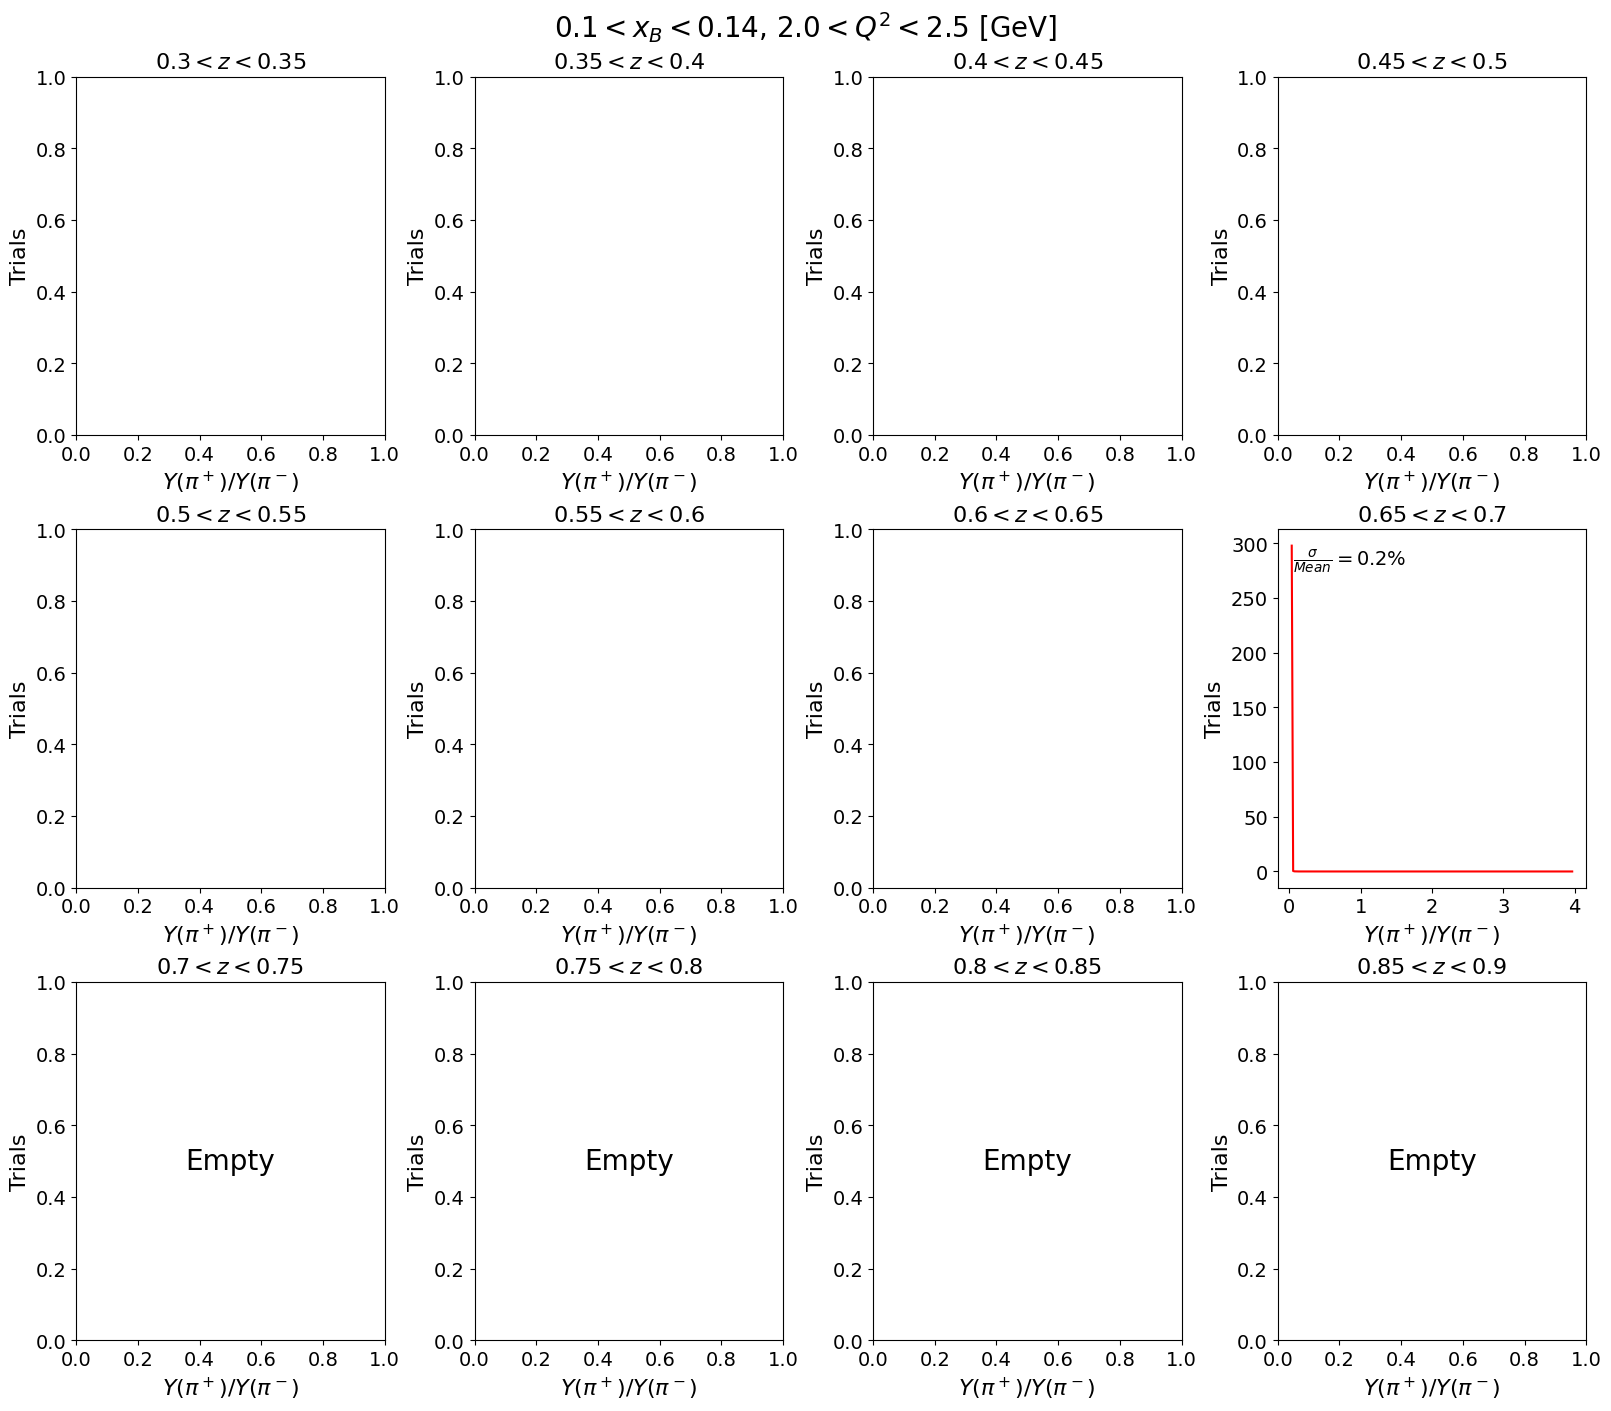

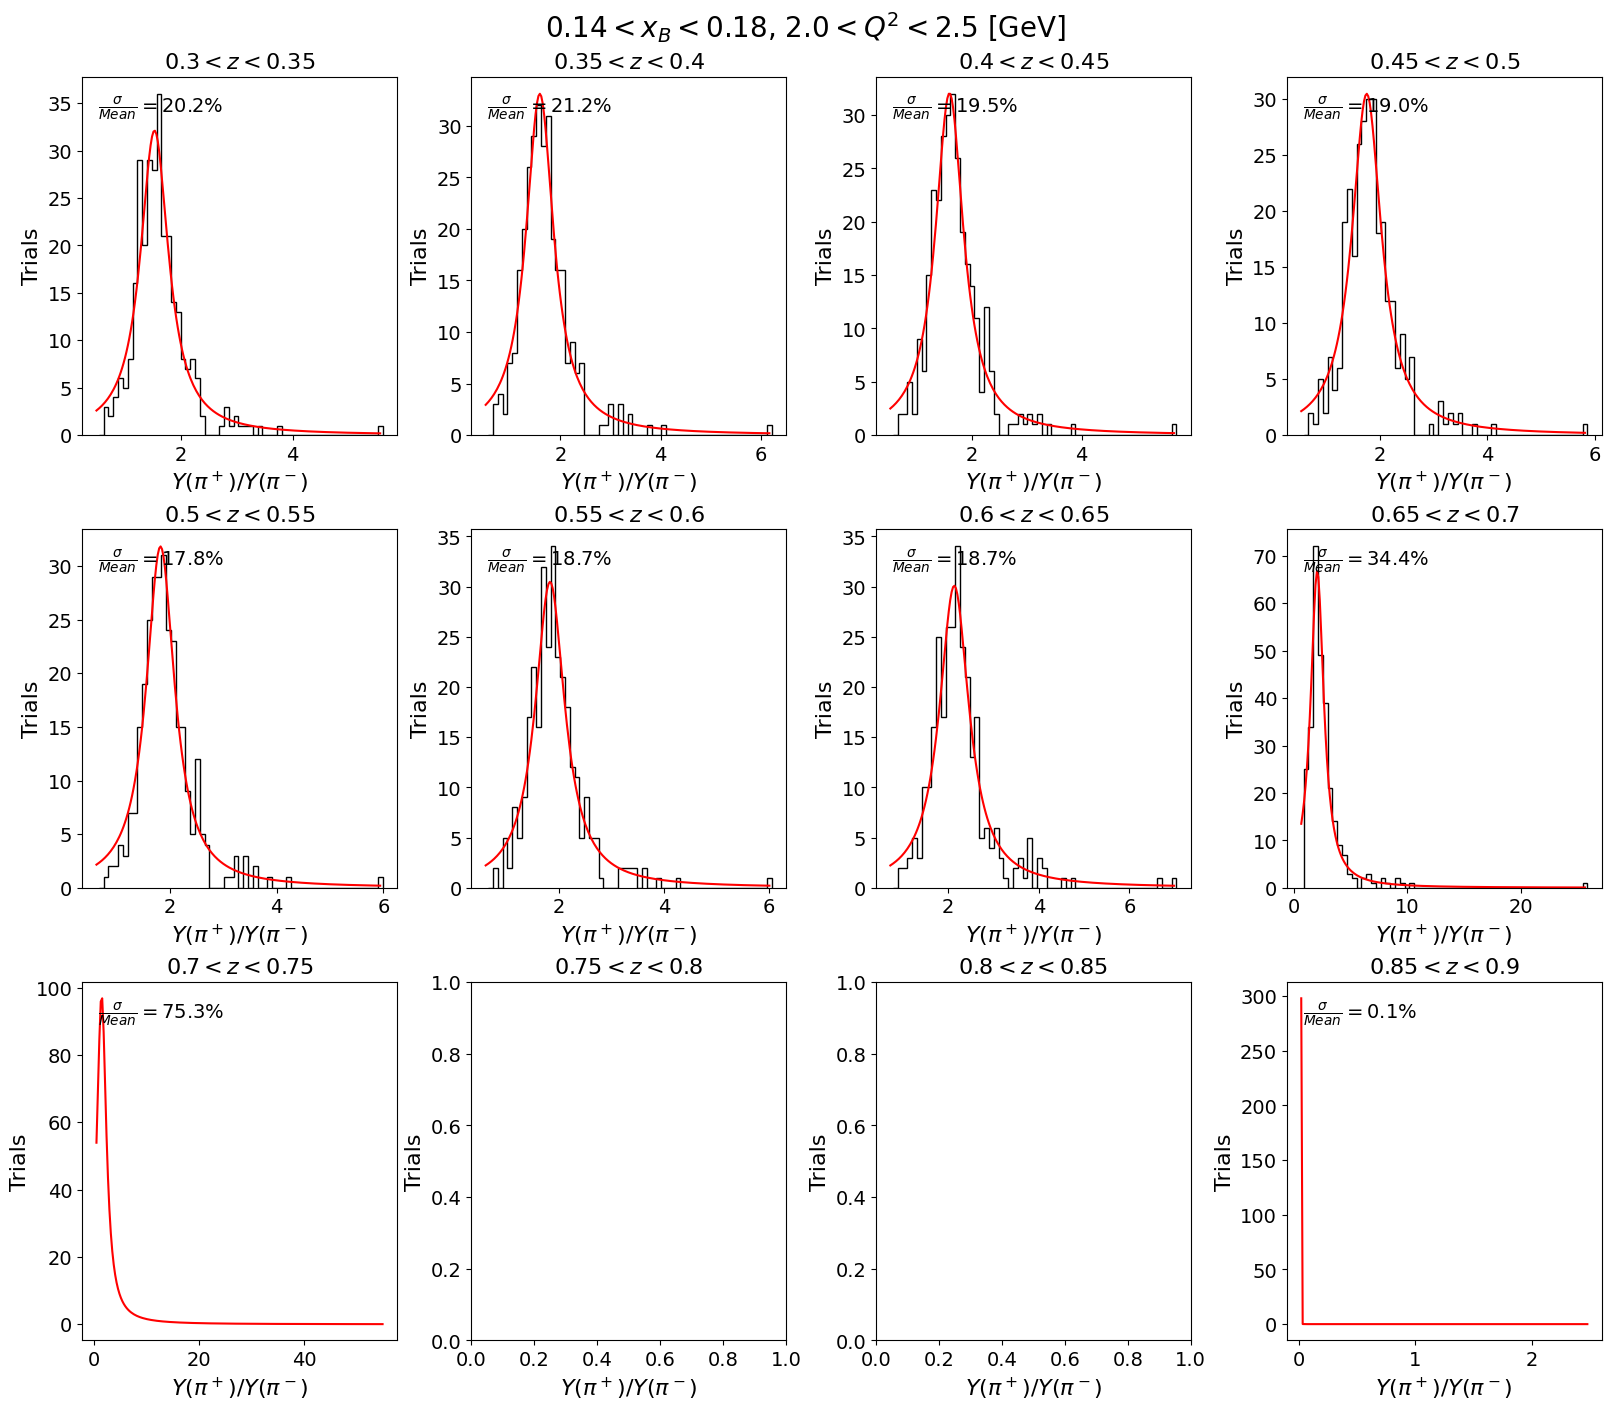

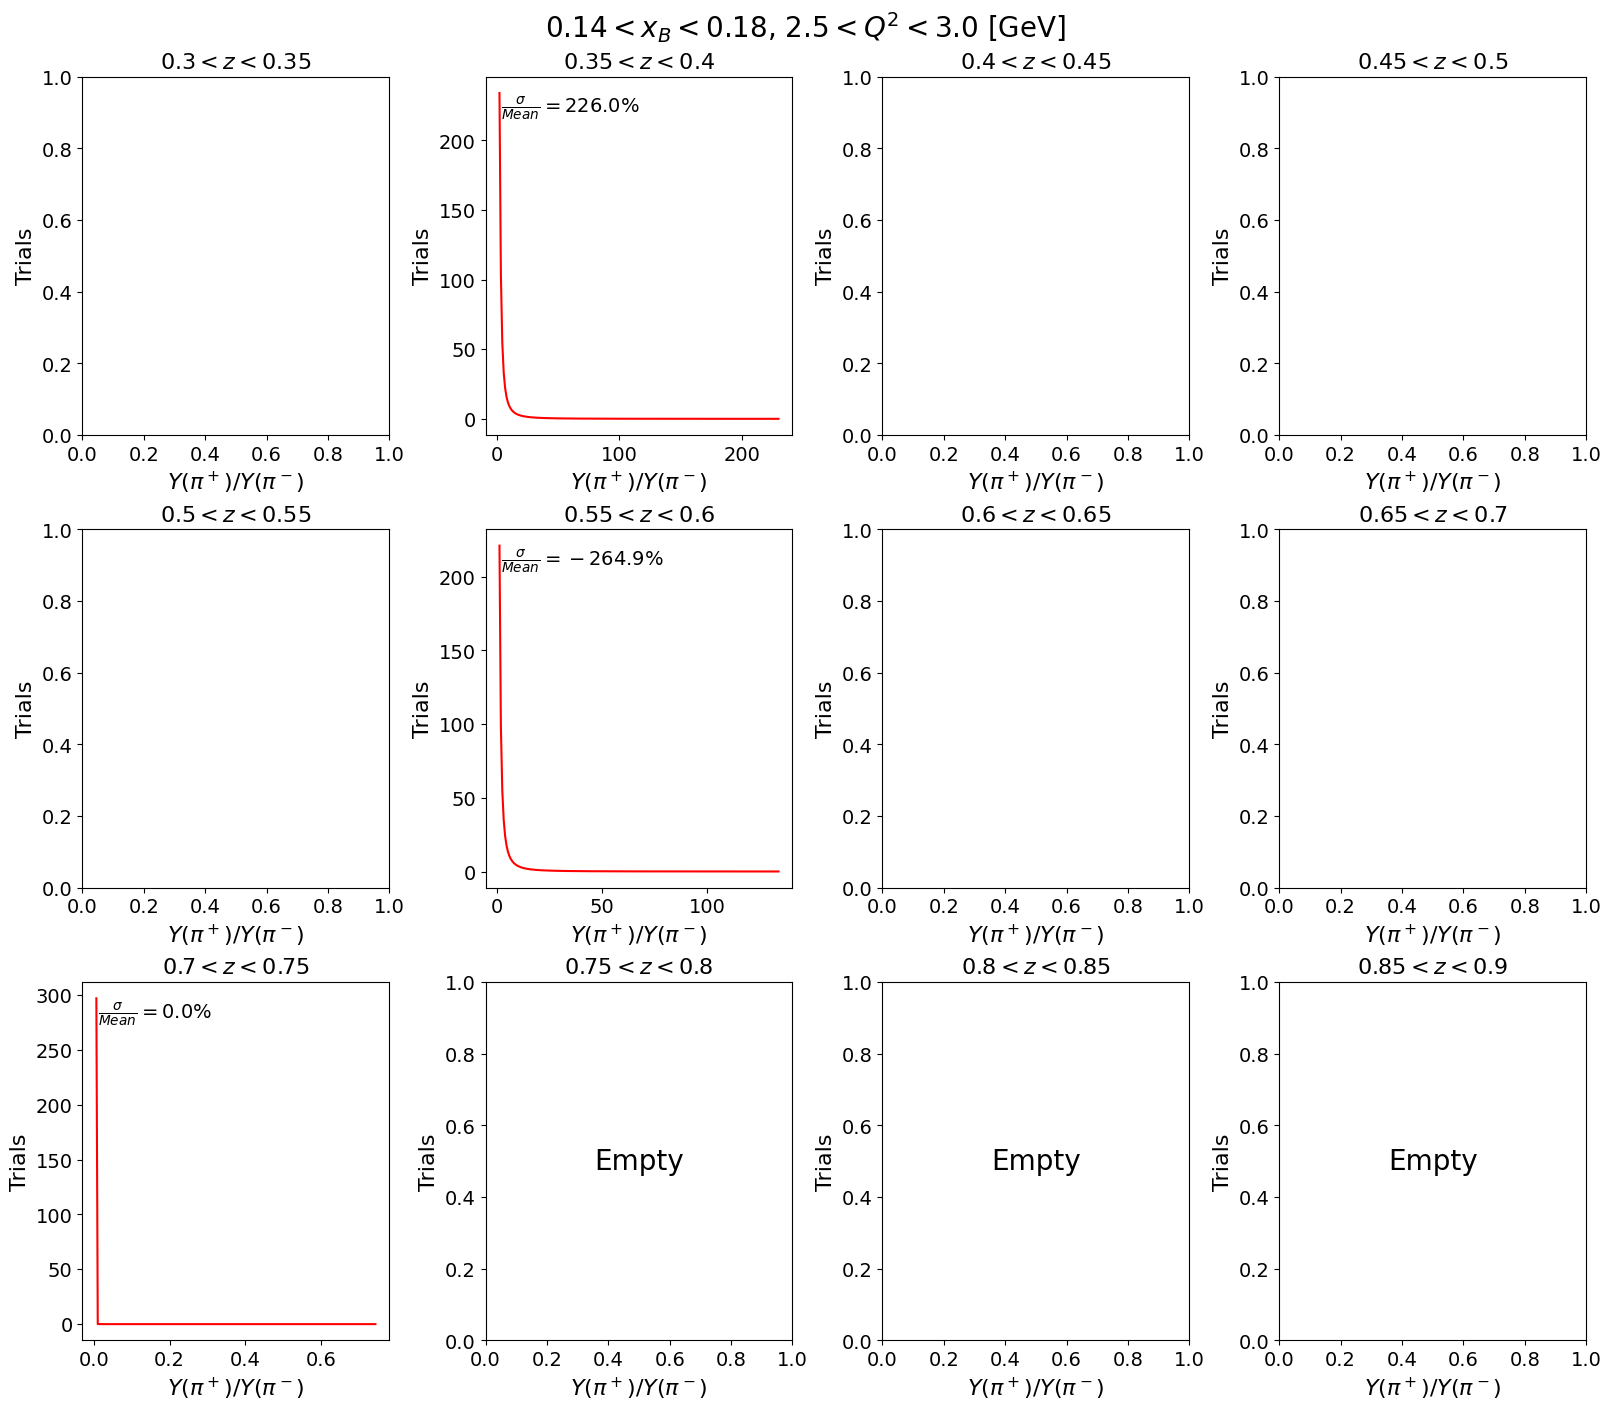

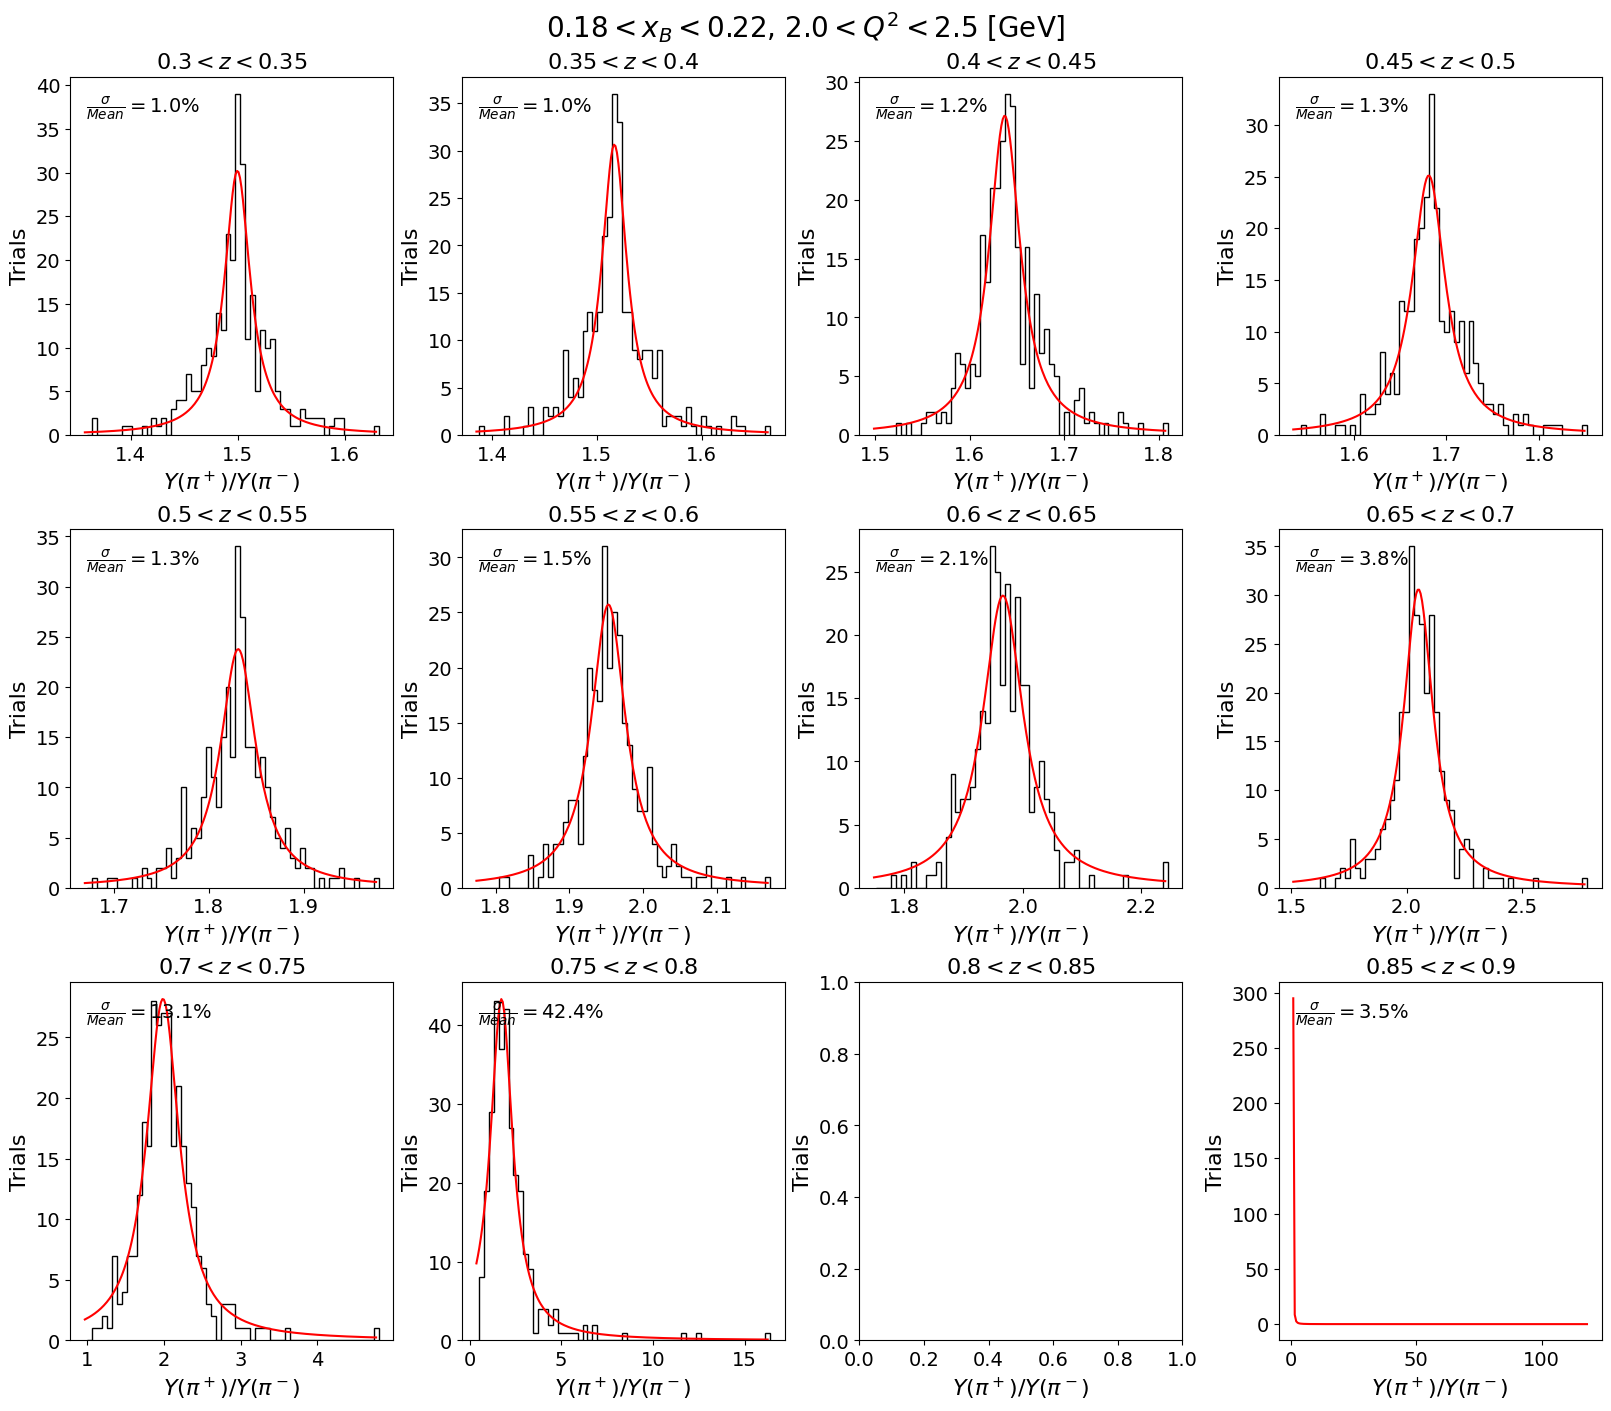

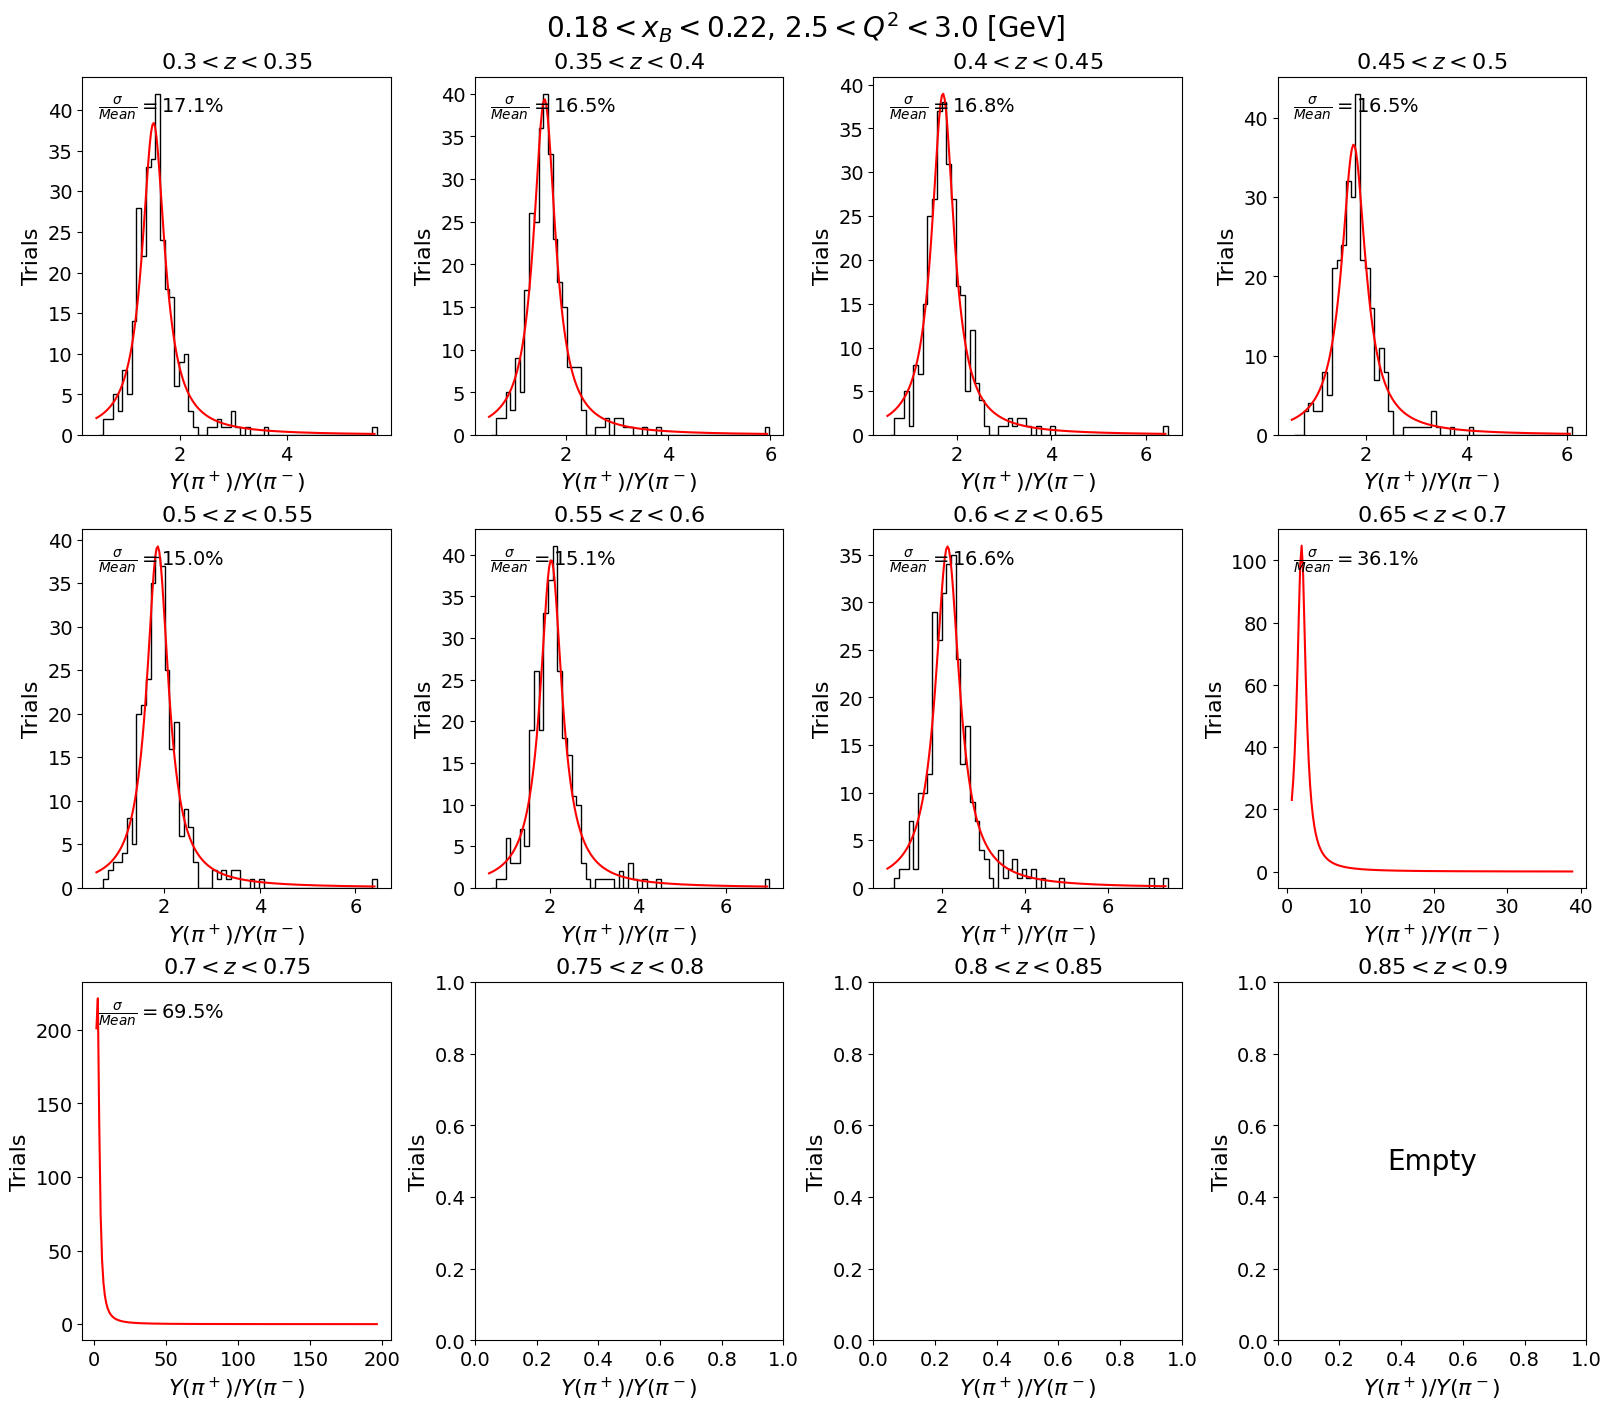

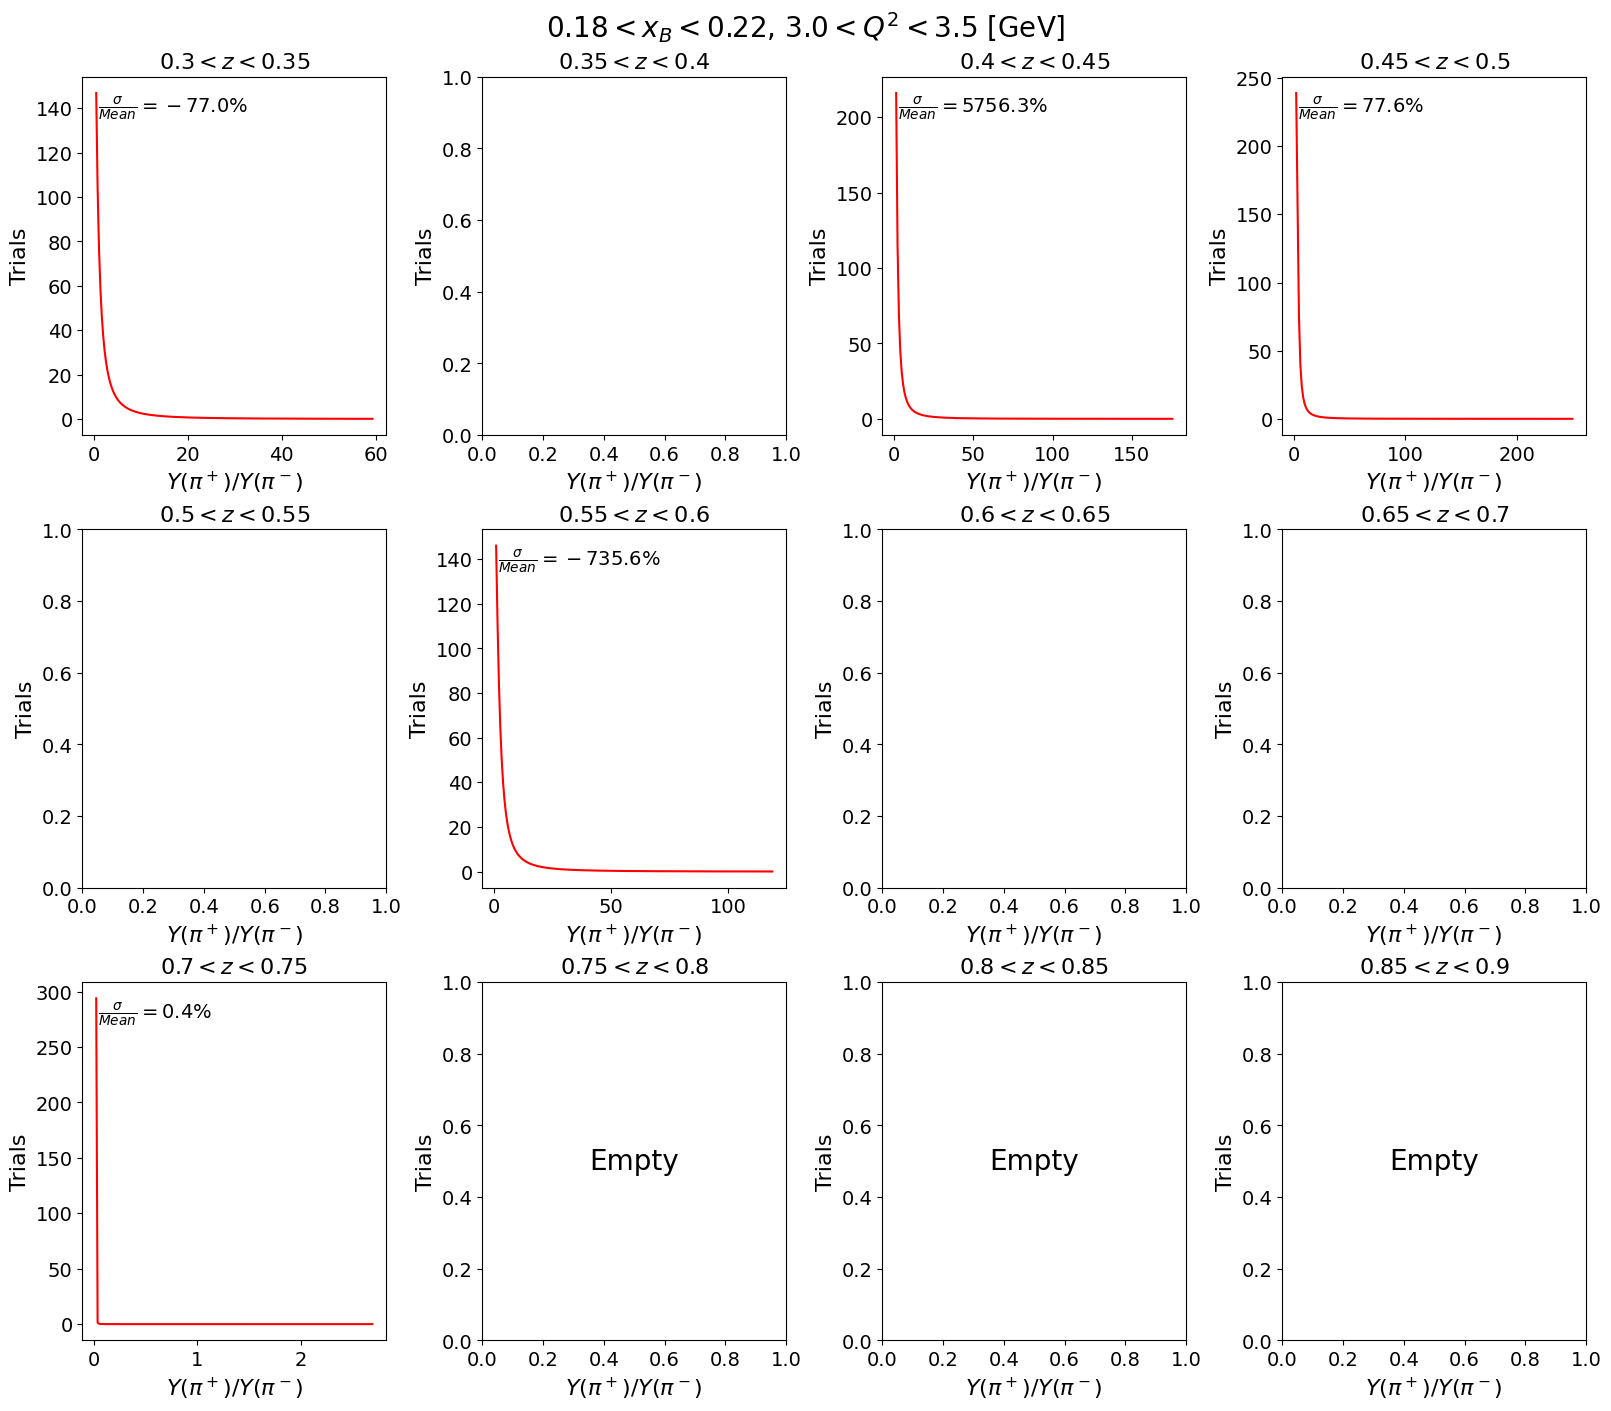

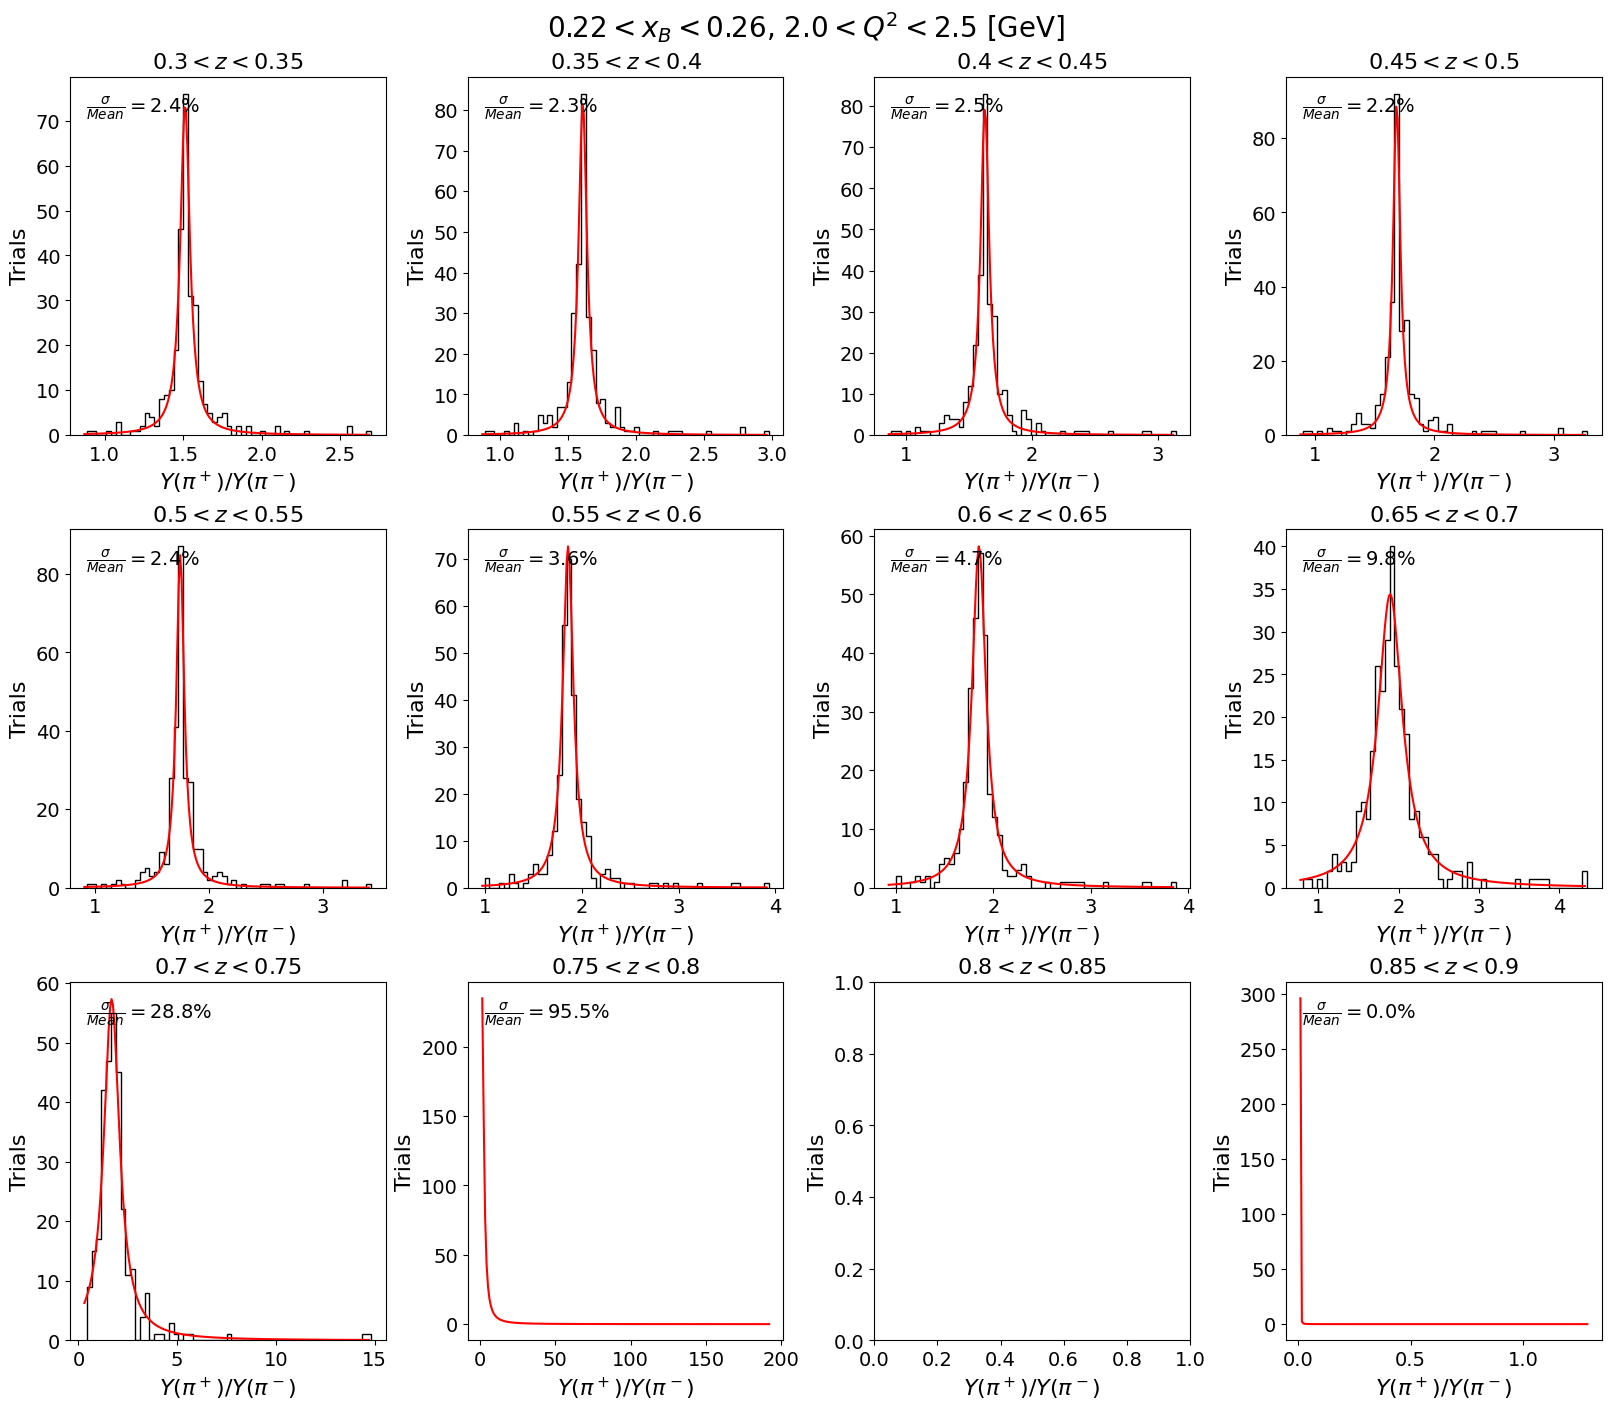

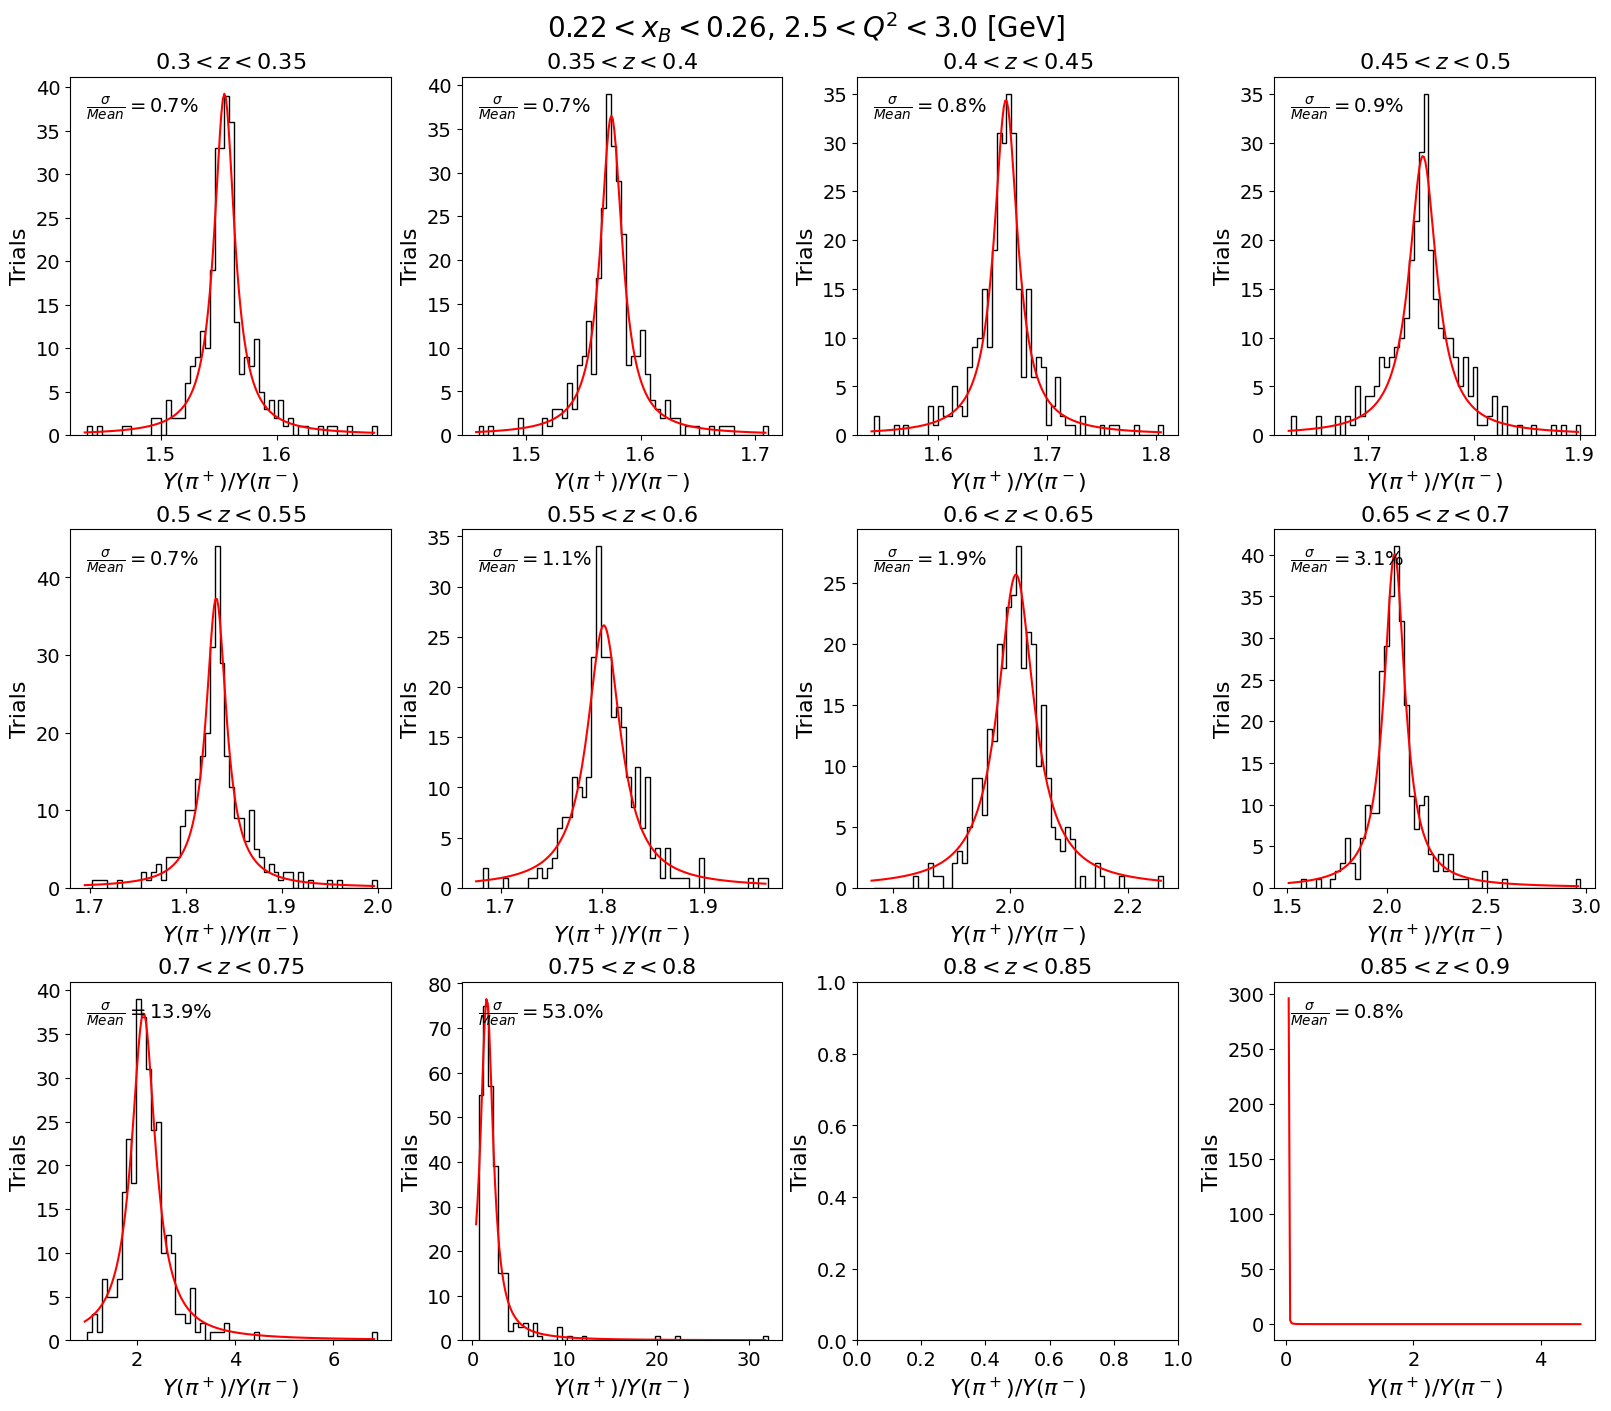

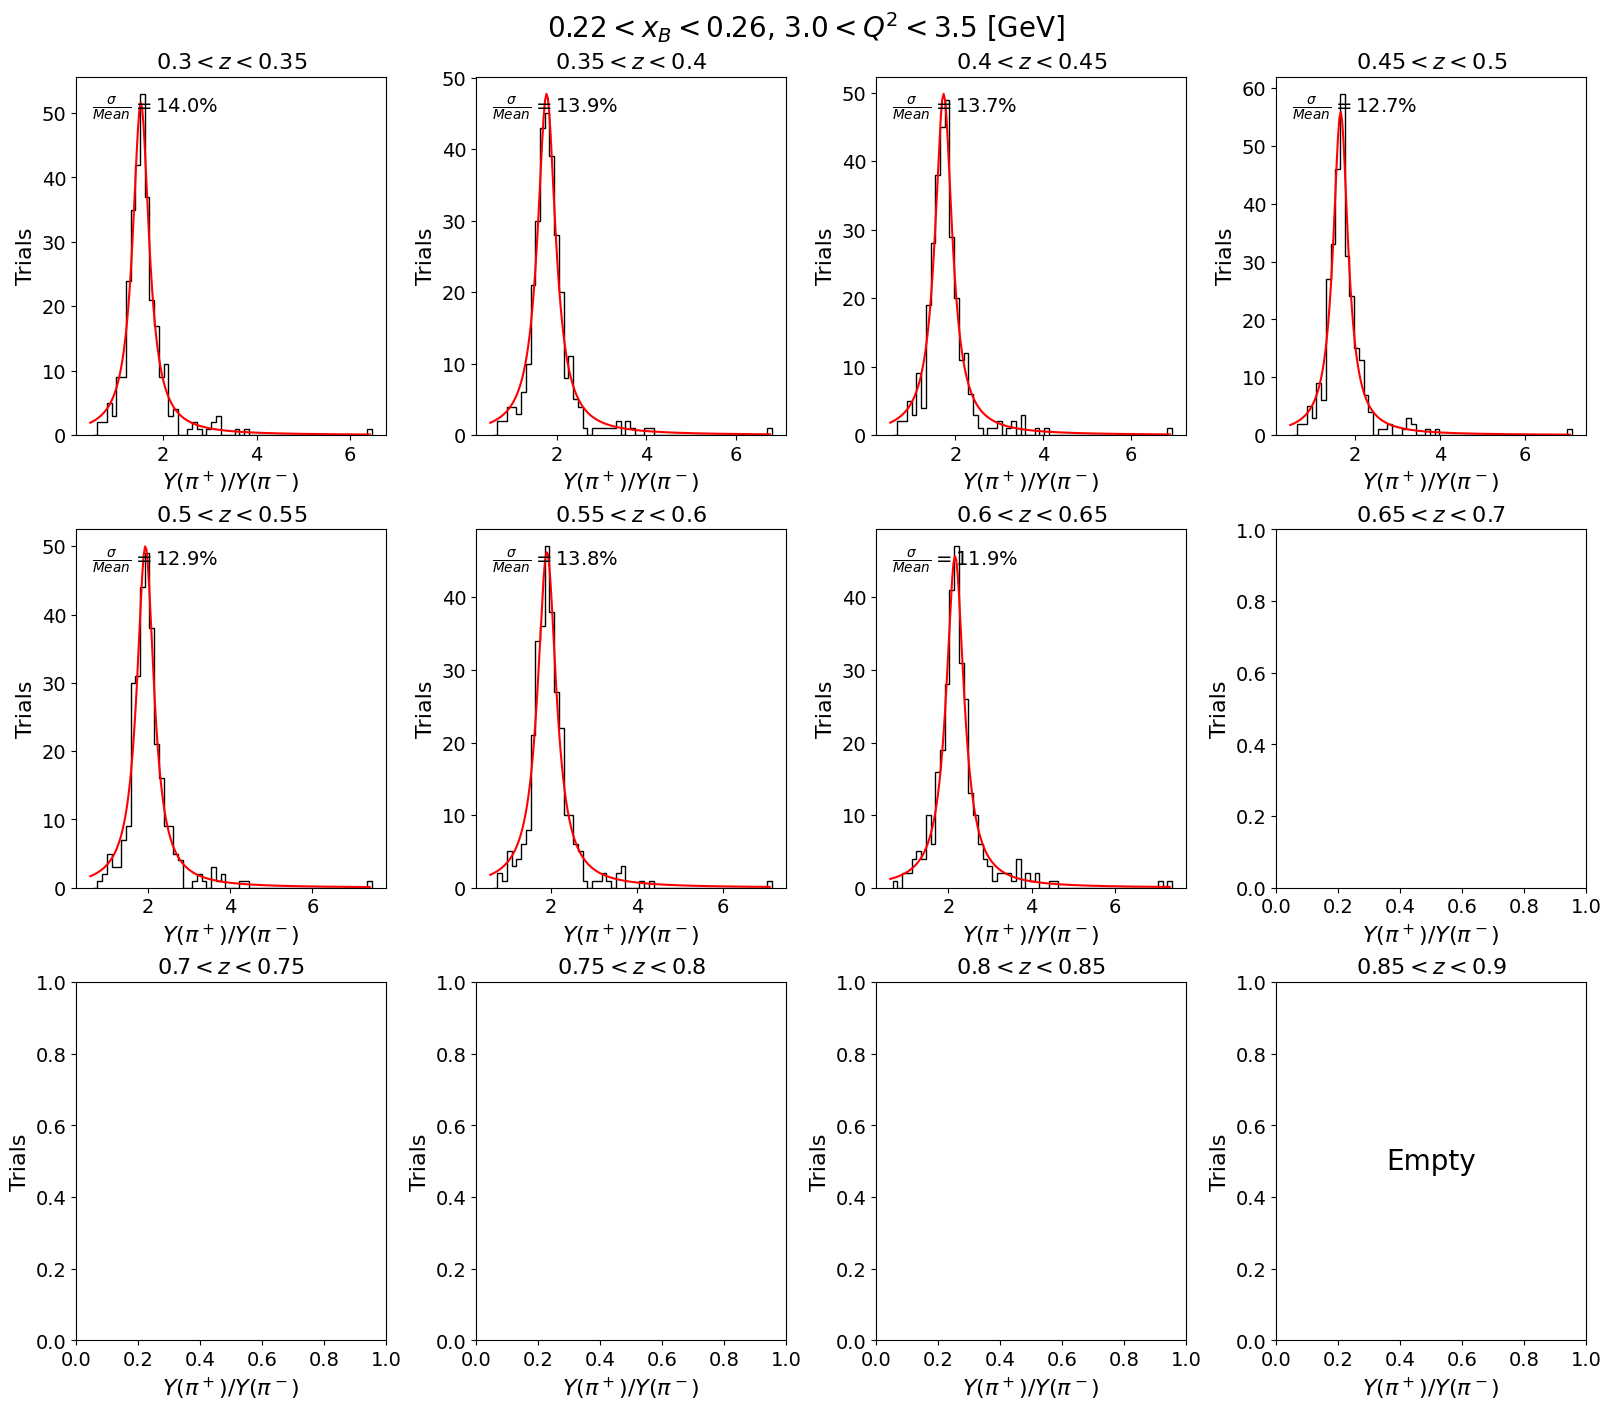

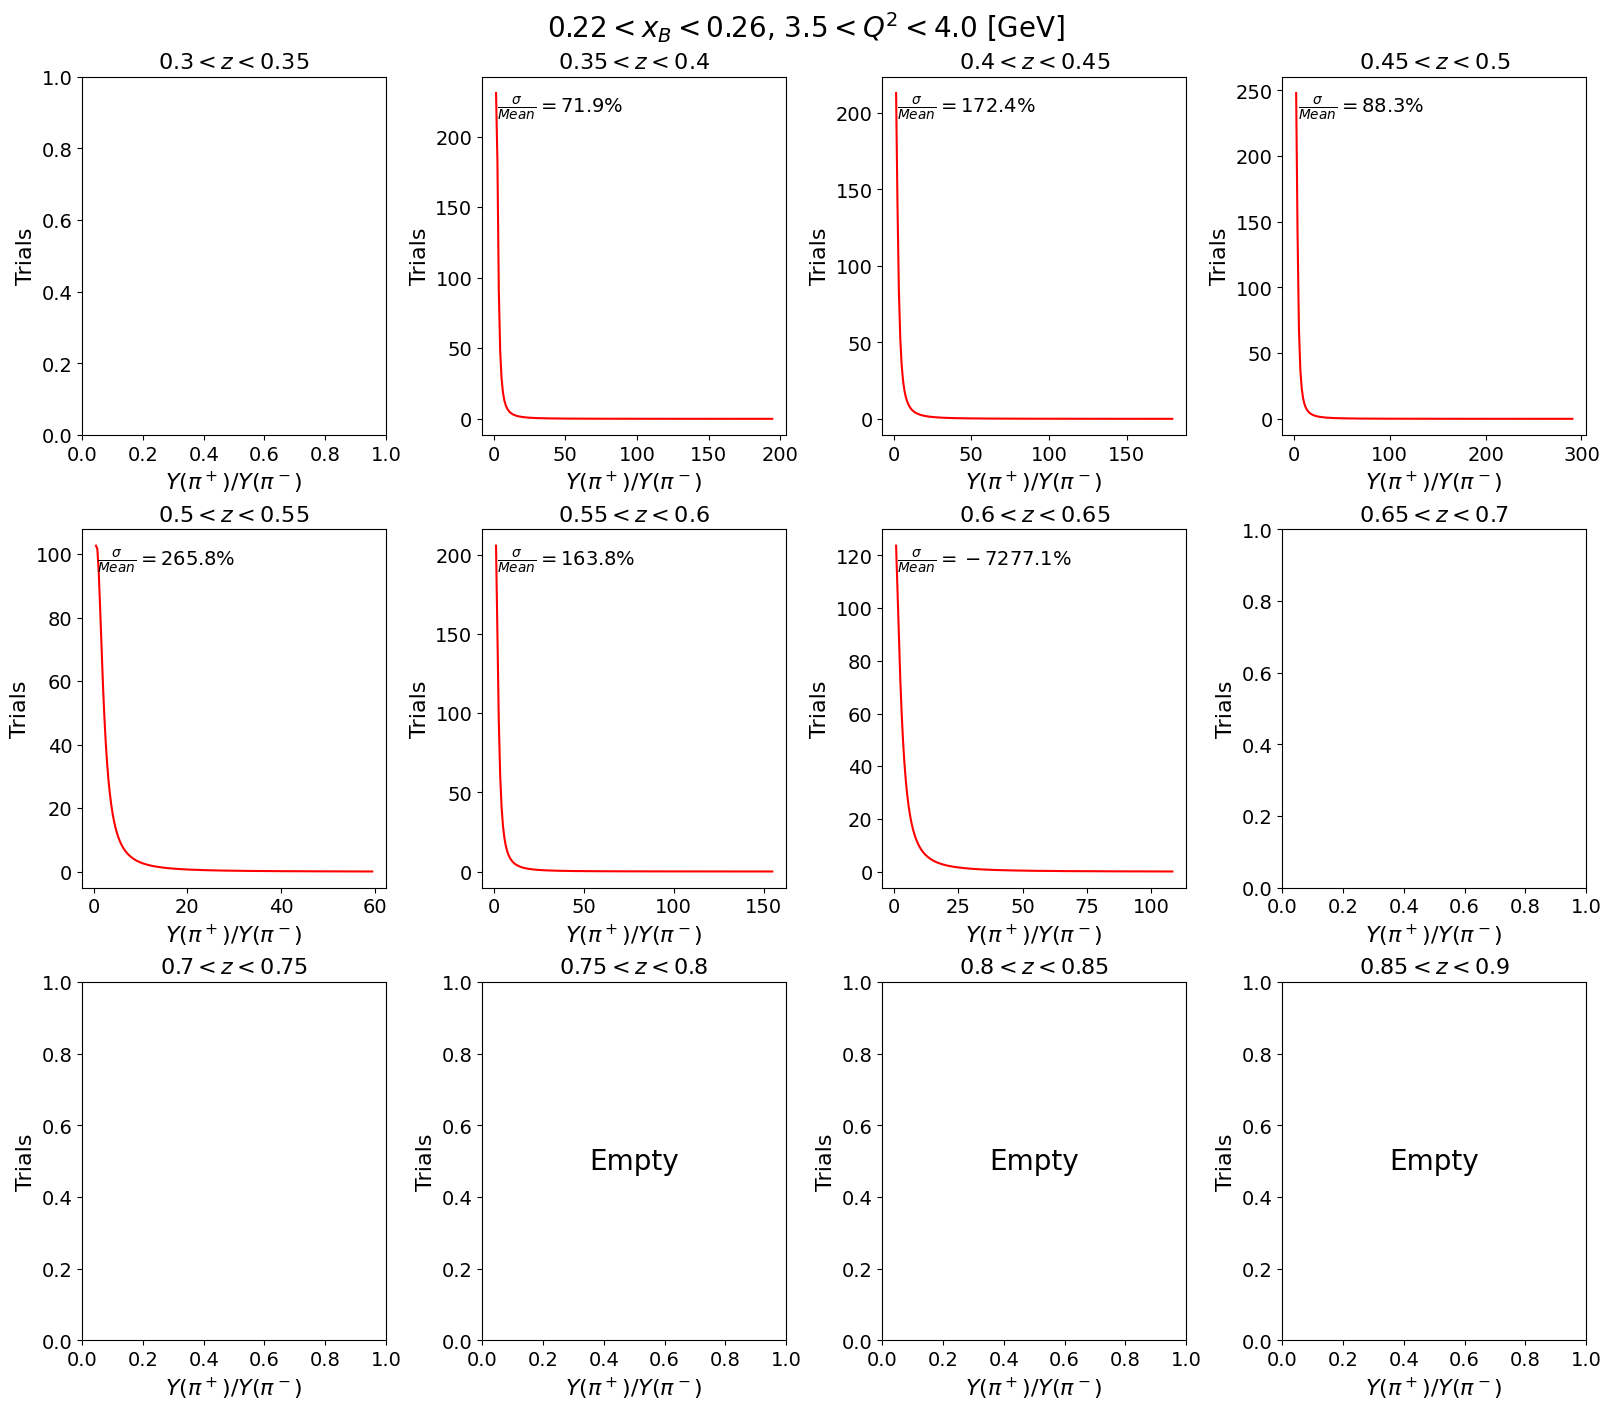

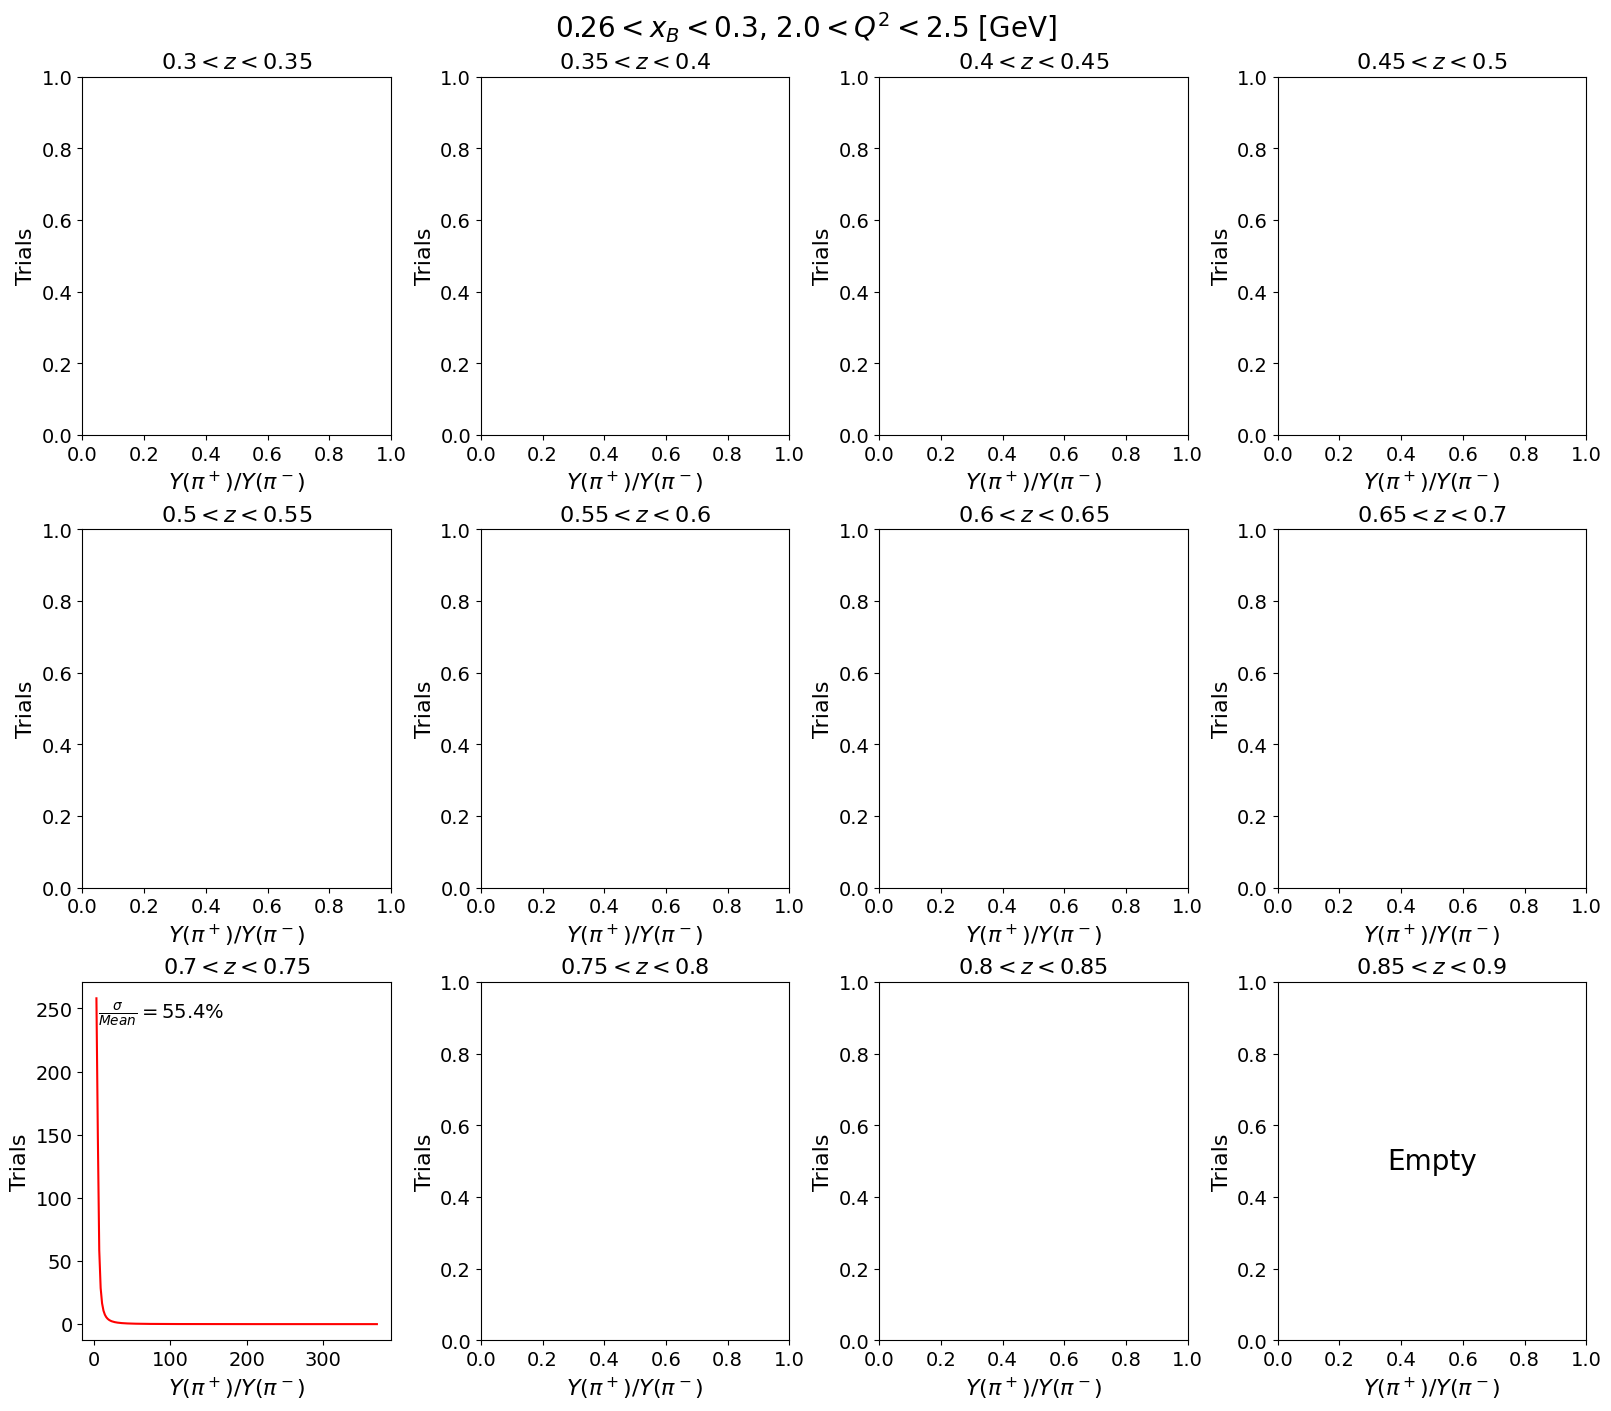

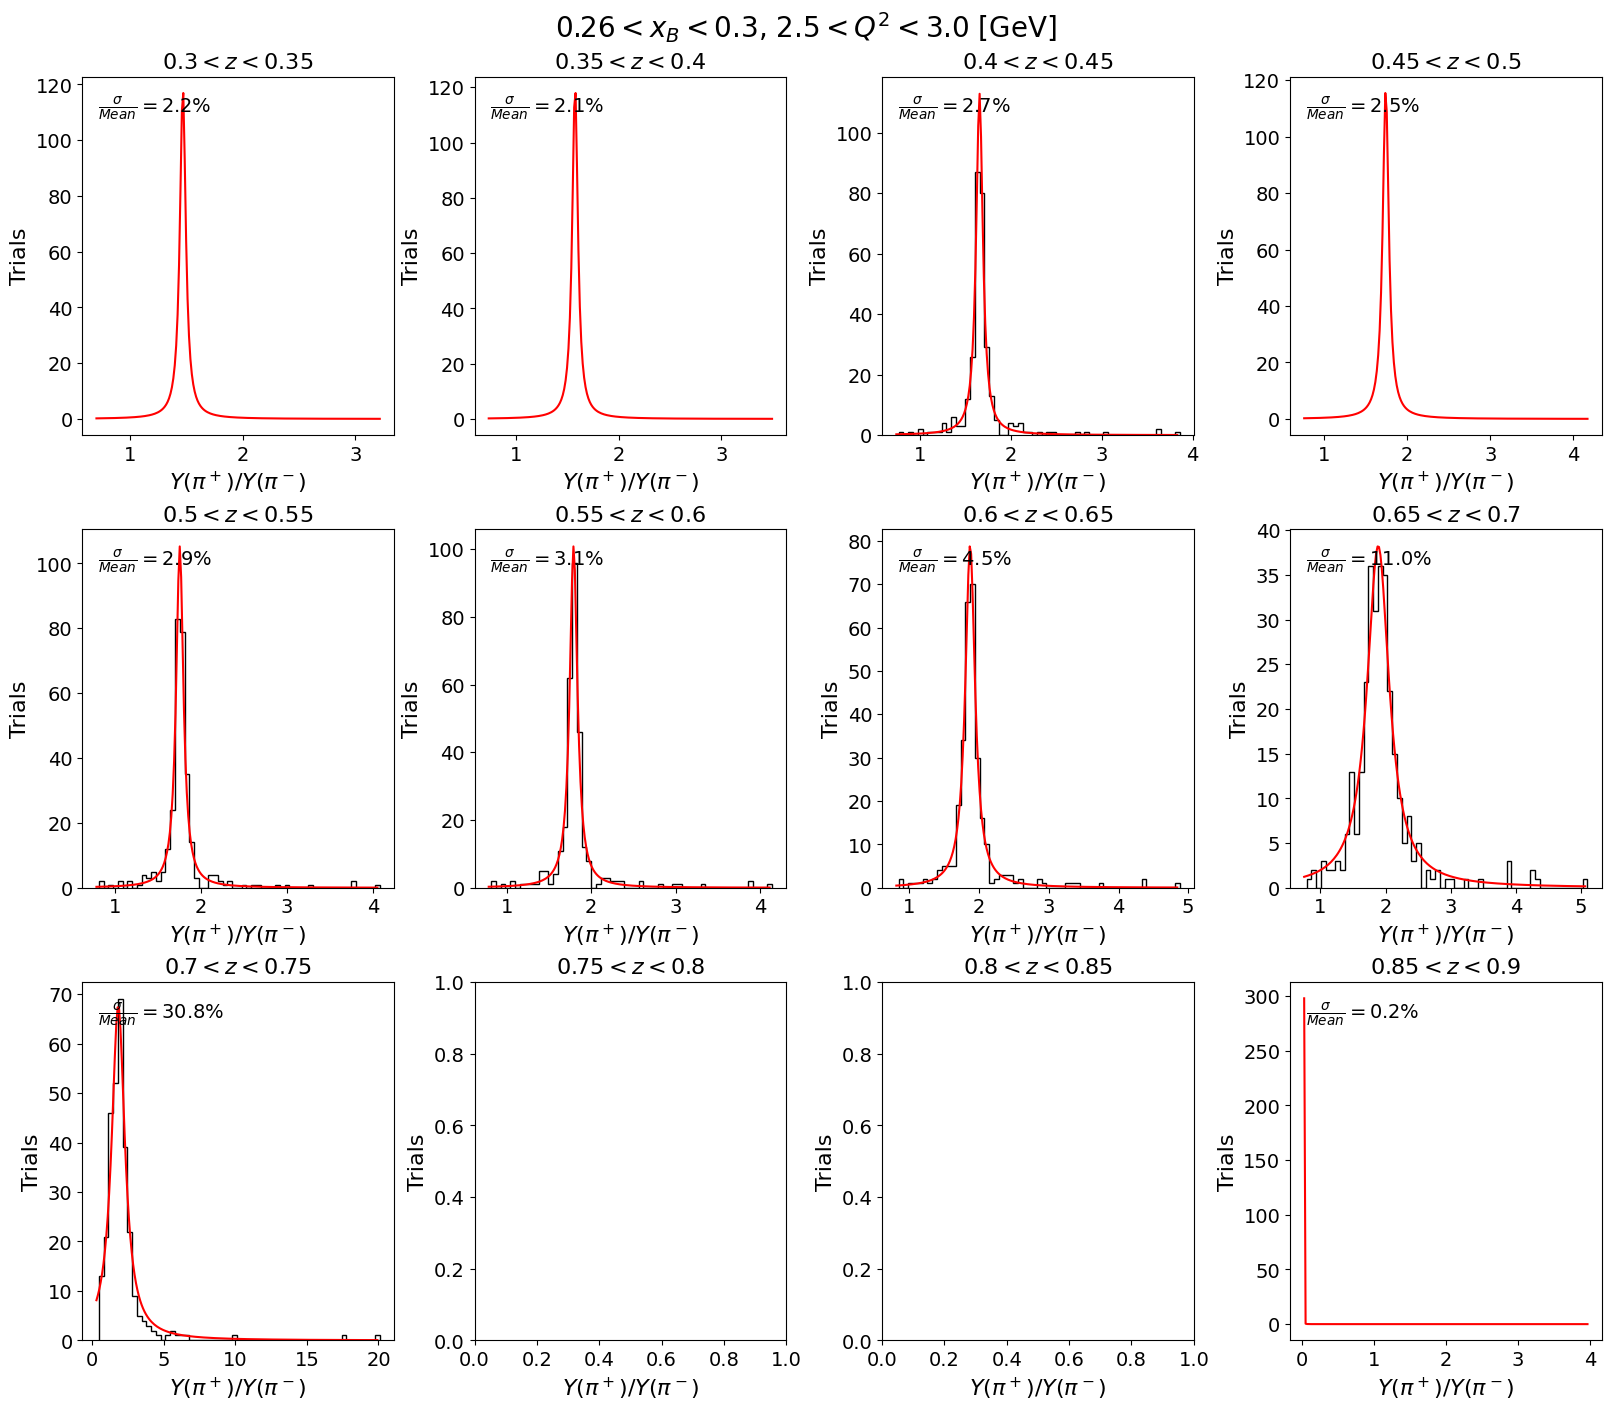

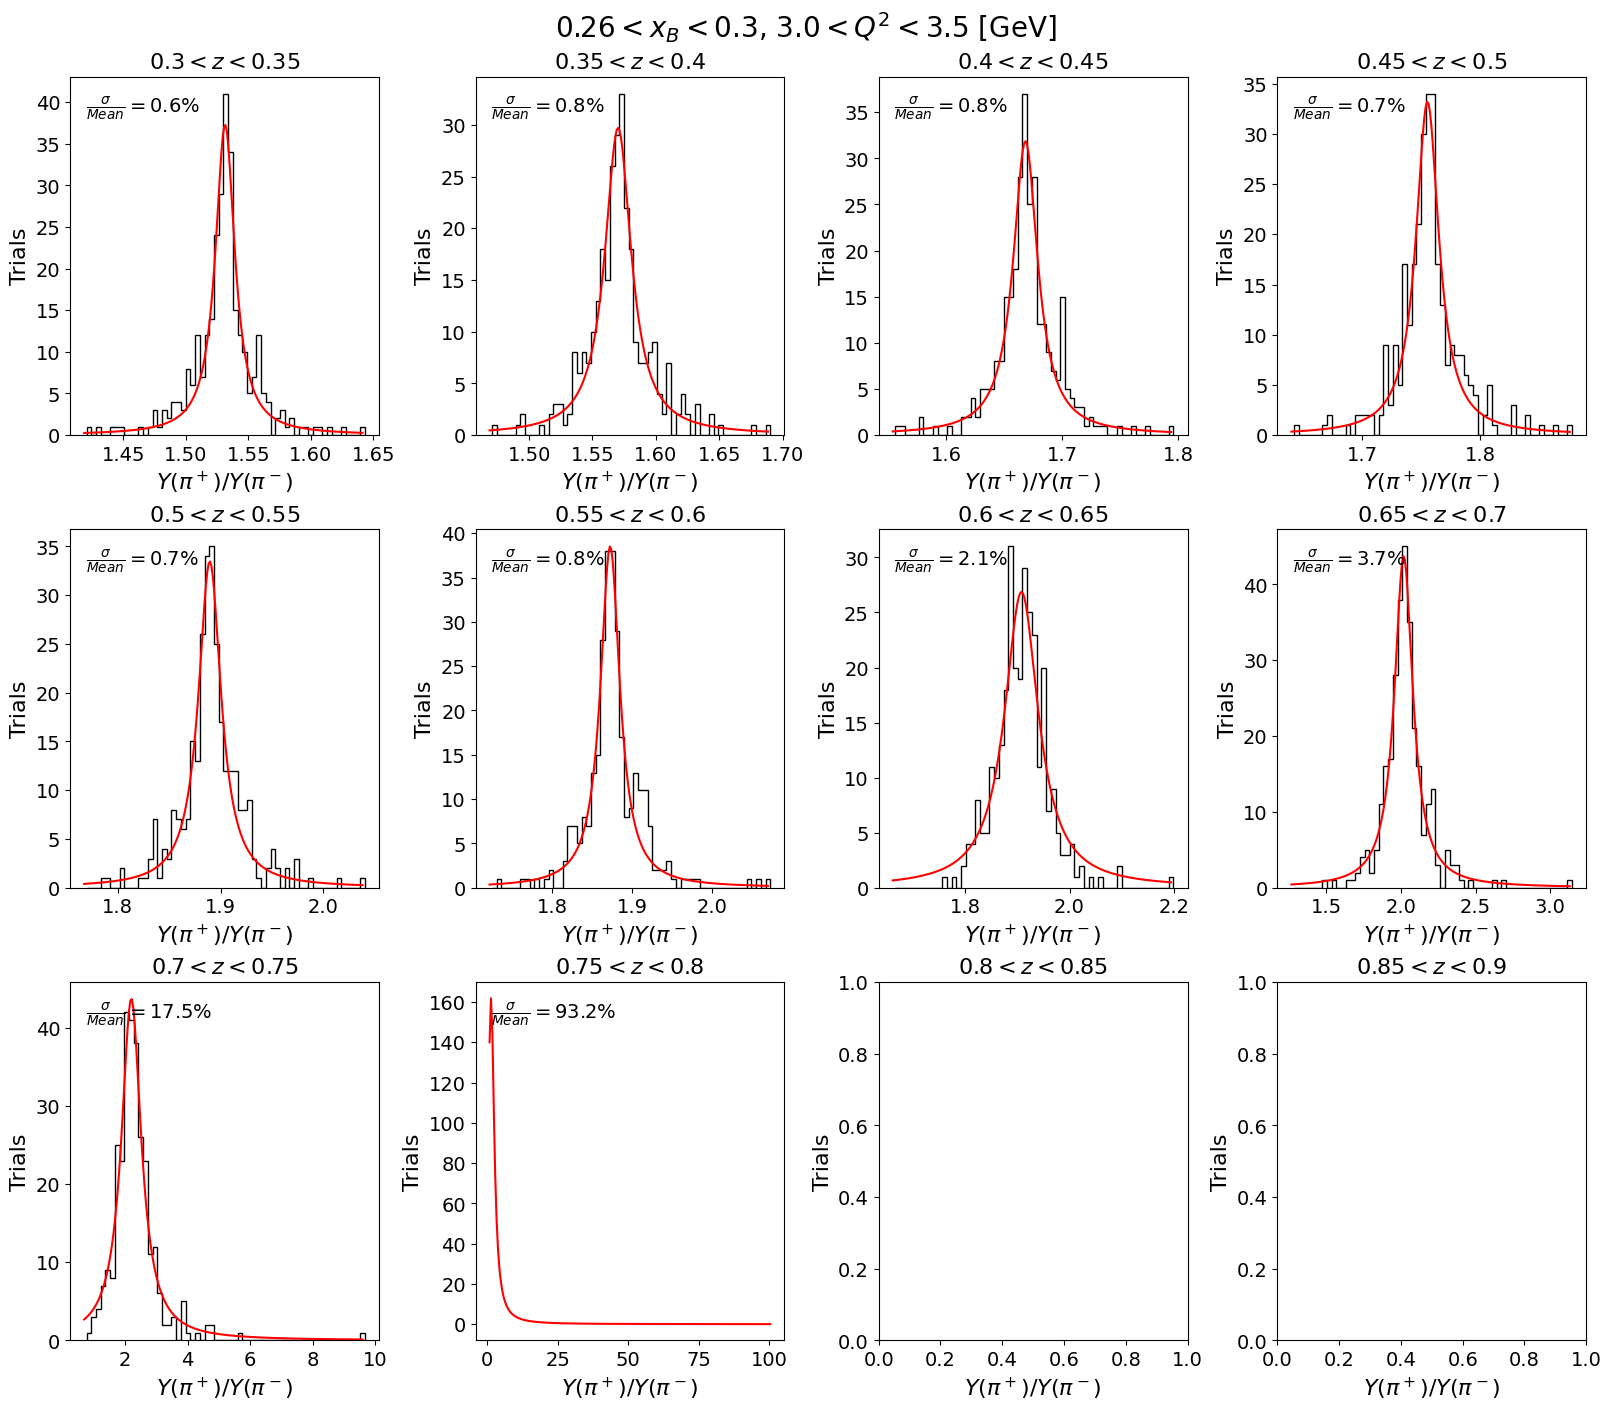

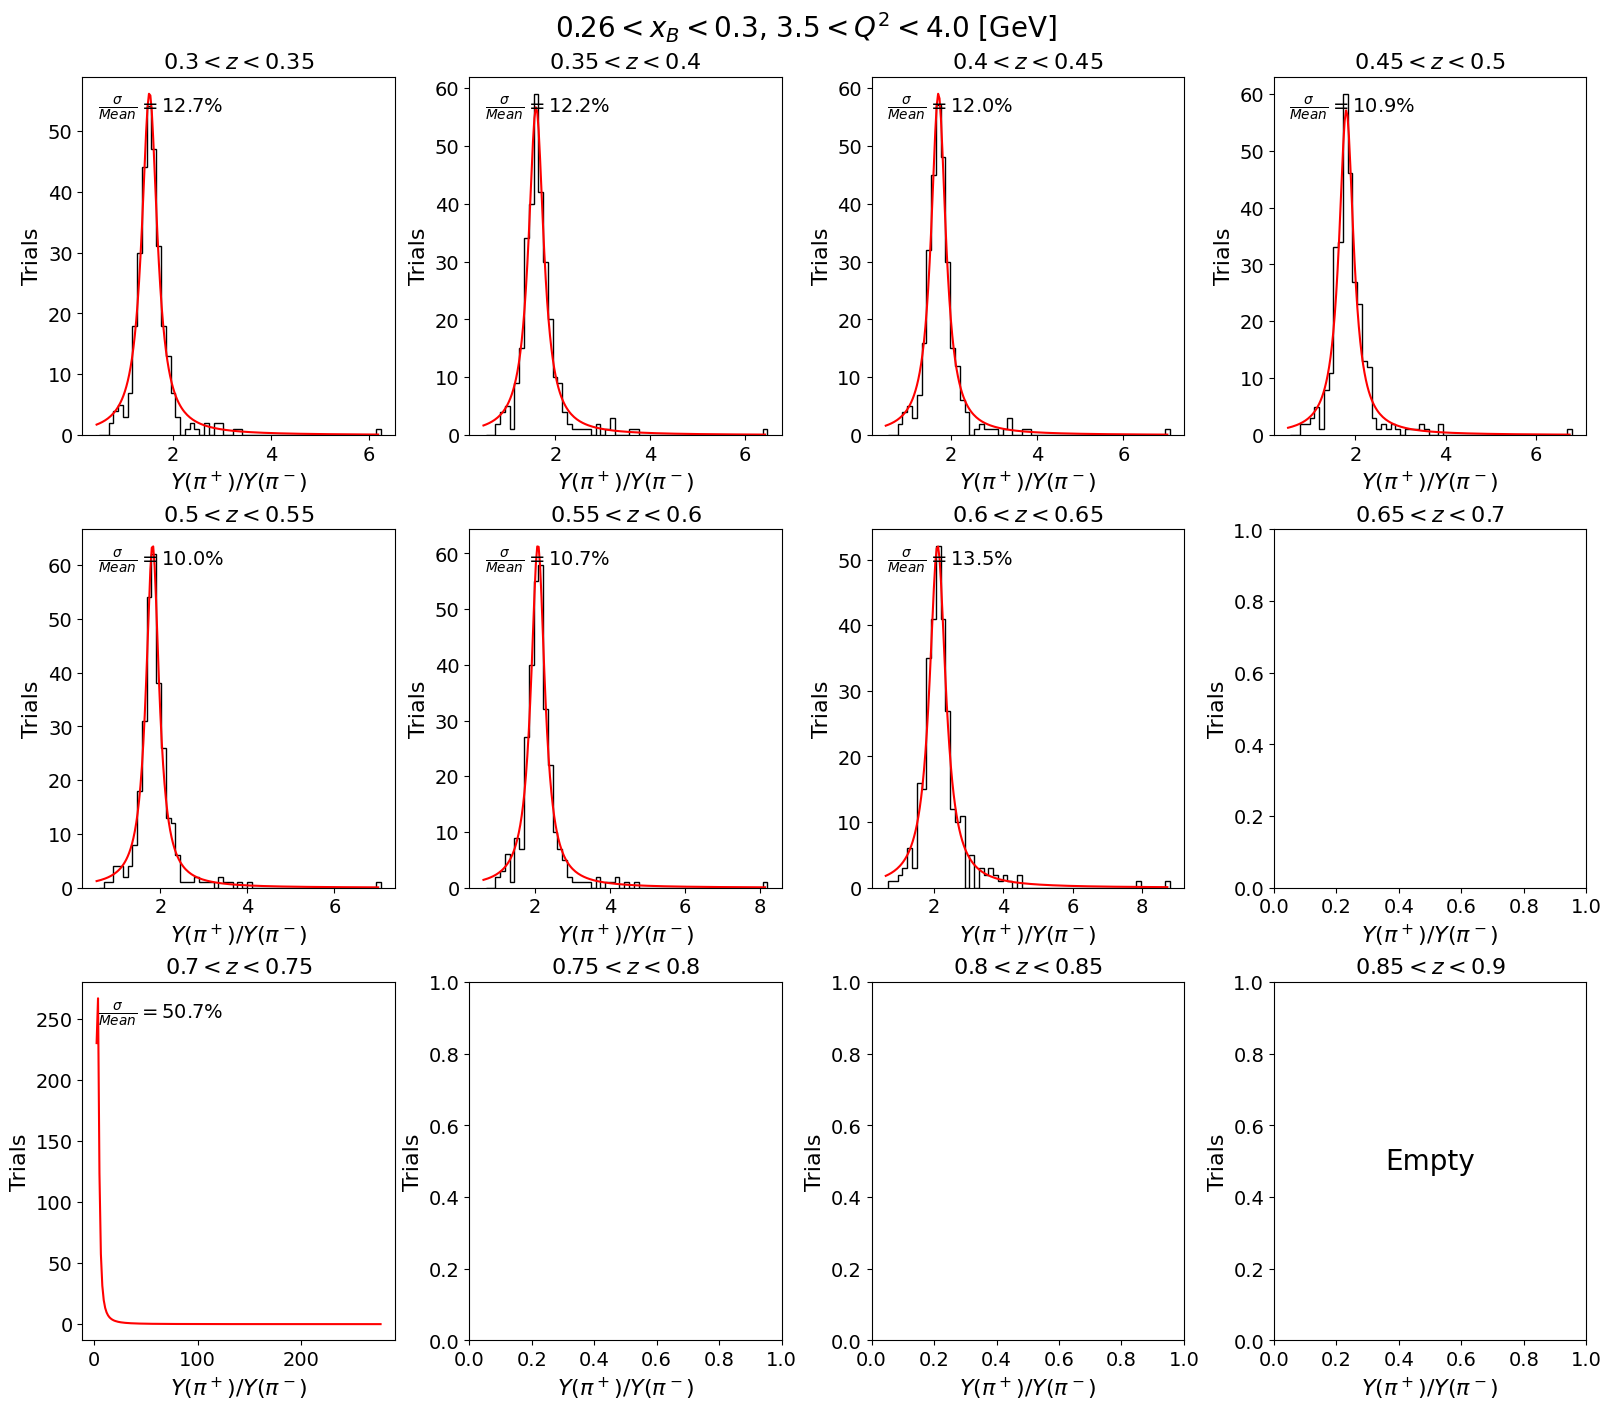

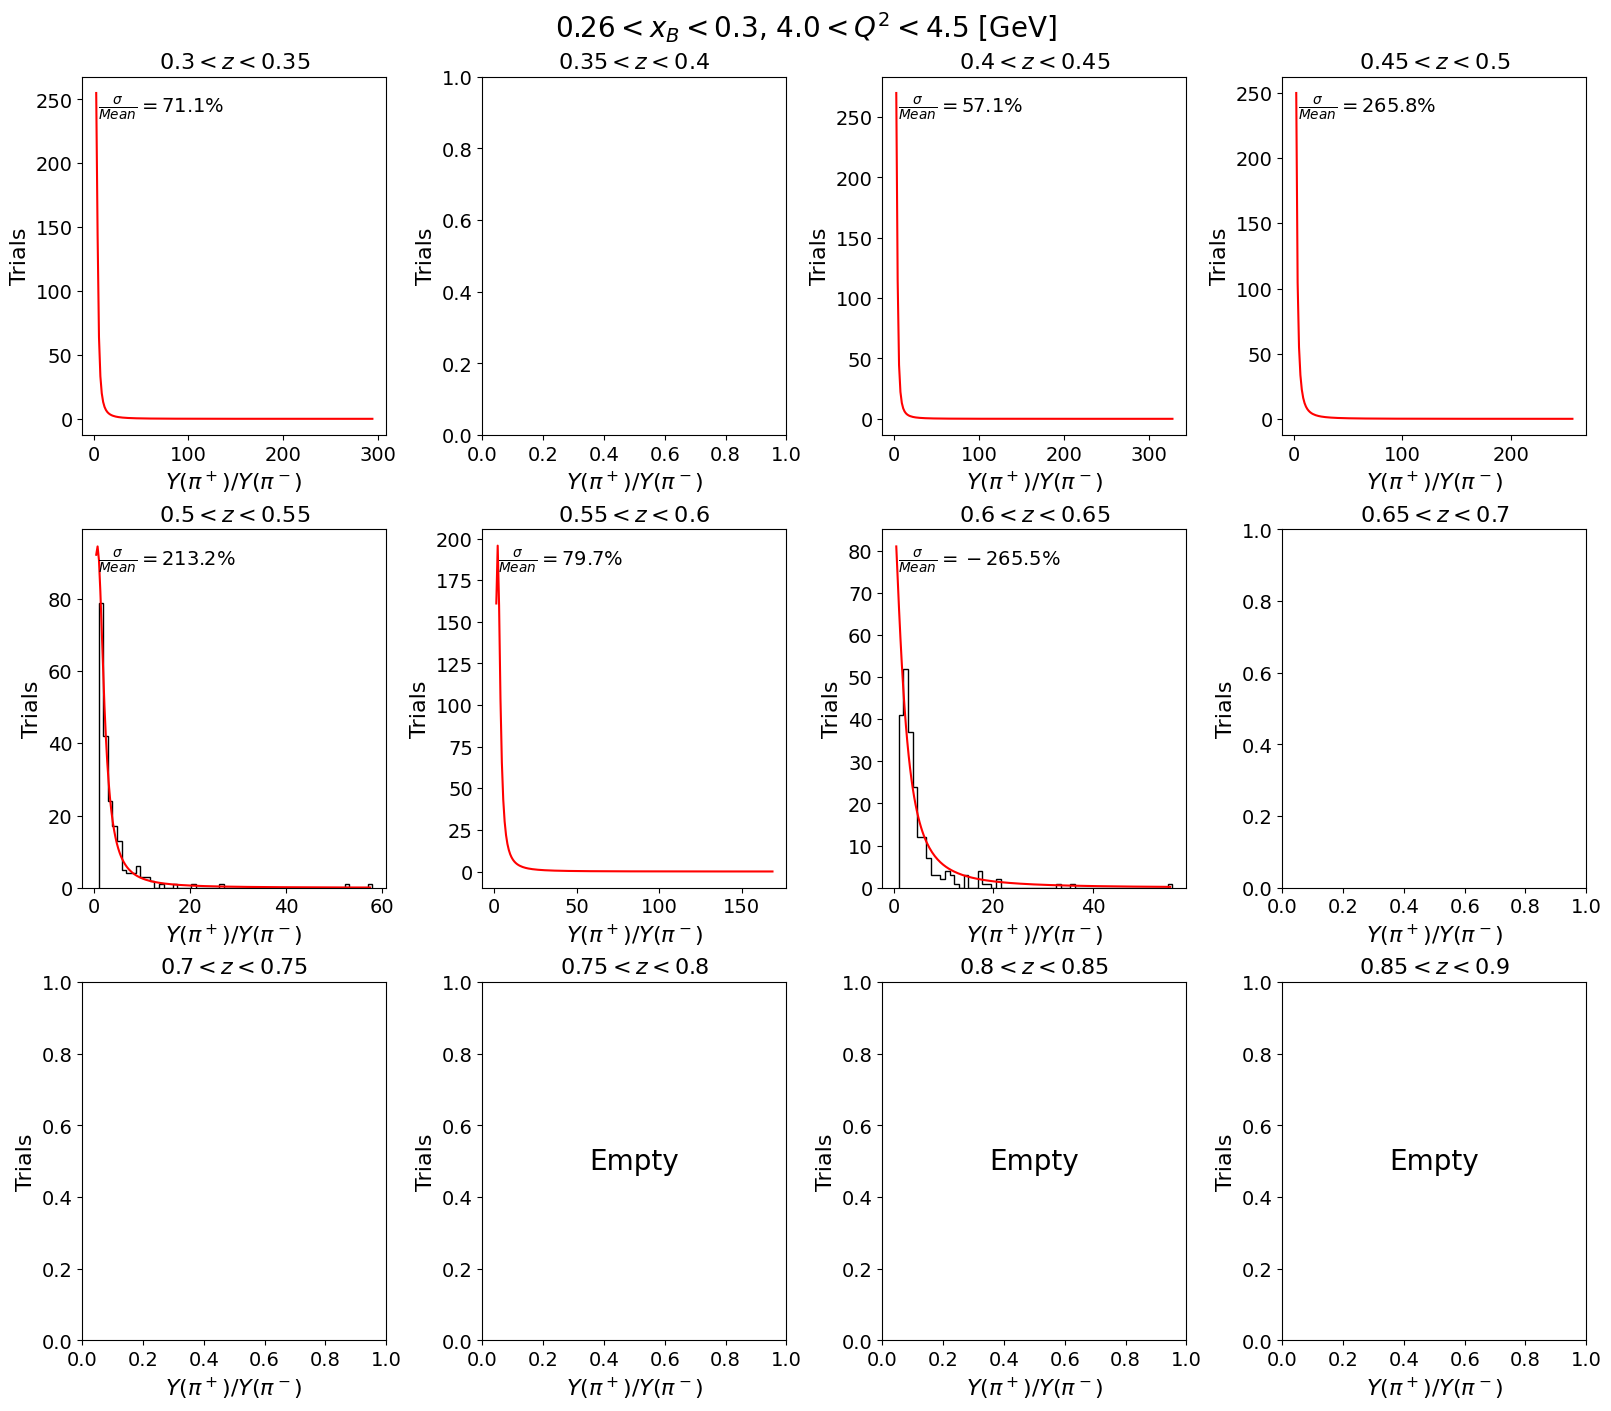

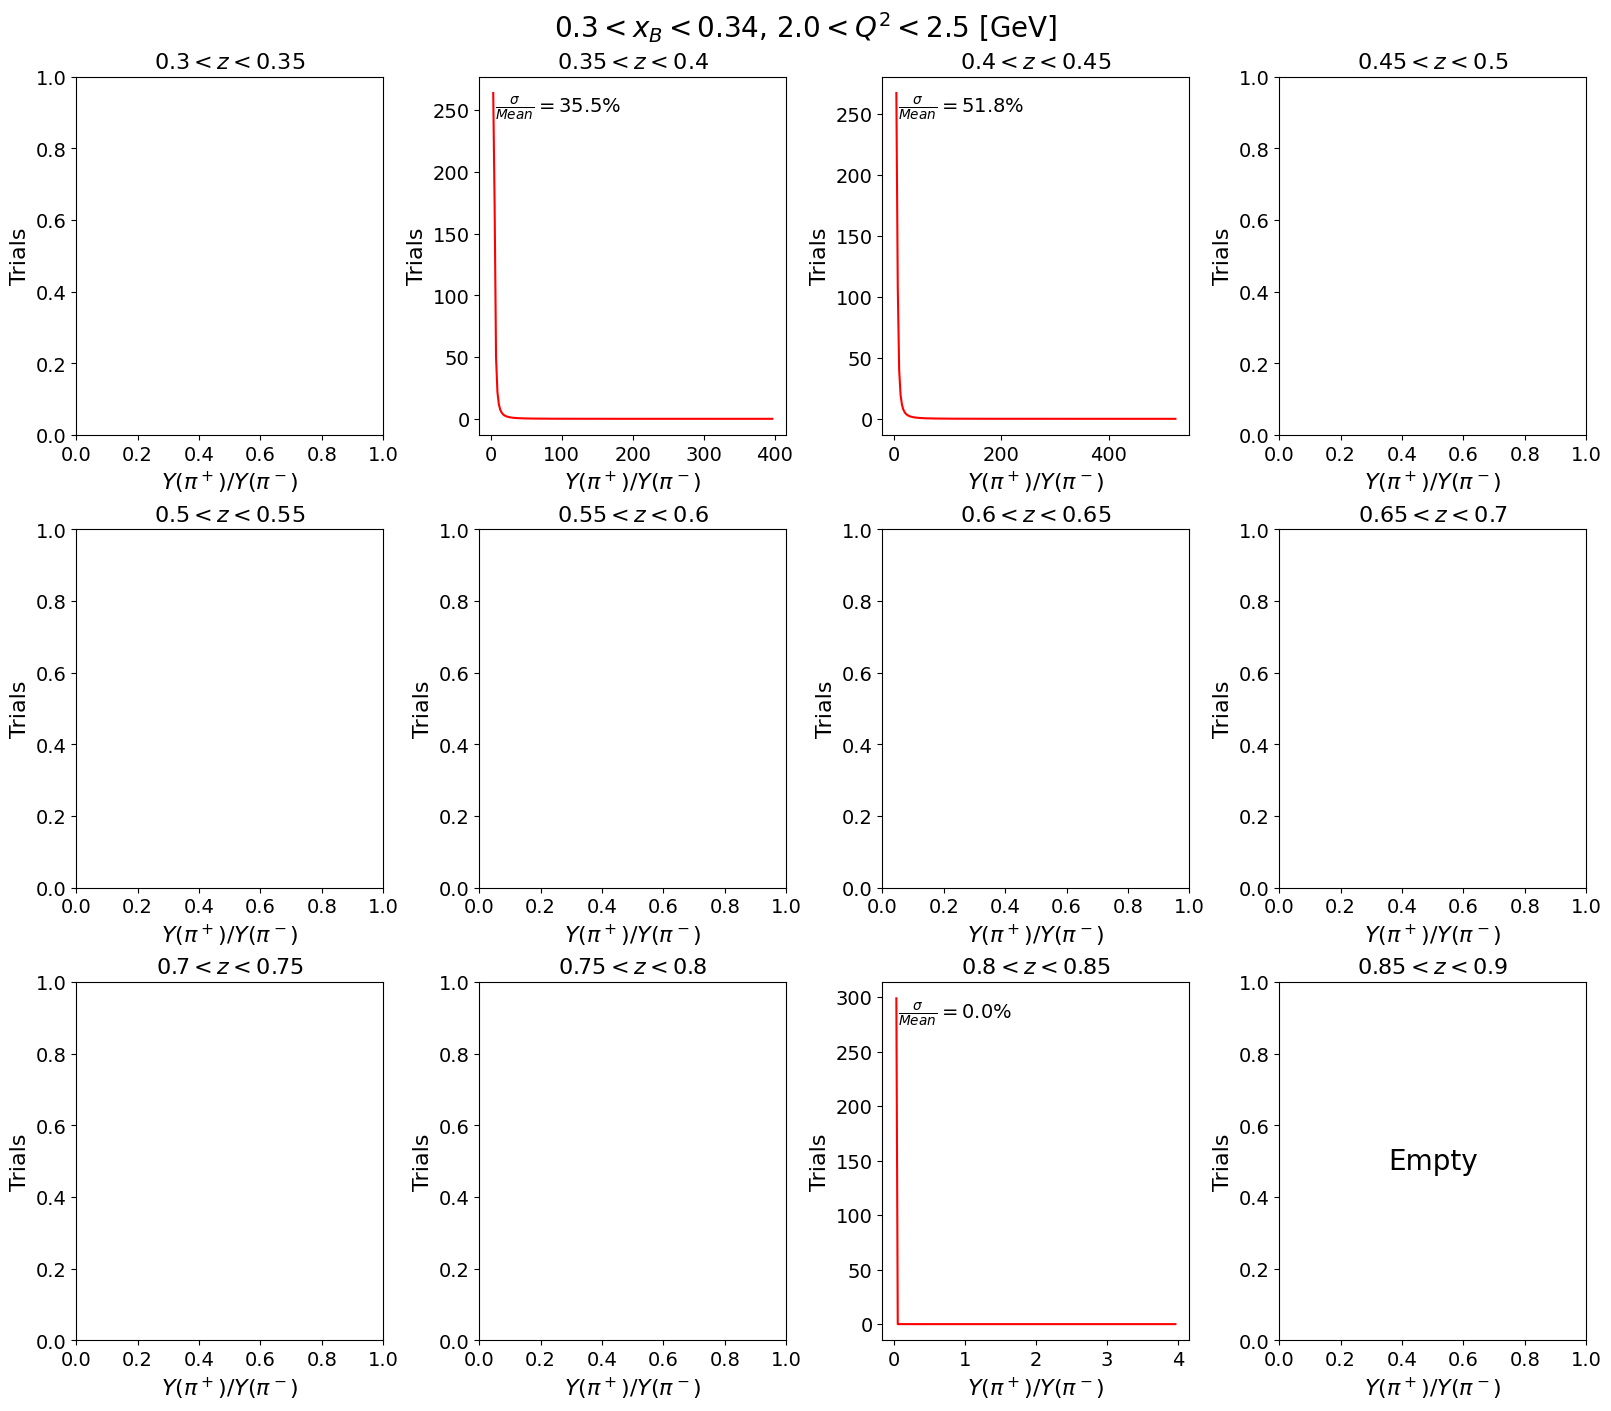

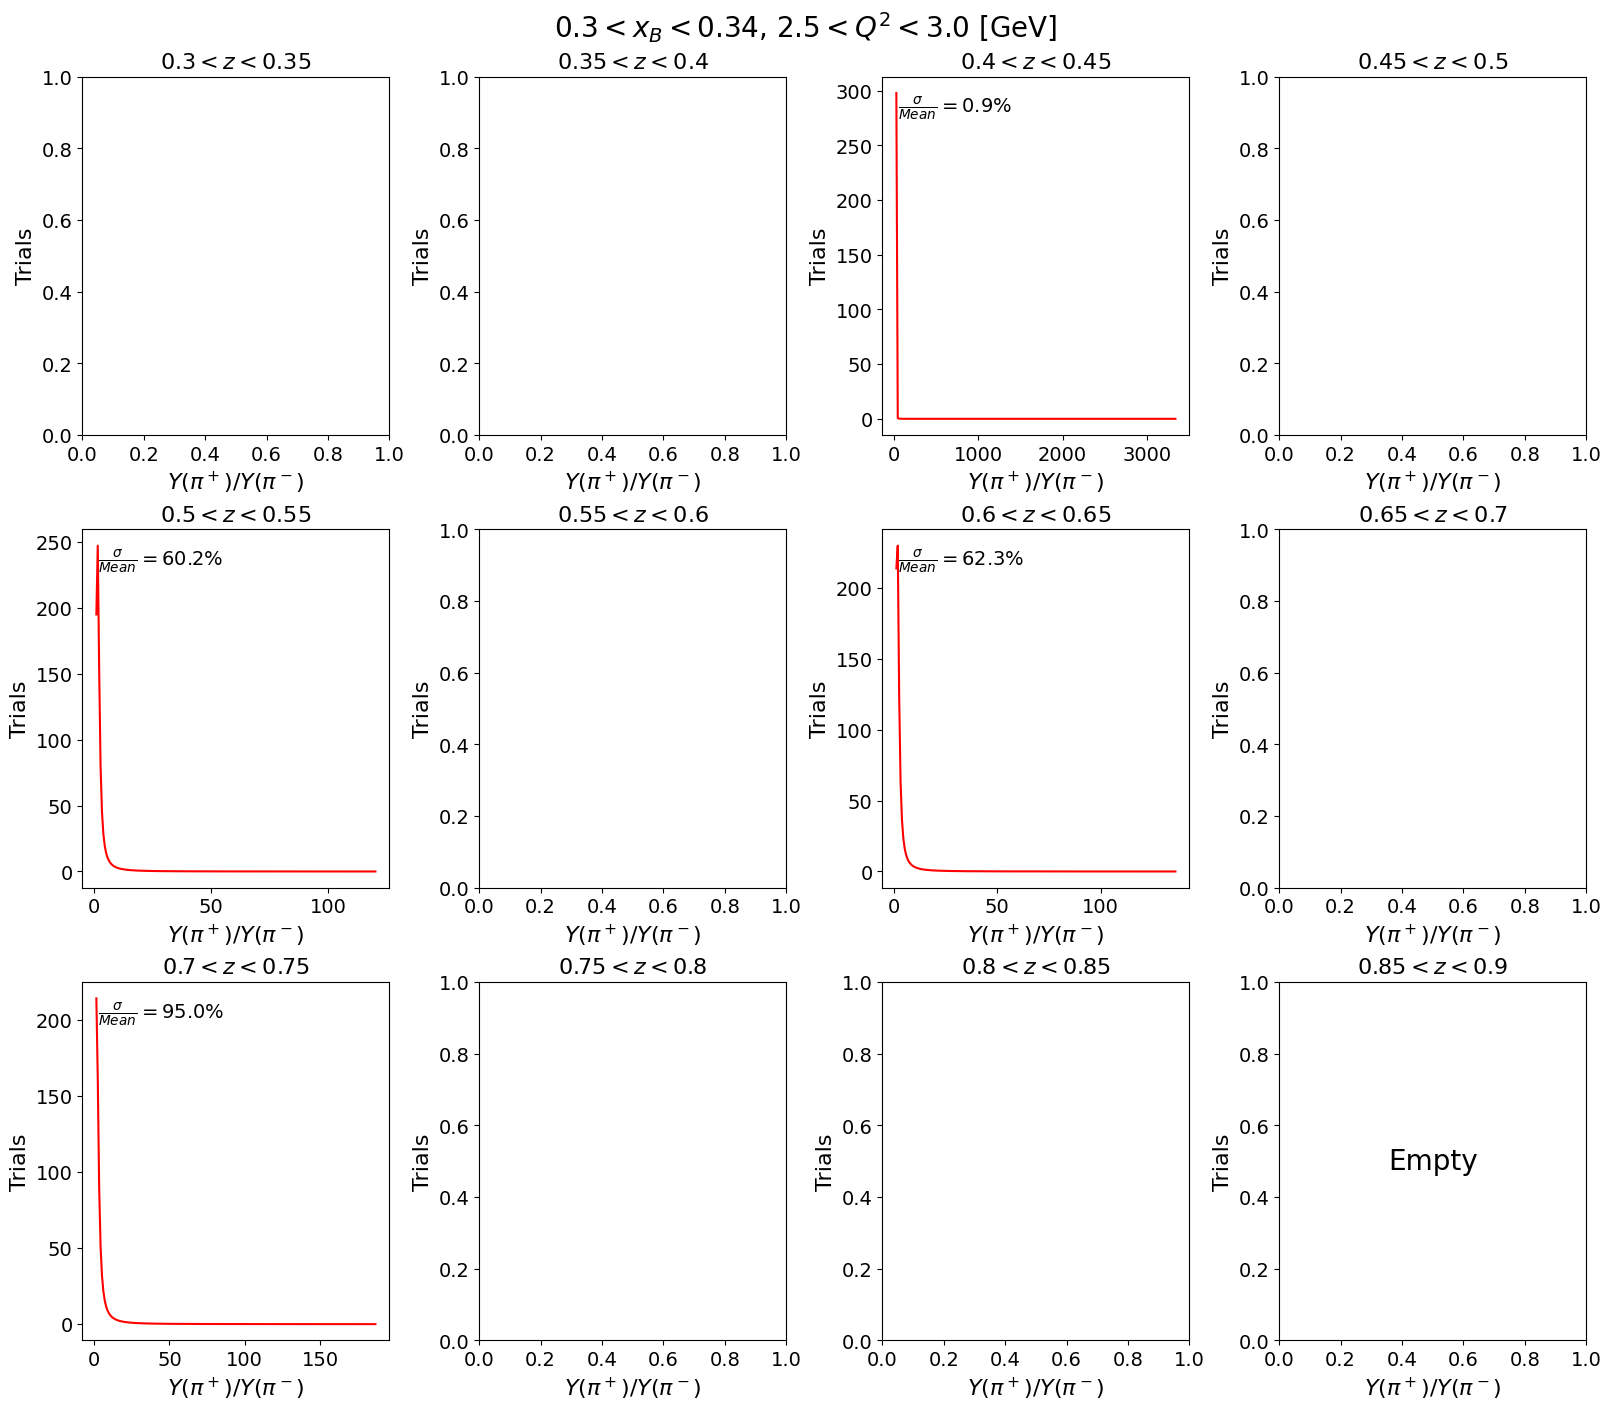

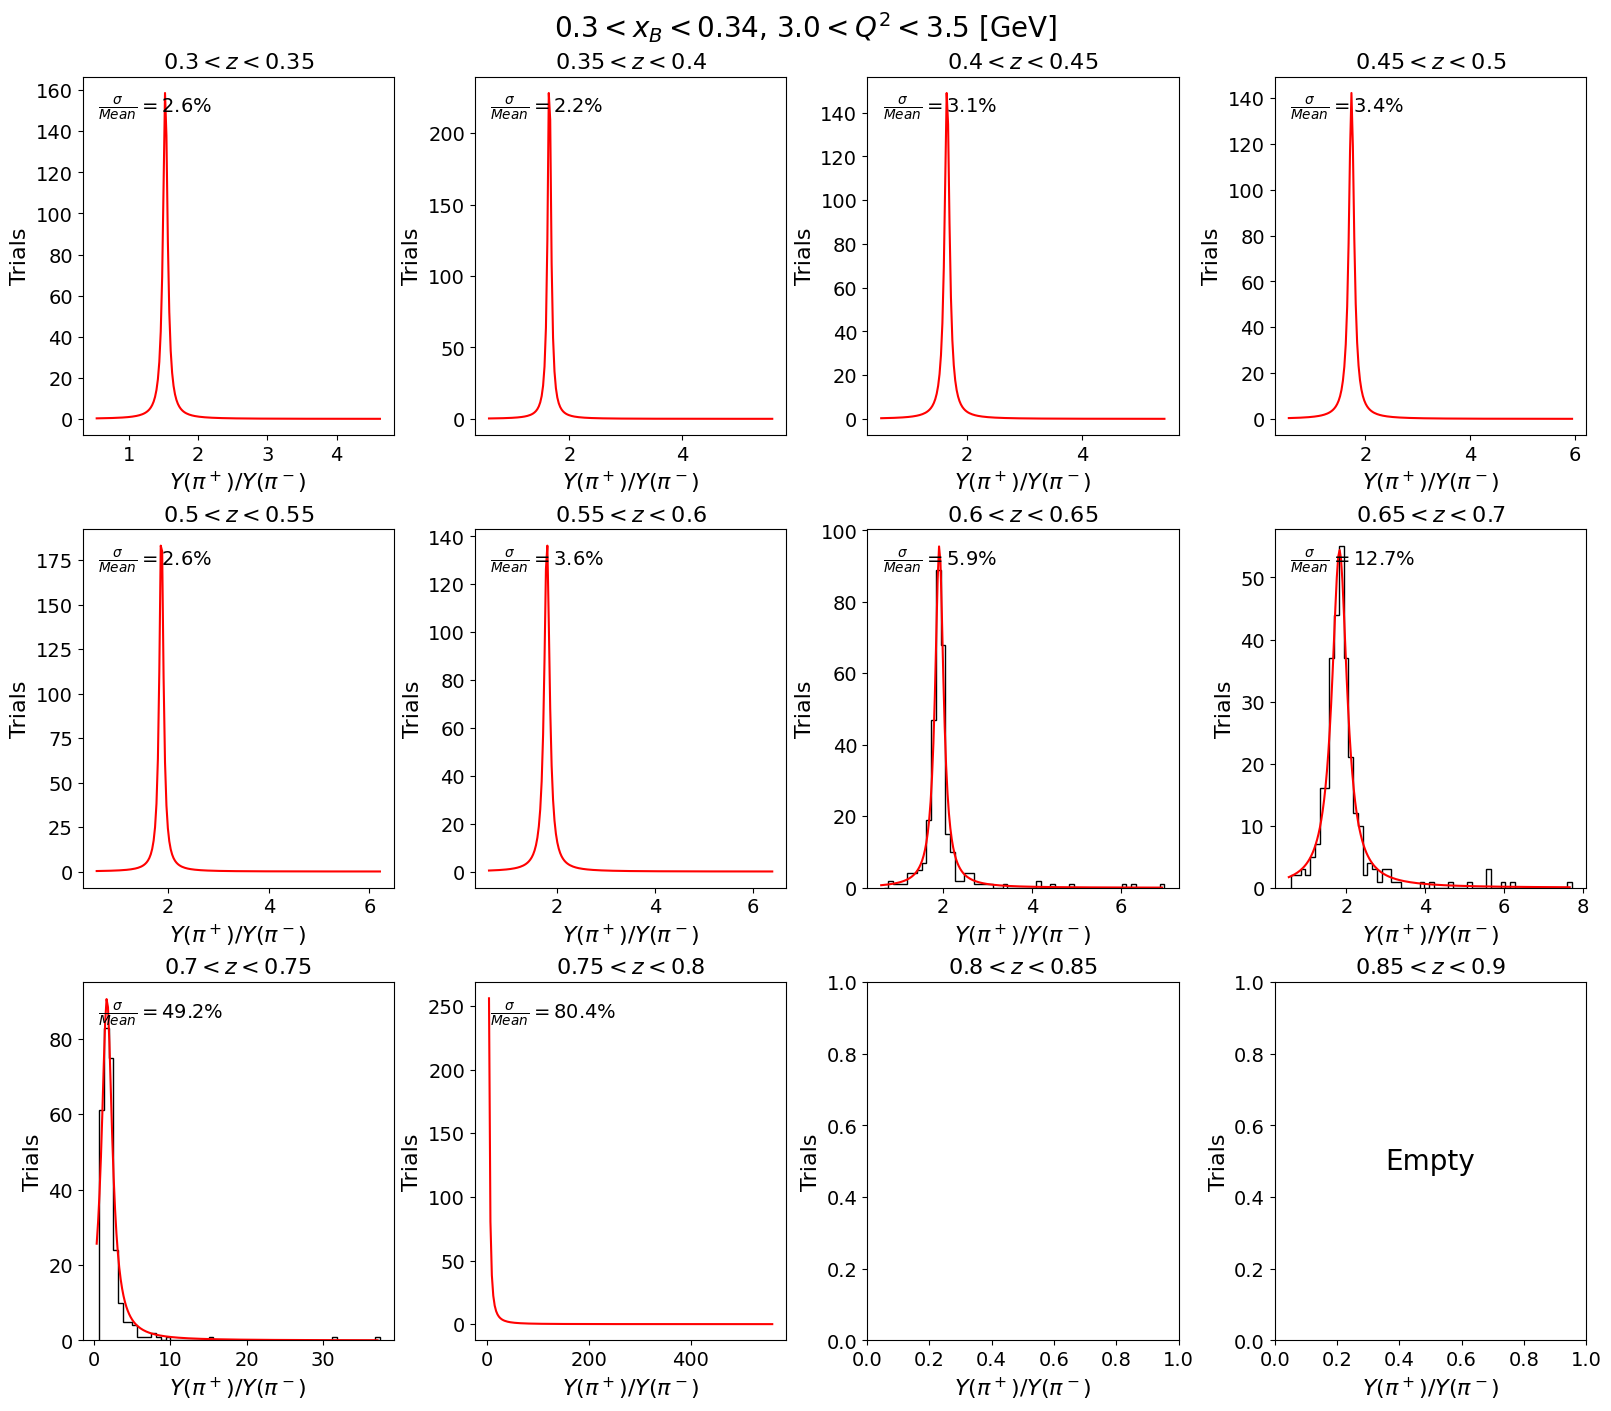

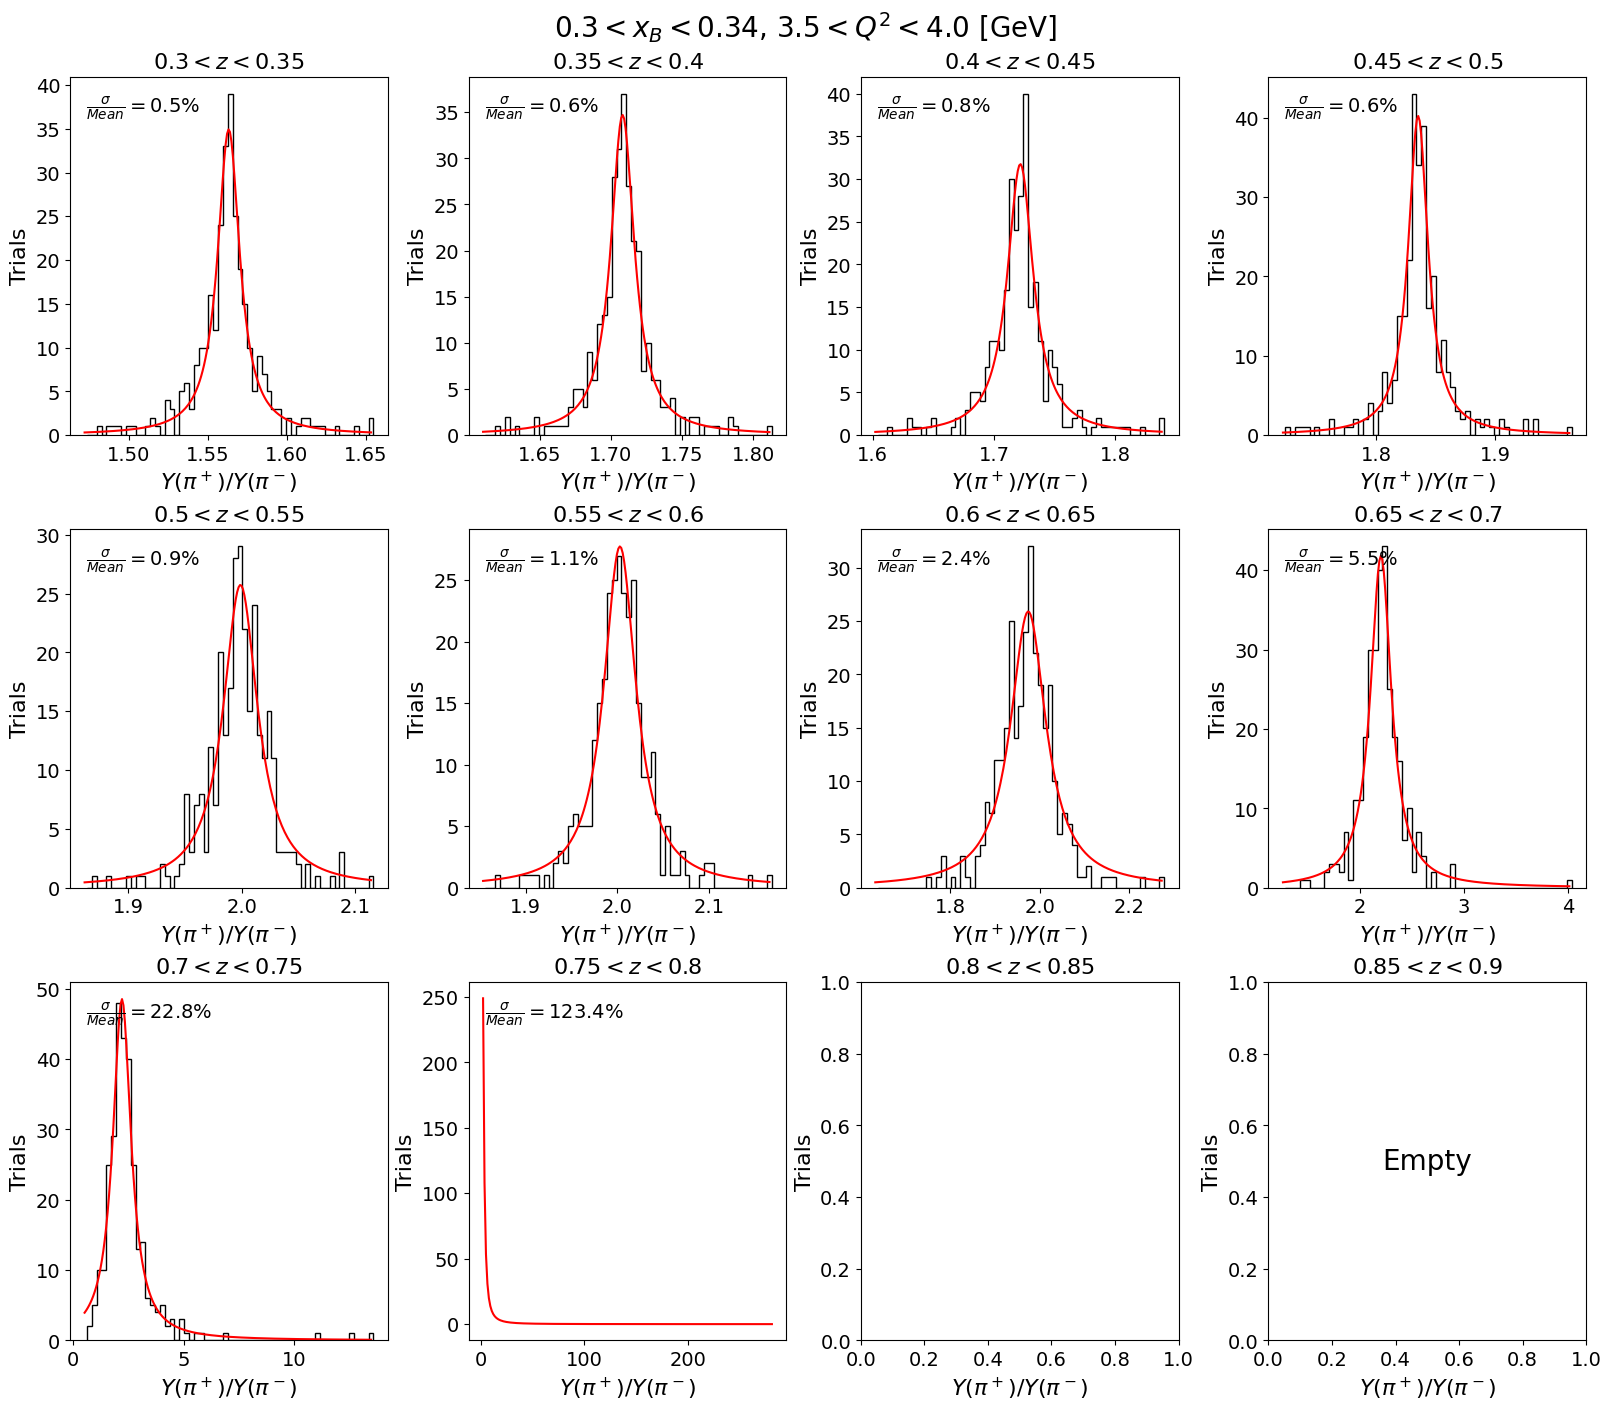

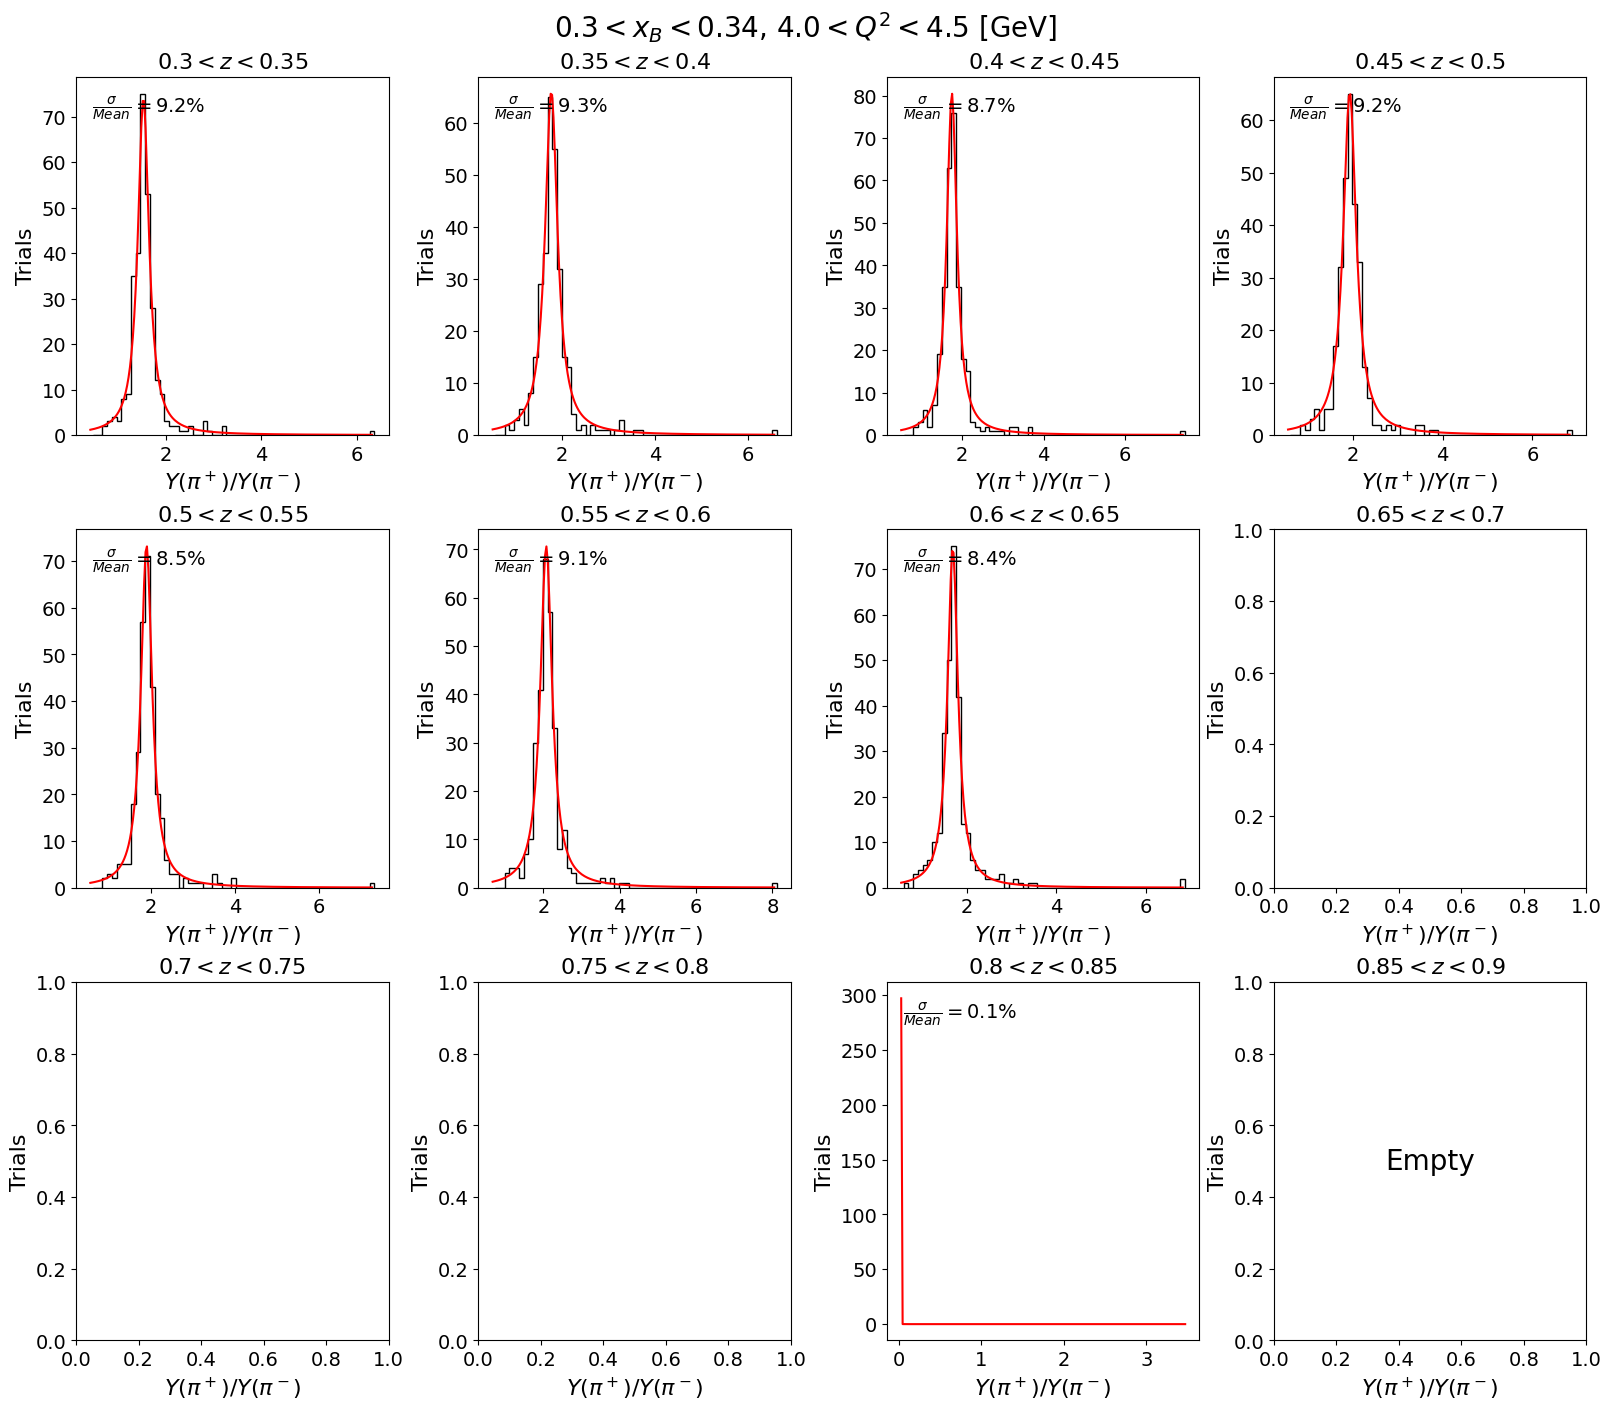

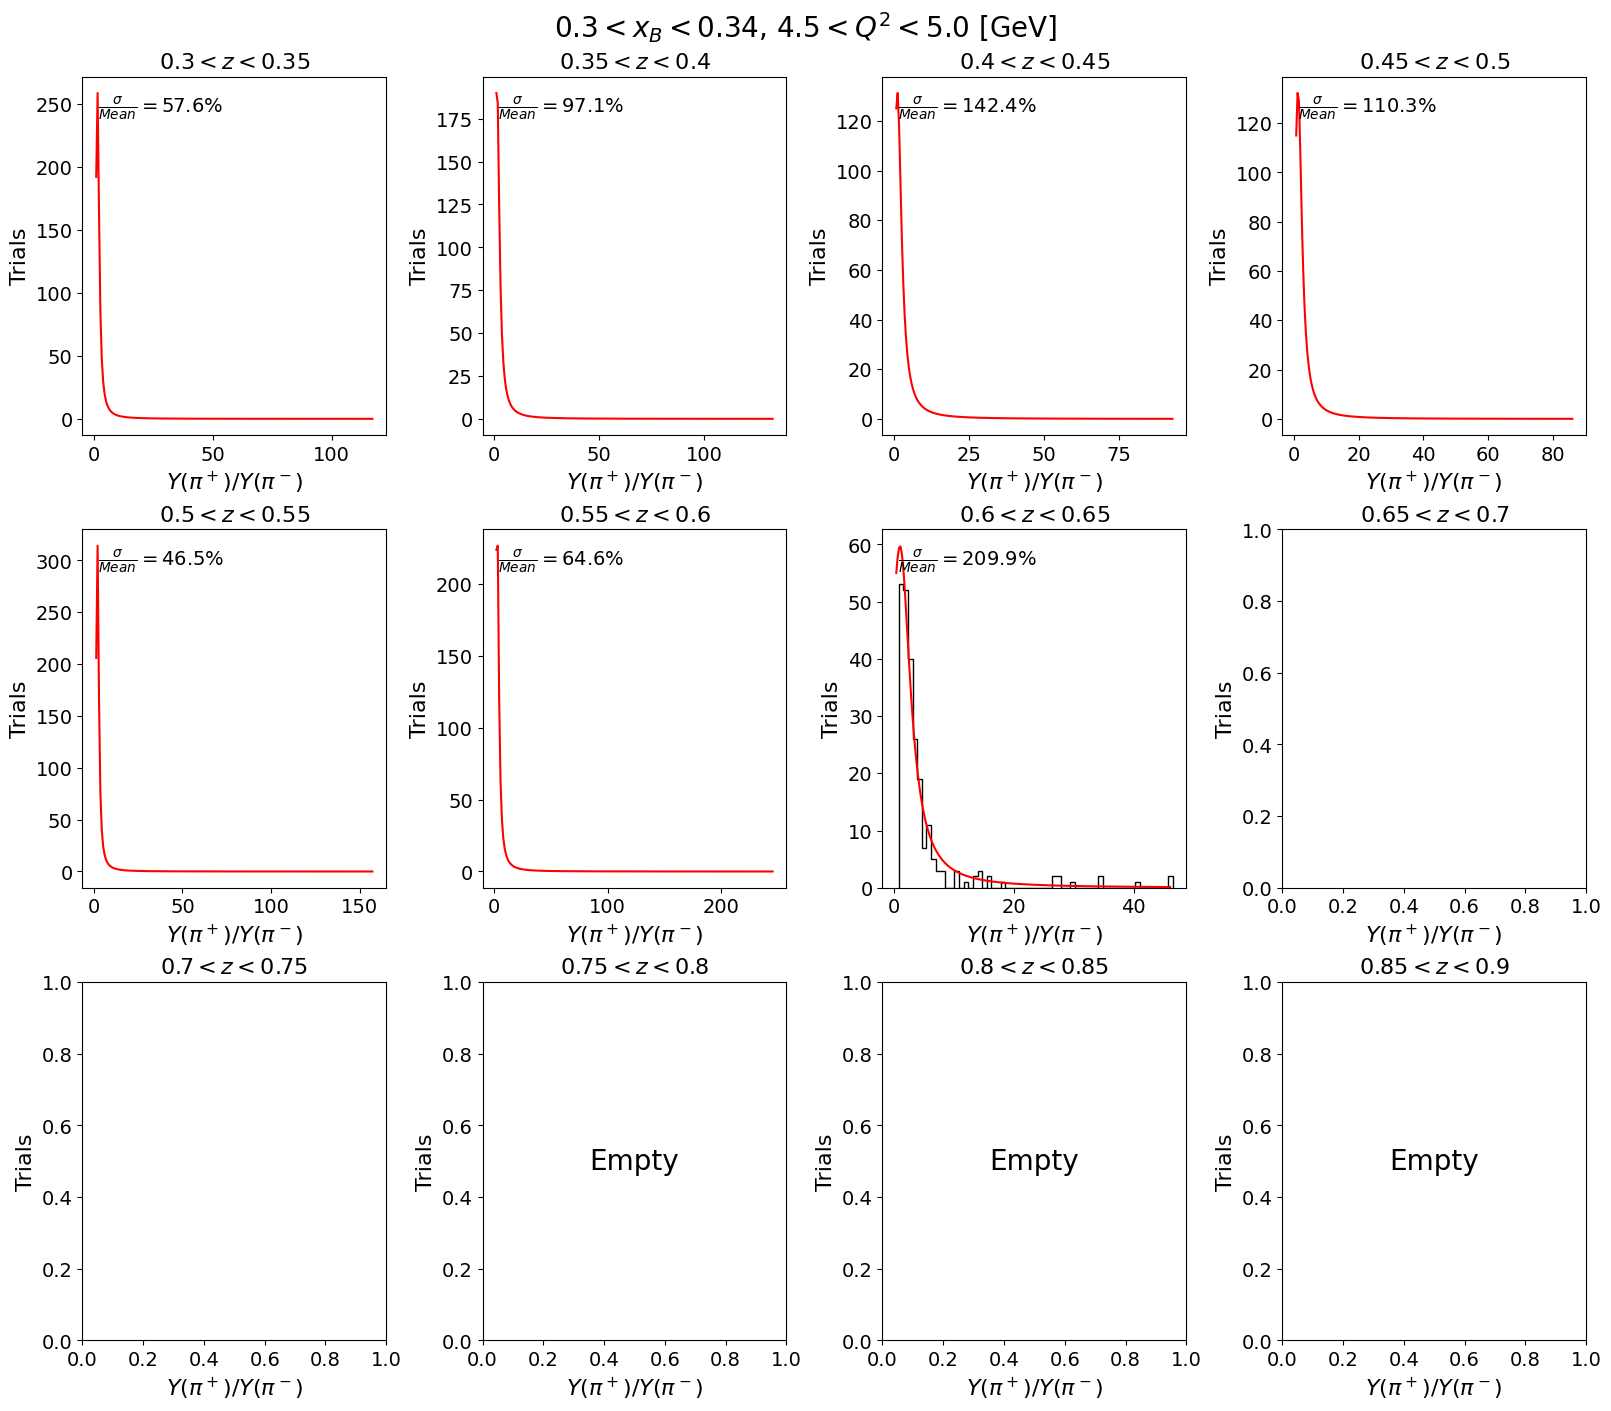

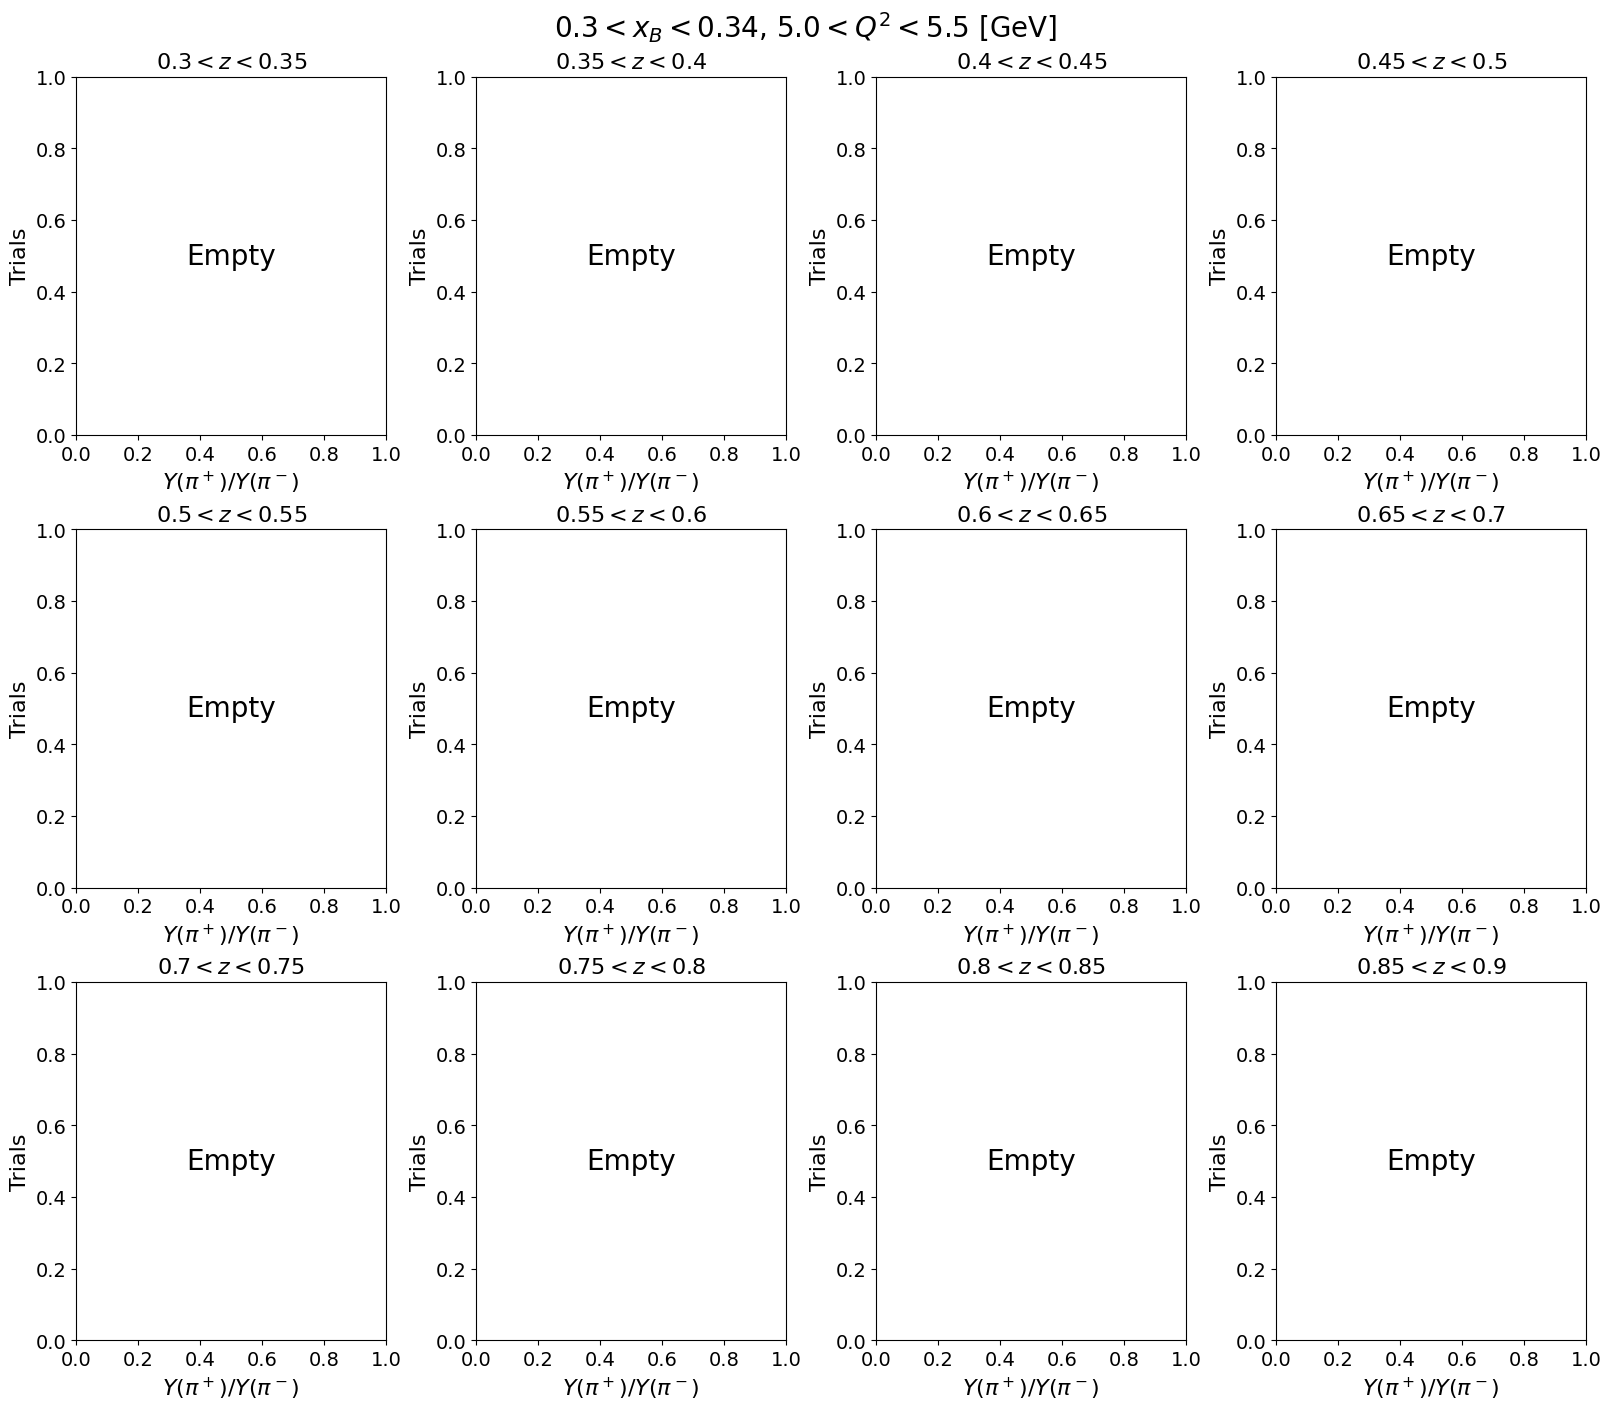

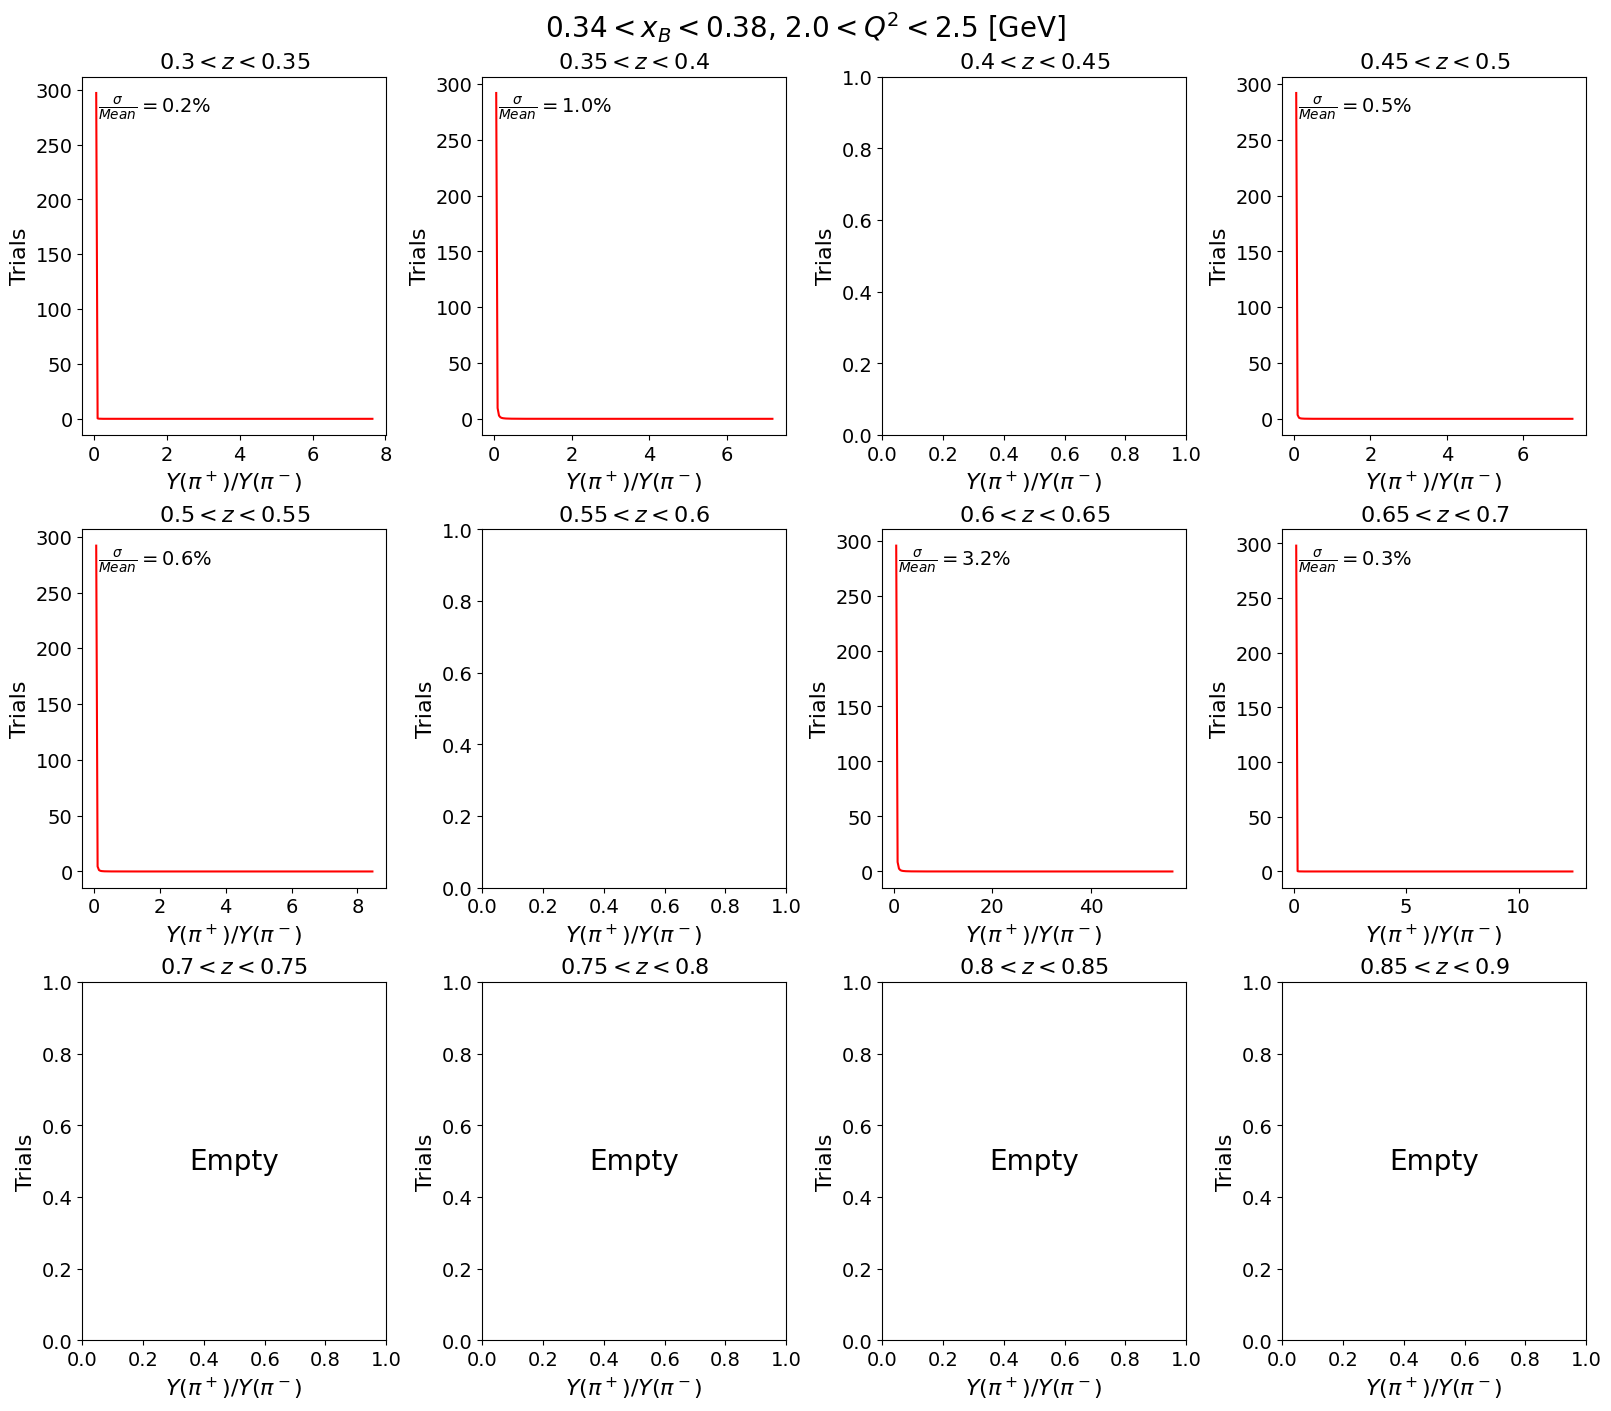

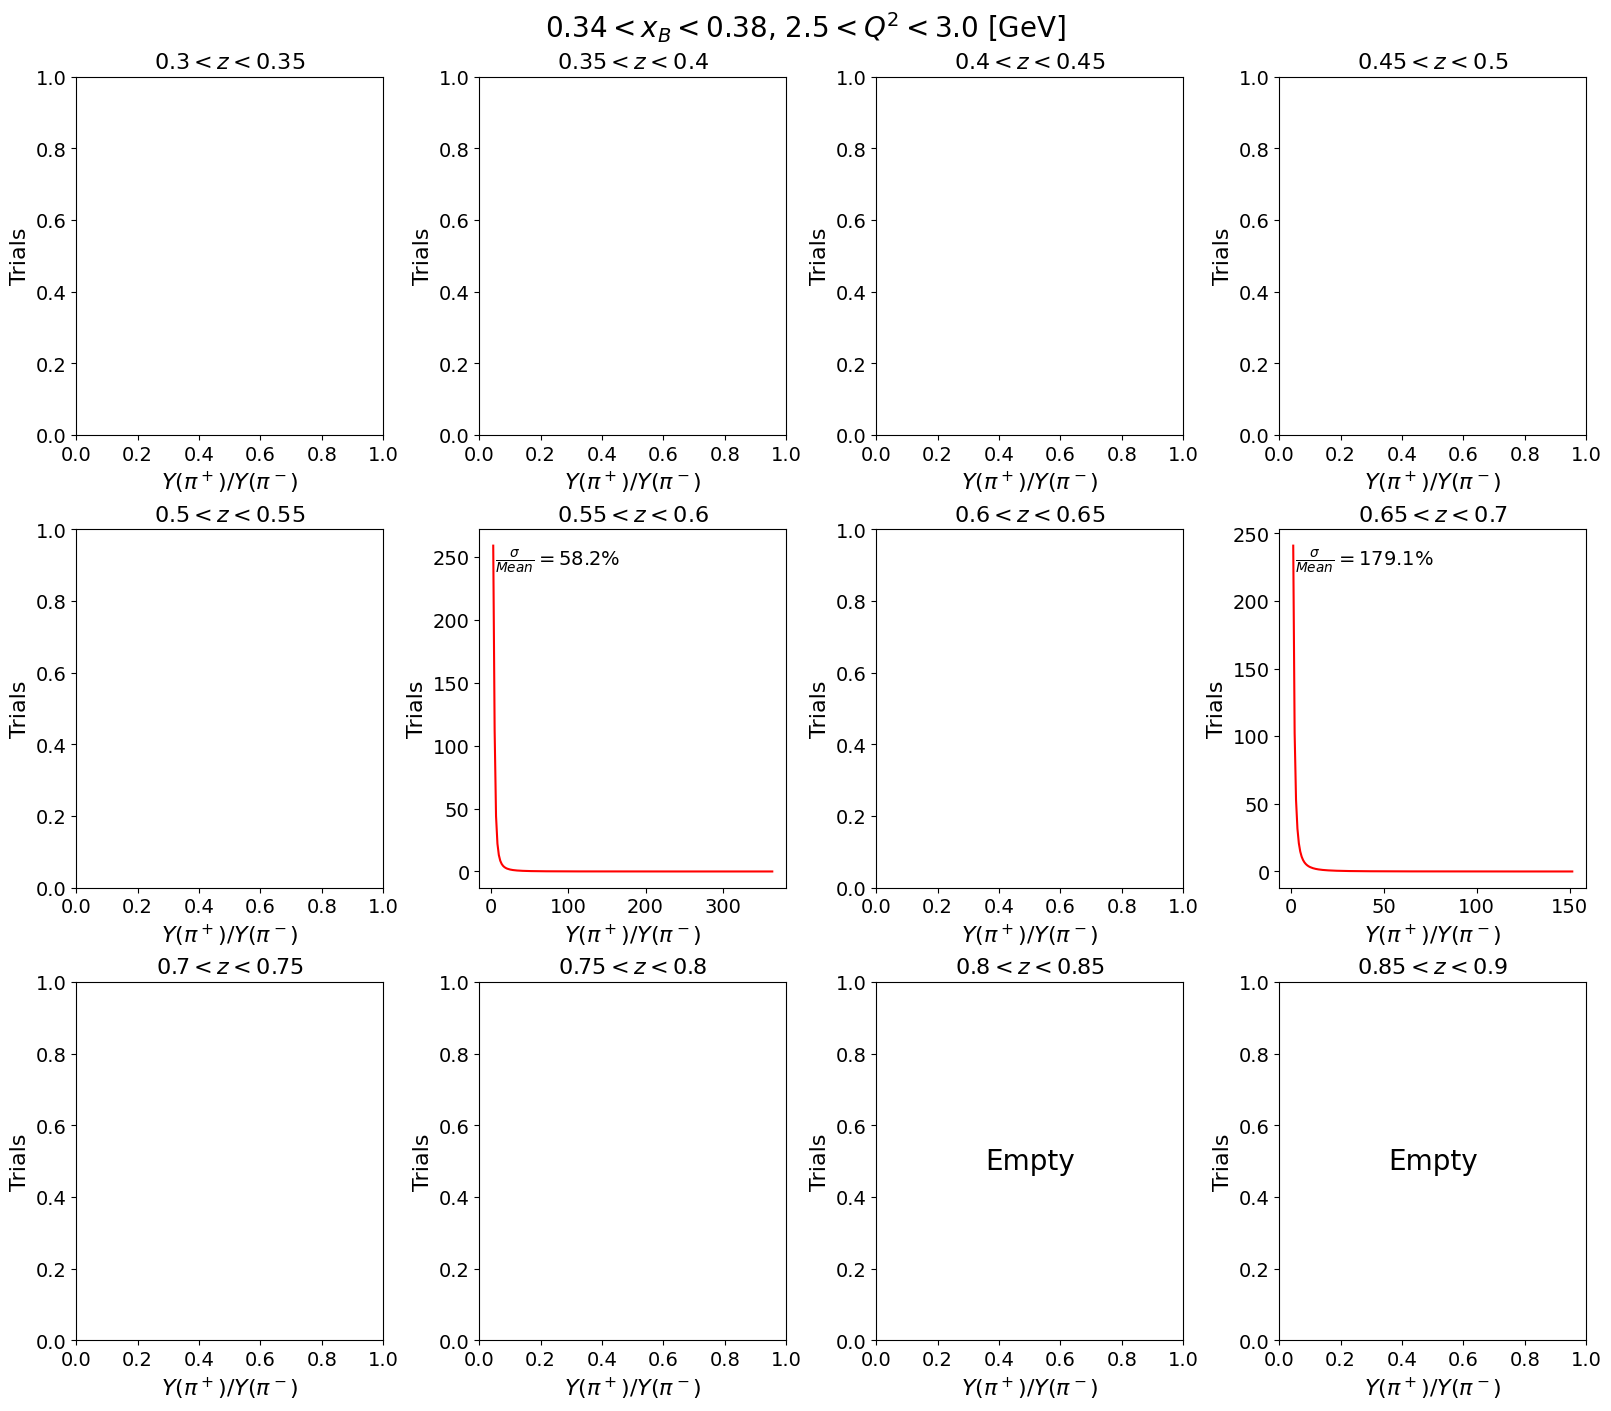

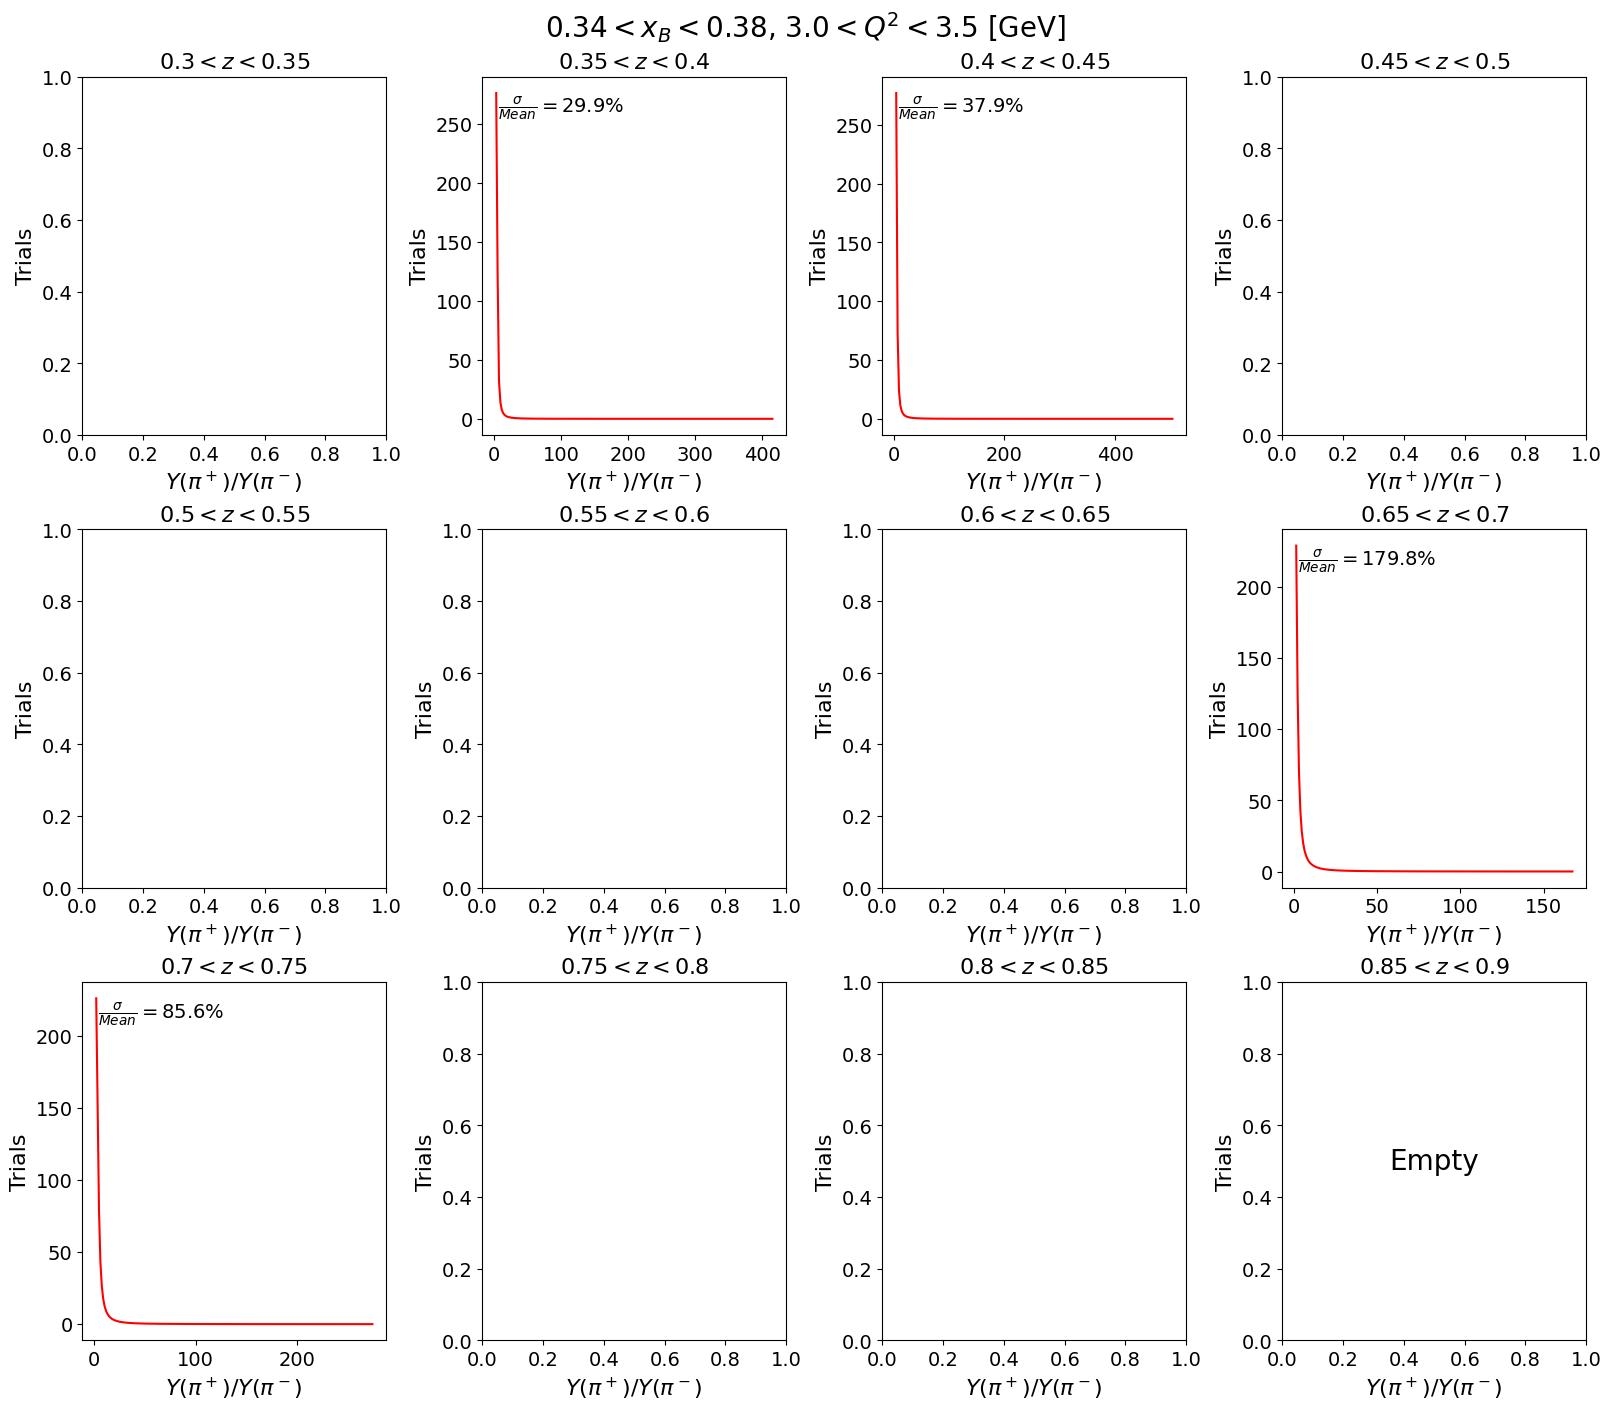

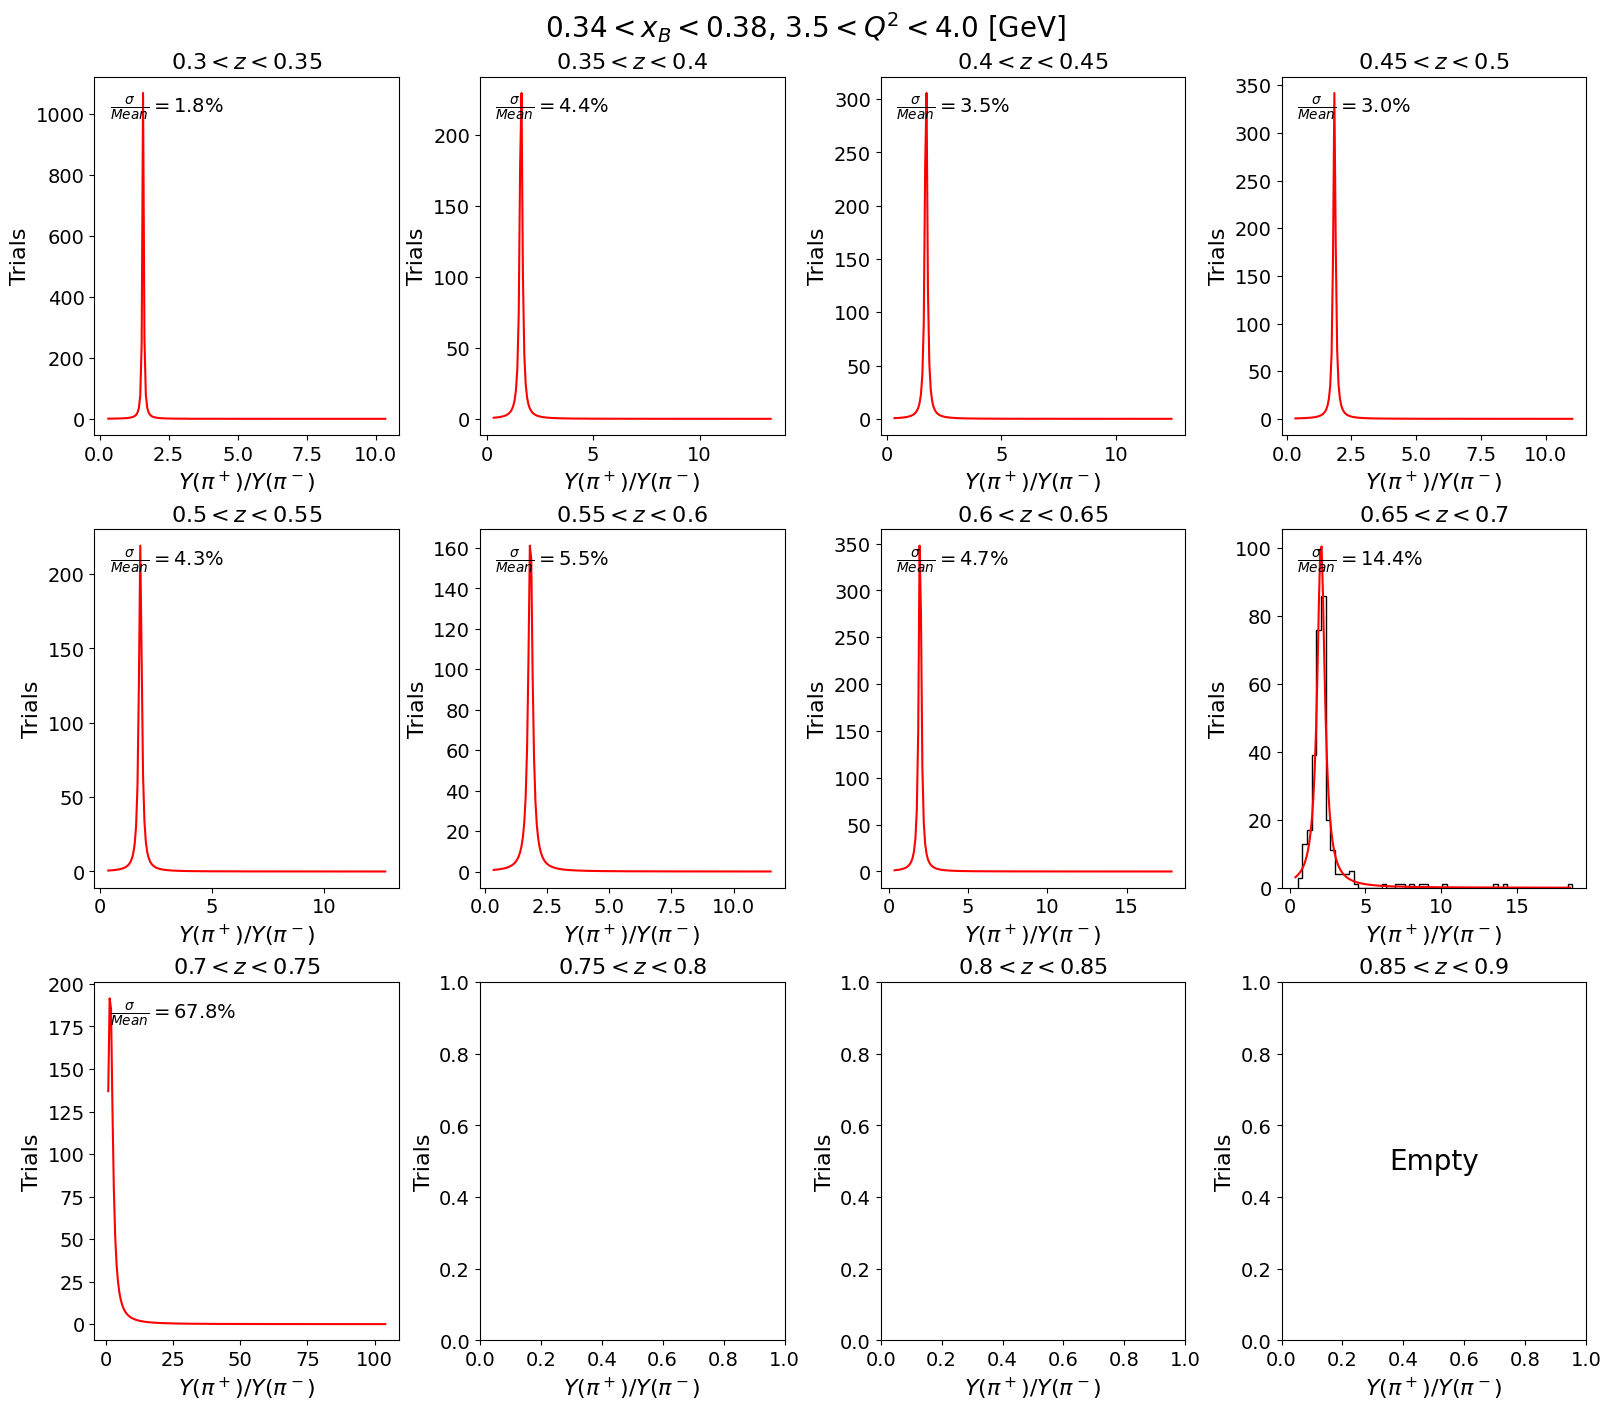

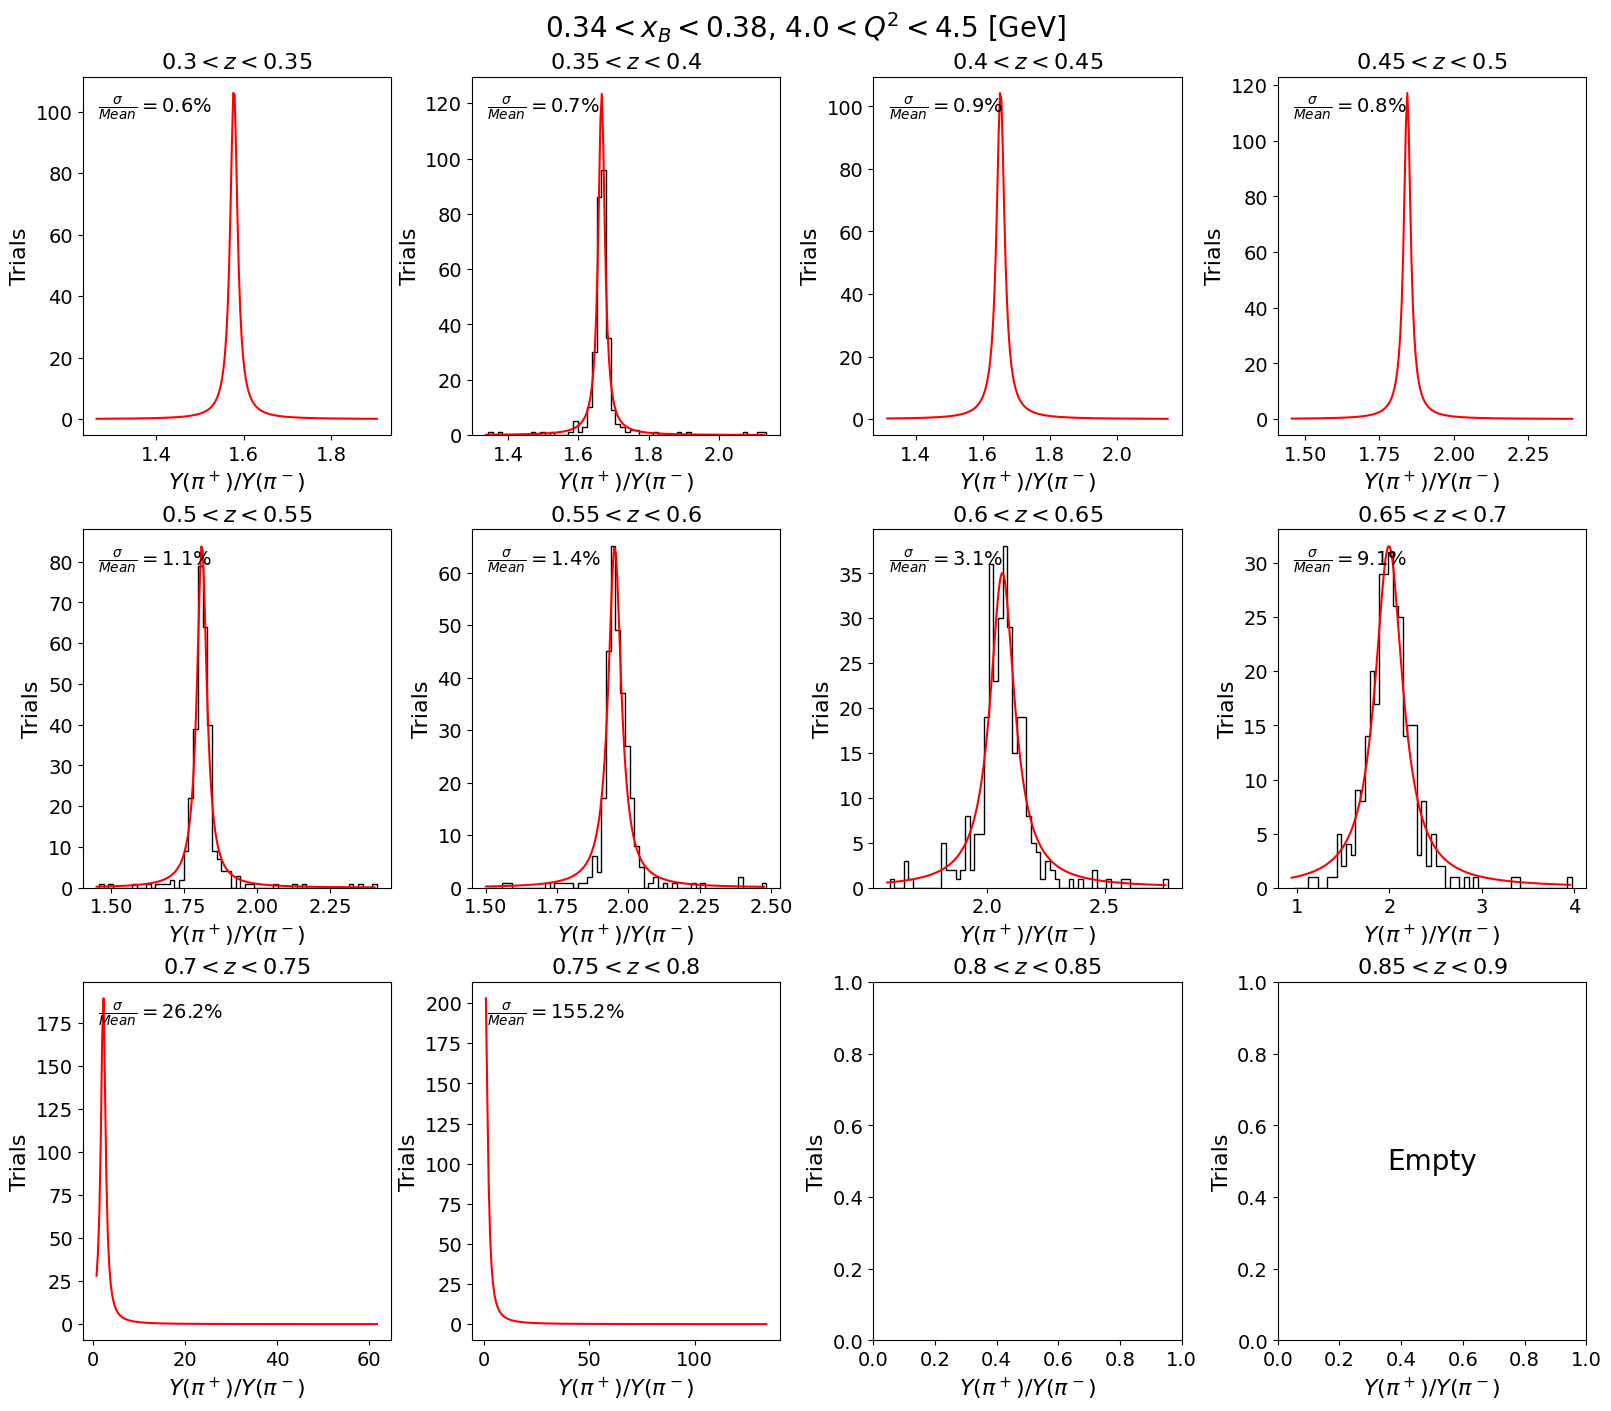

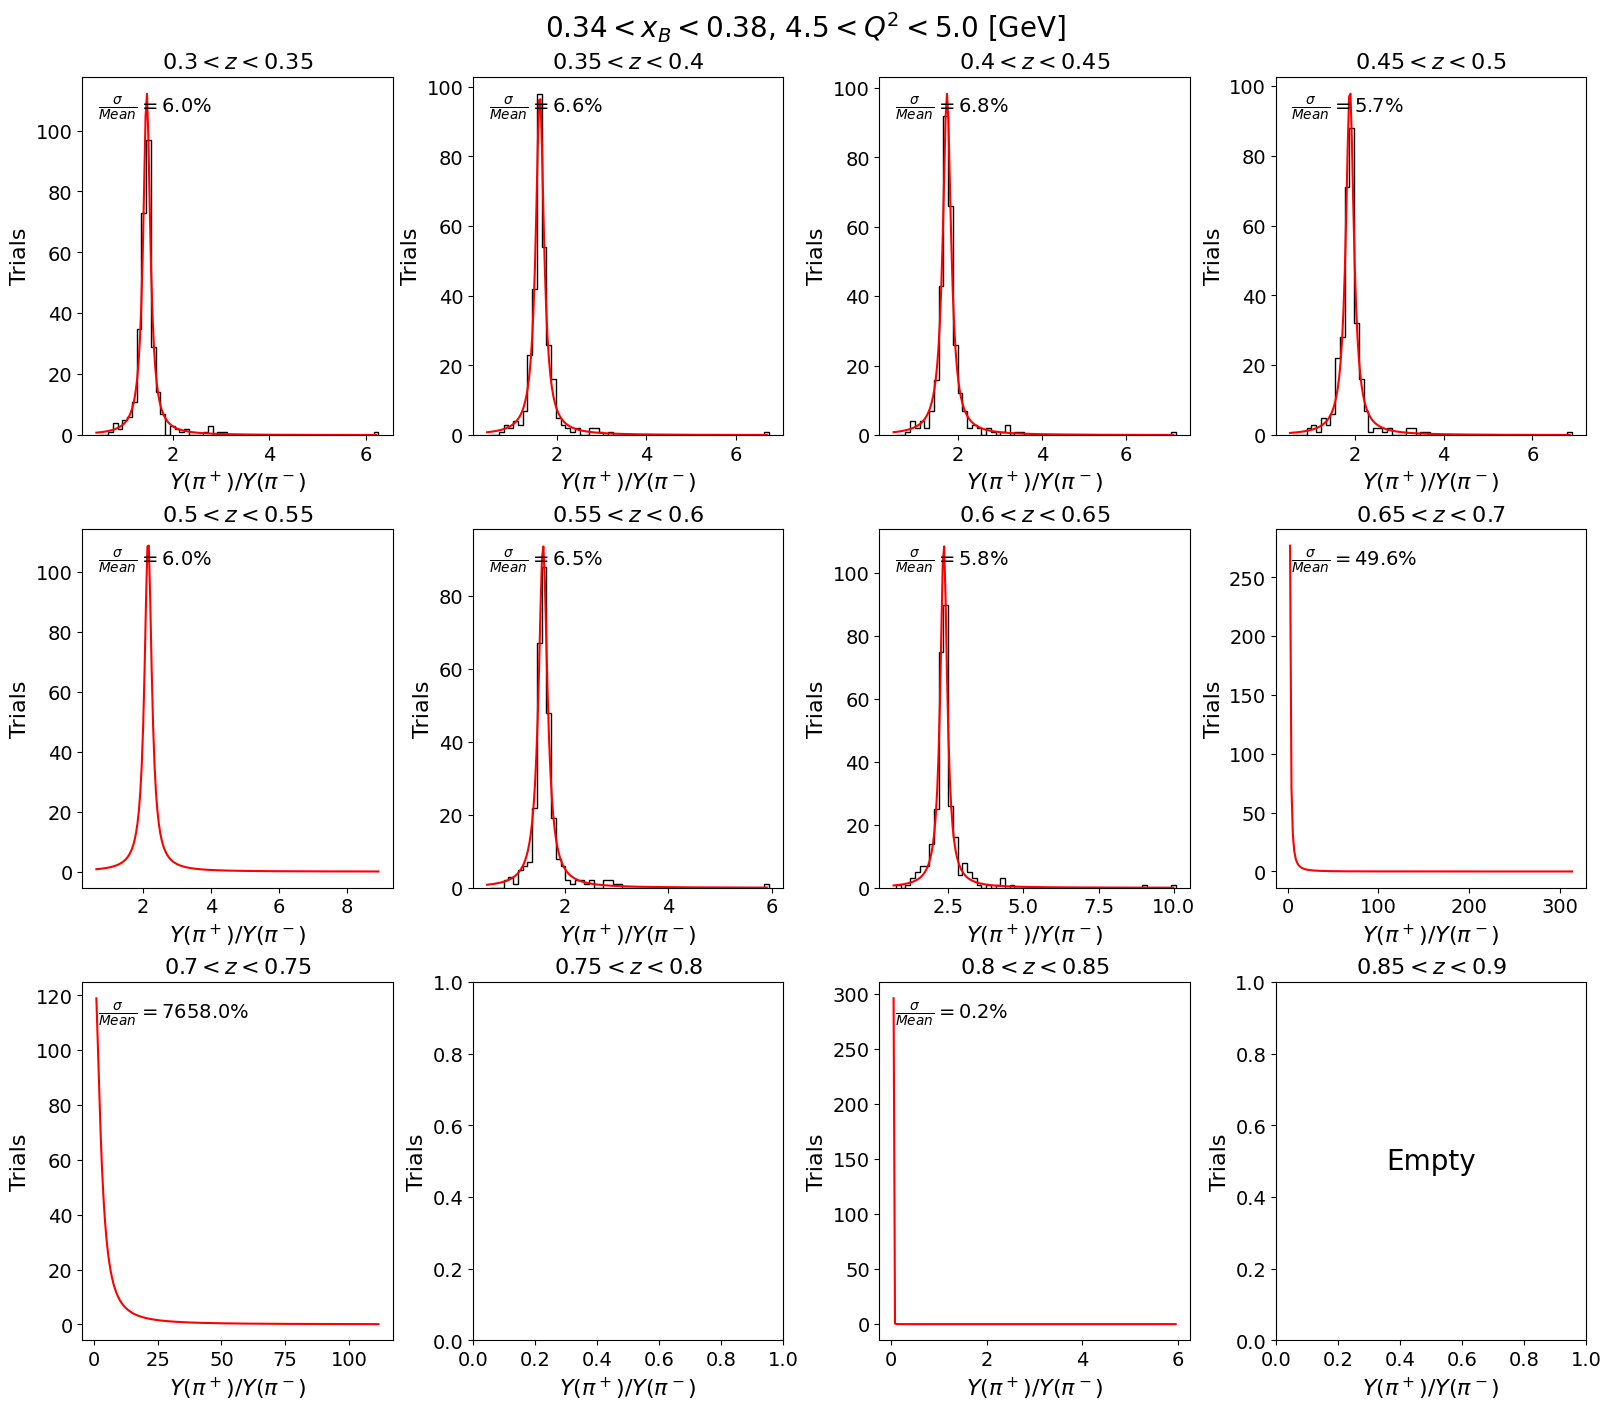

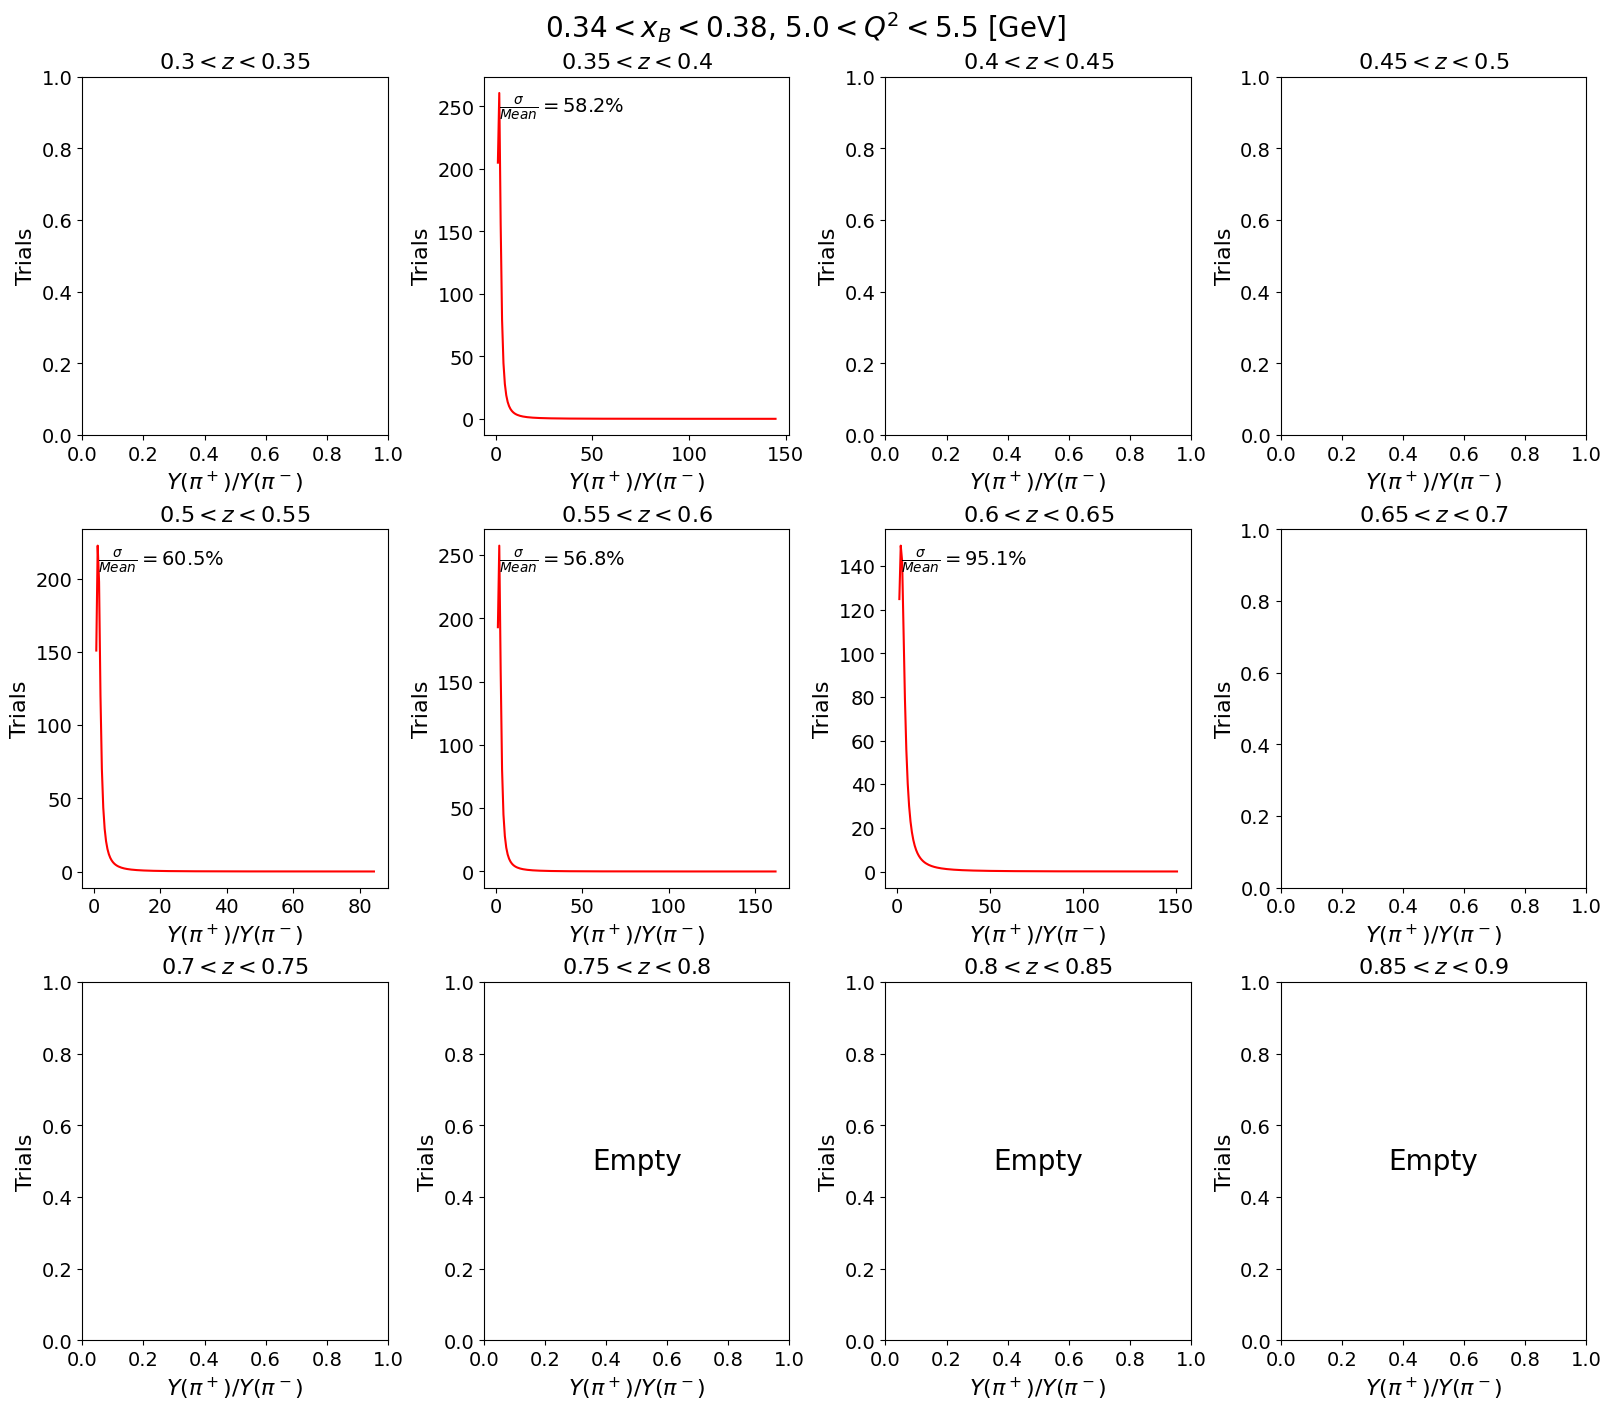

In [12]:
for x in range(1,8):#15):
    for q in range(0,8):#13):
        condition_pip = (data_pip[:,0]==x) & (data_pip[:,1]==q)
        selected_pip = np.transpose(data_pip[condition_pip])
    

        condition_pim = (data_pim[:,0]==x) & (data_pim[:,1]==q)
        selected_pim = np.transpose(data_pim[condition_pim])


        sum_pip = 0
        sum_pim = 0

        
        for z in range(2, 14):
            sum_pip = sum_pip + np.sum(selected_pip[z,:])
            sum_pim = sum_pim + np.sum(selected_pim[z,:])

        

        #if np.sum( selected_pip[2:]) < 10 or np.sum(selected_pim[2:]) < 10:
        #    continue

        if sum_pip == 0 or sum_pim==0:
            continue
        fig, axs = plt.subplots(3,4, figsize=(16,14), layout='constrained')
        #selected_pip[selected_pip==0] = np.nan
        #selected_pim[selected_pim==0] = np.nan

        xmin = 0.1 + (x-1)*0.04
        xmax = 0.1 + (x)*0.04
        qmin = 2 + (q-1)*0.5
        qmax = 2 + (q)*0.5
        fig.suptitle(rf'${xmin:0.2} < x_B < {xmax:0.2}$, ${qmin} < Q^2 < {qmax}$ [GeV]', fontsize=20)

        for bin in range(12):
            axs[math.floor(bin/4), bin%4].set_title(r"${0:.2} < z < {1:.2}$".format( 0.3 + 0.05*bin, 0.3 + 0.05*(bin+1.)), fontsize=16)
            axs[math.floor(bin/4), bin%4].set_ylabel('Trials', fontsize=16)
            axs[math.floor(bin/4), bin%4].set_xlabel(r'$Y(\pi^+)/Y(\pi^-)$', fontsize=16)
            axs[math.floor(bin/4), bin%4].tick_params(axis='both', labelsize=14)
      

            selected = selected_pip[bin+2]/selected_pim[bin+2]
            #selected = (4 - selected)/(4*selected-1)
    
            
            selected = np.nan_to_num(selected, nan=0.0, posinf=0.0, neginf=0.0)
            #selected = np.nan_to_num(selected, nan=np.nan, posinf=np.nan, neginf=np.nan)

            #selected[selected>5] = 0
            
            counts, bins = np.histogram(selected,60)

            
            
            bin_centres = (bins[:-1] + bins[1:])/2

          
            if np.nansum(counts) < 100 or np.count_nonzero(counts)<=1:
                axs[bin//4, bin%4].text(0.5, 0.5, 'Empty',
                                                       transform=axs[math.floor(bin/4), bin%4].transAxes, va='center', ha='center'
                                                       , fontsize=20)
                continue
            
            if np.max(counts) < 1000 and np.max(counts[1:]) > 0:
                mean = np.average(bin_centres, weights=counts)
                std = np.sqrt( np.average( (bin_centres - mean)**2, weights=counts) )
               #p2 = [ np.max(counts), bin_centres[np.argmax(counts)], std, np.max(counts)/20, bin_centres[np.argmax(counts)], 10*std]
                p0 = [ np.max(counts), bin_centres[np.argmax(counts)], std ]

                #axs[bin//4, bin%4].set_xlim( mean-3.75*std, mean+3.75*std)

                try:
                    coeff, var_matrix = curve_fit(lorentz, bin_centres, counts, p0=p0)
                    x_ax = np.linspace(bin_centres[0], bin_centres[-1], 200)
            
                    axs[math.floor(bin/4), bin%4].plot( x_ax, lorentz(x_ax, *coeff), color='r')
                    axs[math.floor(bin/4), bin%4].text(0.05, 0.95, r'$\frac{\sigma}{Mean}' + '= {0:.1f}$%'.format(100*abs(coeff[2])/coeff[1]),
                                                       transform=axs[math.floor(bin/4), bin%4].transAxes, va='top', ha='left', fontsize=14)
            
                    if np.max(counts) < 100:
                        axs[math.floor(bin/4), bin%4].stairs(counts[1:], bins[1:], color='k')  
                        mean = np.average(bin_centres, weights=counts)
                        td = np.sqrt( np.average( (bin_centres - mean)**2, weights=counts) )
                except:
                    print('no fit')
                #axs[math.floor(bin/4), bin%4].set_xlim(0,10)
                #axs[math.floor(bin/4), bin%4].text( coeff[1]+coeff[2], coeff[0], r'$\sigma/Mean' + '= {0:.1f}$%'.format(100*std/mean))

        
            



In [10]:
x=2
q=1
condition_pip = (data_pip[:,0]==x) & (data_pip[:,1]==q)
selected_pip = data_pip[condition_pip]
        
condition_pim = (data_pim[:,0]==x) & (data_pim[:,1]==q)
selected_pim = data_pim[condition_pim]

pip_counts = selected_pip[6:,3]
pim_counts = selected_pim[6:,3]
ratio = pip_counts/pim_counts
ratio = (4-ratio)/(4*ratio-1)

mask = selected_pip[6:,36] < 3.01

for cut in range(16,43):   
   
    cuts = selected_pip[6:,cut]


    plt.figure(figsize=(6, 4))          # <-- new figure every iteration
    #plt.scatter(cuts[mask], ratio[mask], marker='.')
    plt.hist(cuts[mask])
    #plt.ylim(0, 3)
    plt.title(f"Cut index = {cut}")
    plt.xlabel("selected_pip[2:, cut]")
    plt.ylabel("ratio")

IndexError: index 36 is out of bounds for axis 1 with size 16

/scratch/jphelan/tmpfs/ipykernel_3842379/3333428104.py:44: RuntimeWarning: invalid value encountered in divide
  raw = selected_pip[bin + 2, :] / selected_pim[bin + 2, :]


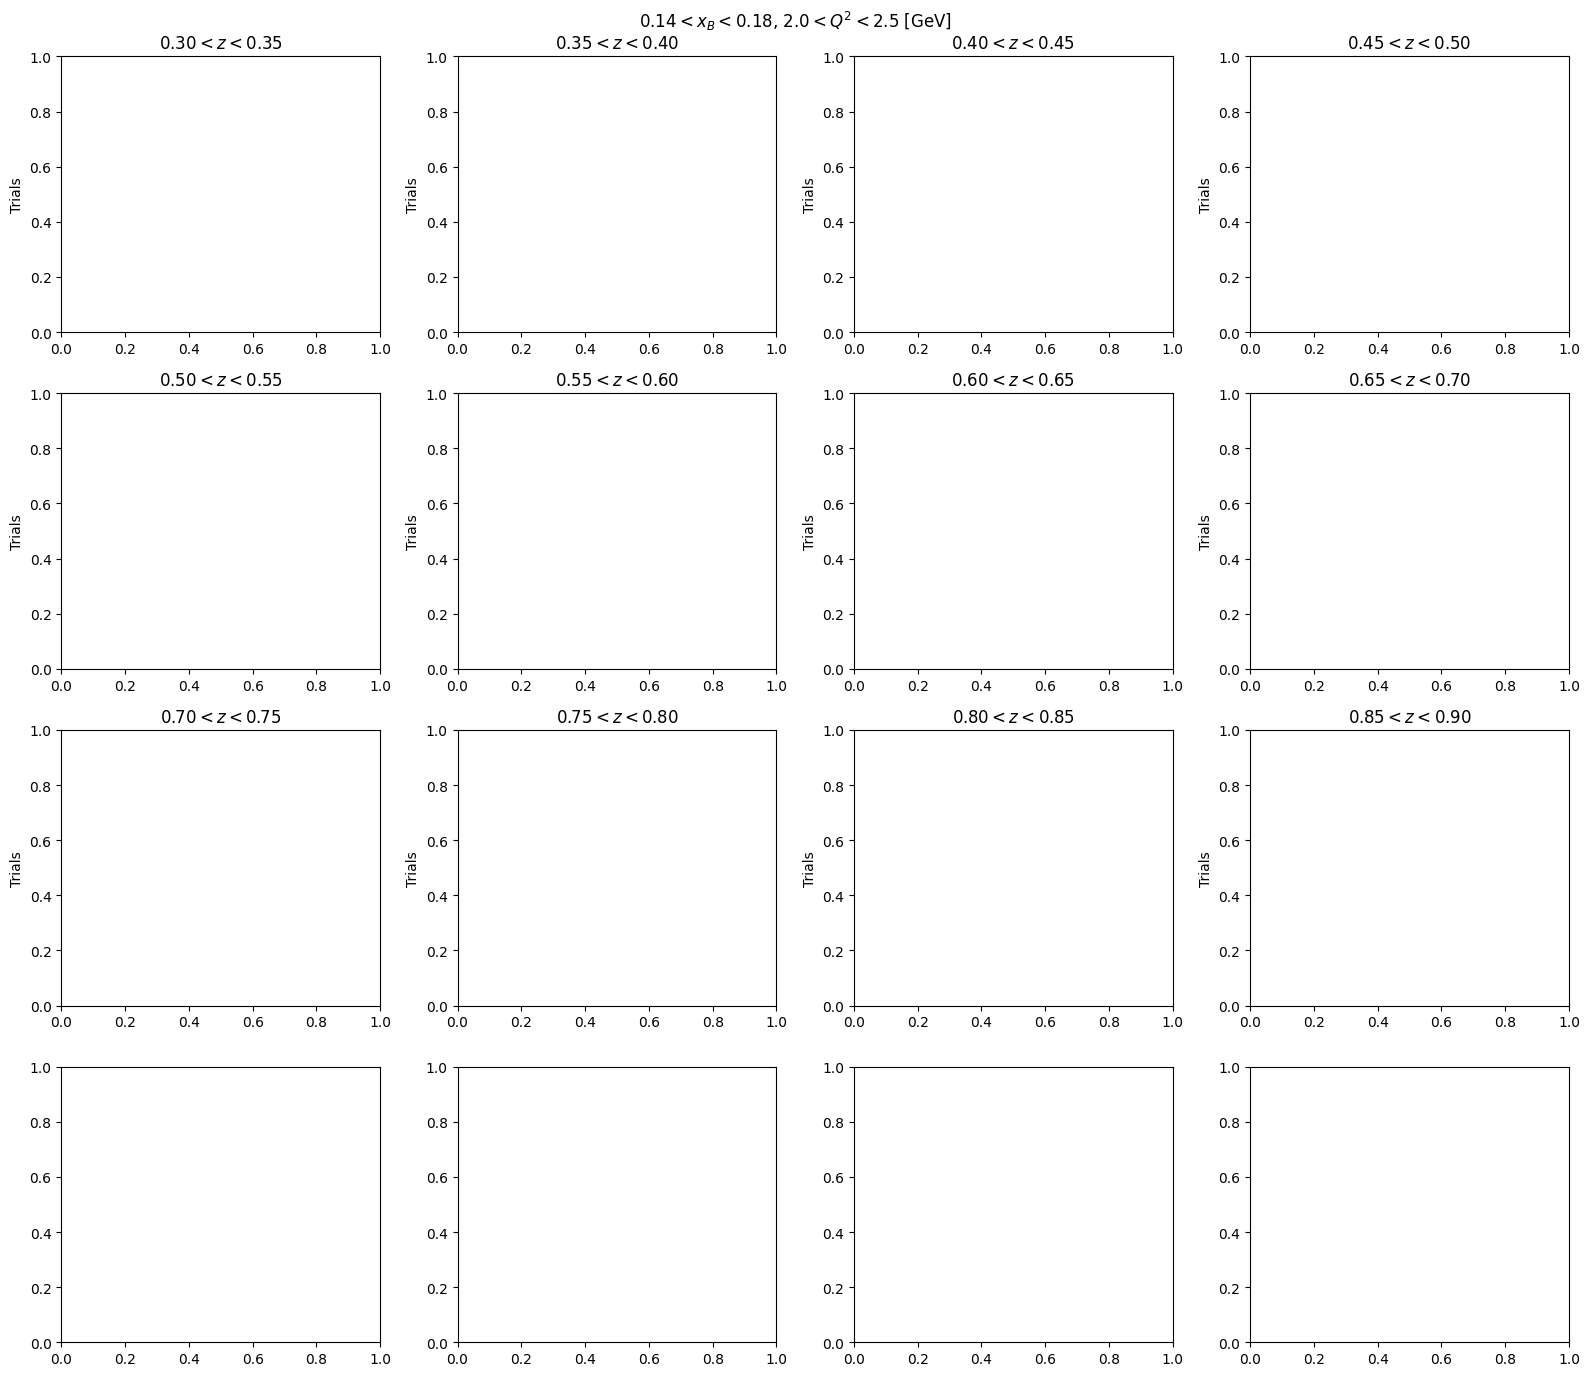

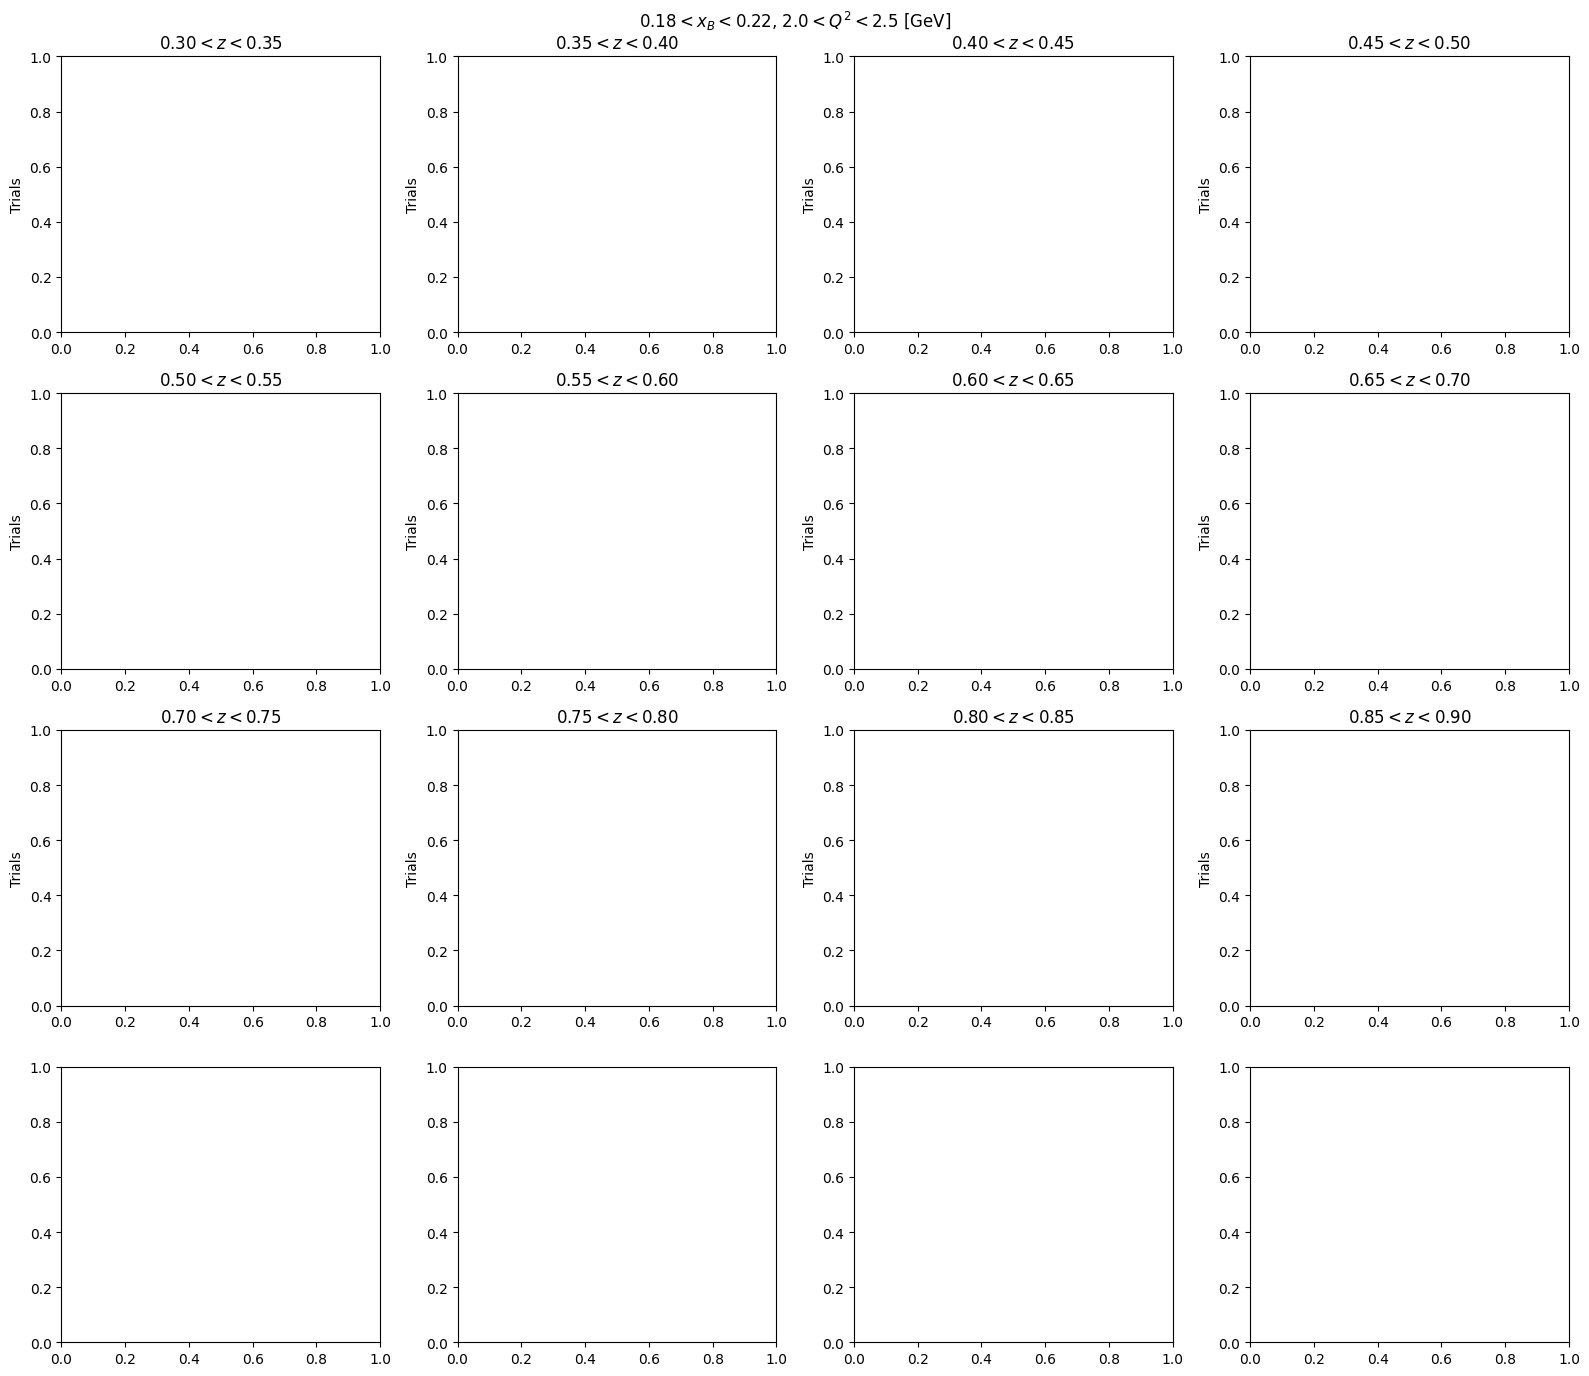

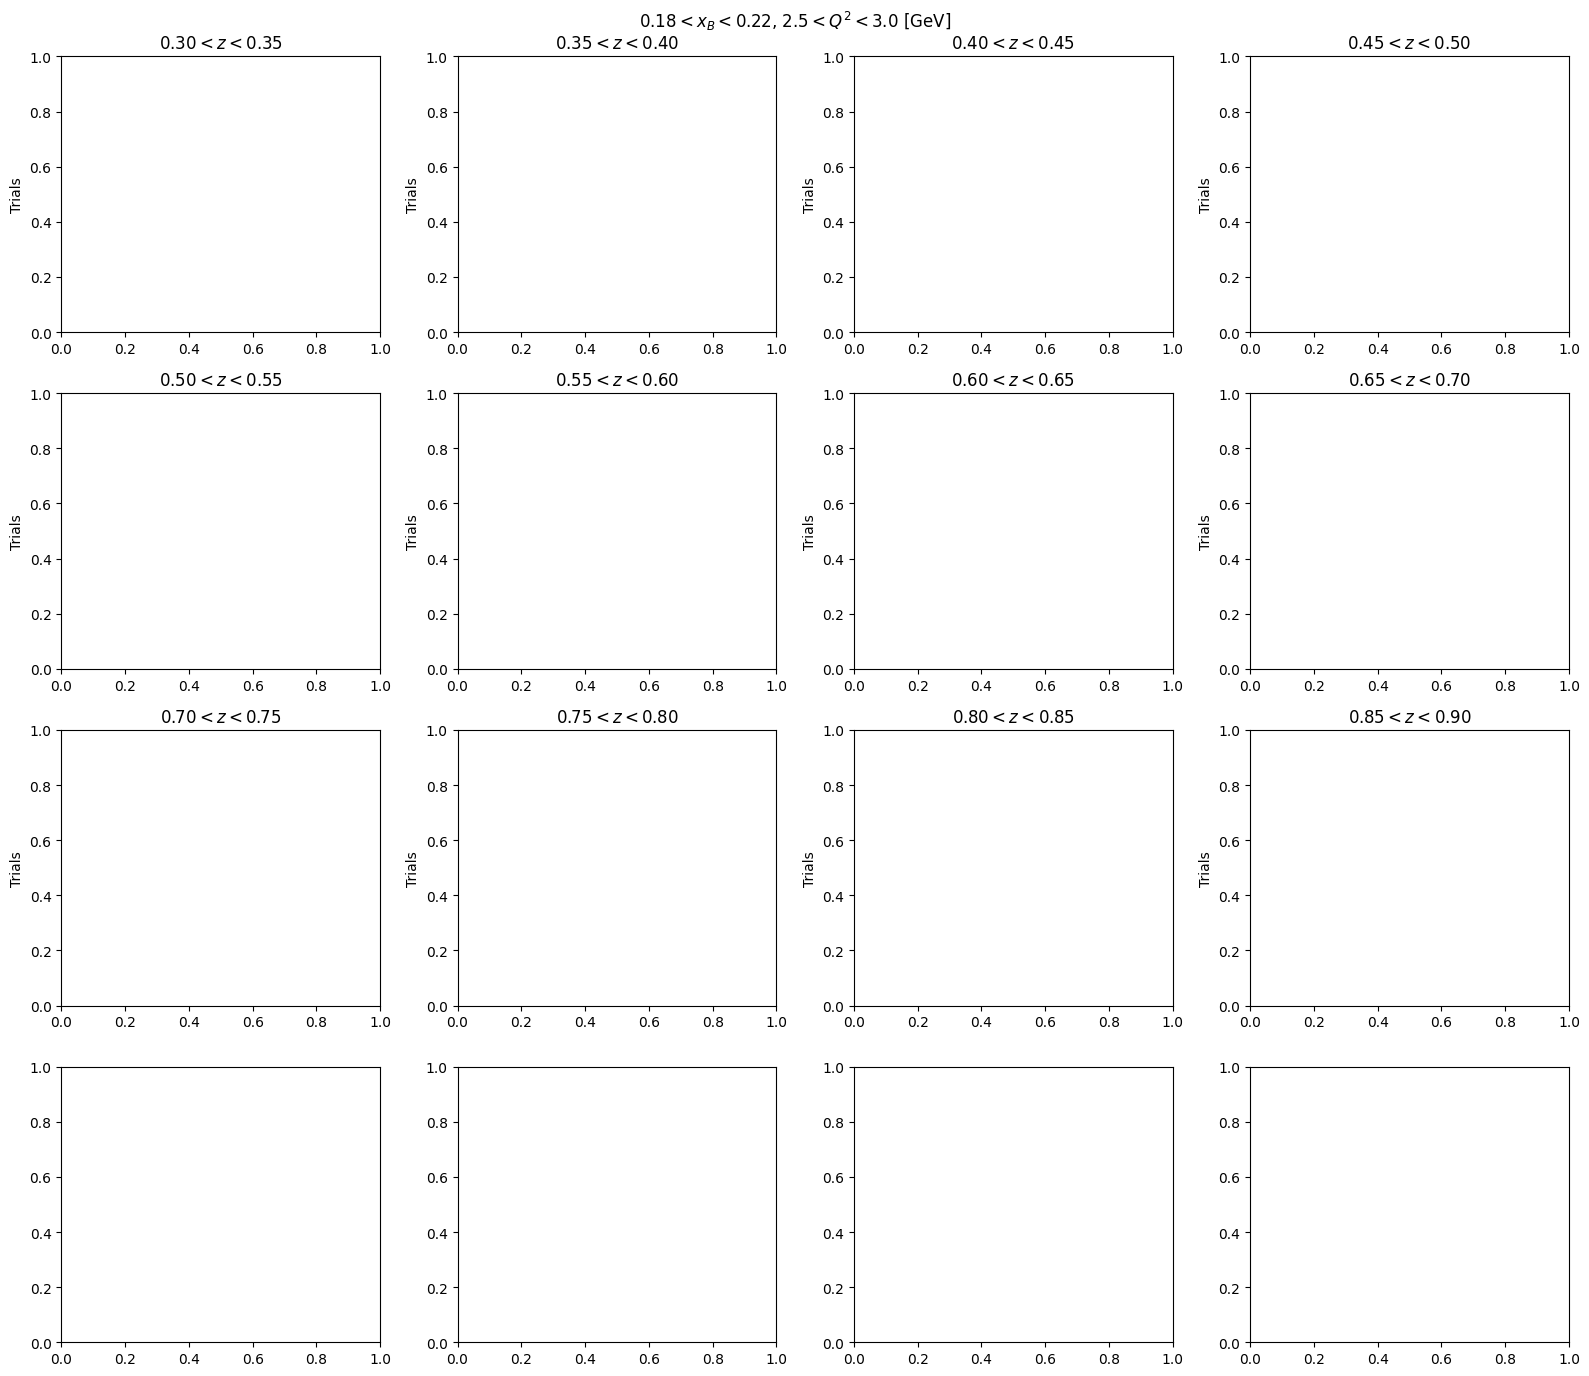

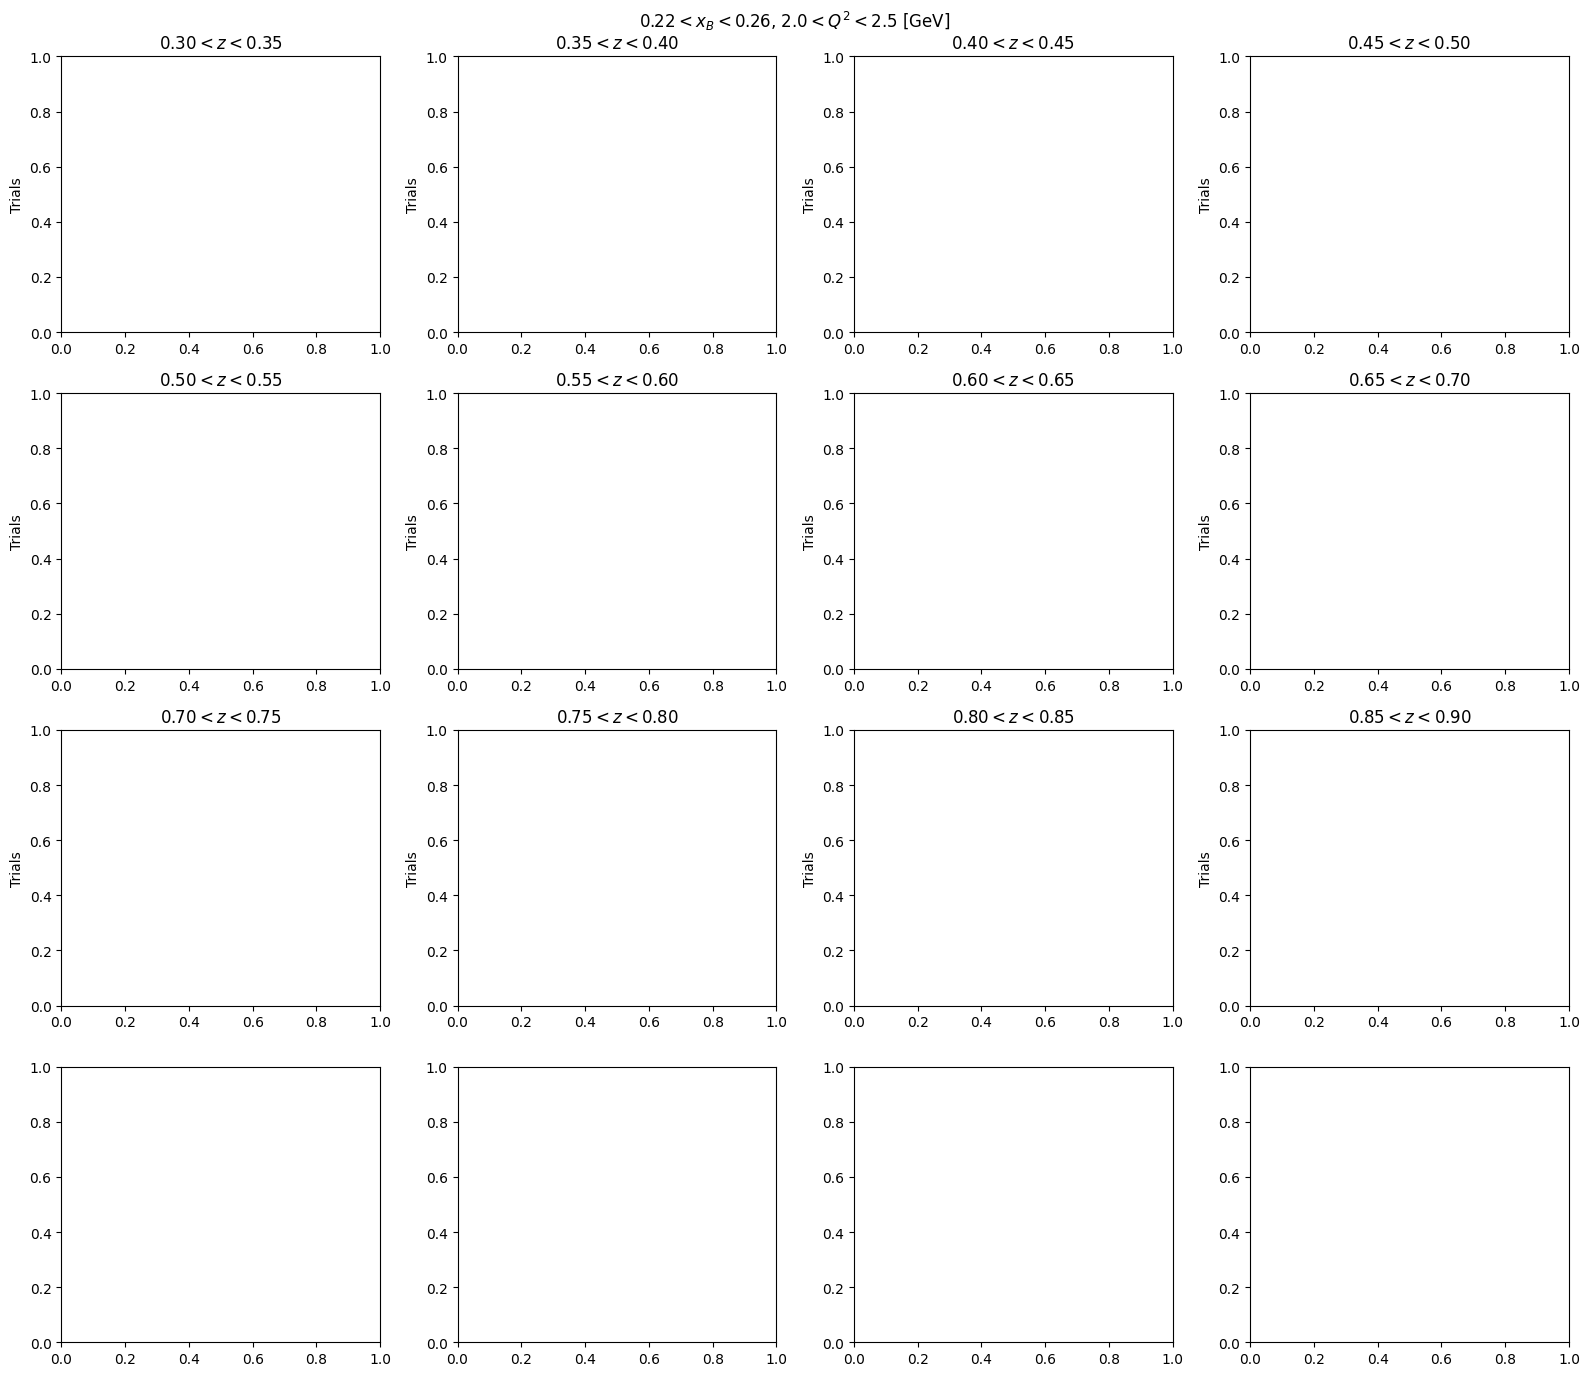

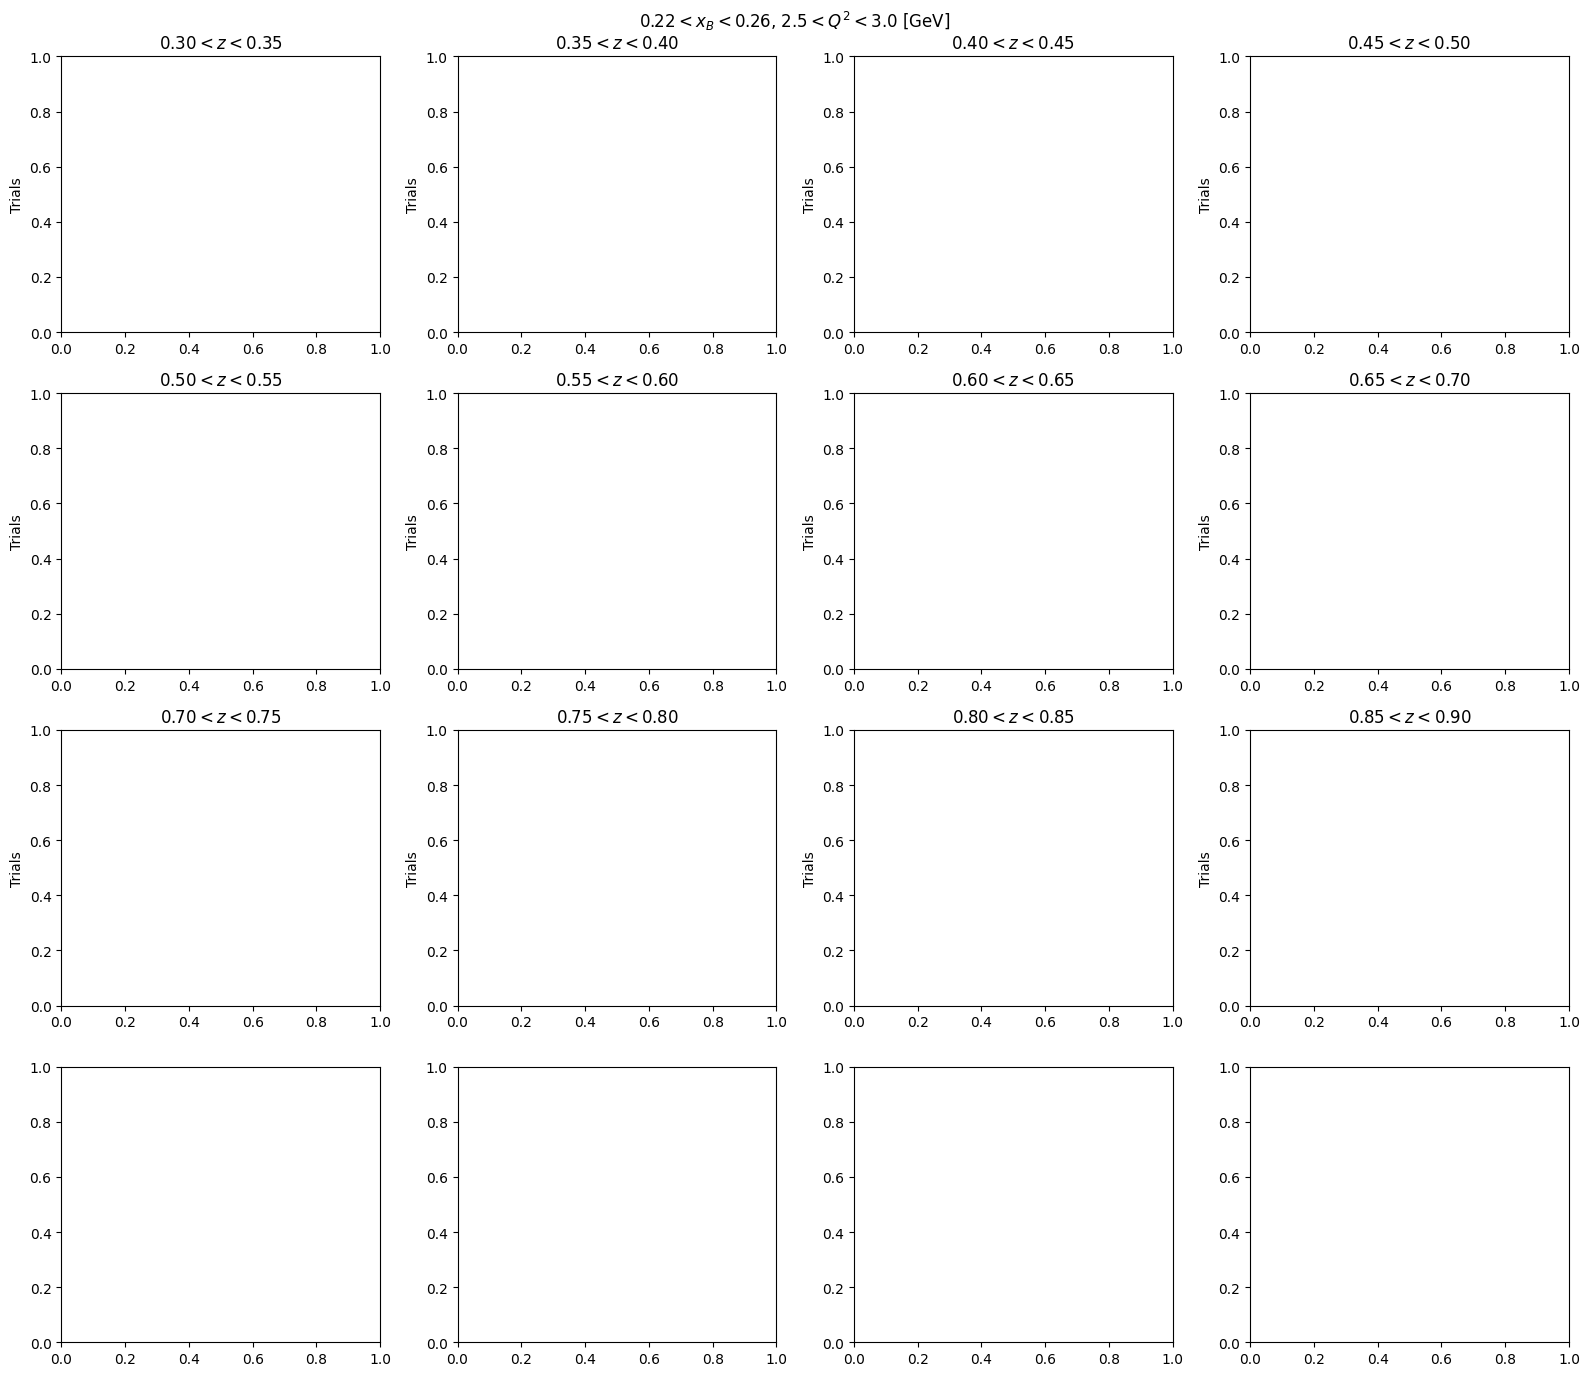

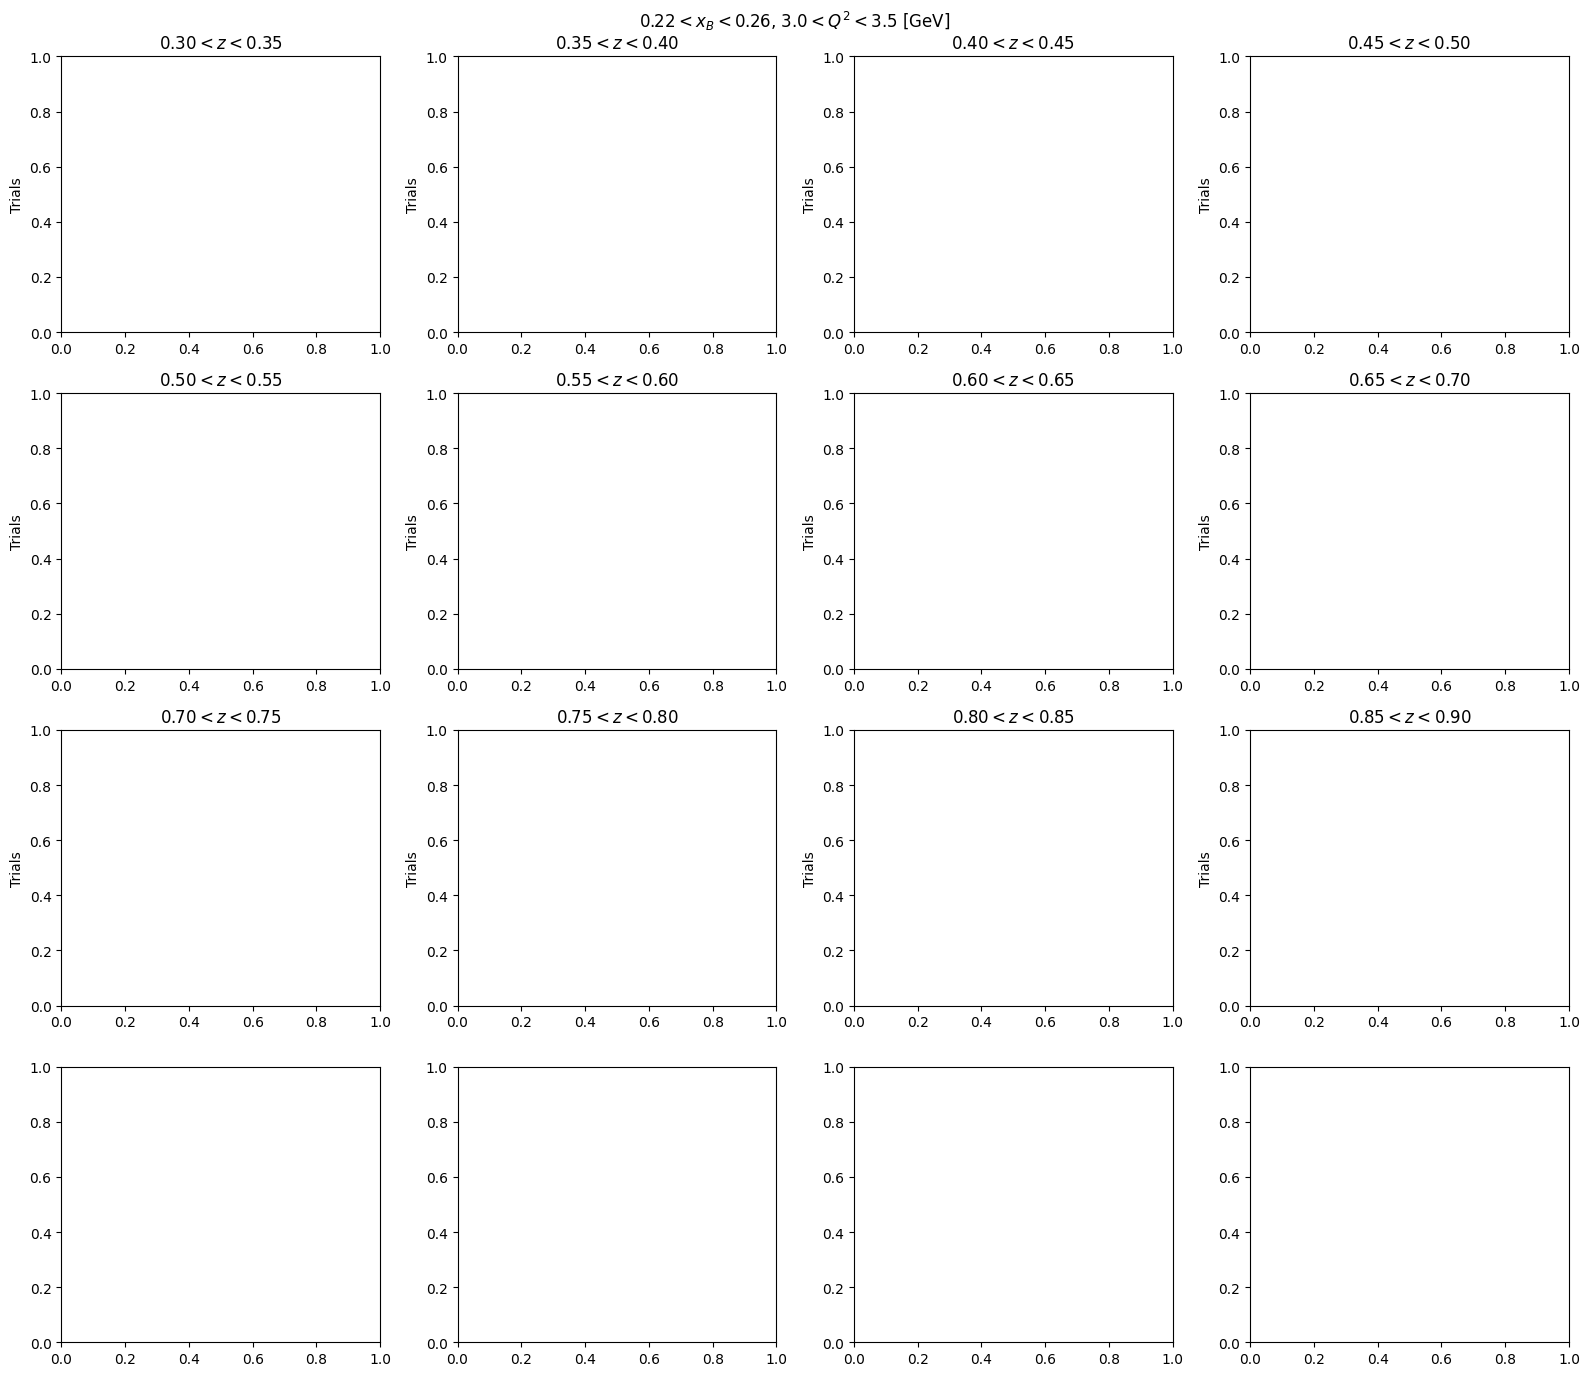

/scratch/jphelan/tmpfs/ipykernel_3842379/3333428104.py:44: RuntimeWarning: divide by zero encountered in divide
  raw = selected_pip[bin + 2, :] / selected_pim[bin + 2, :]
/scratch/jphelan/tmpfs/ipykernel_3842379/3333428104.py:51: RuntimeWarning: invalid value encountered in divide
  selected = (4 - raw) / den


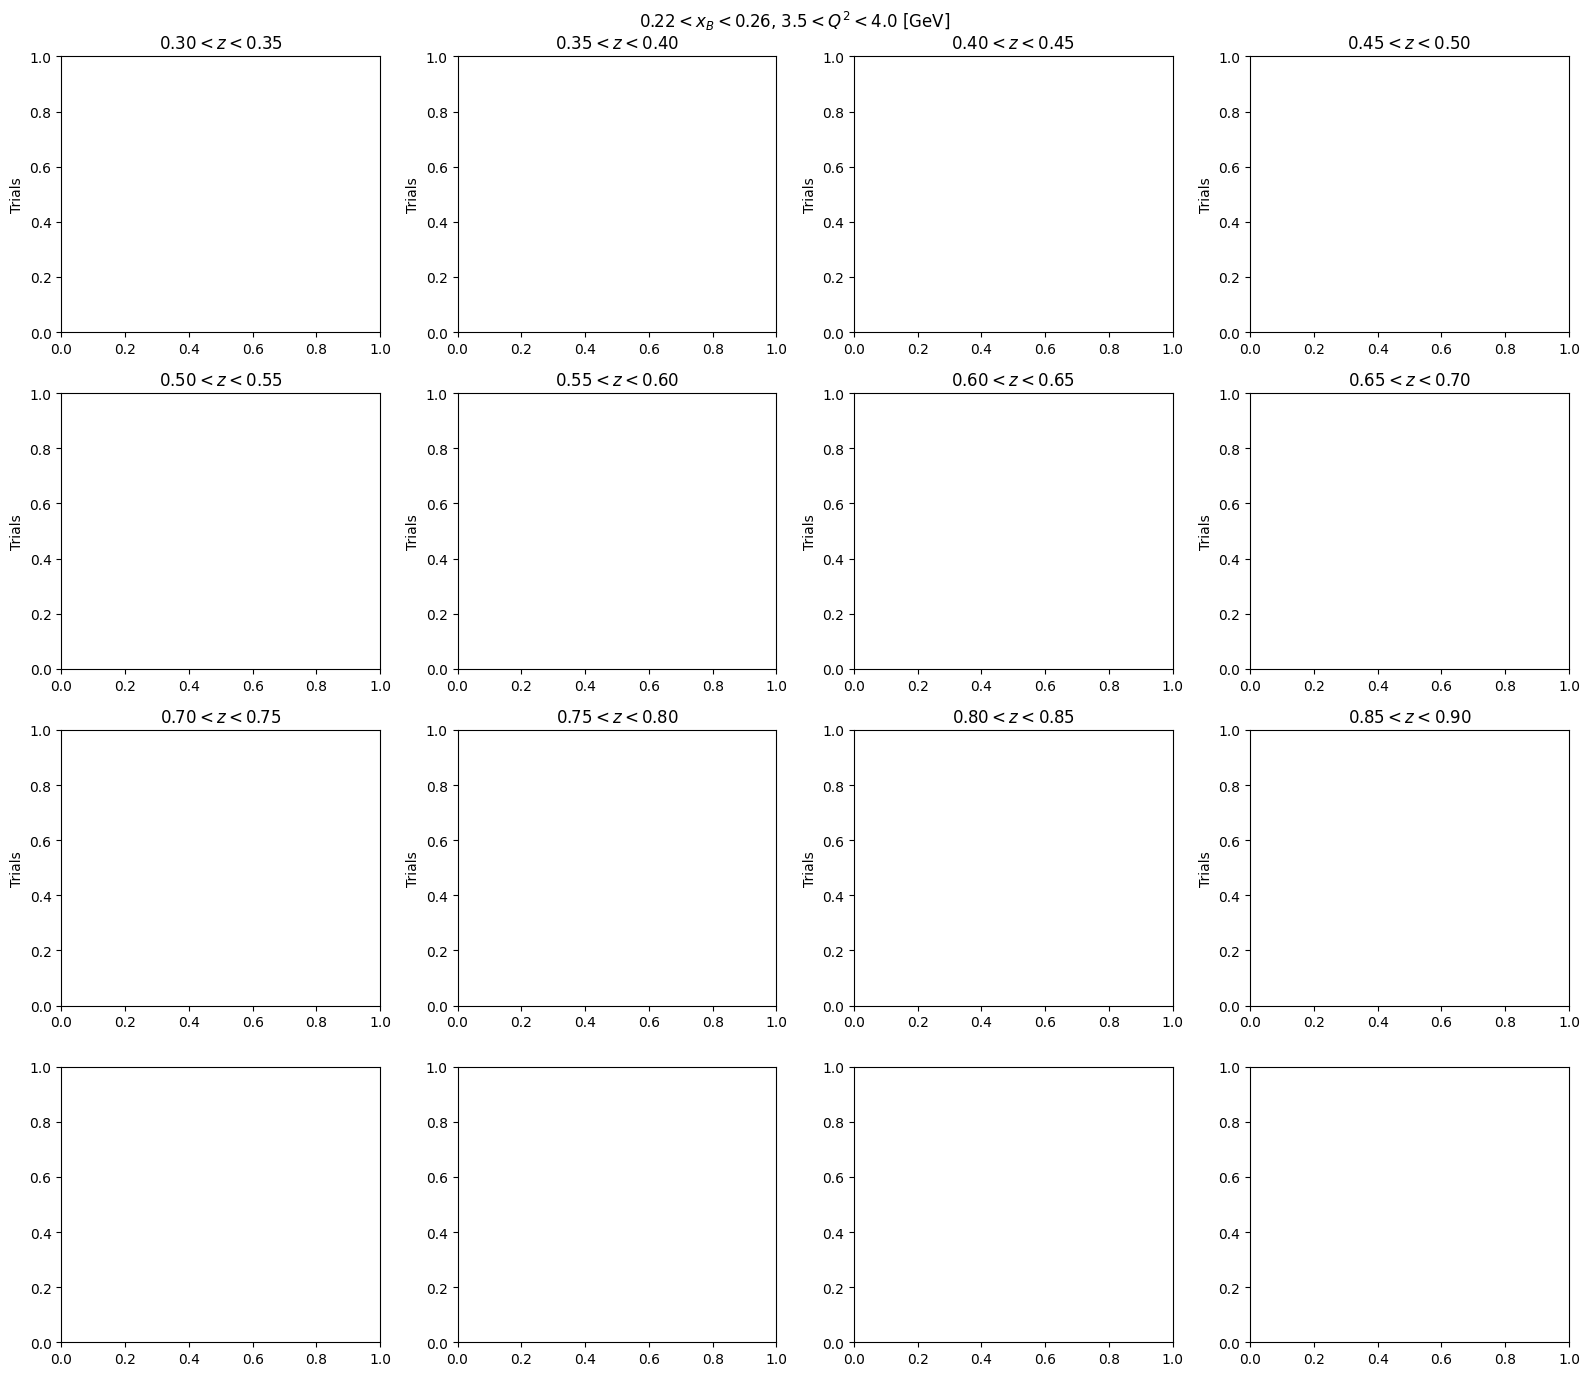

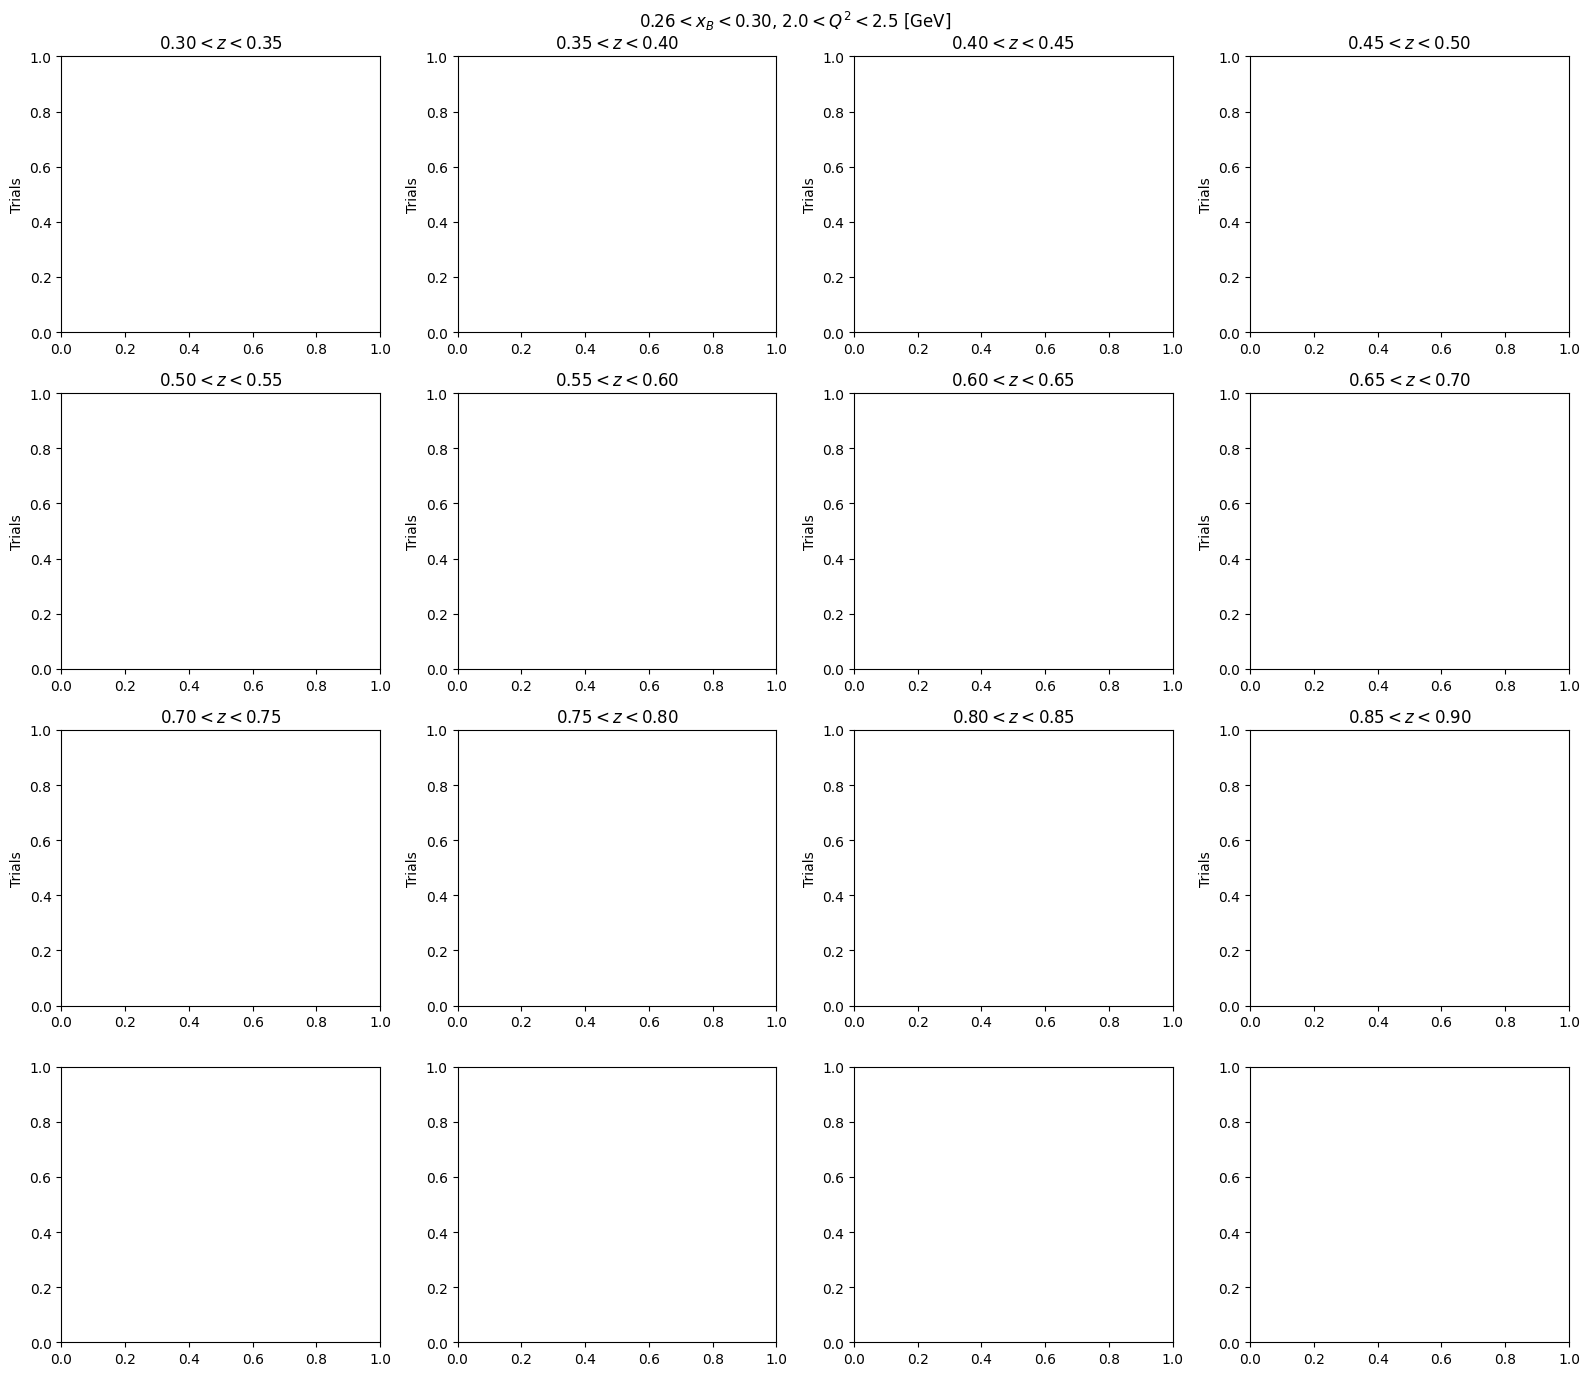

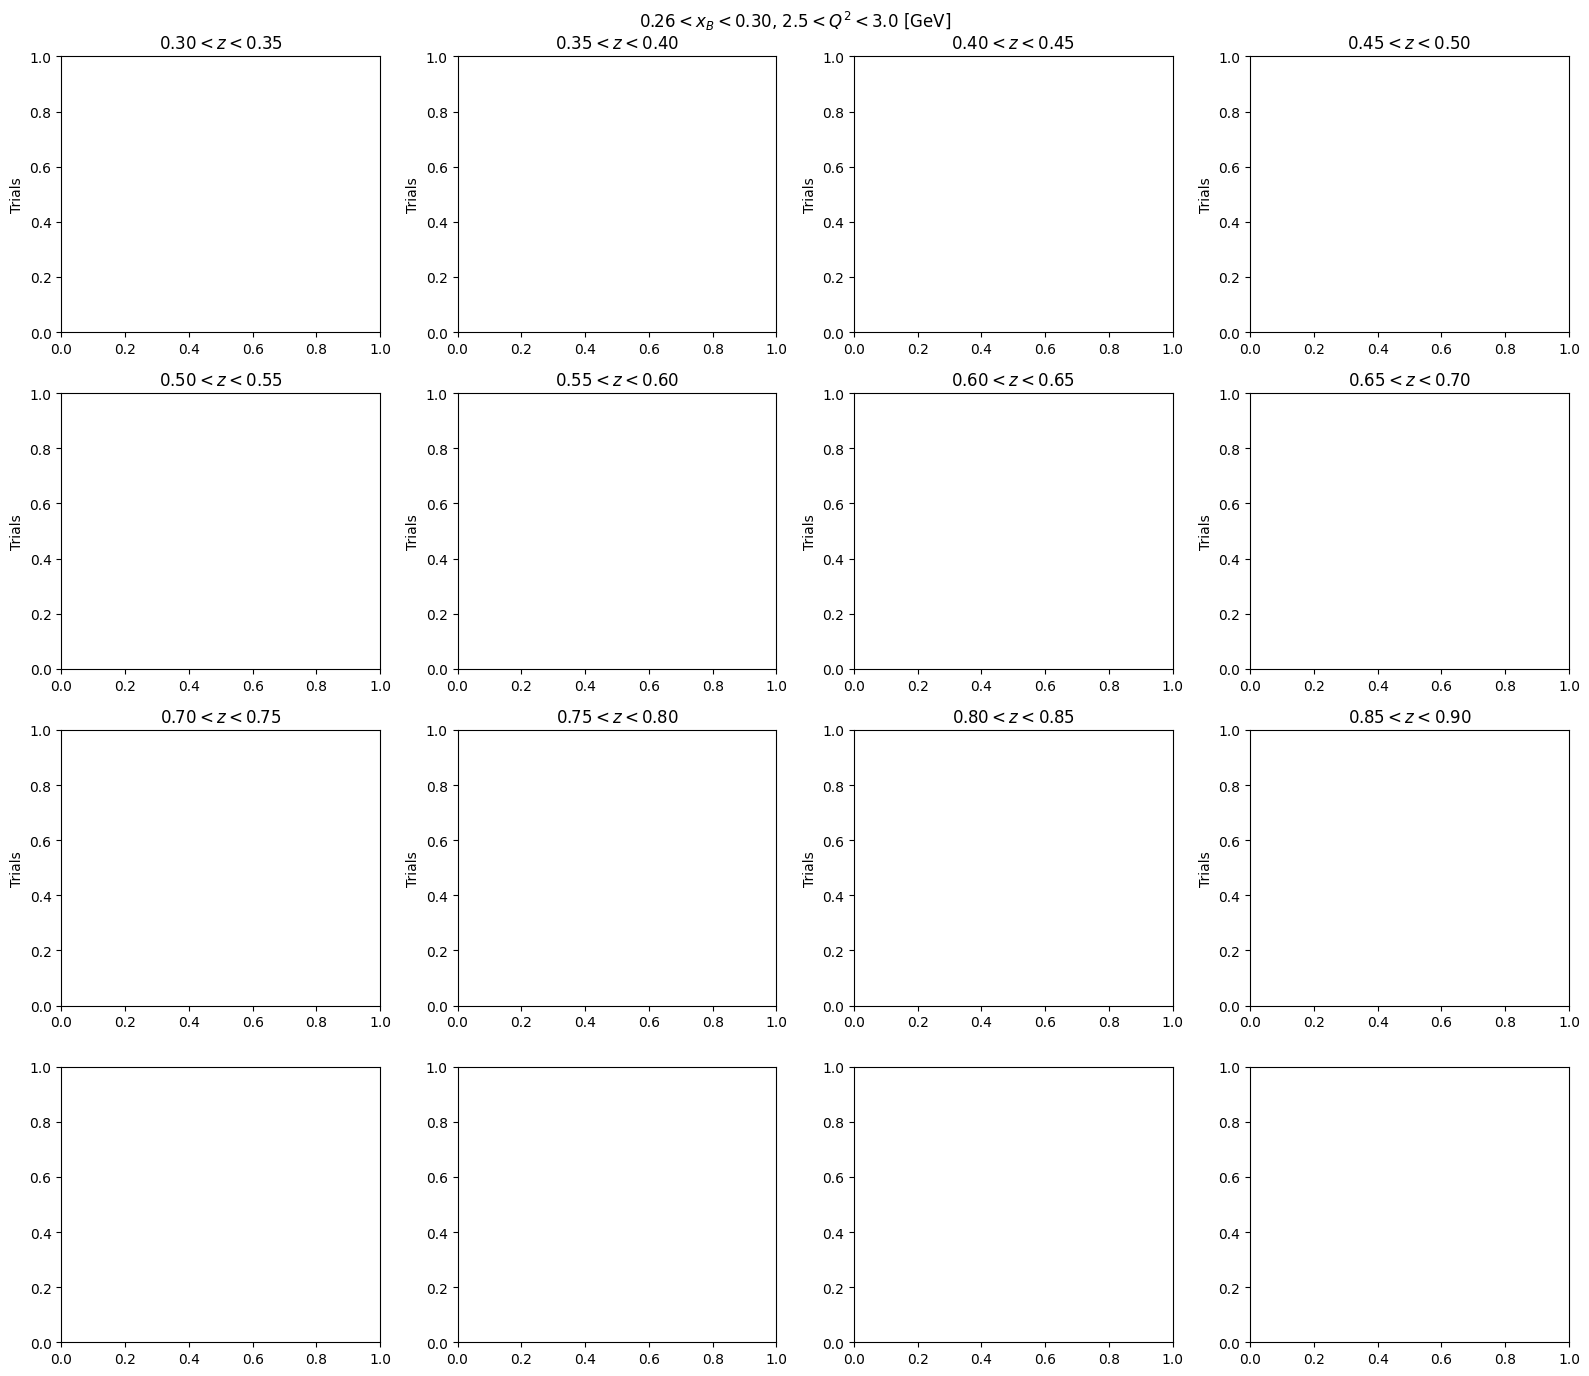

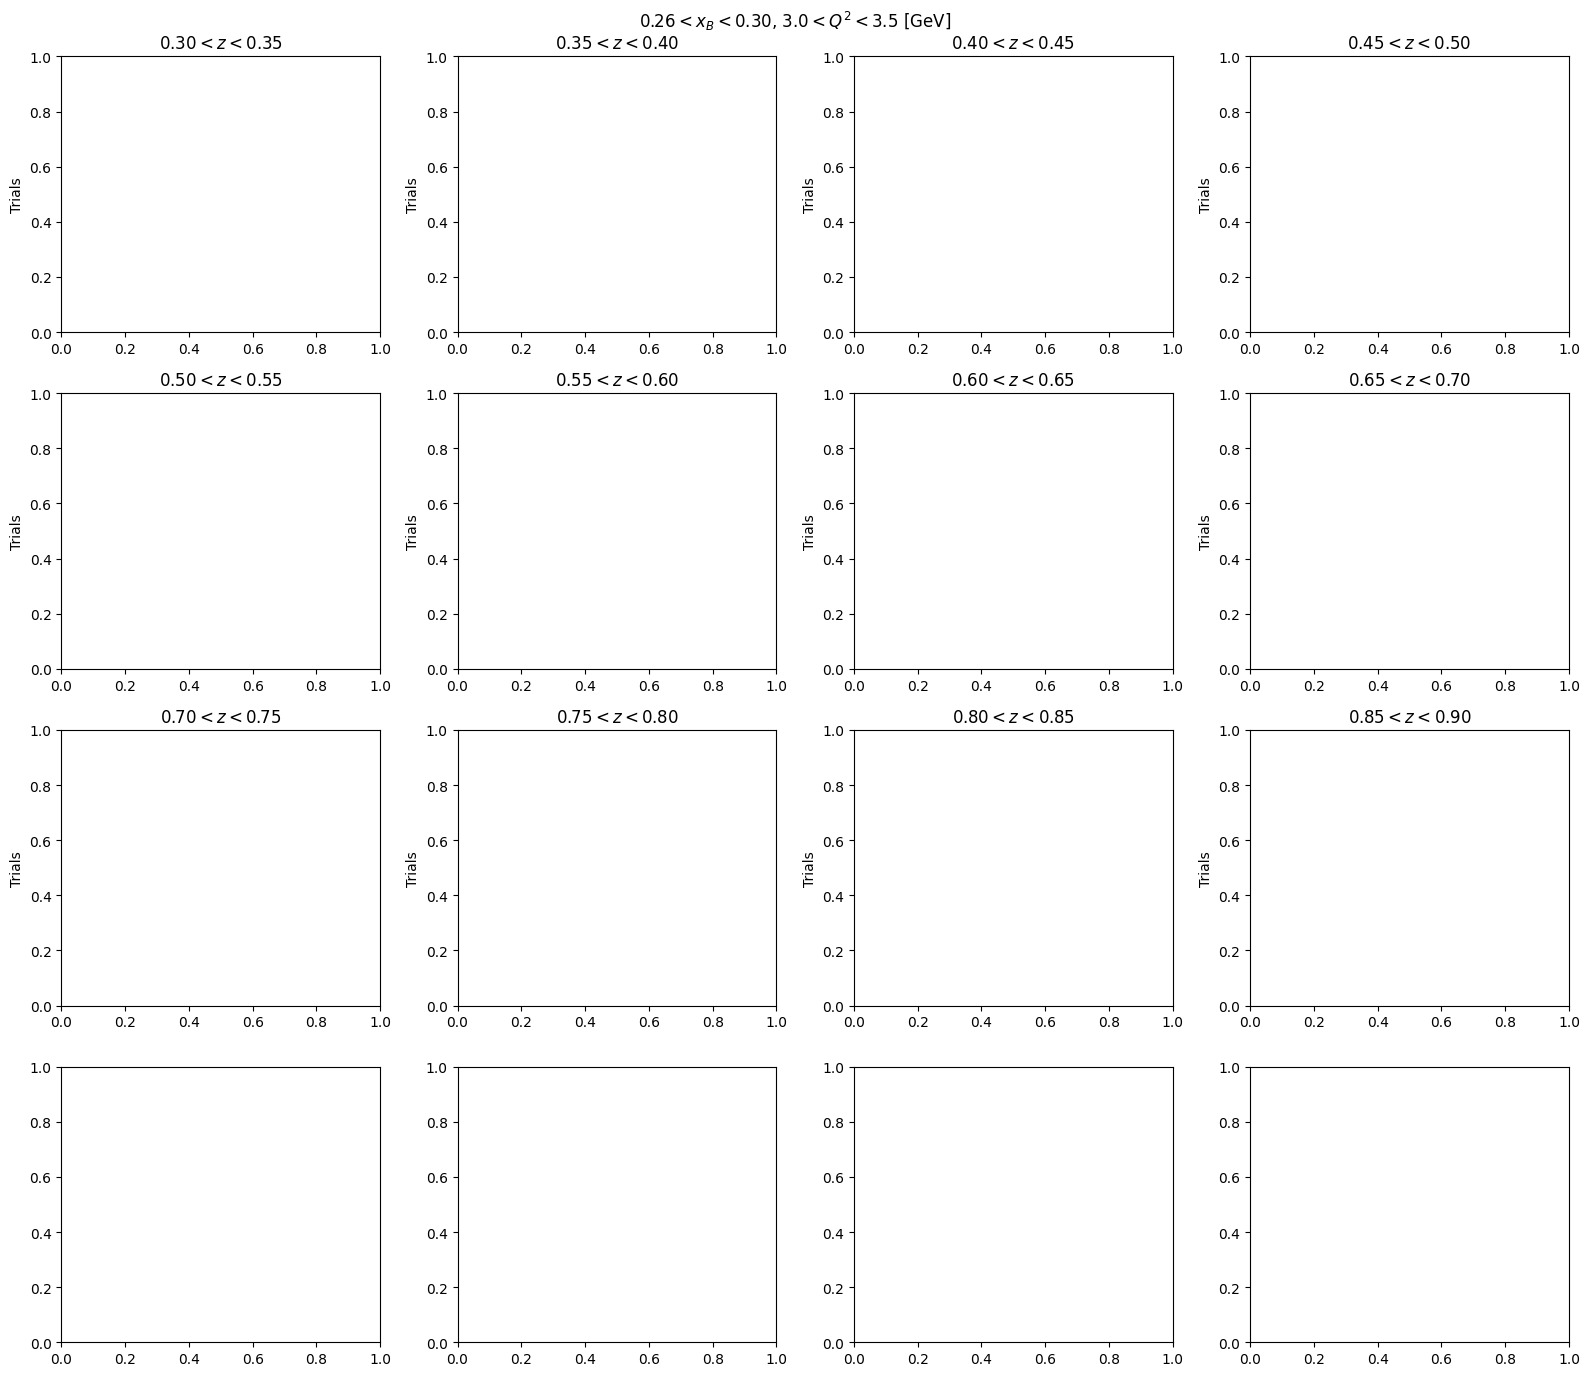

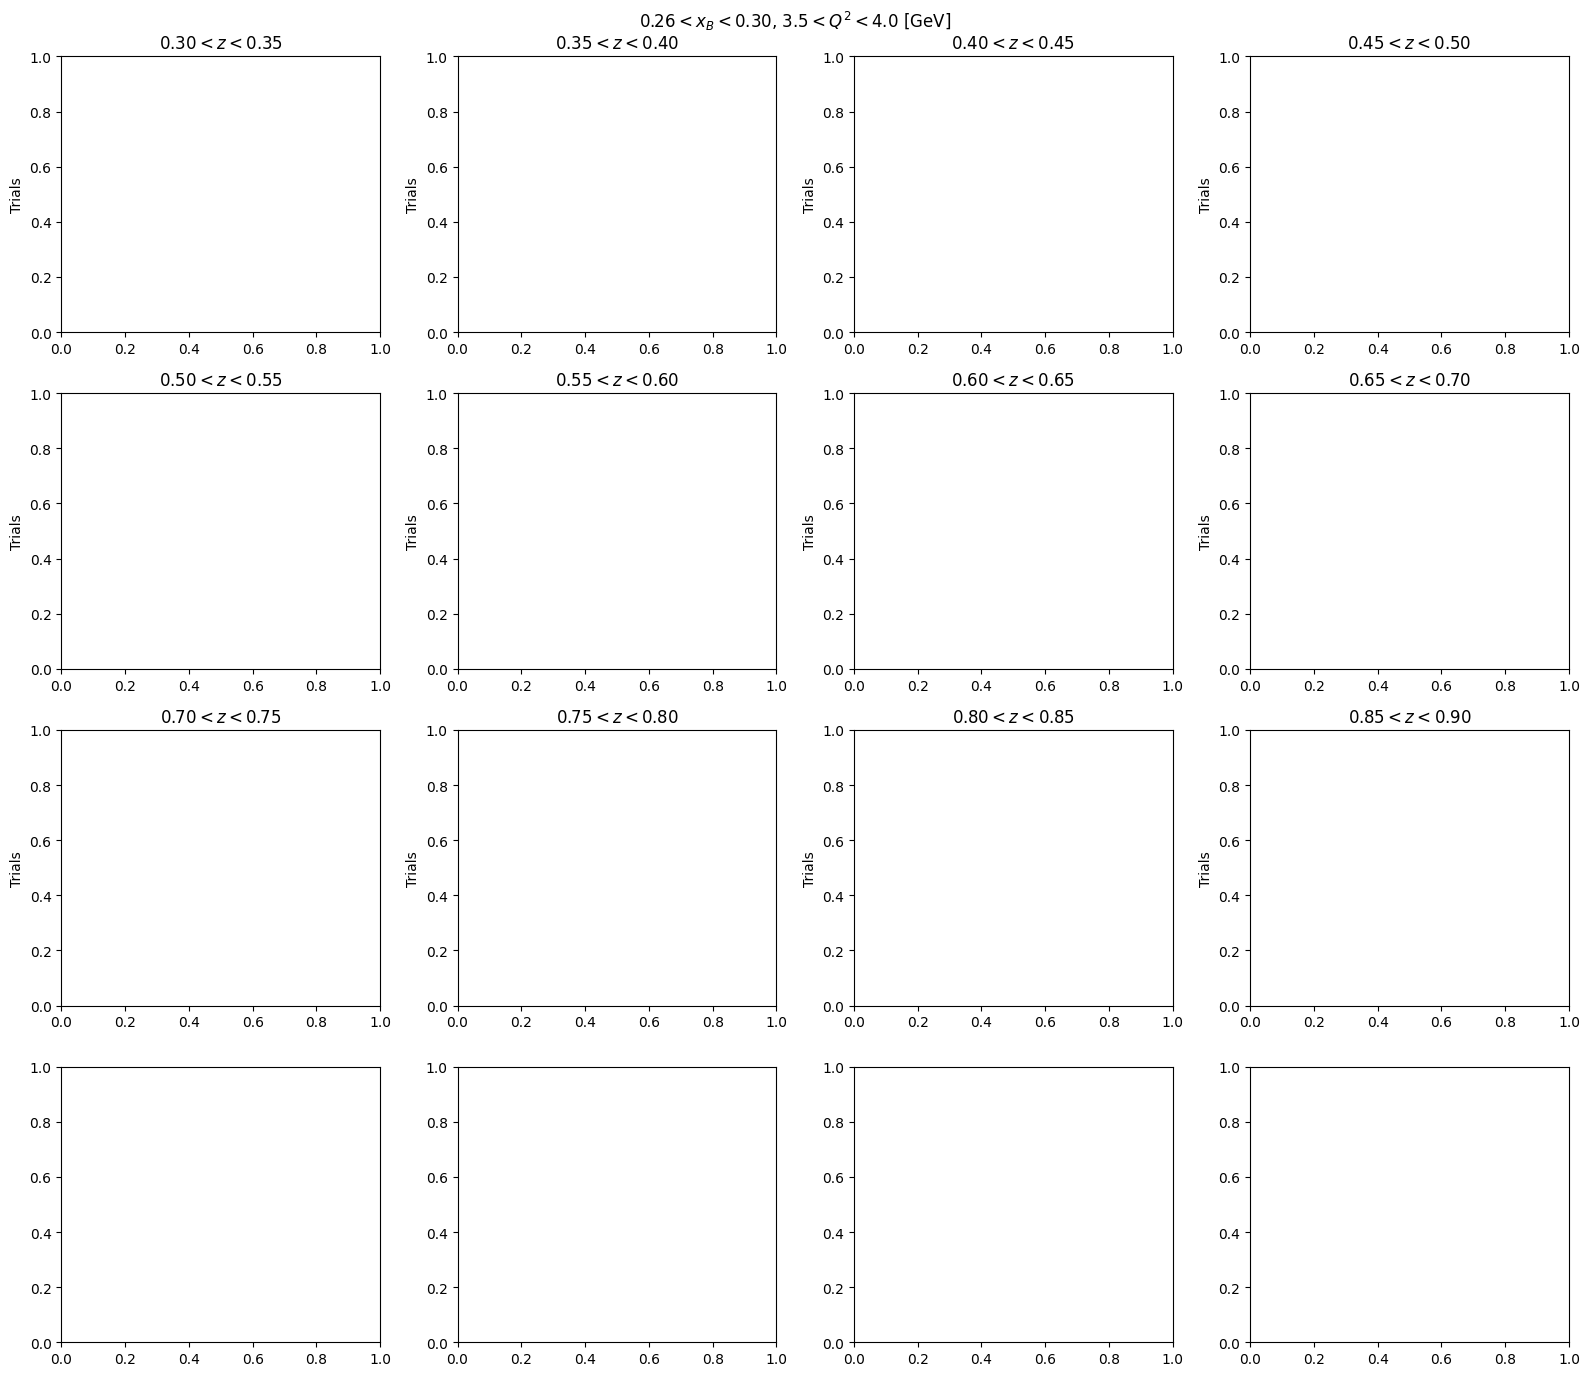

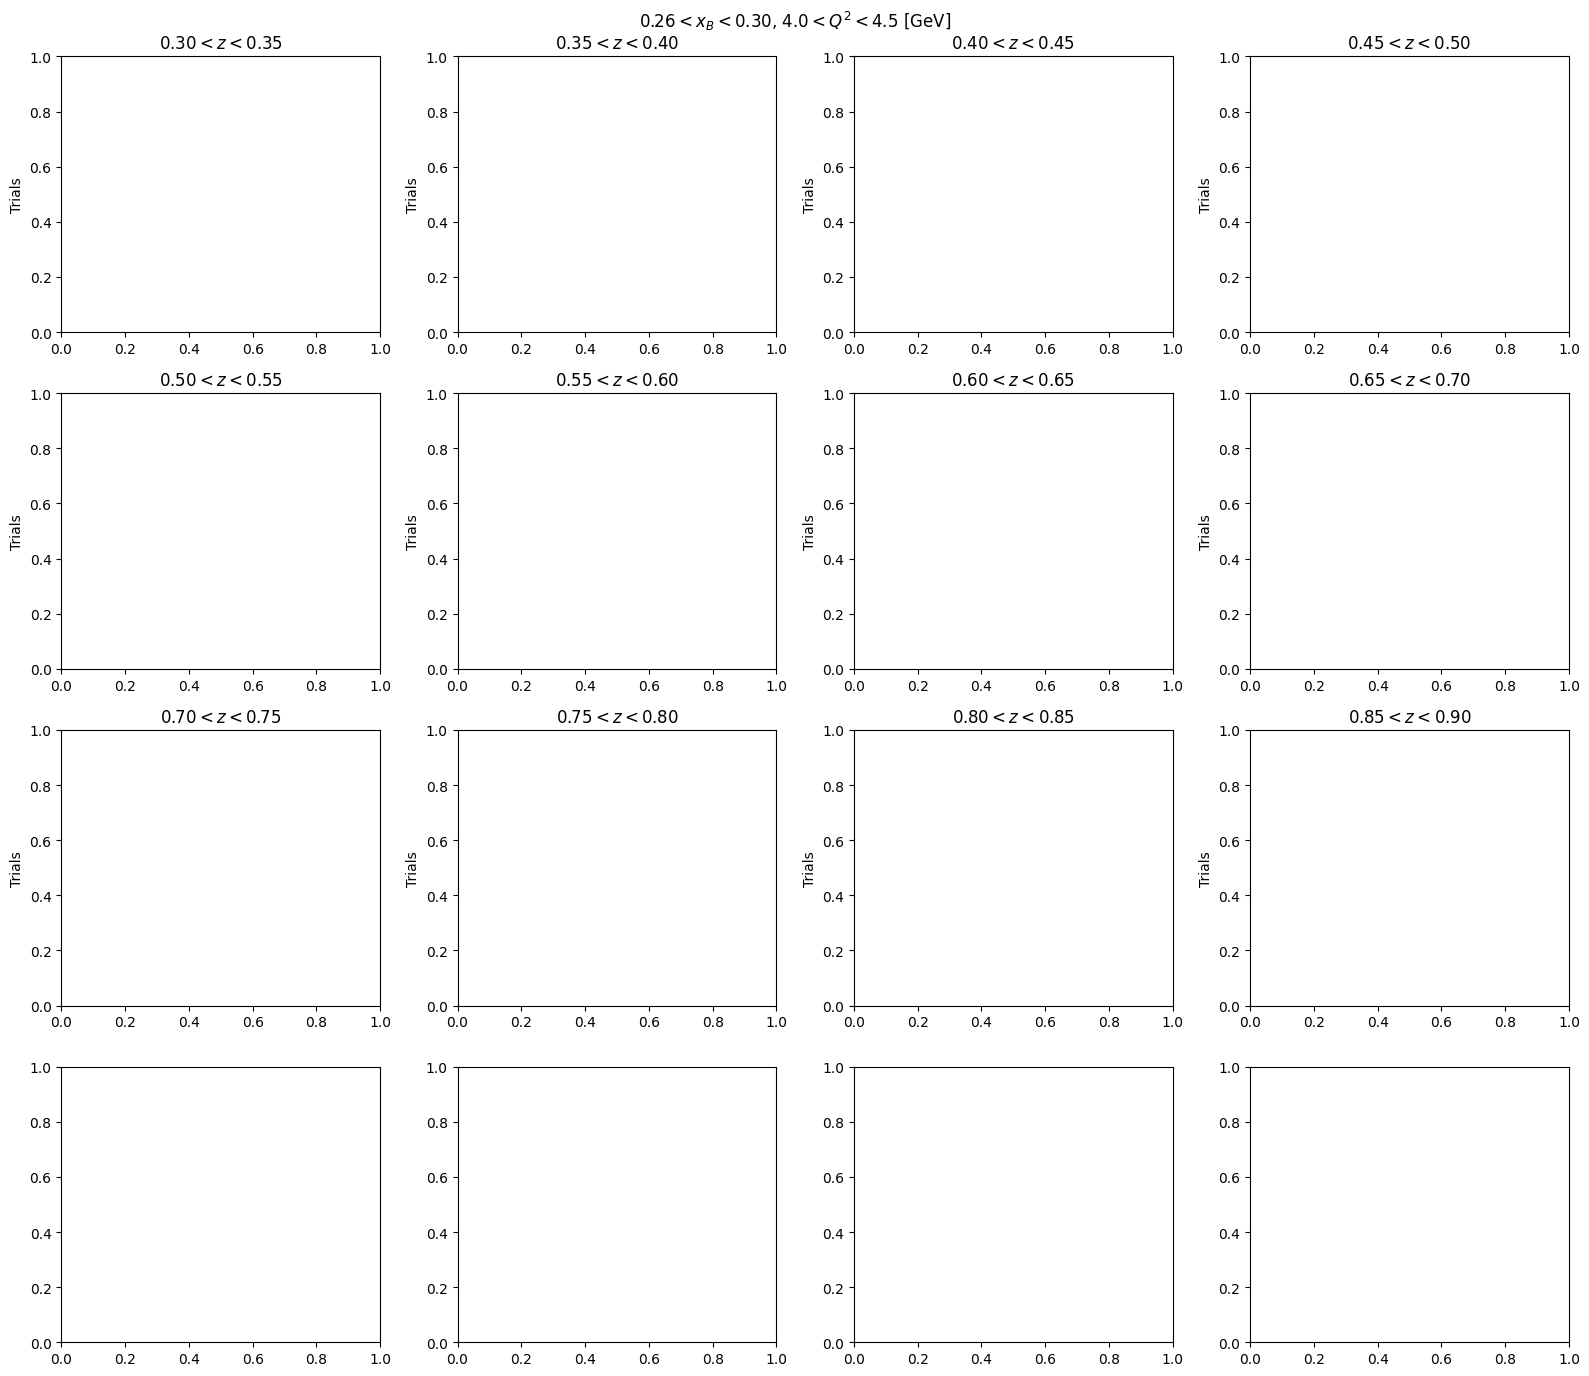

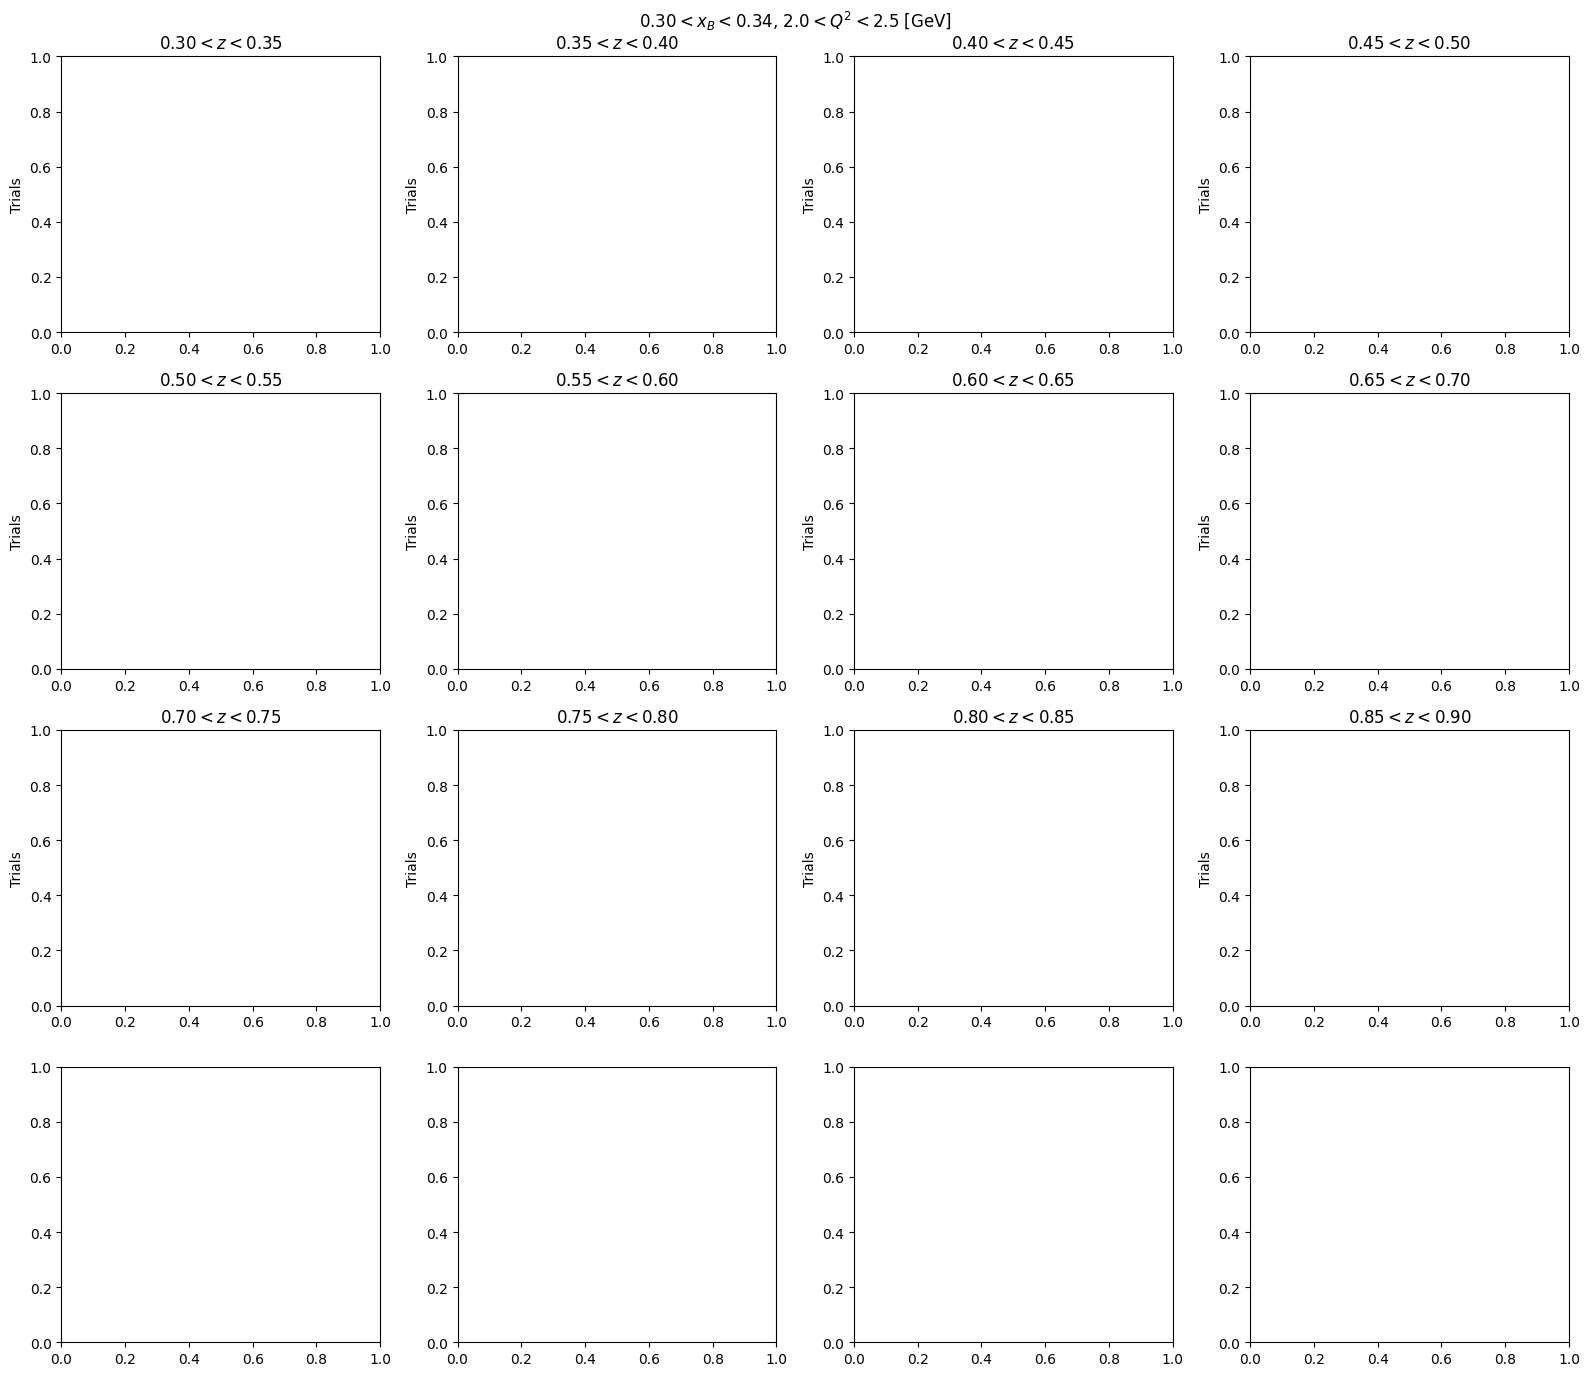

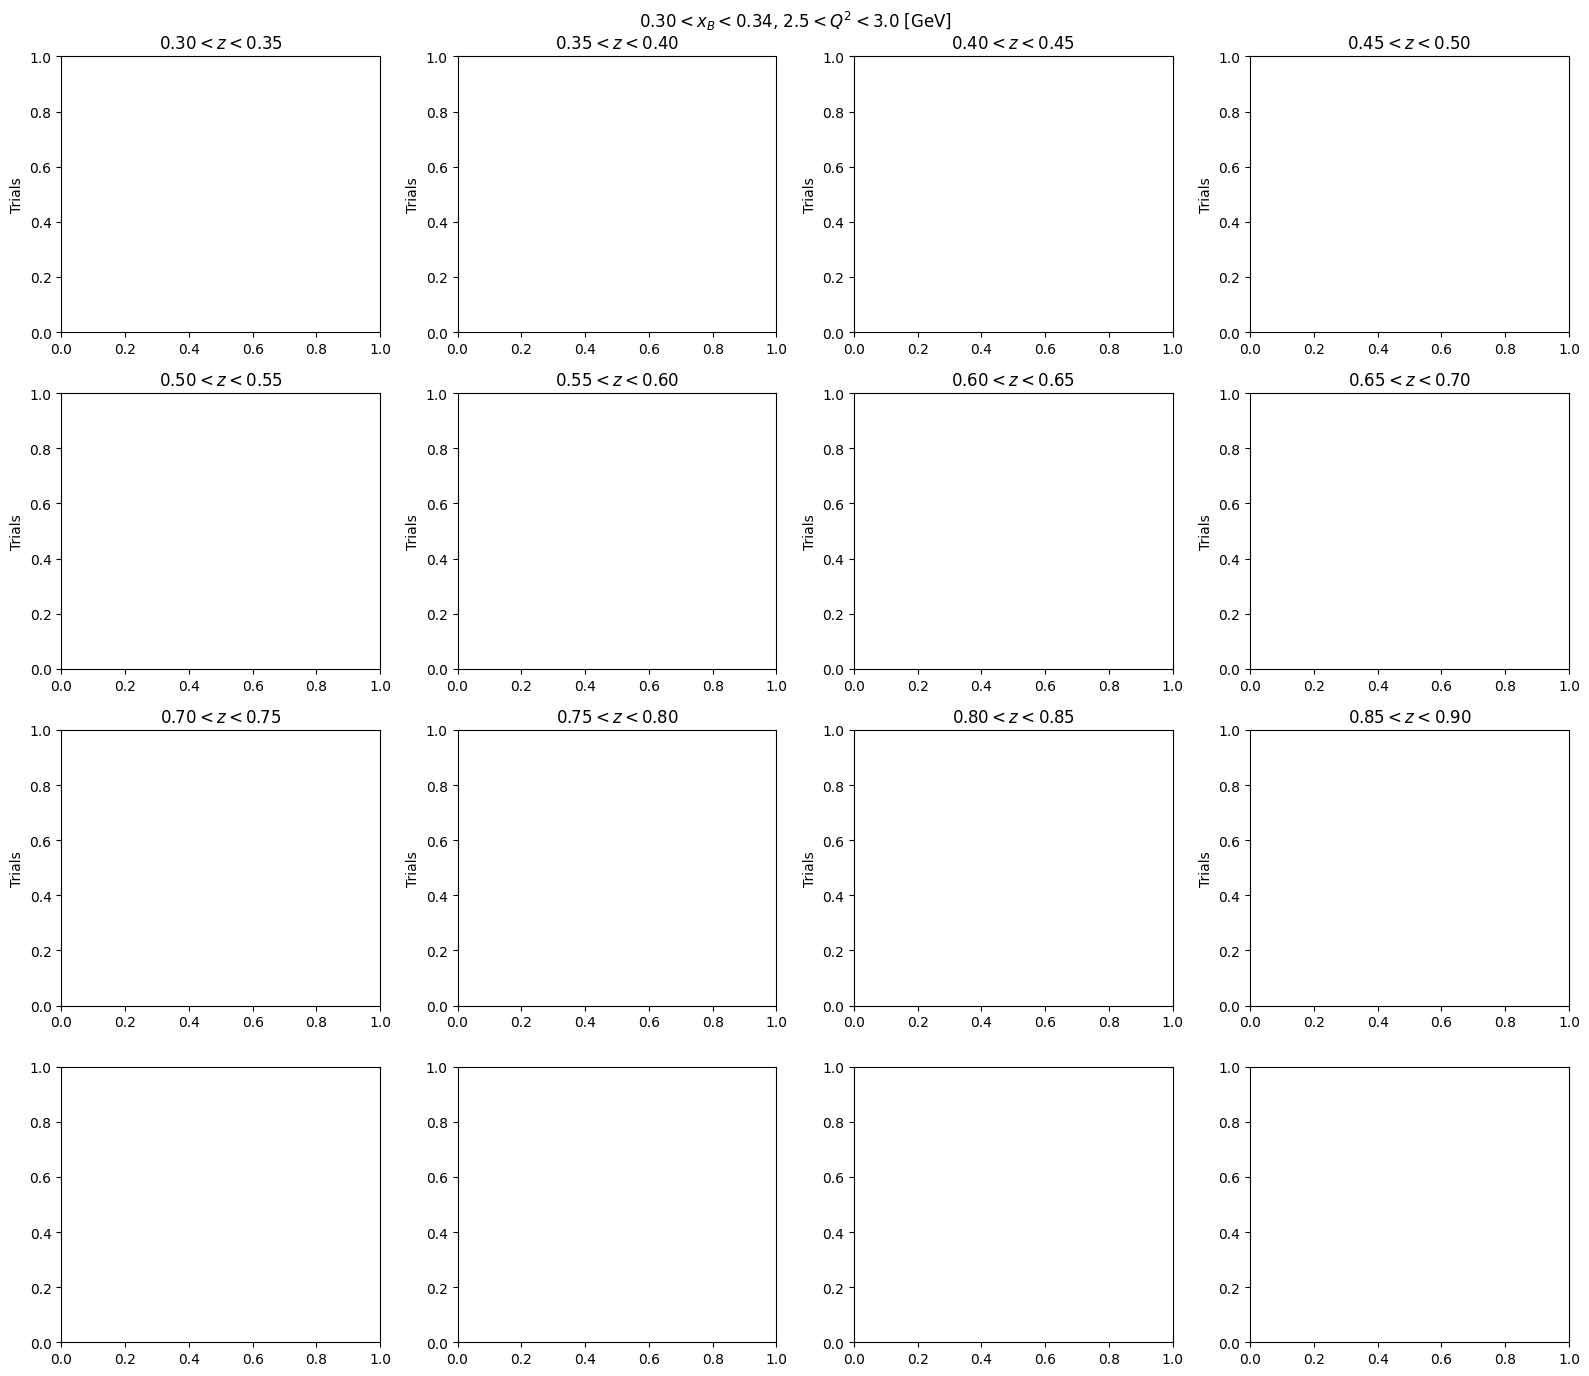

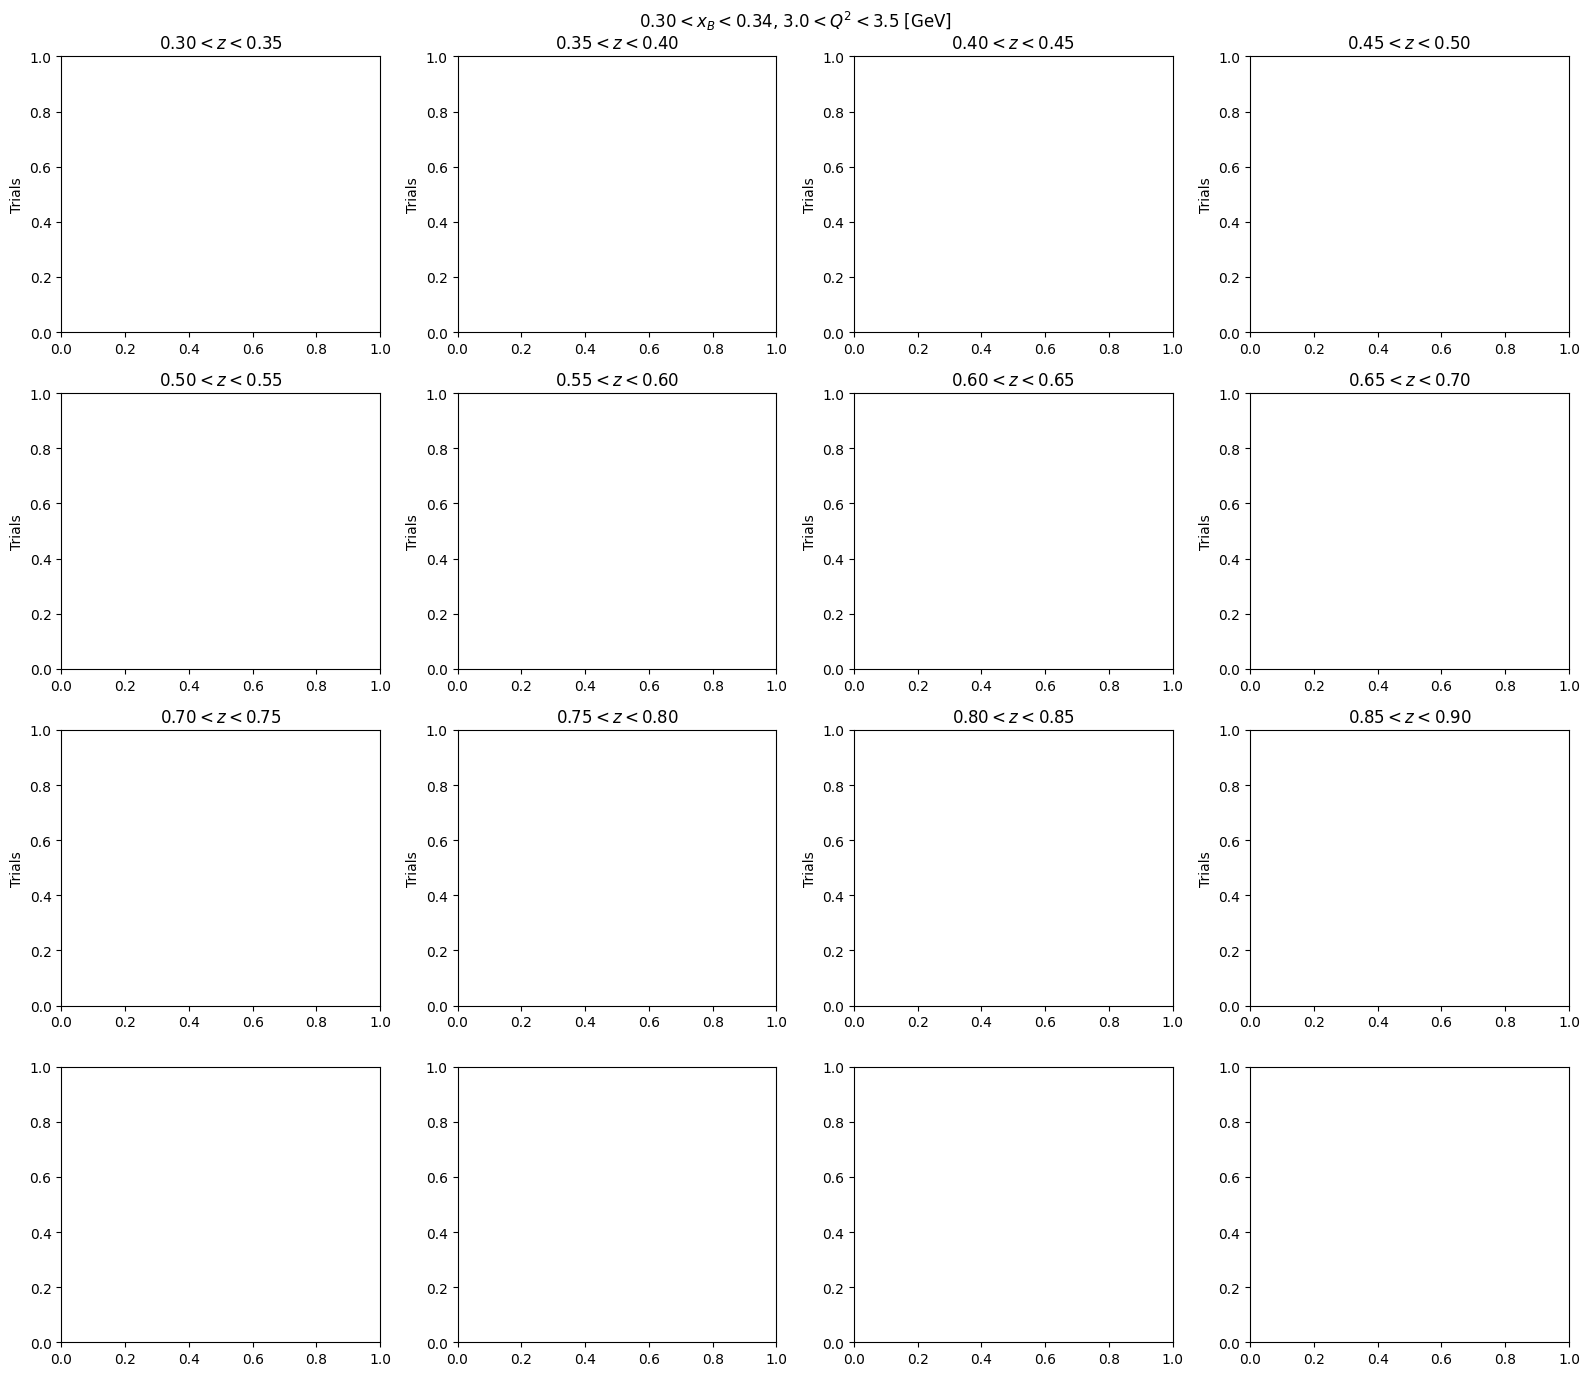

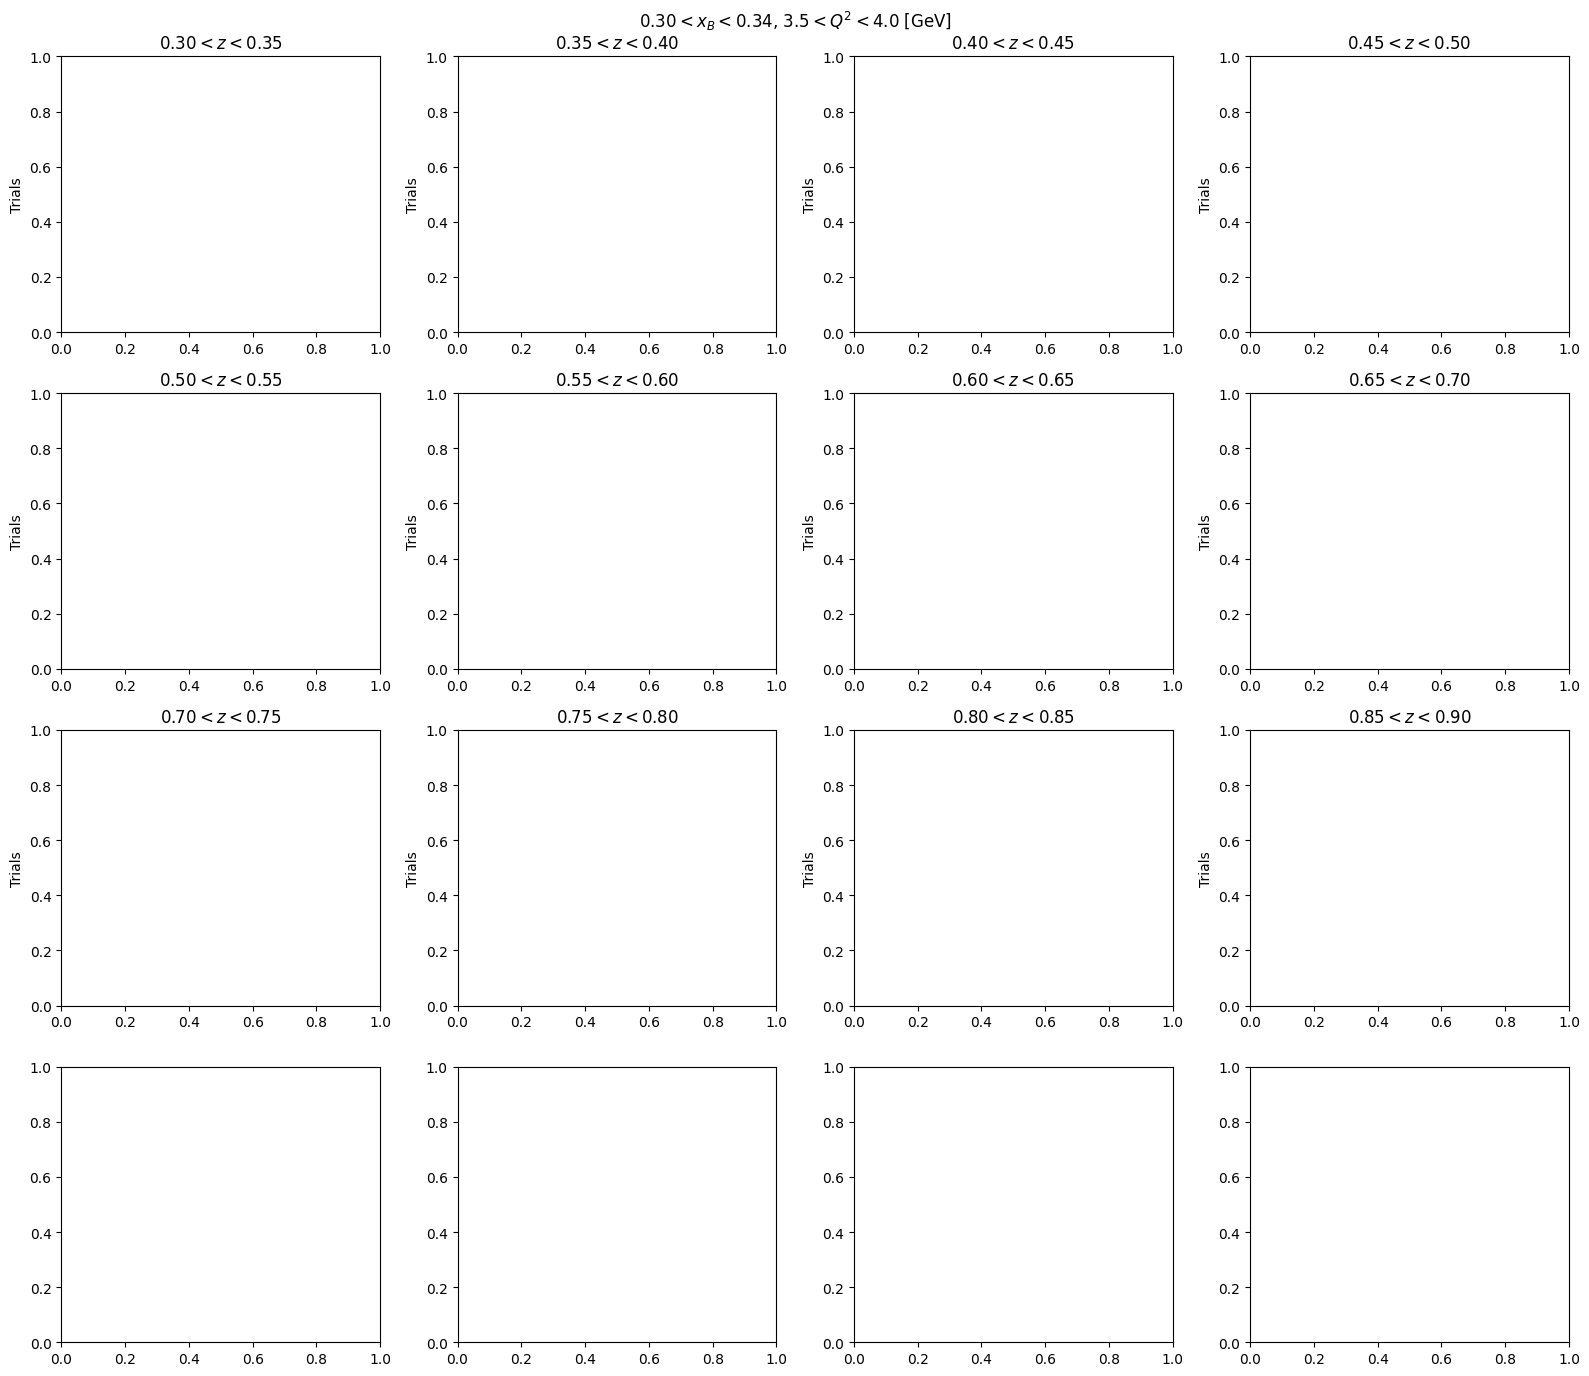

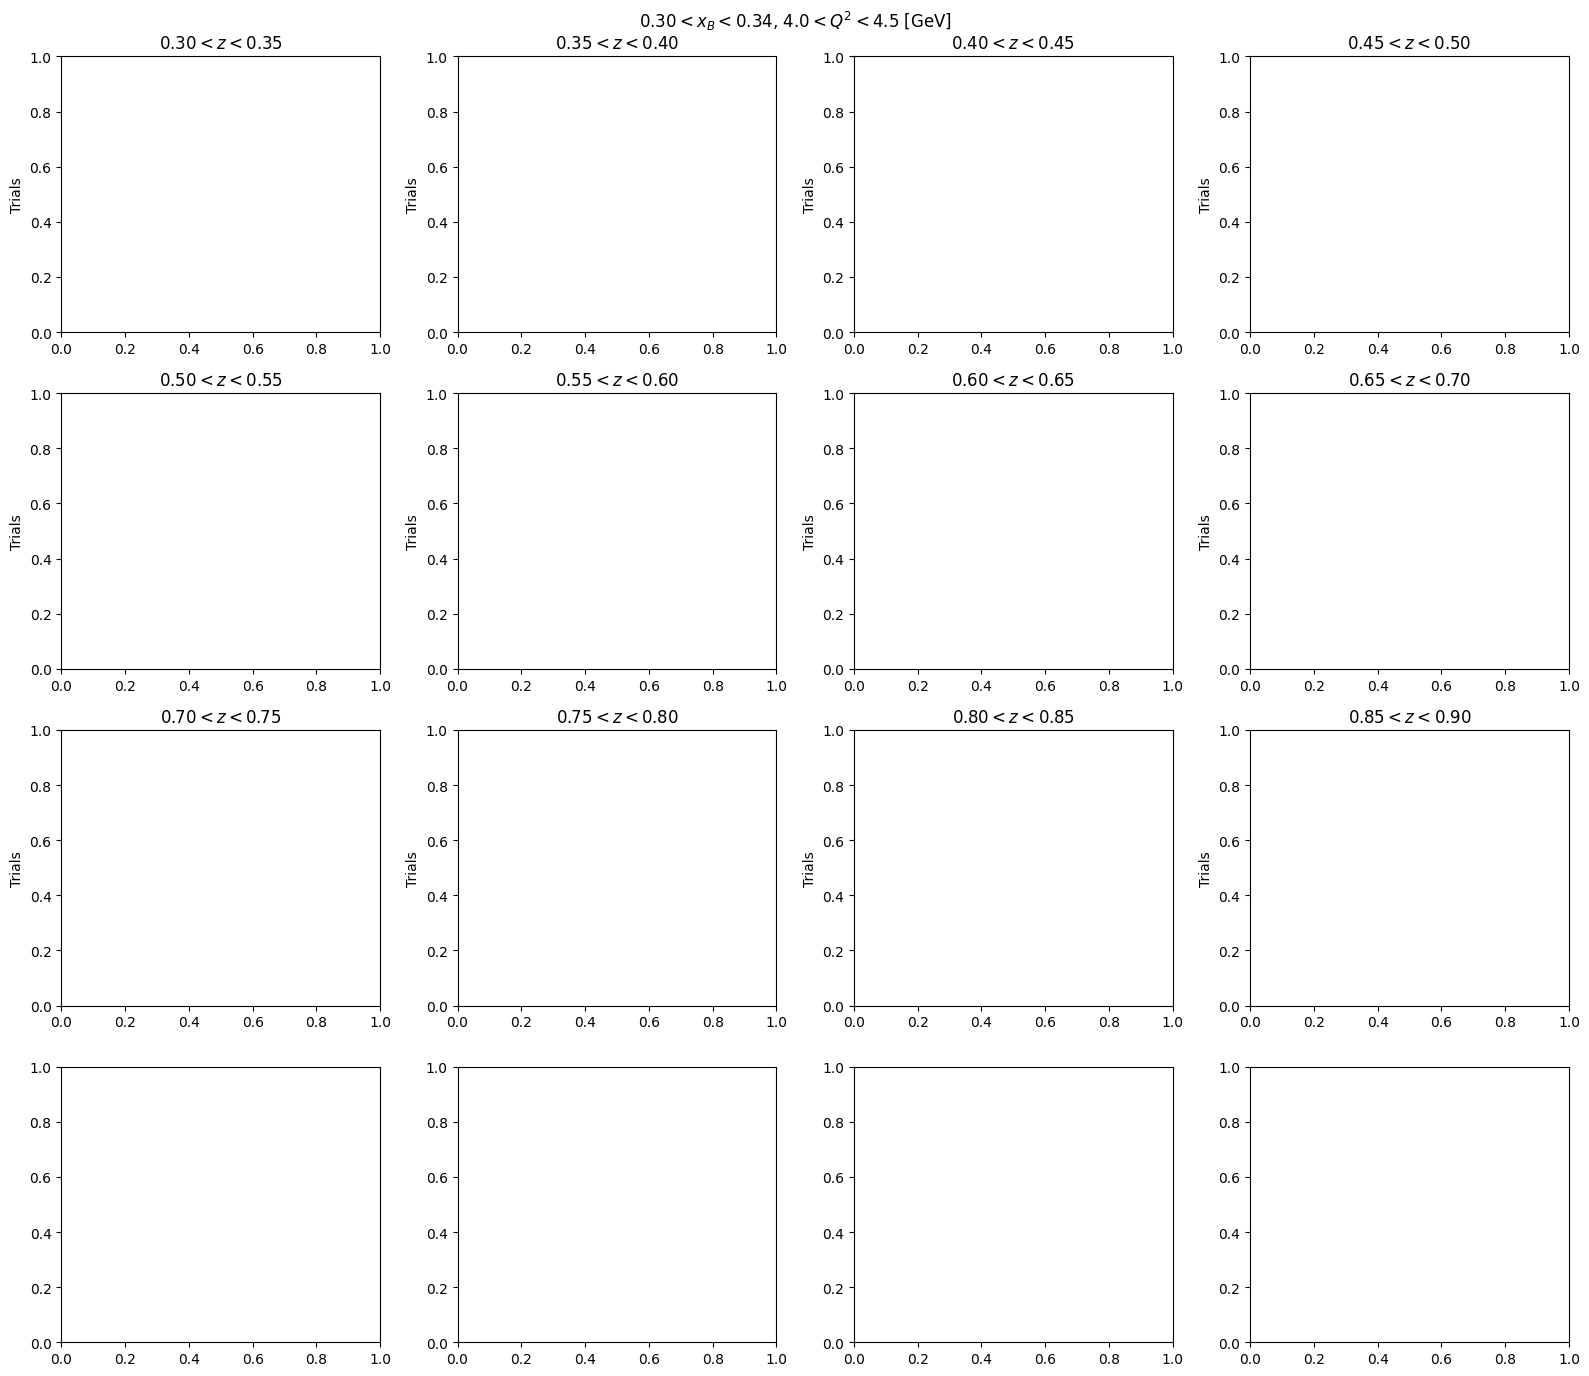

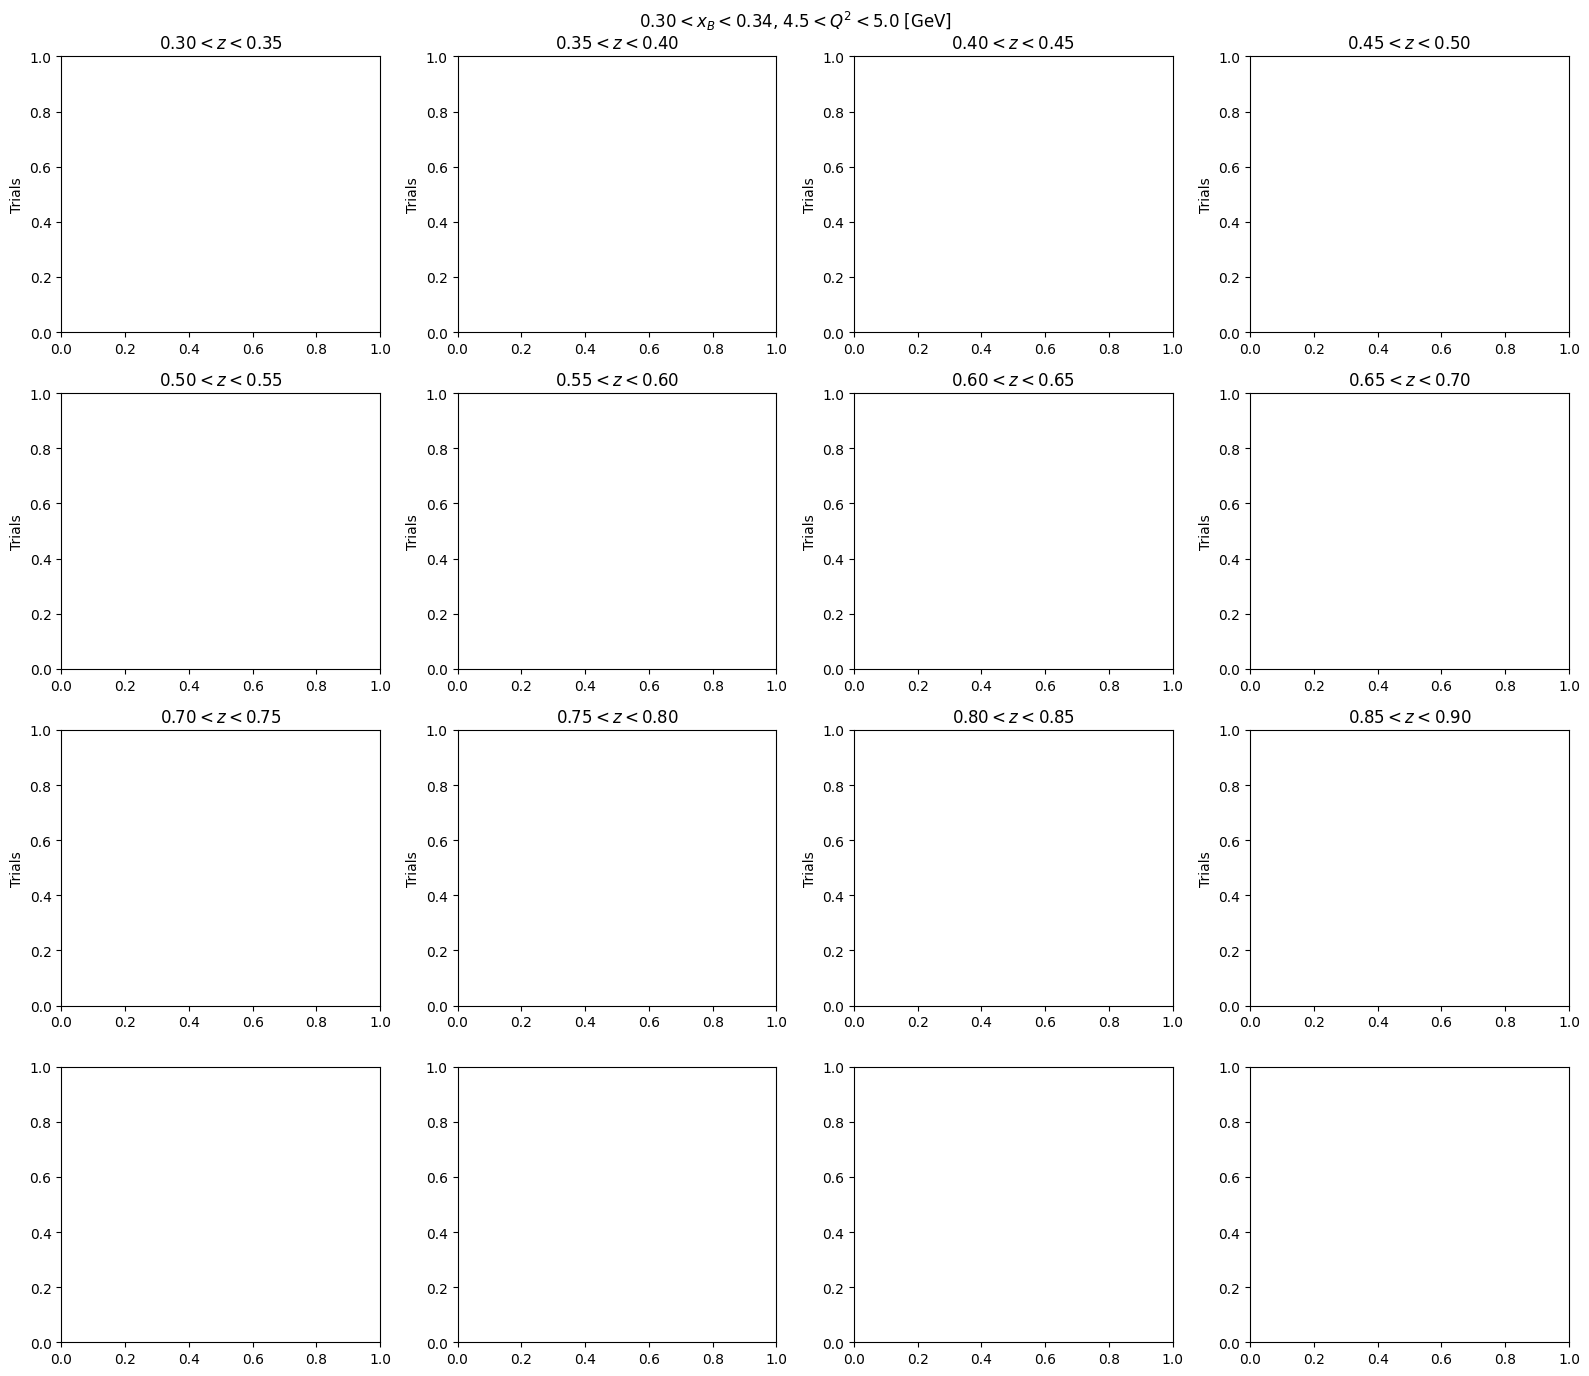

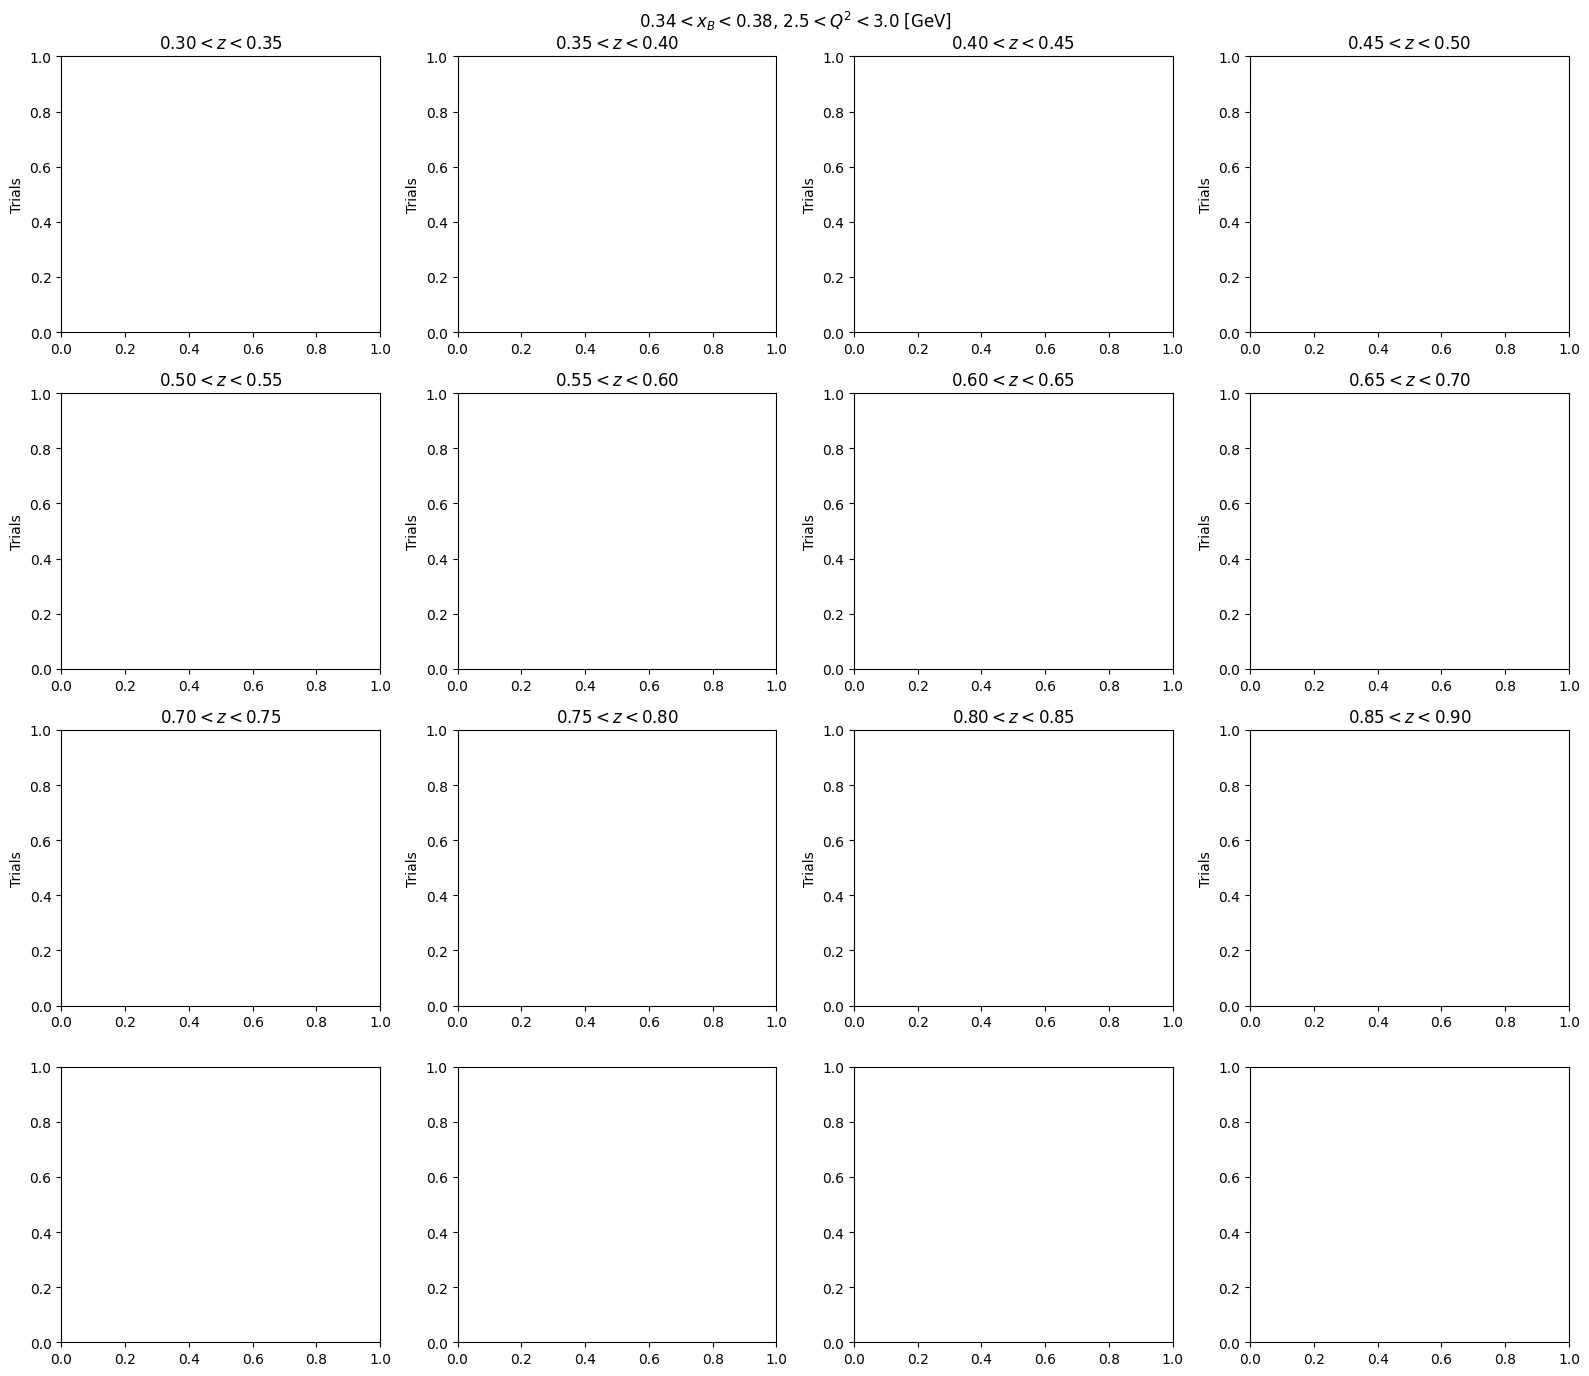

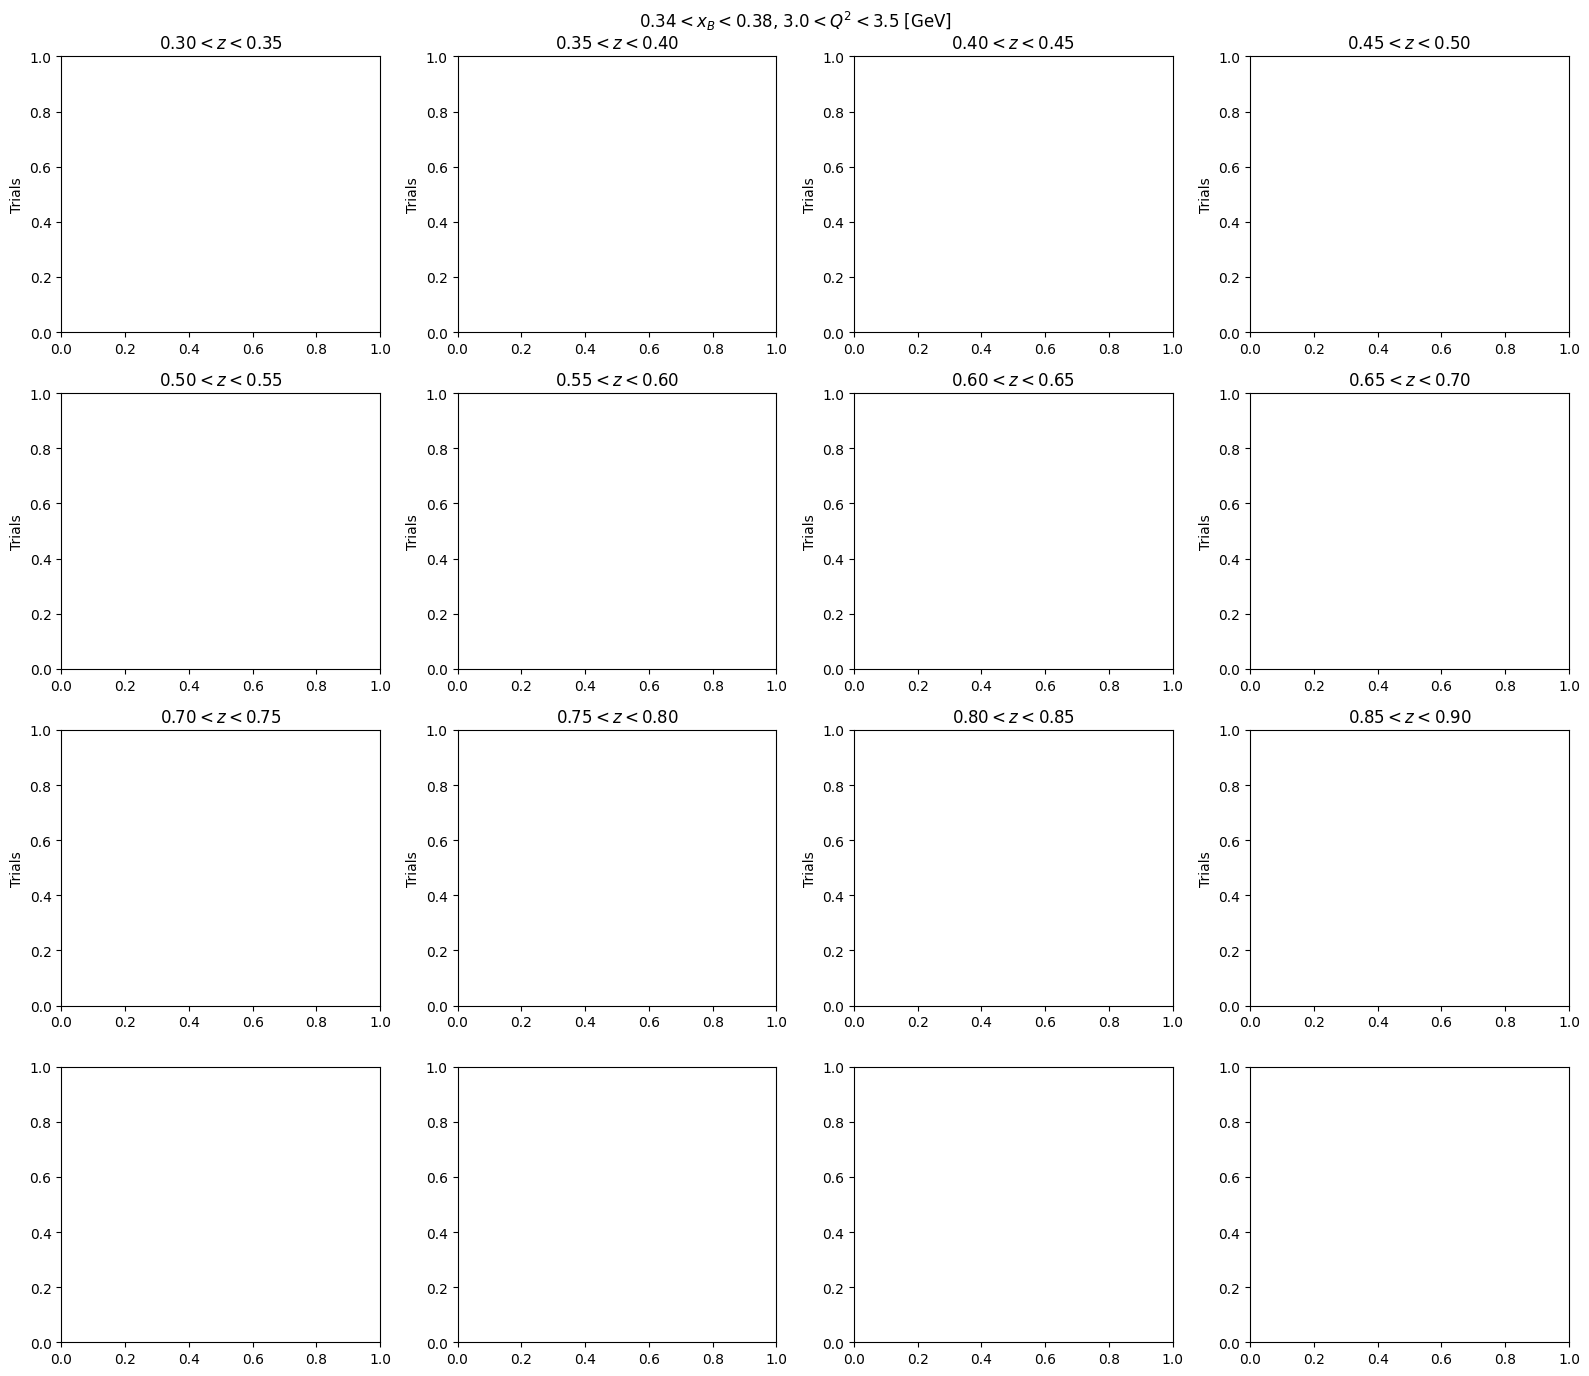

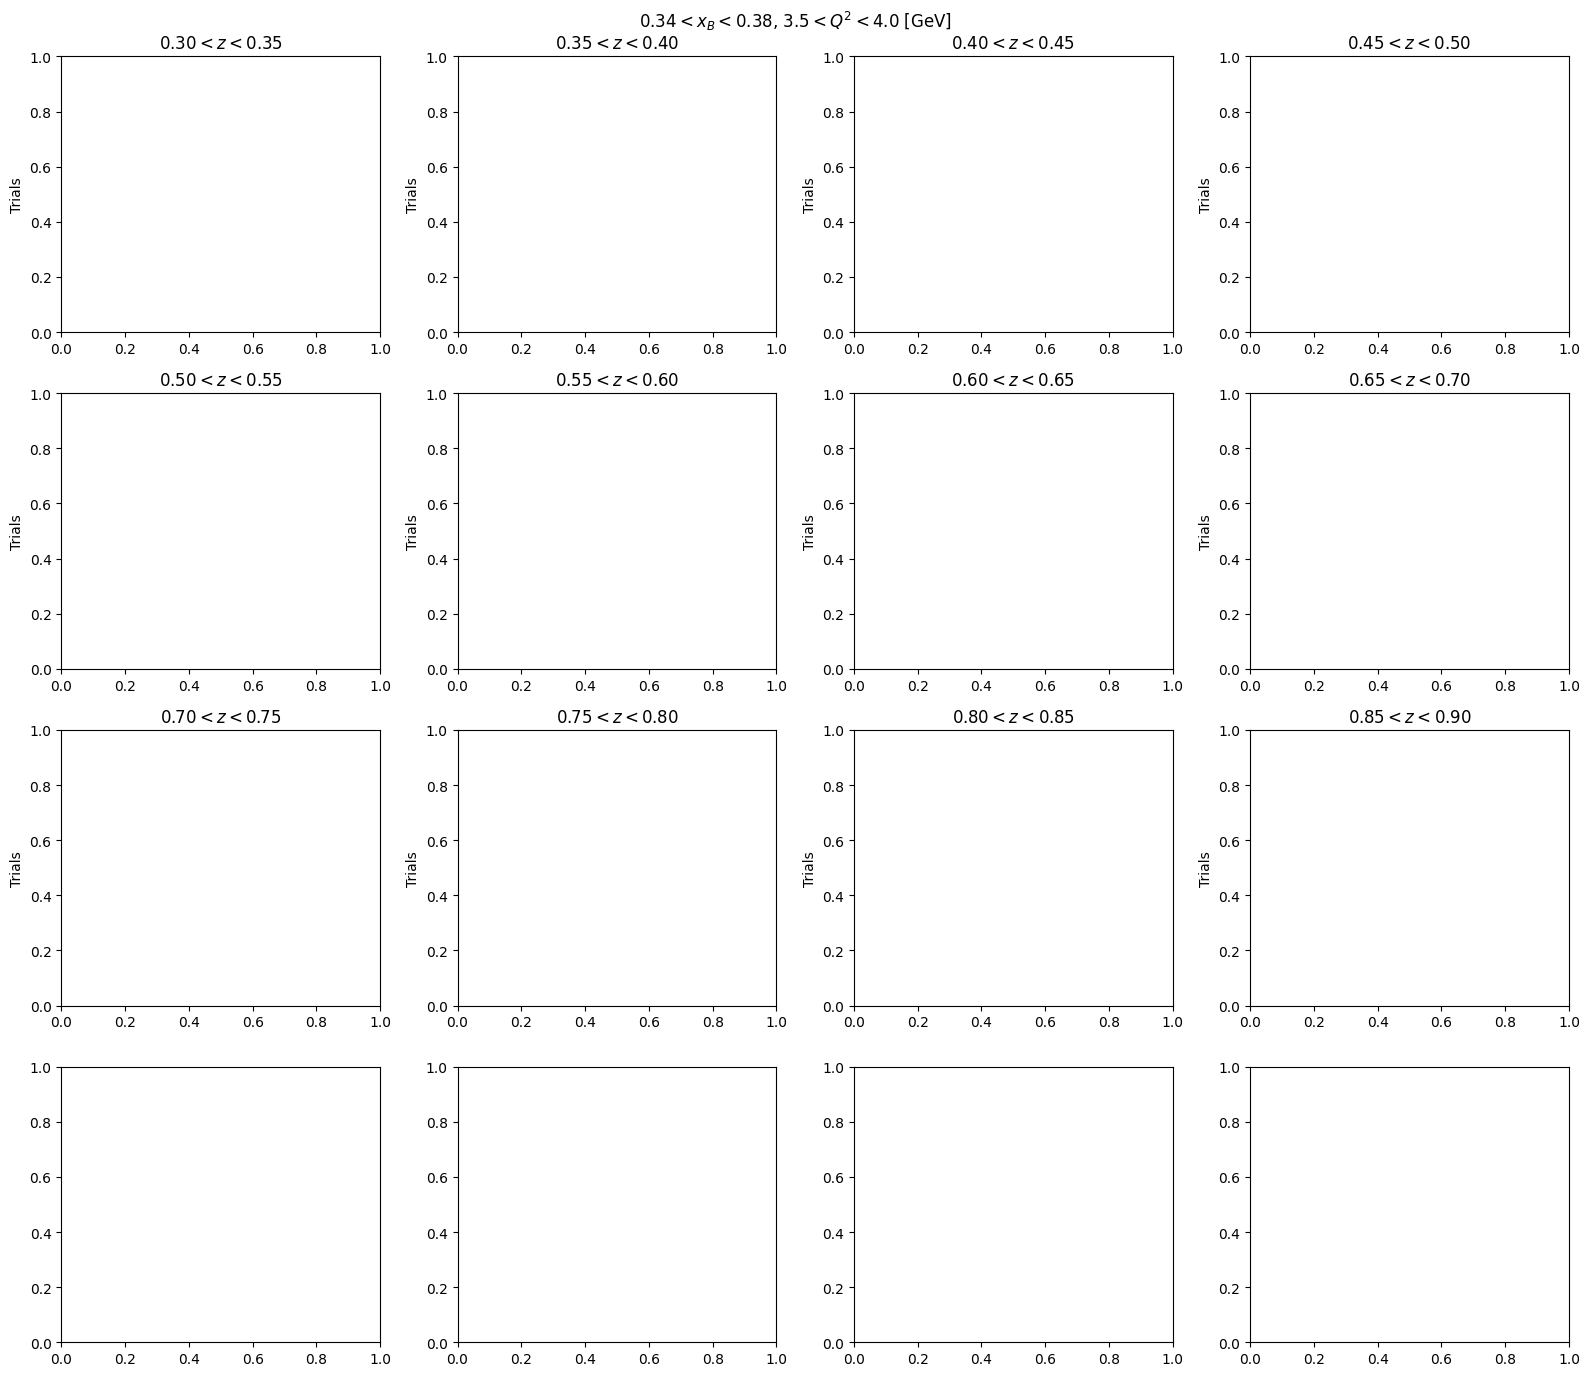

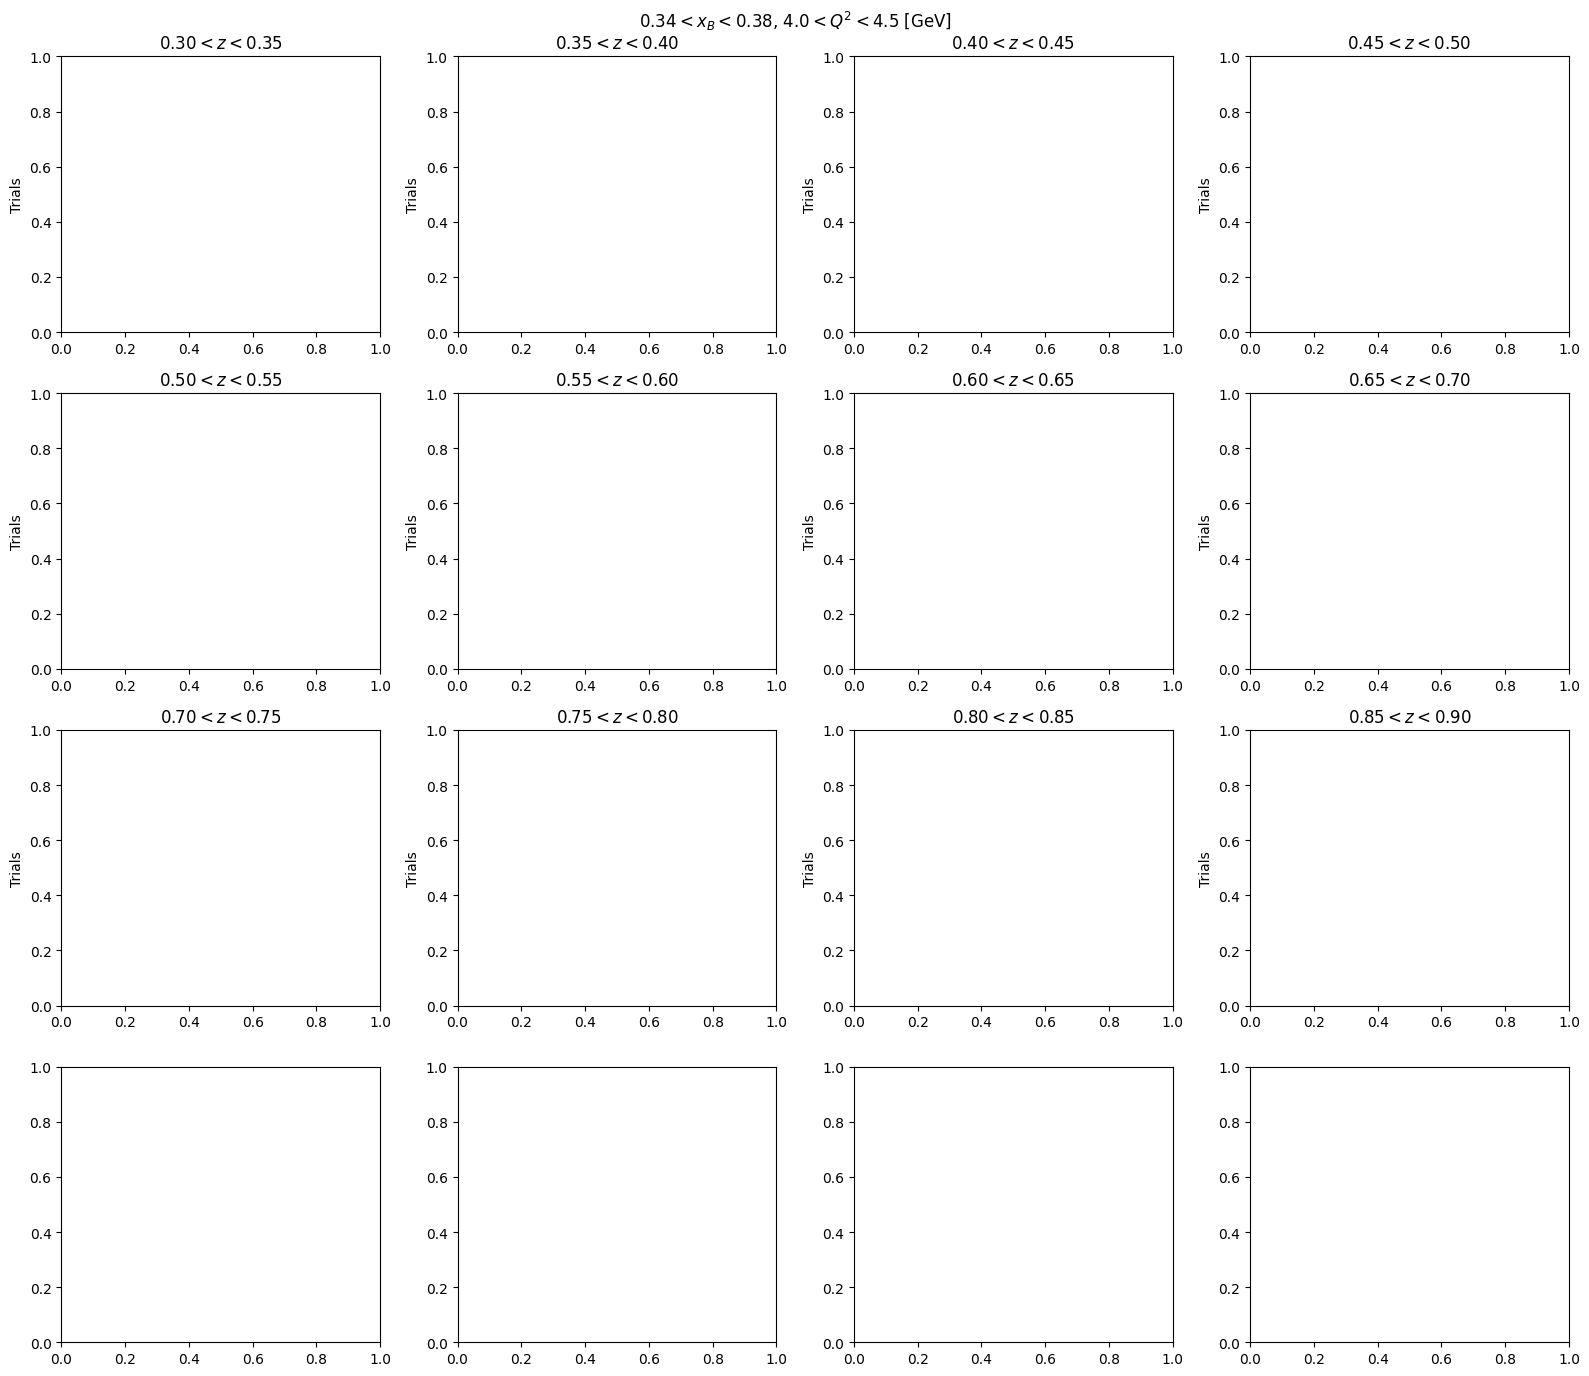

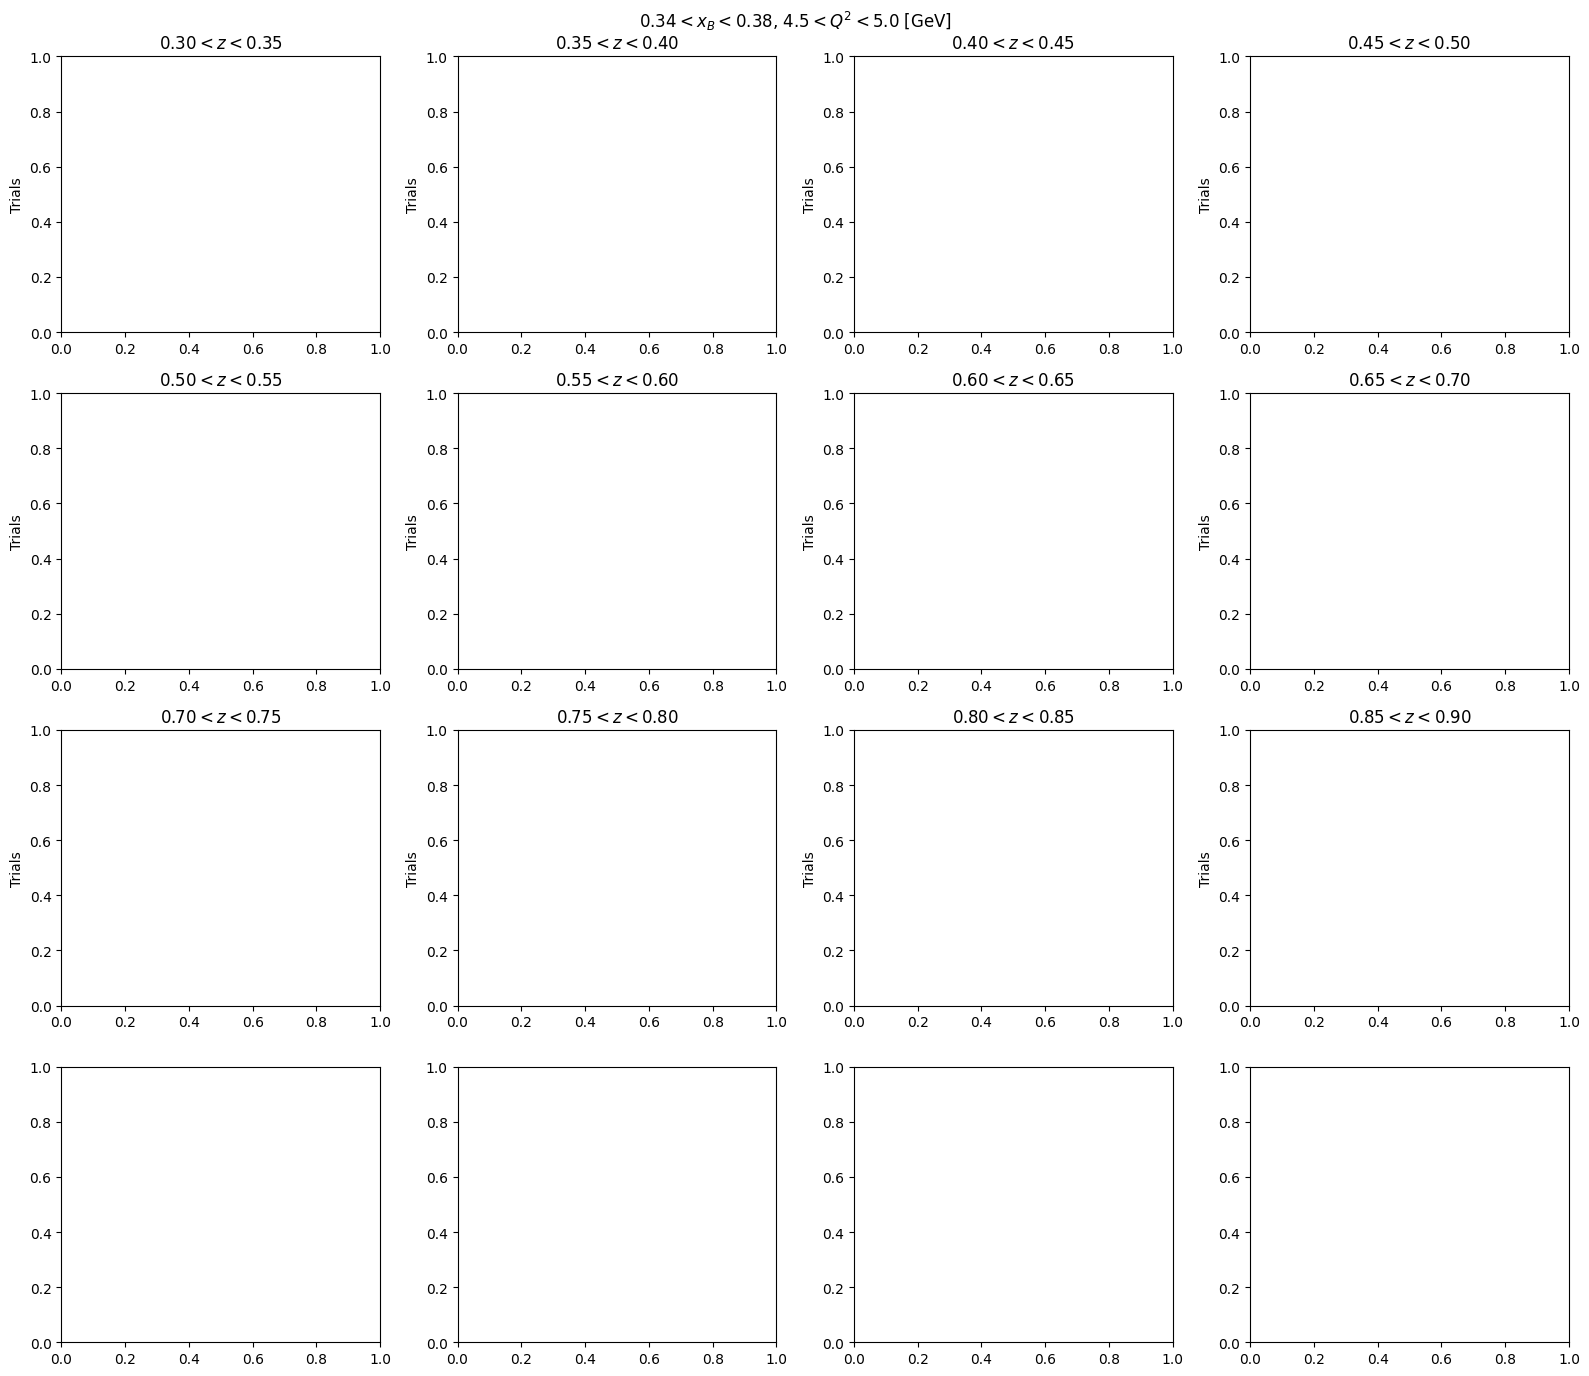

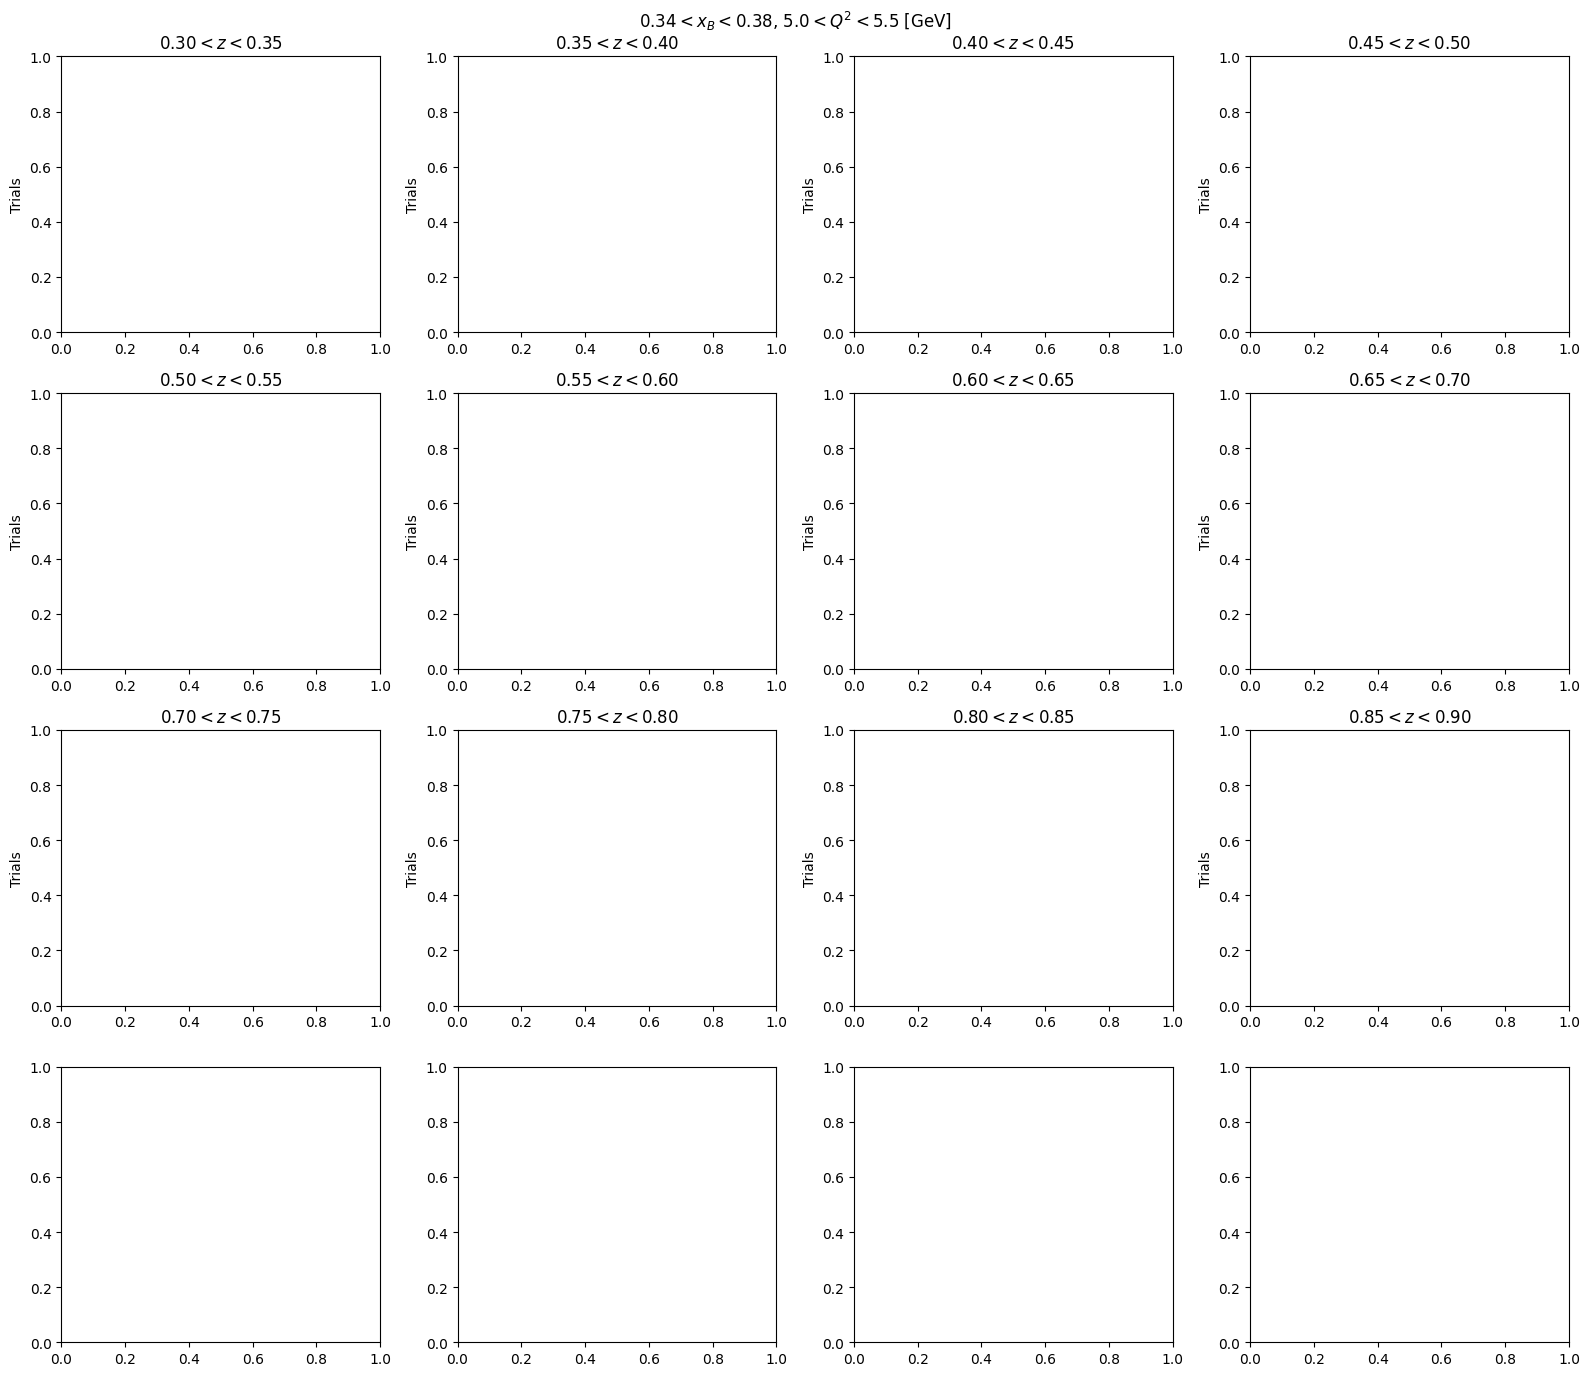

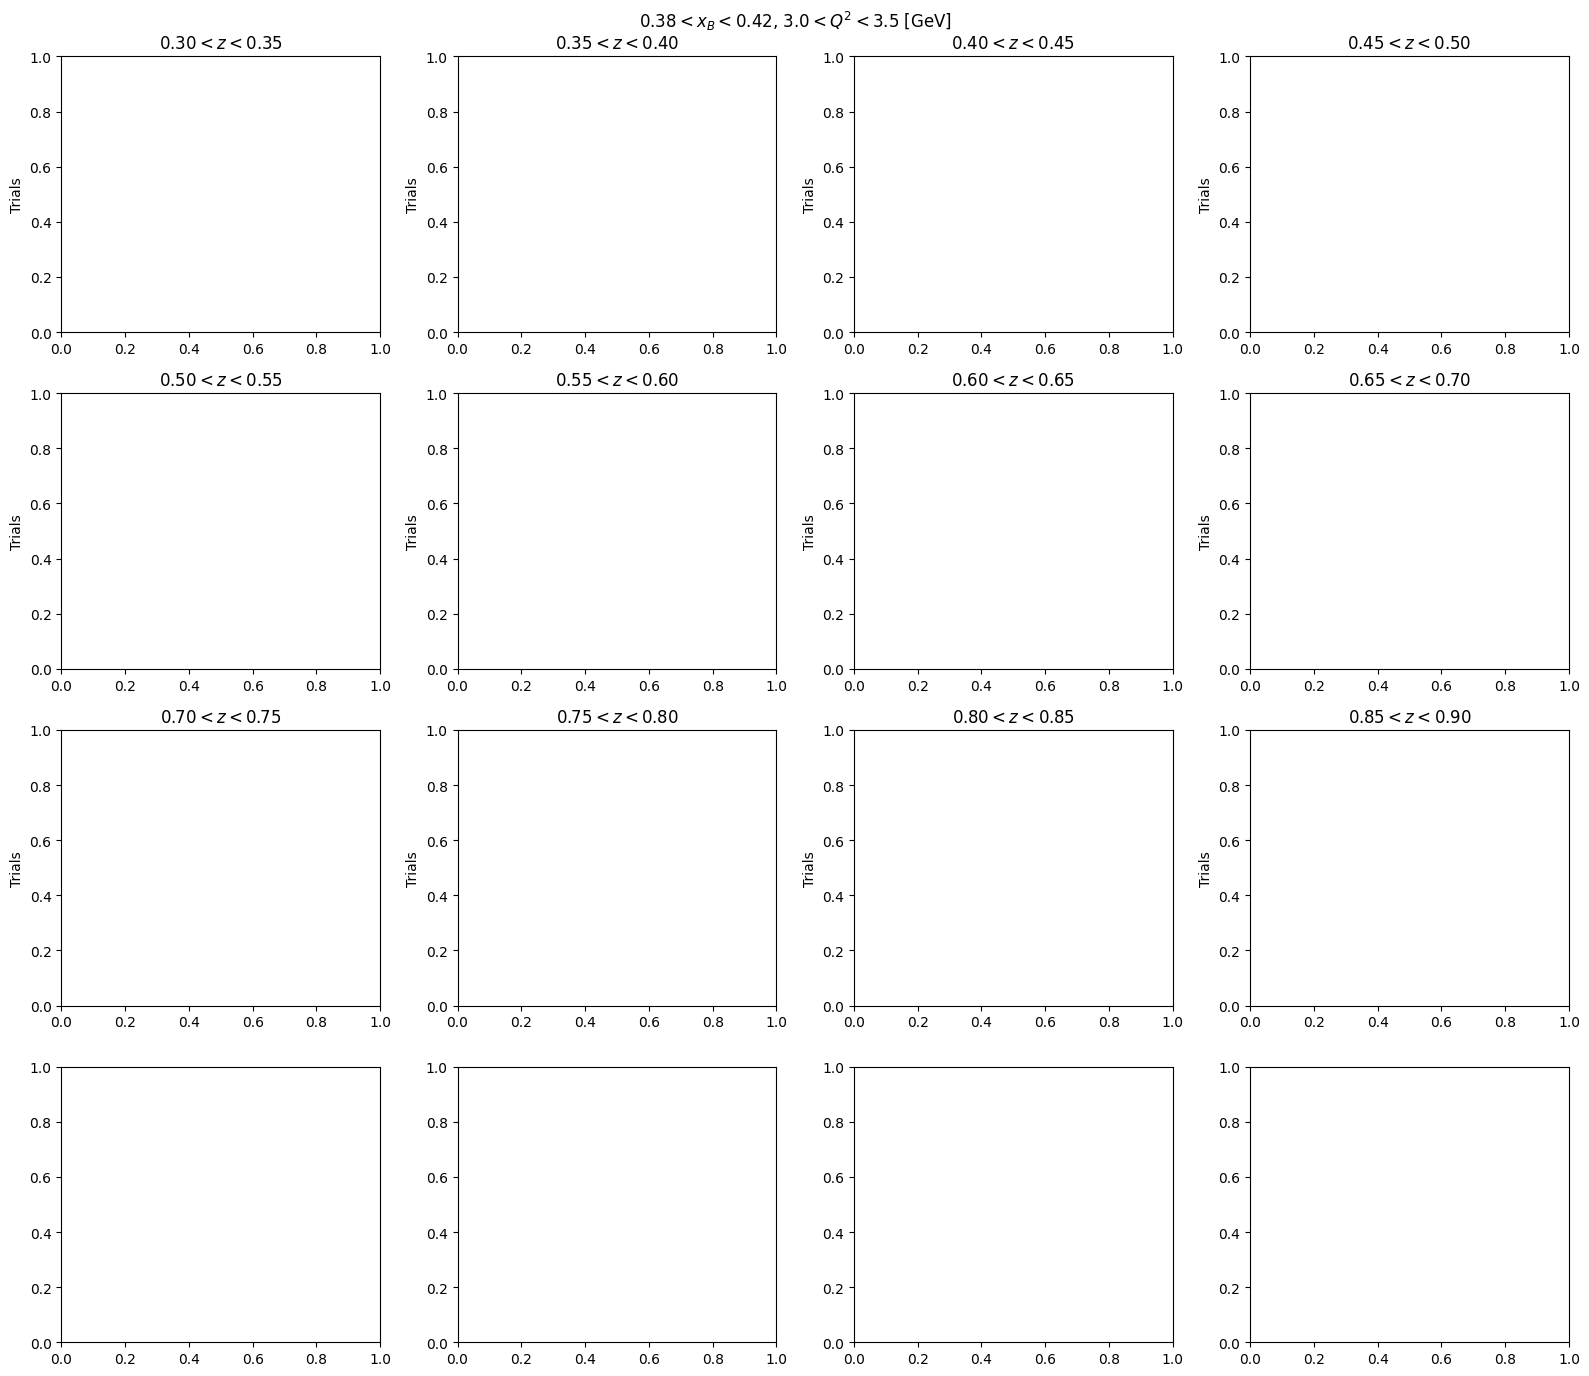

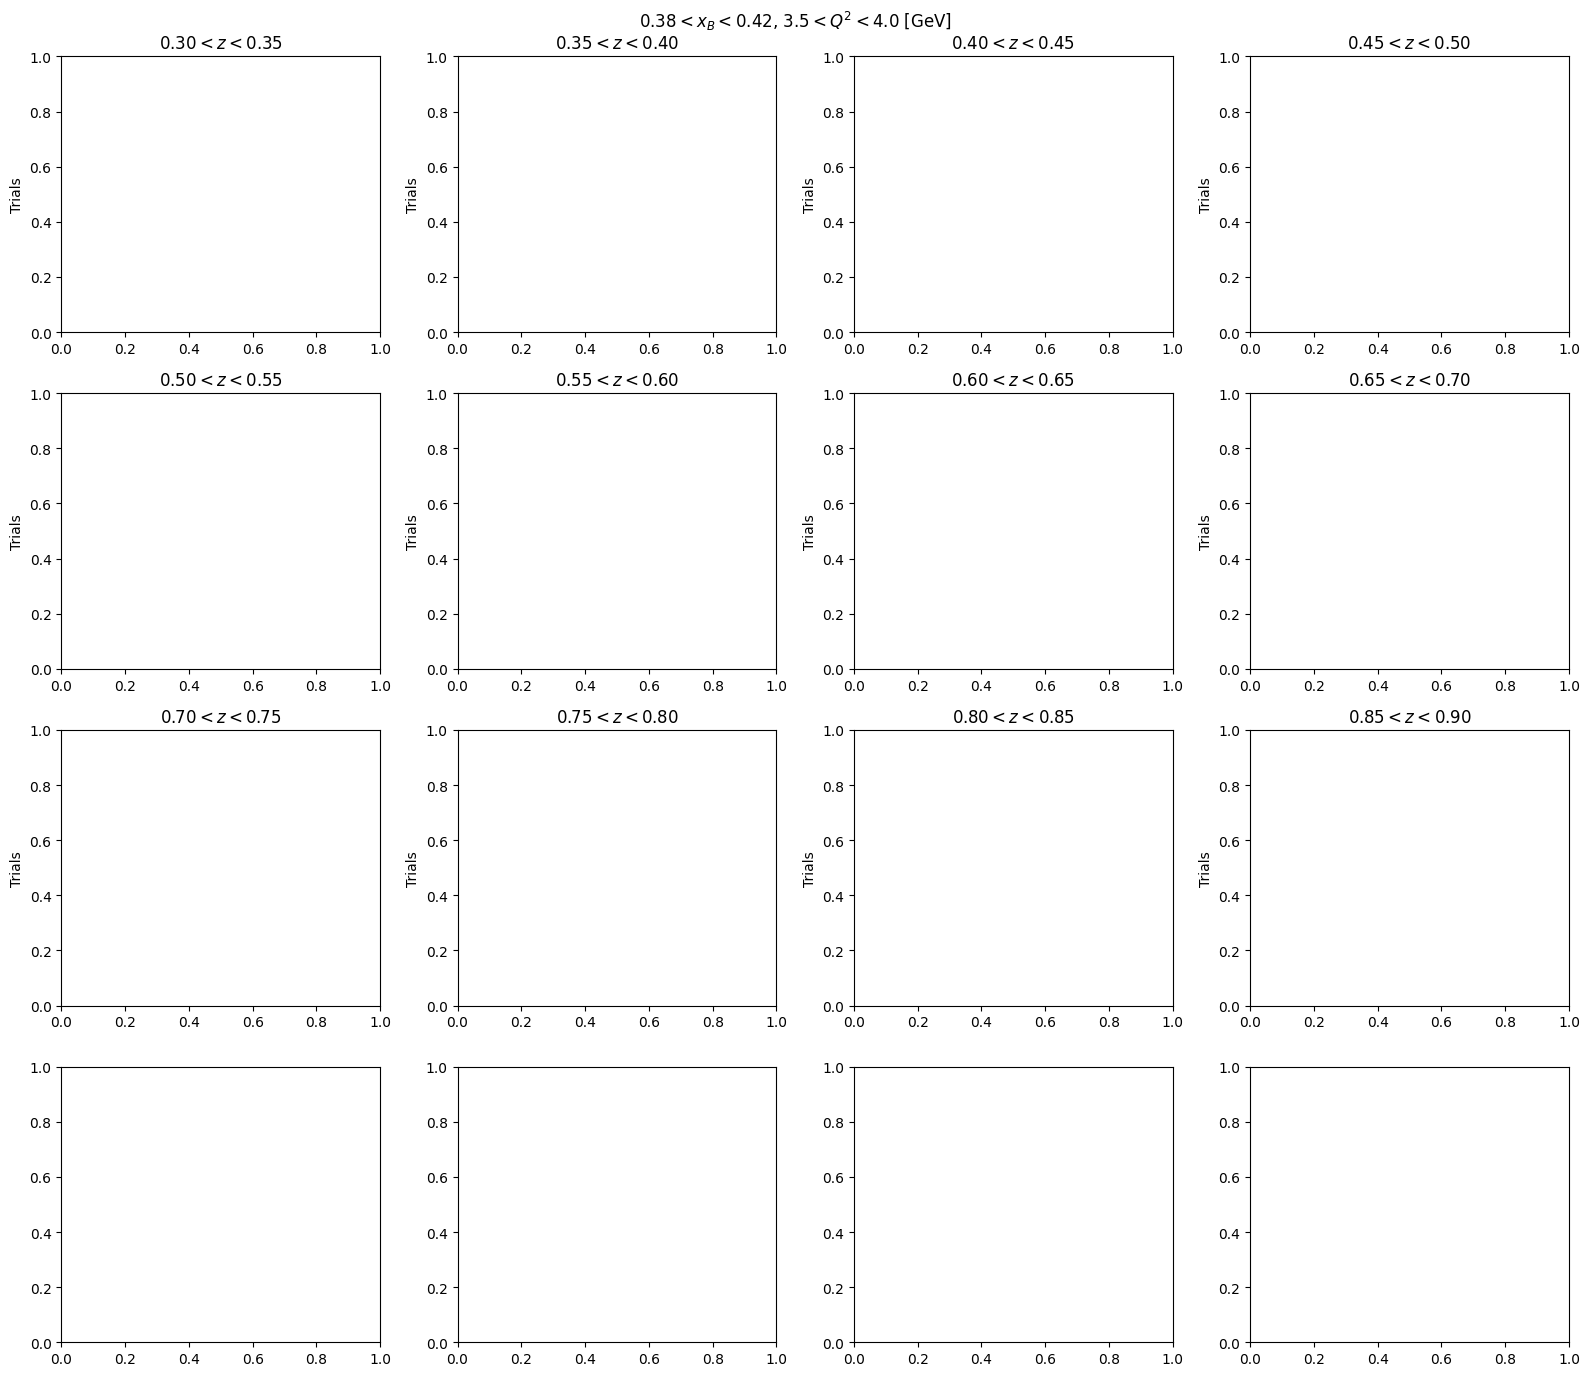

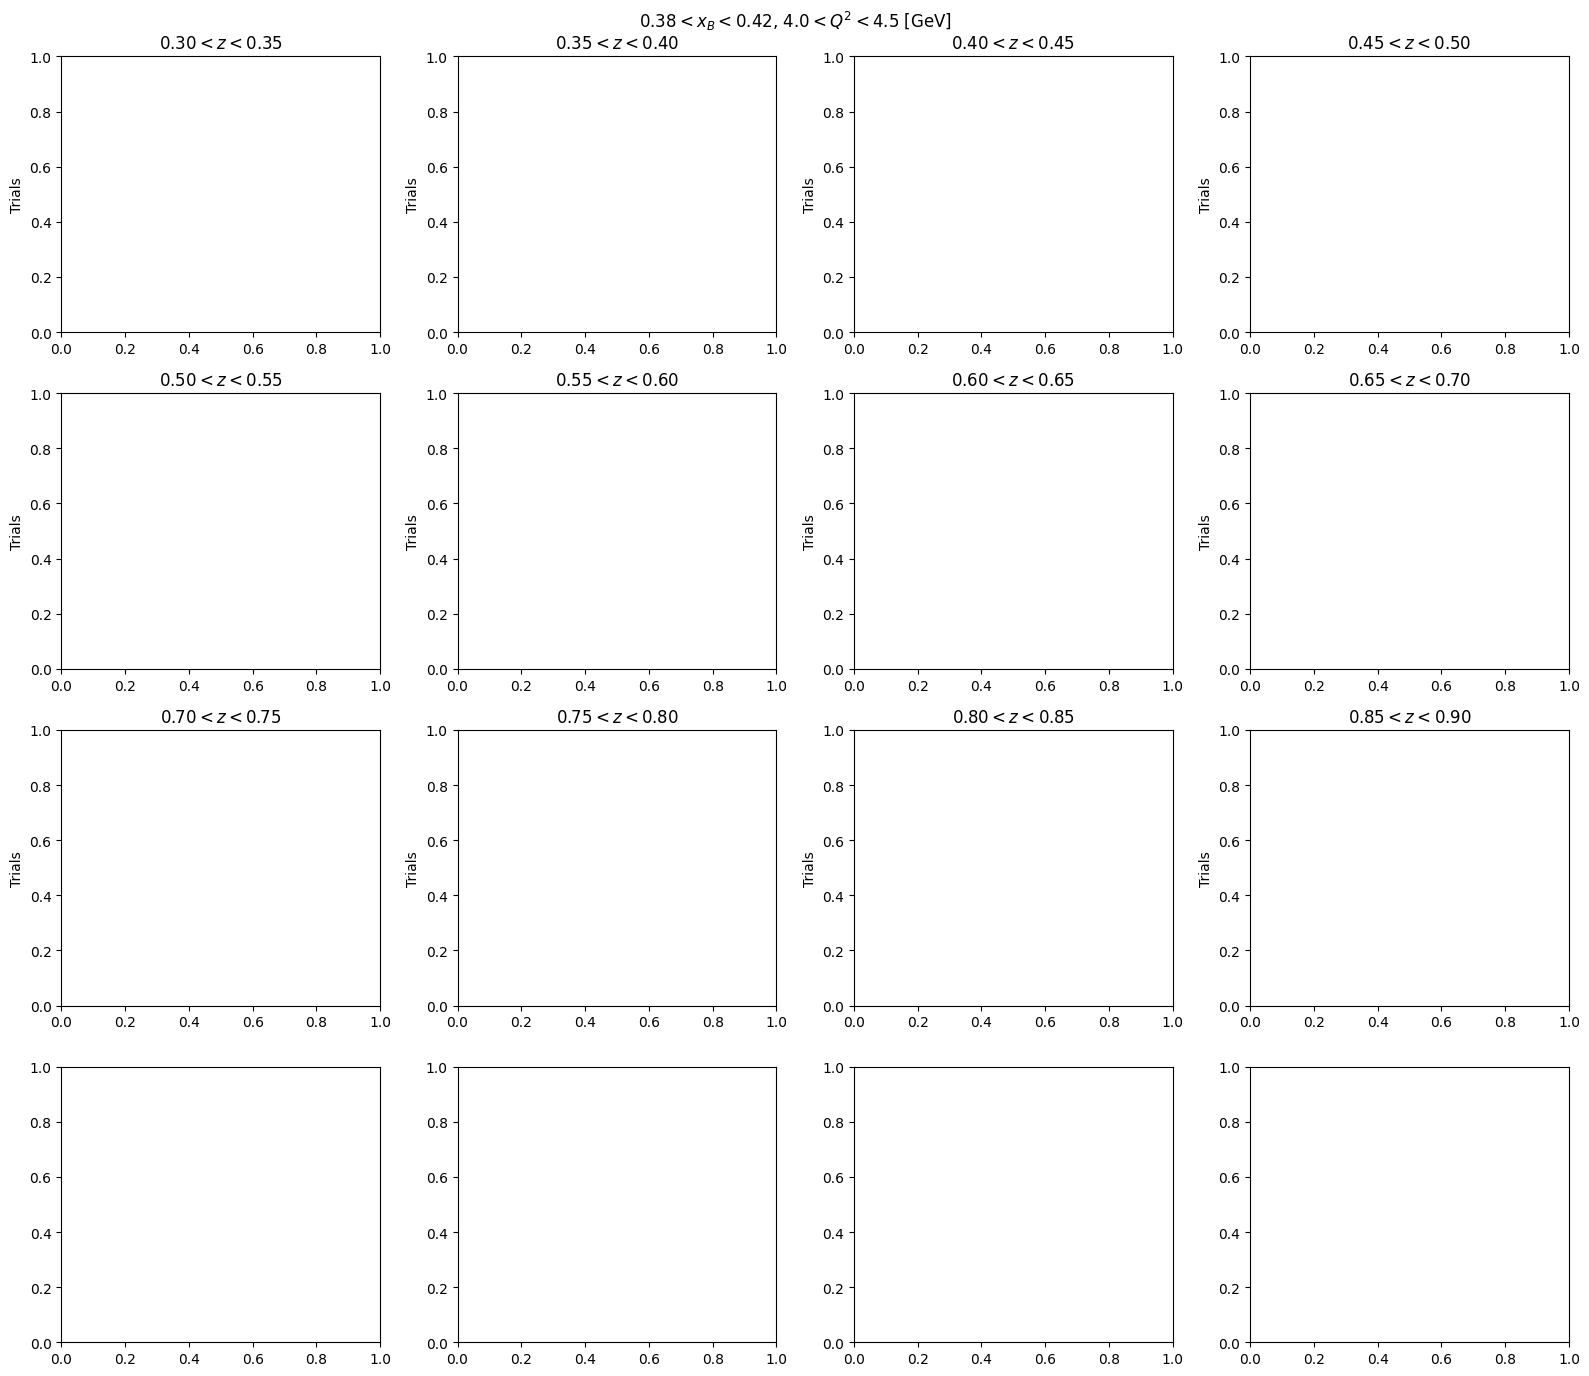

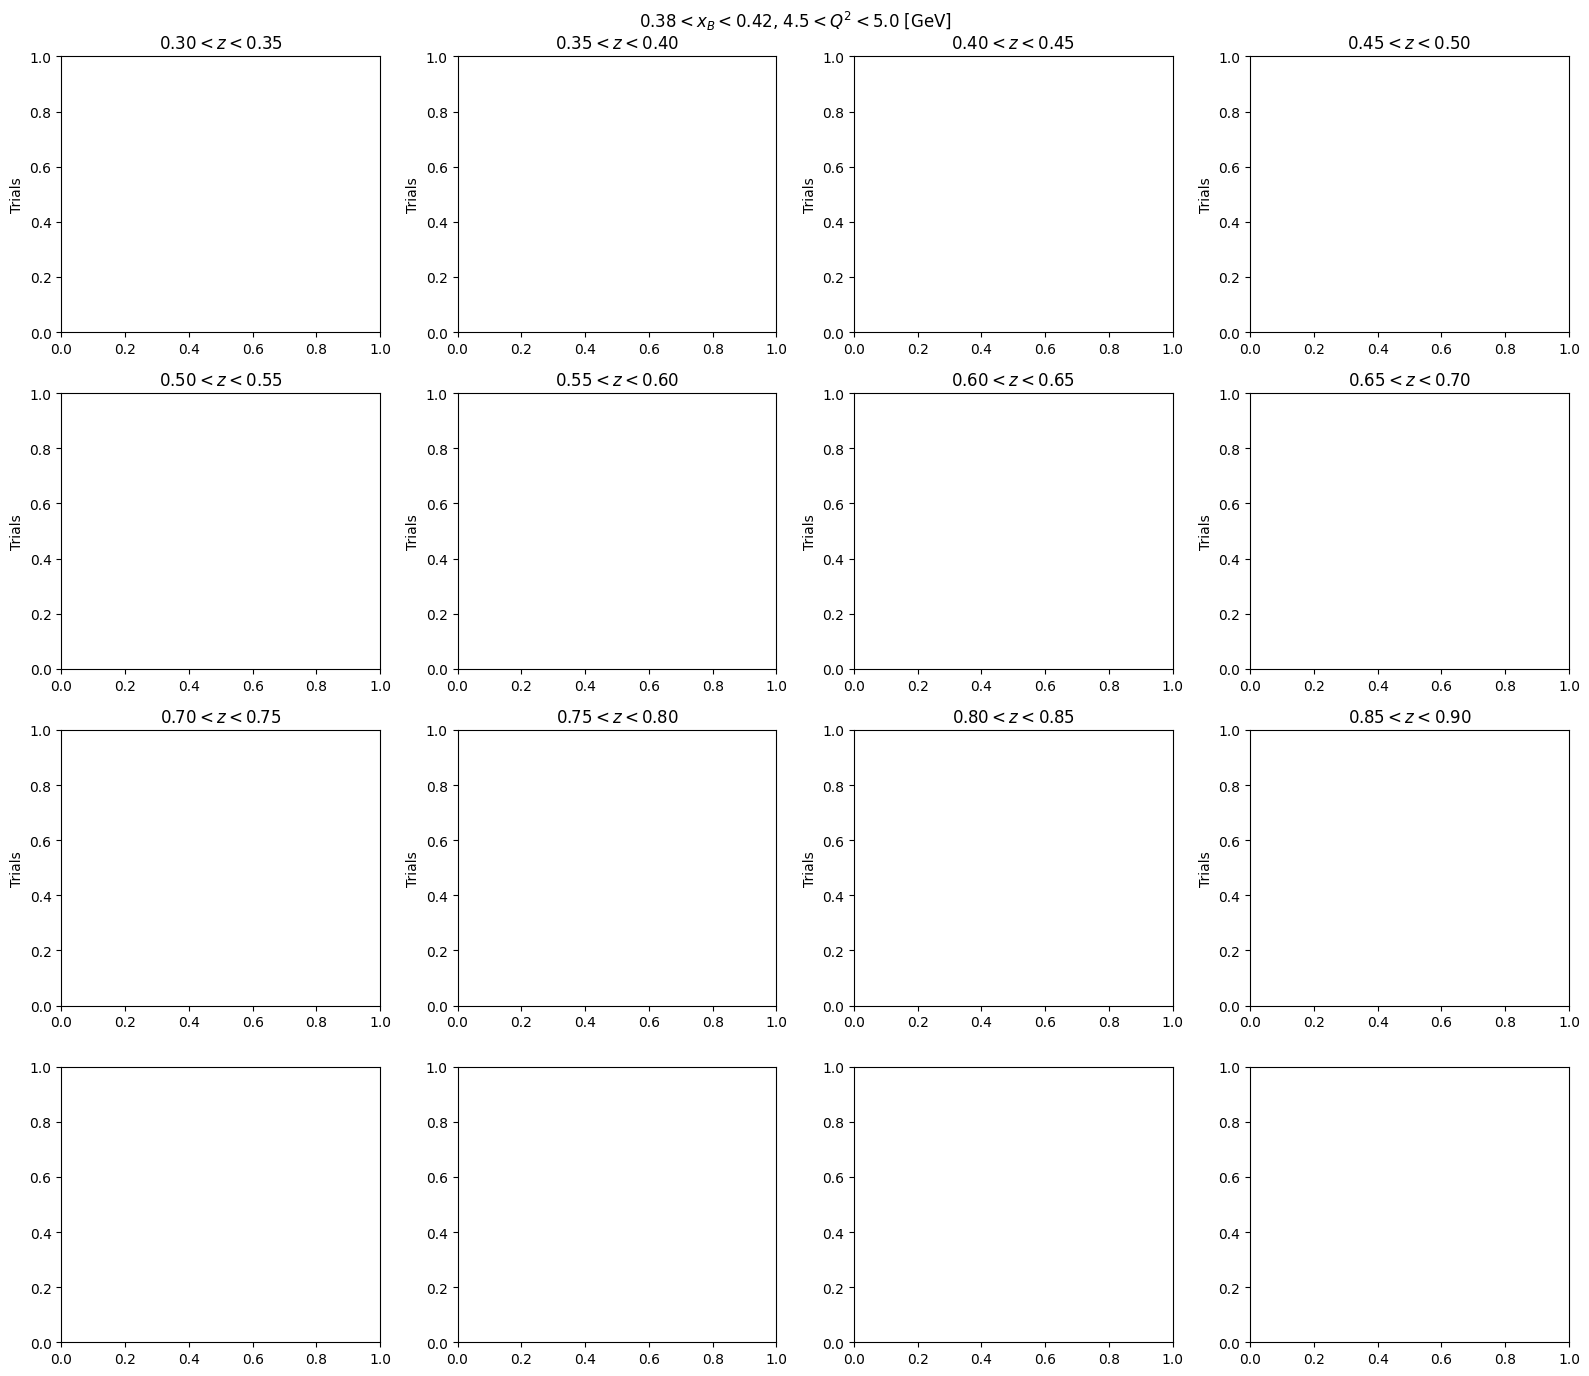

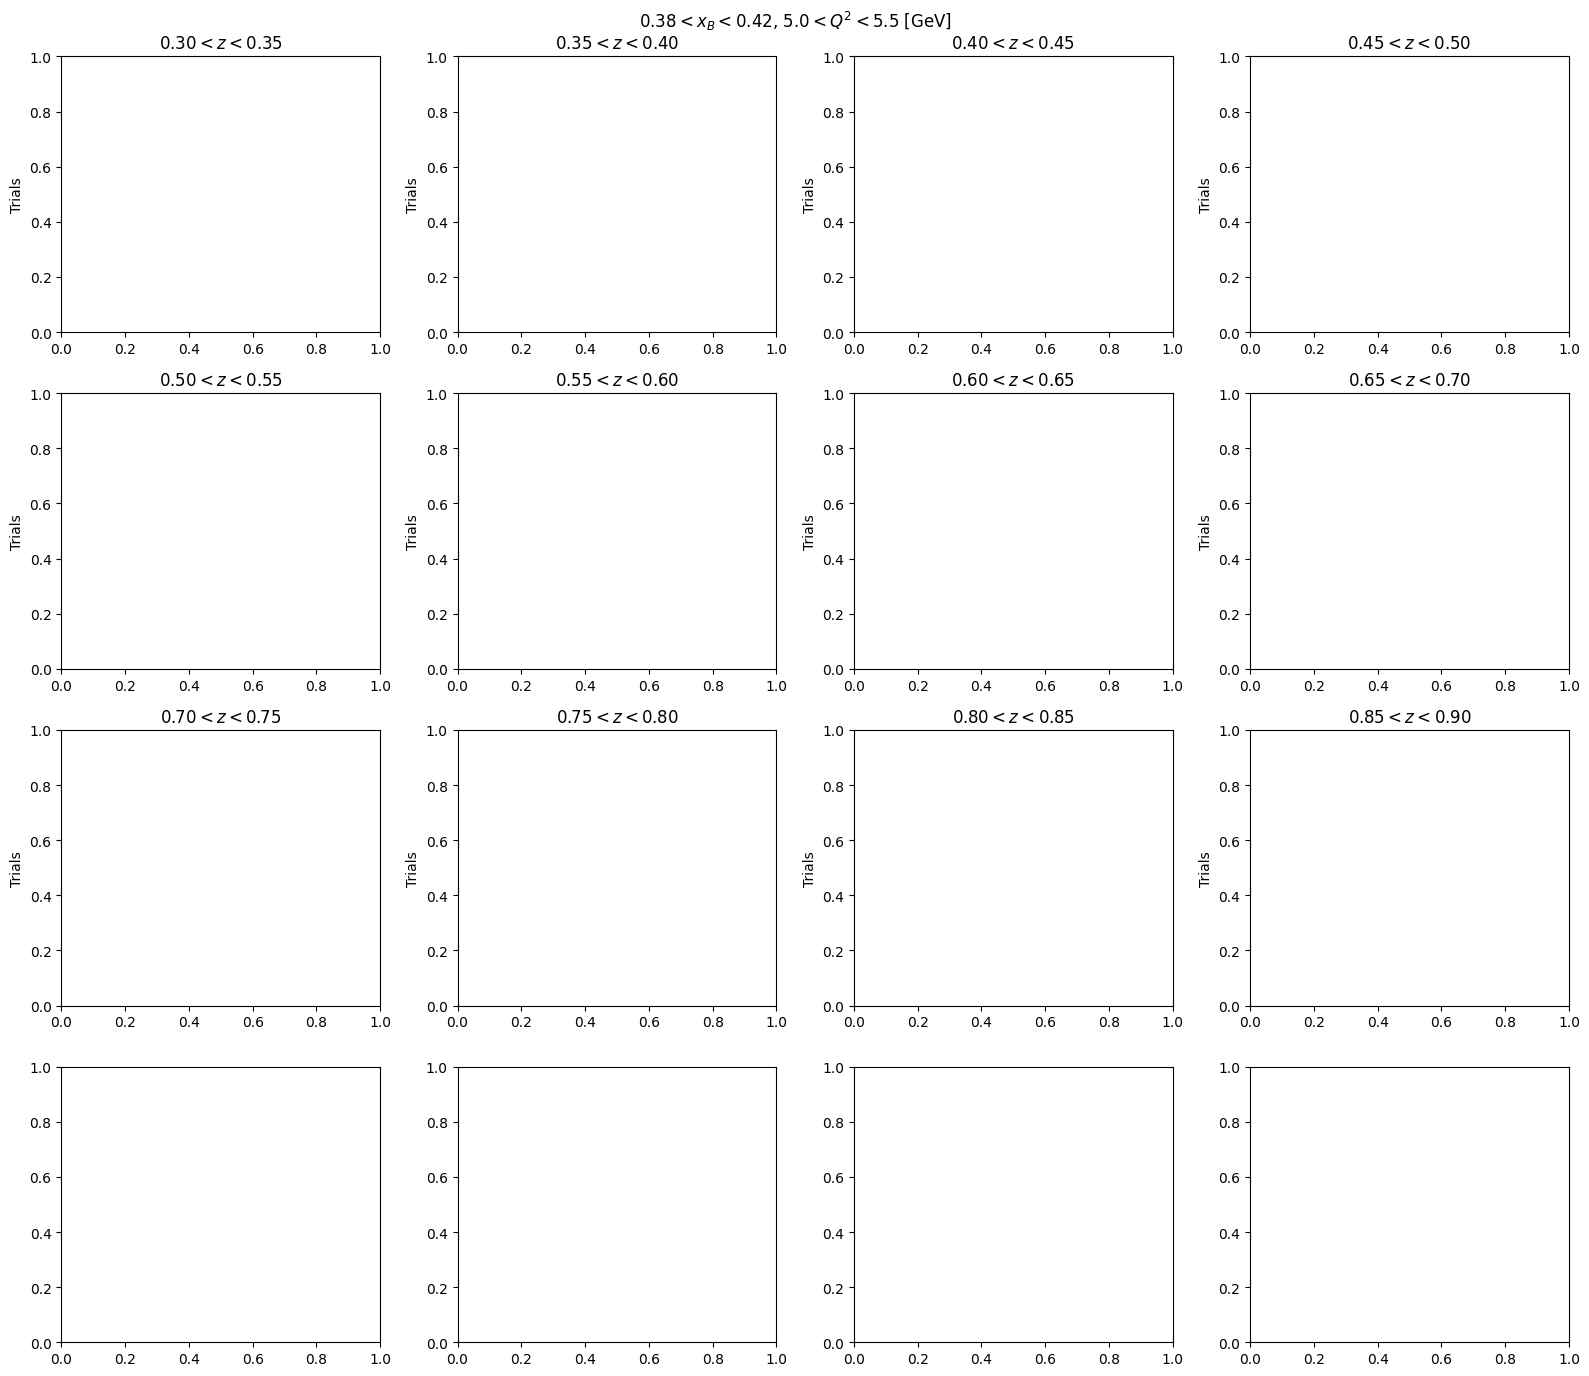

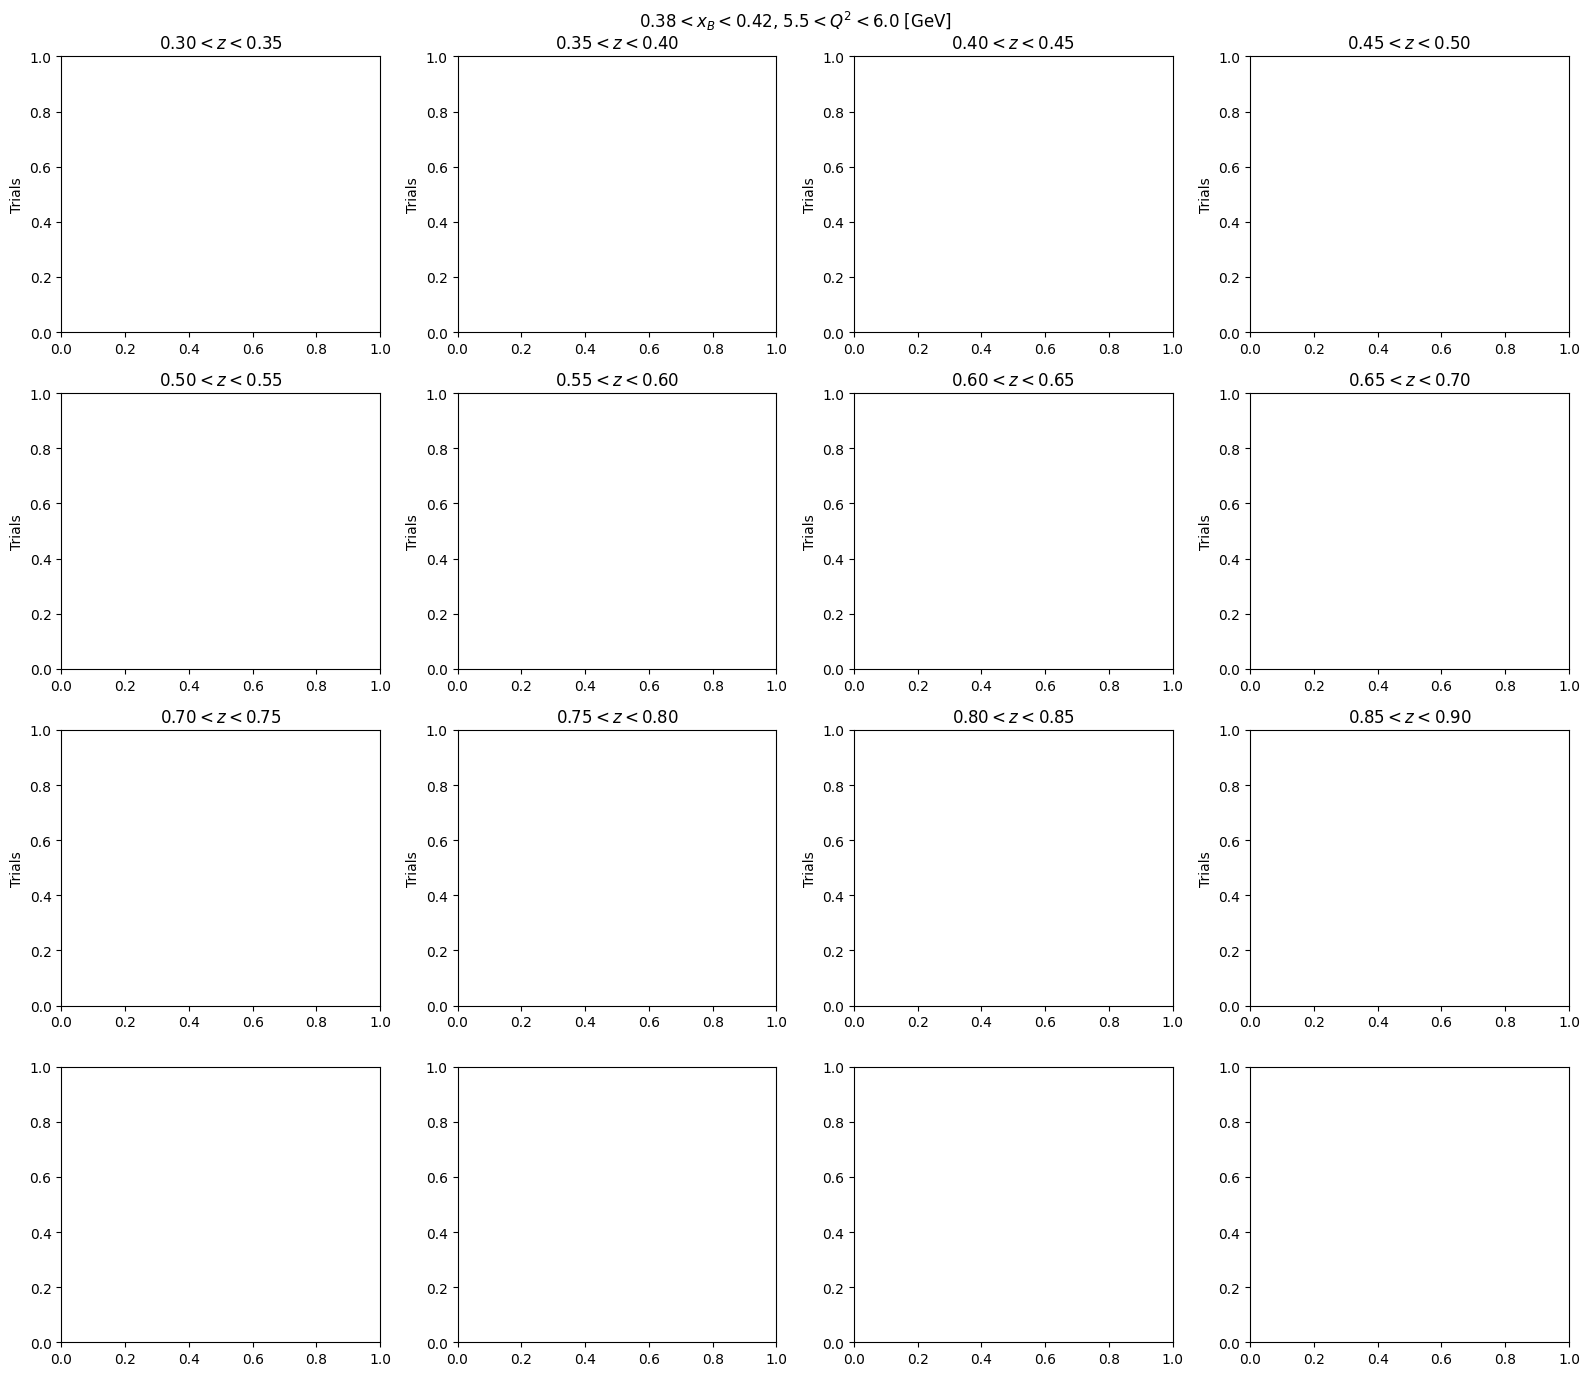

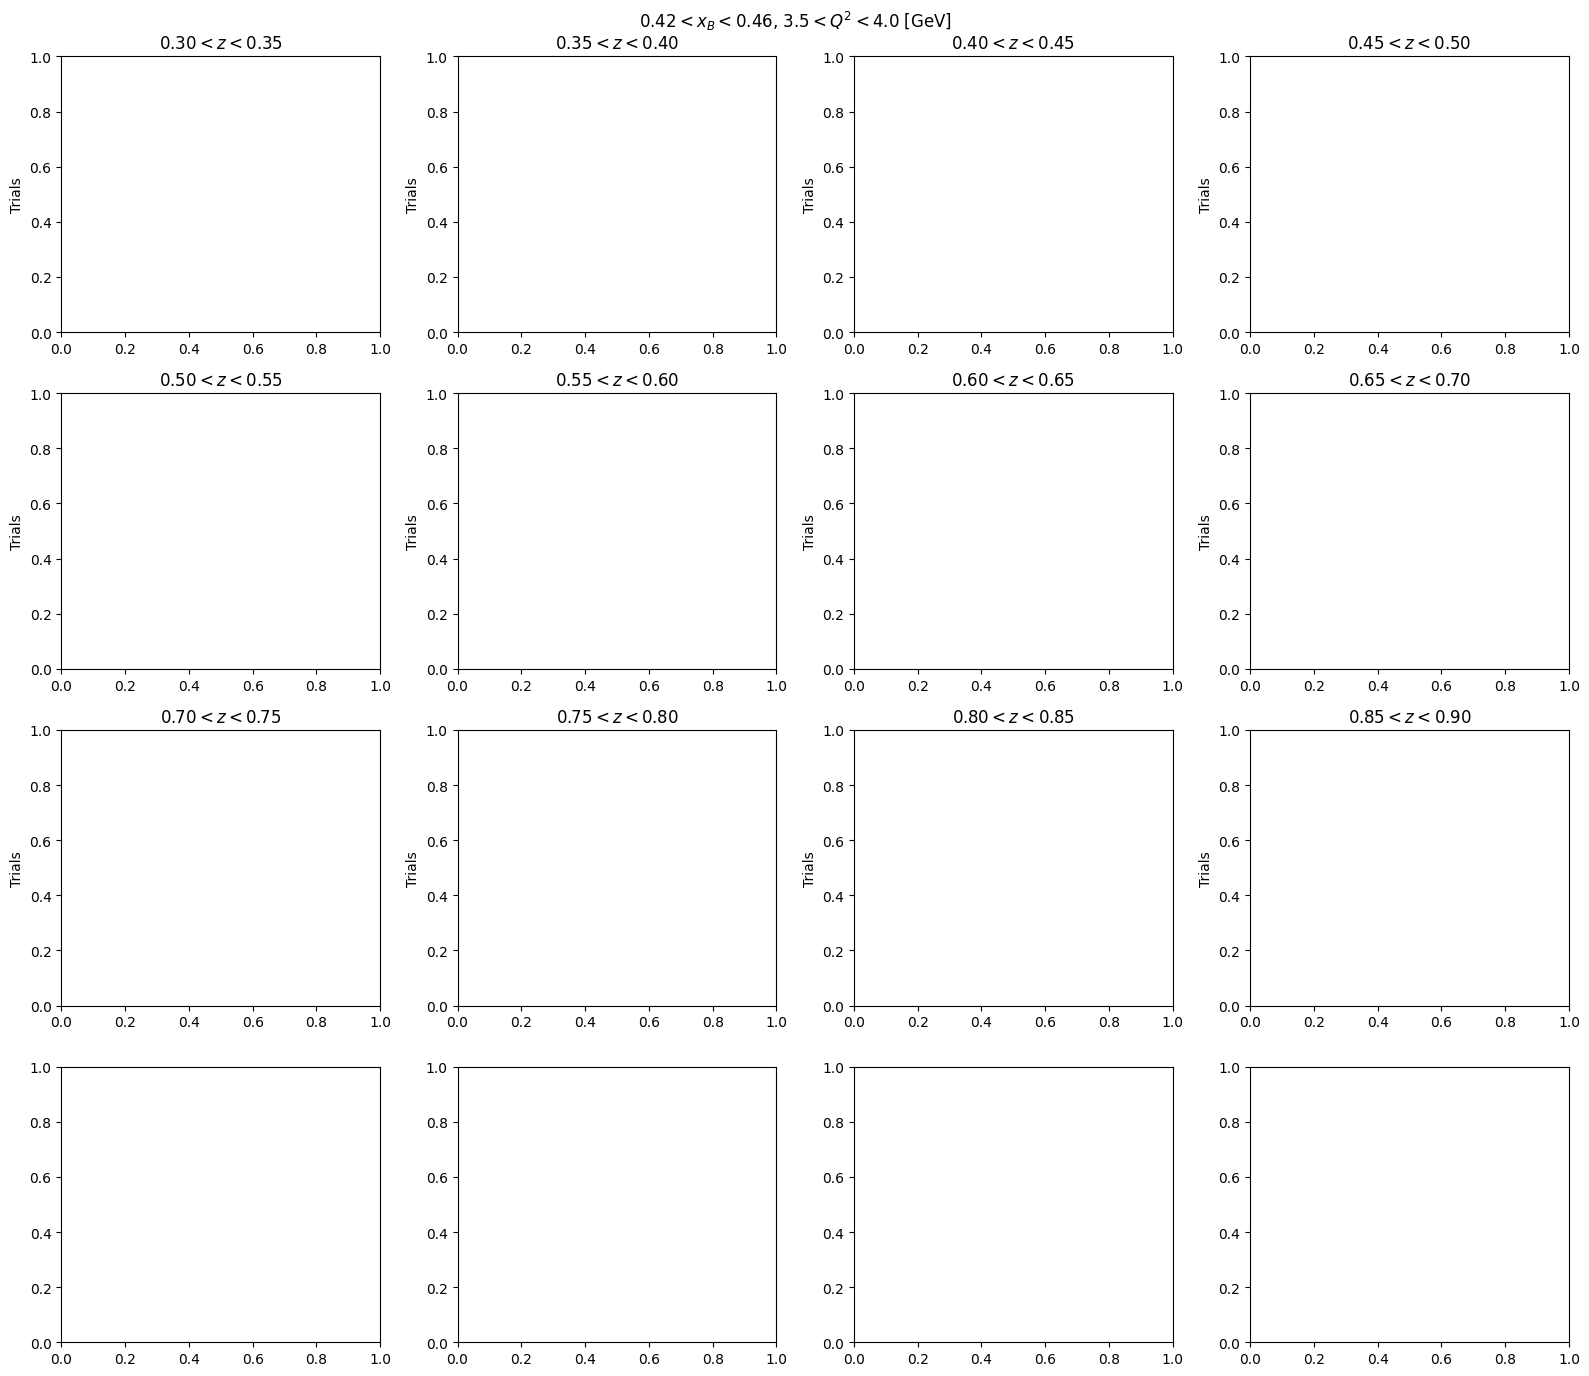

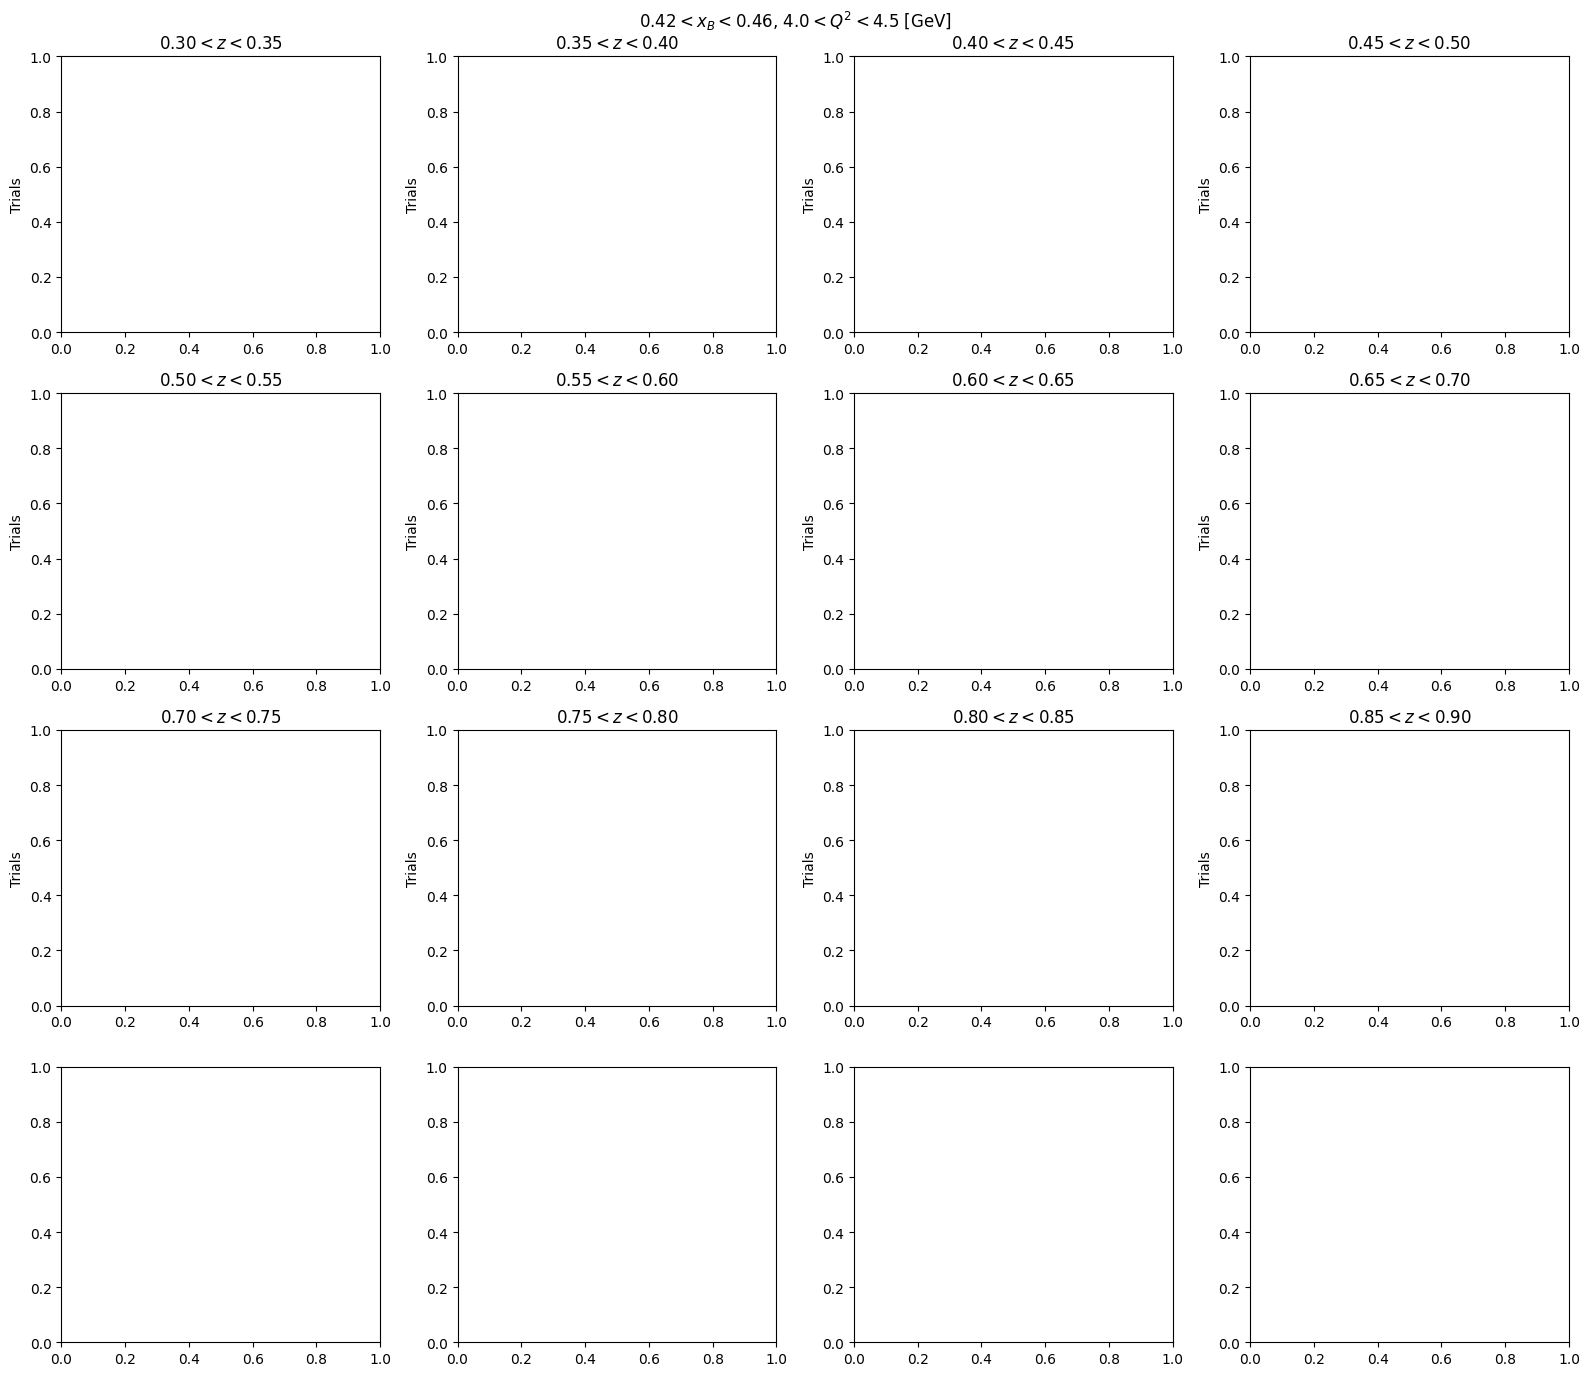

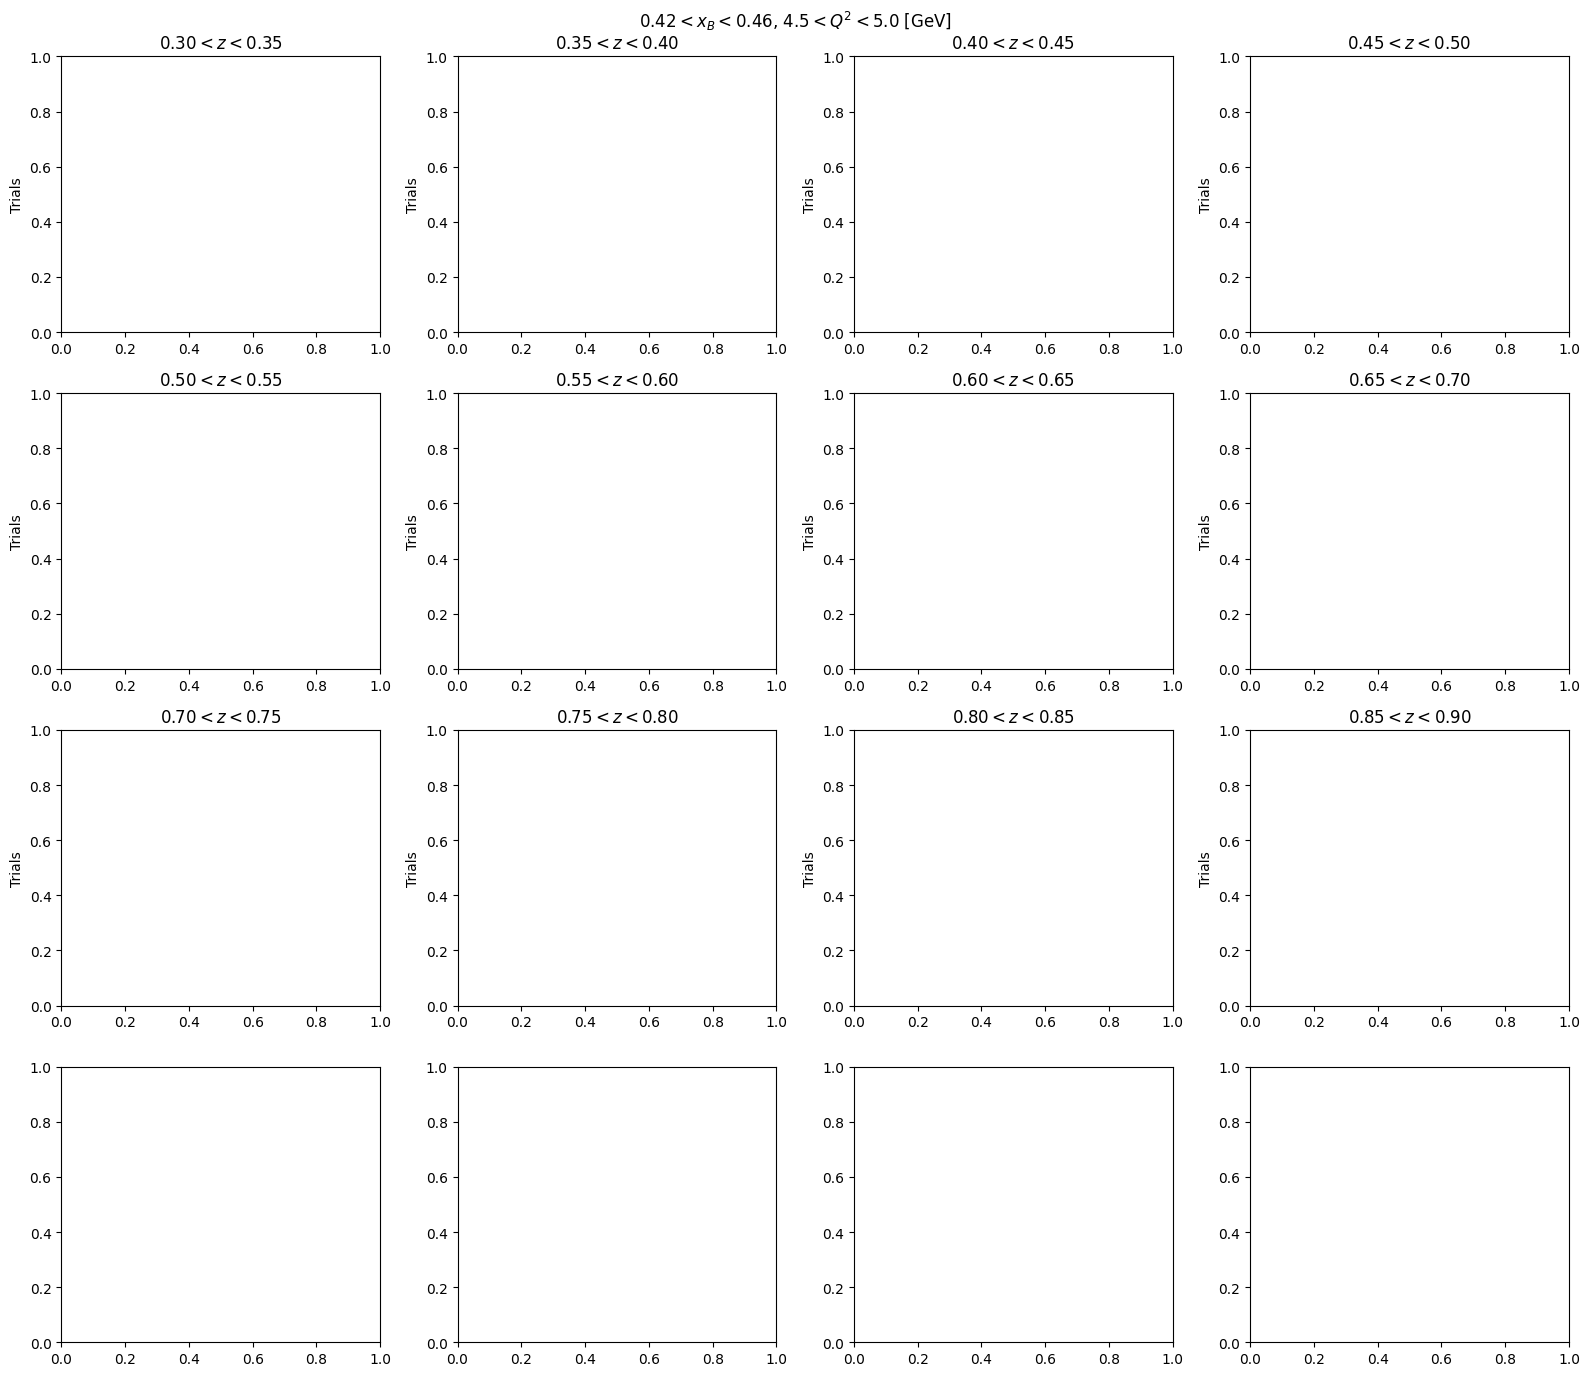

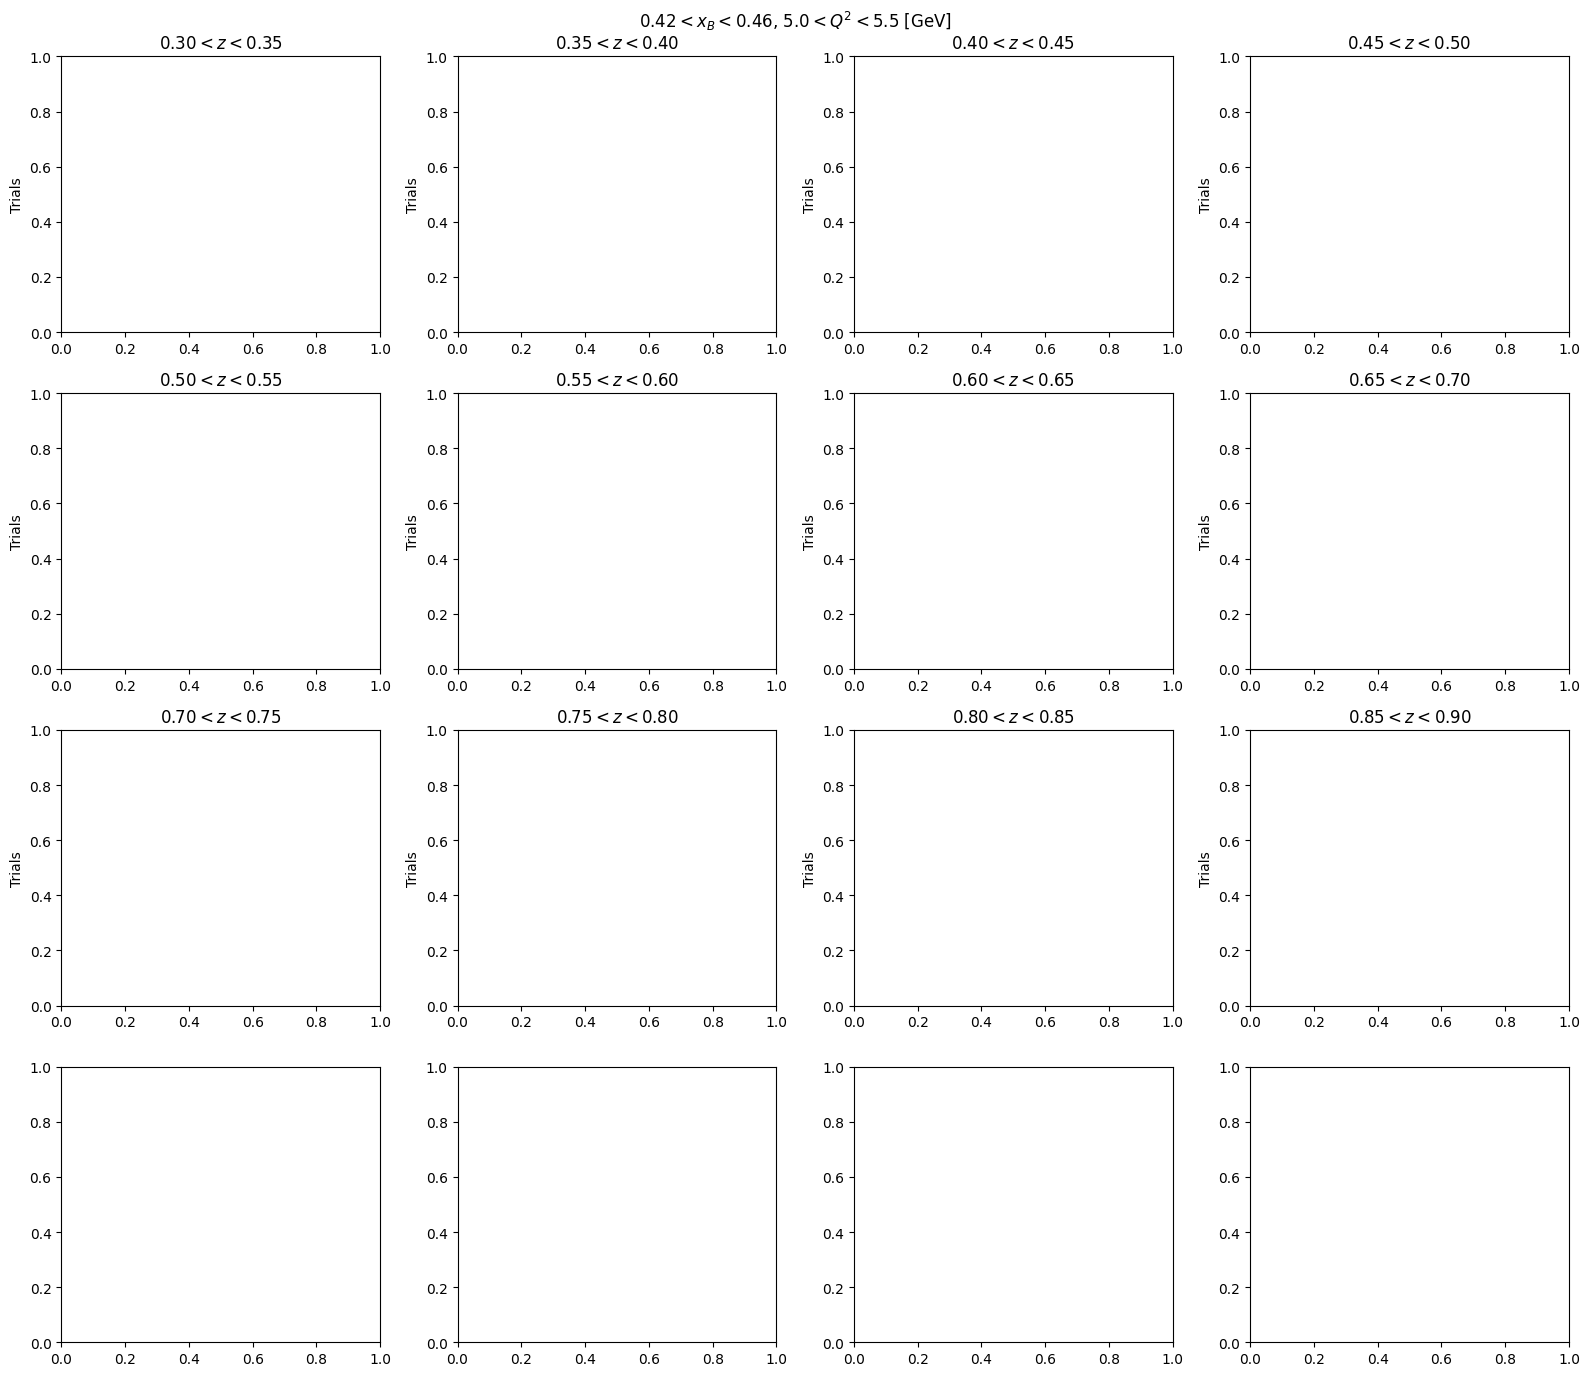

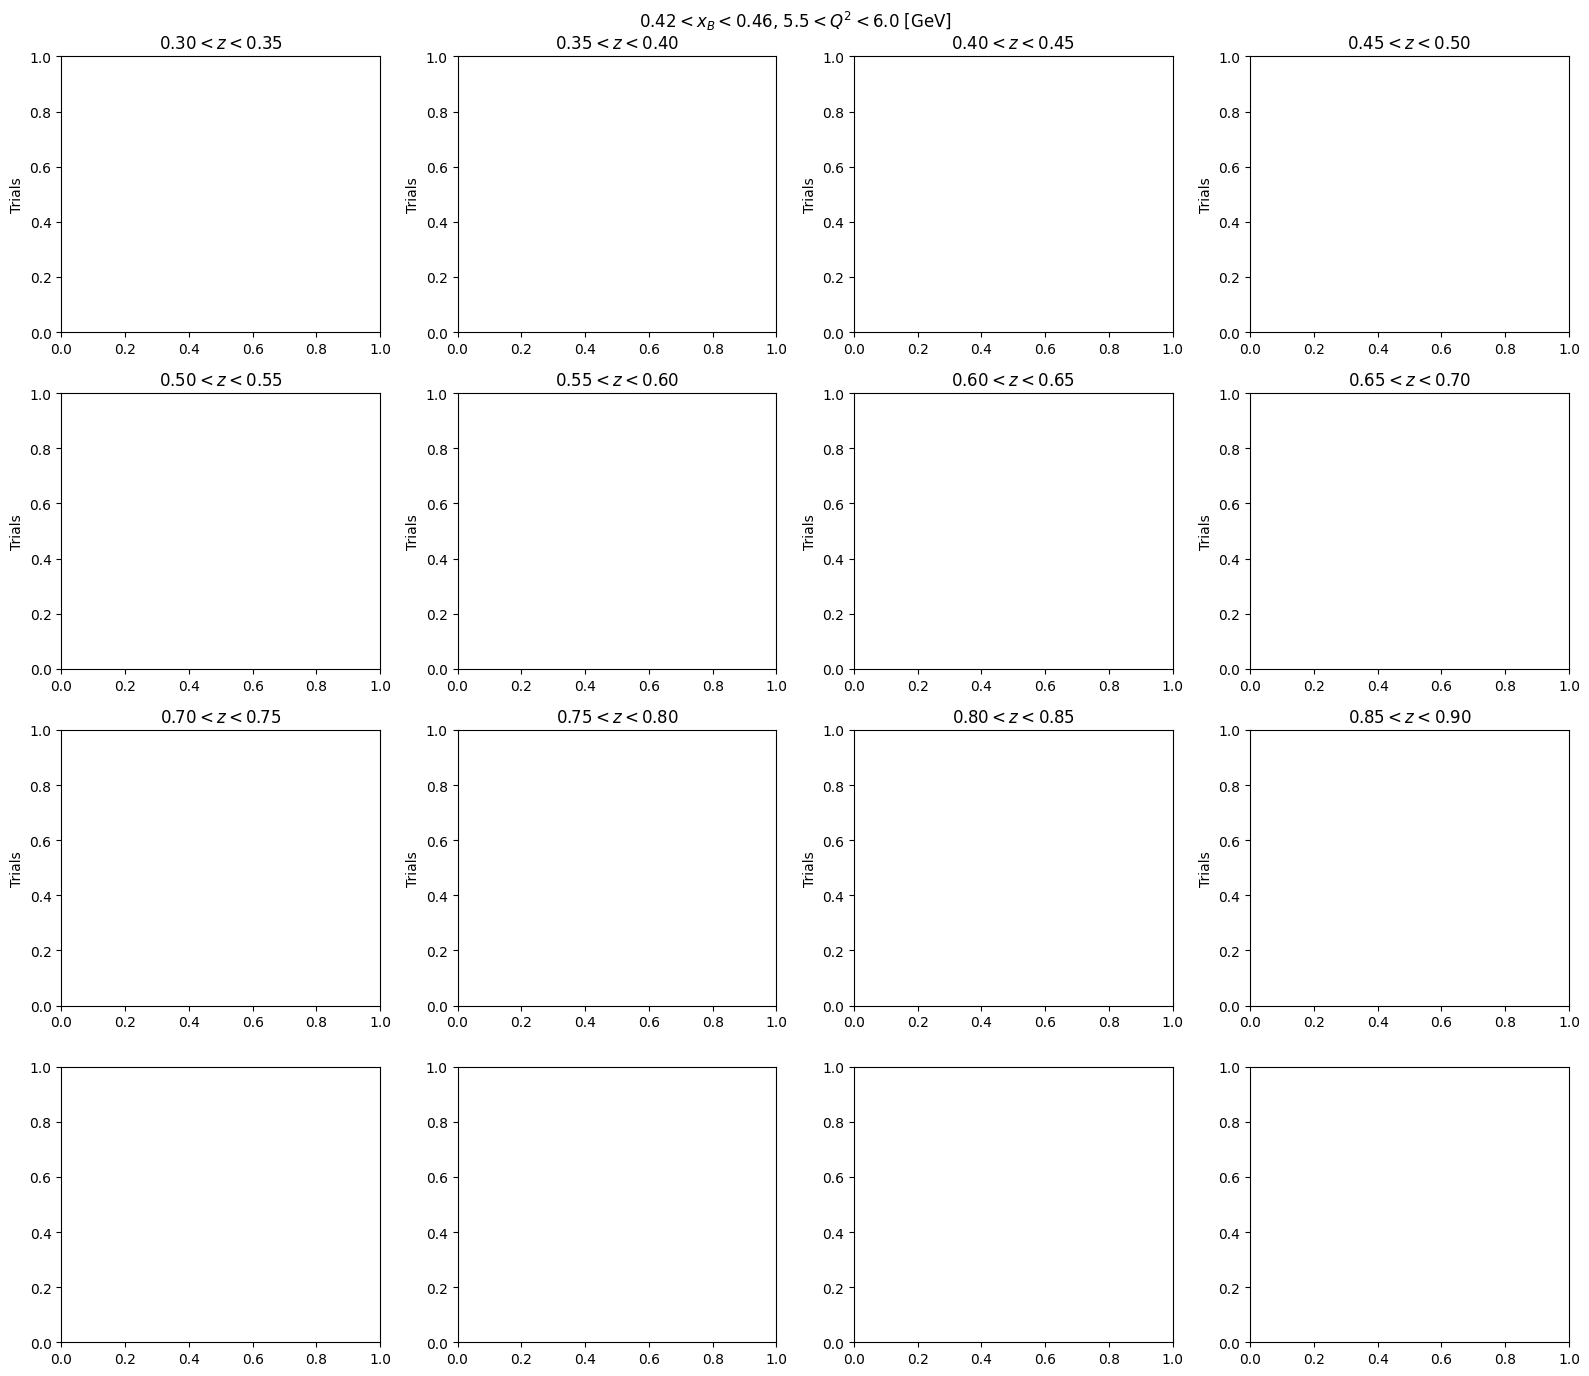

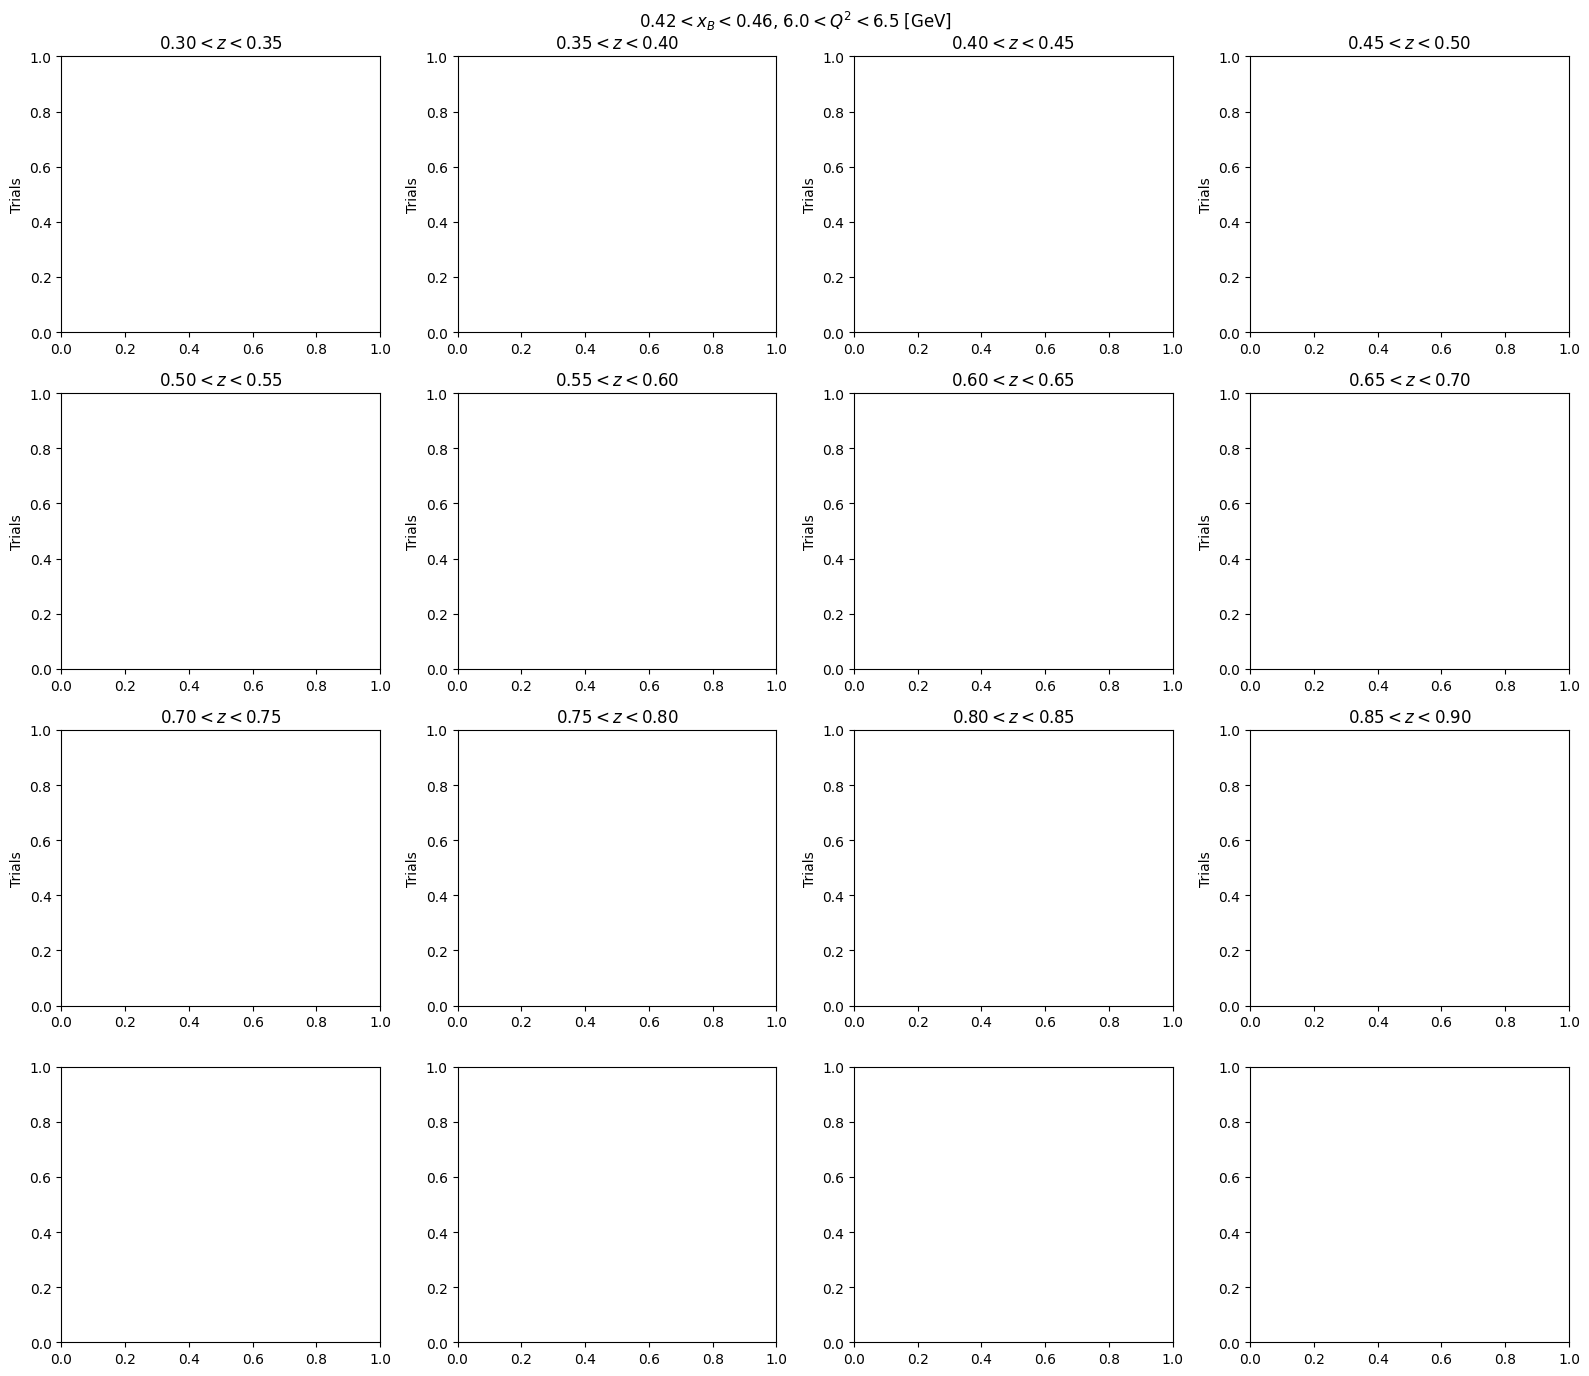

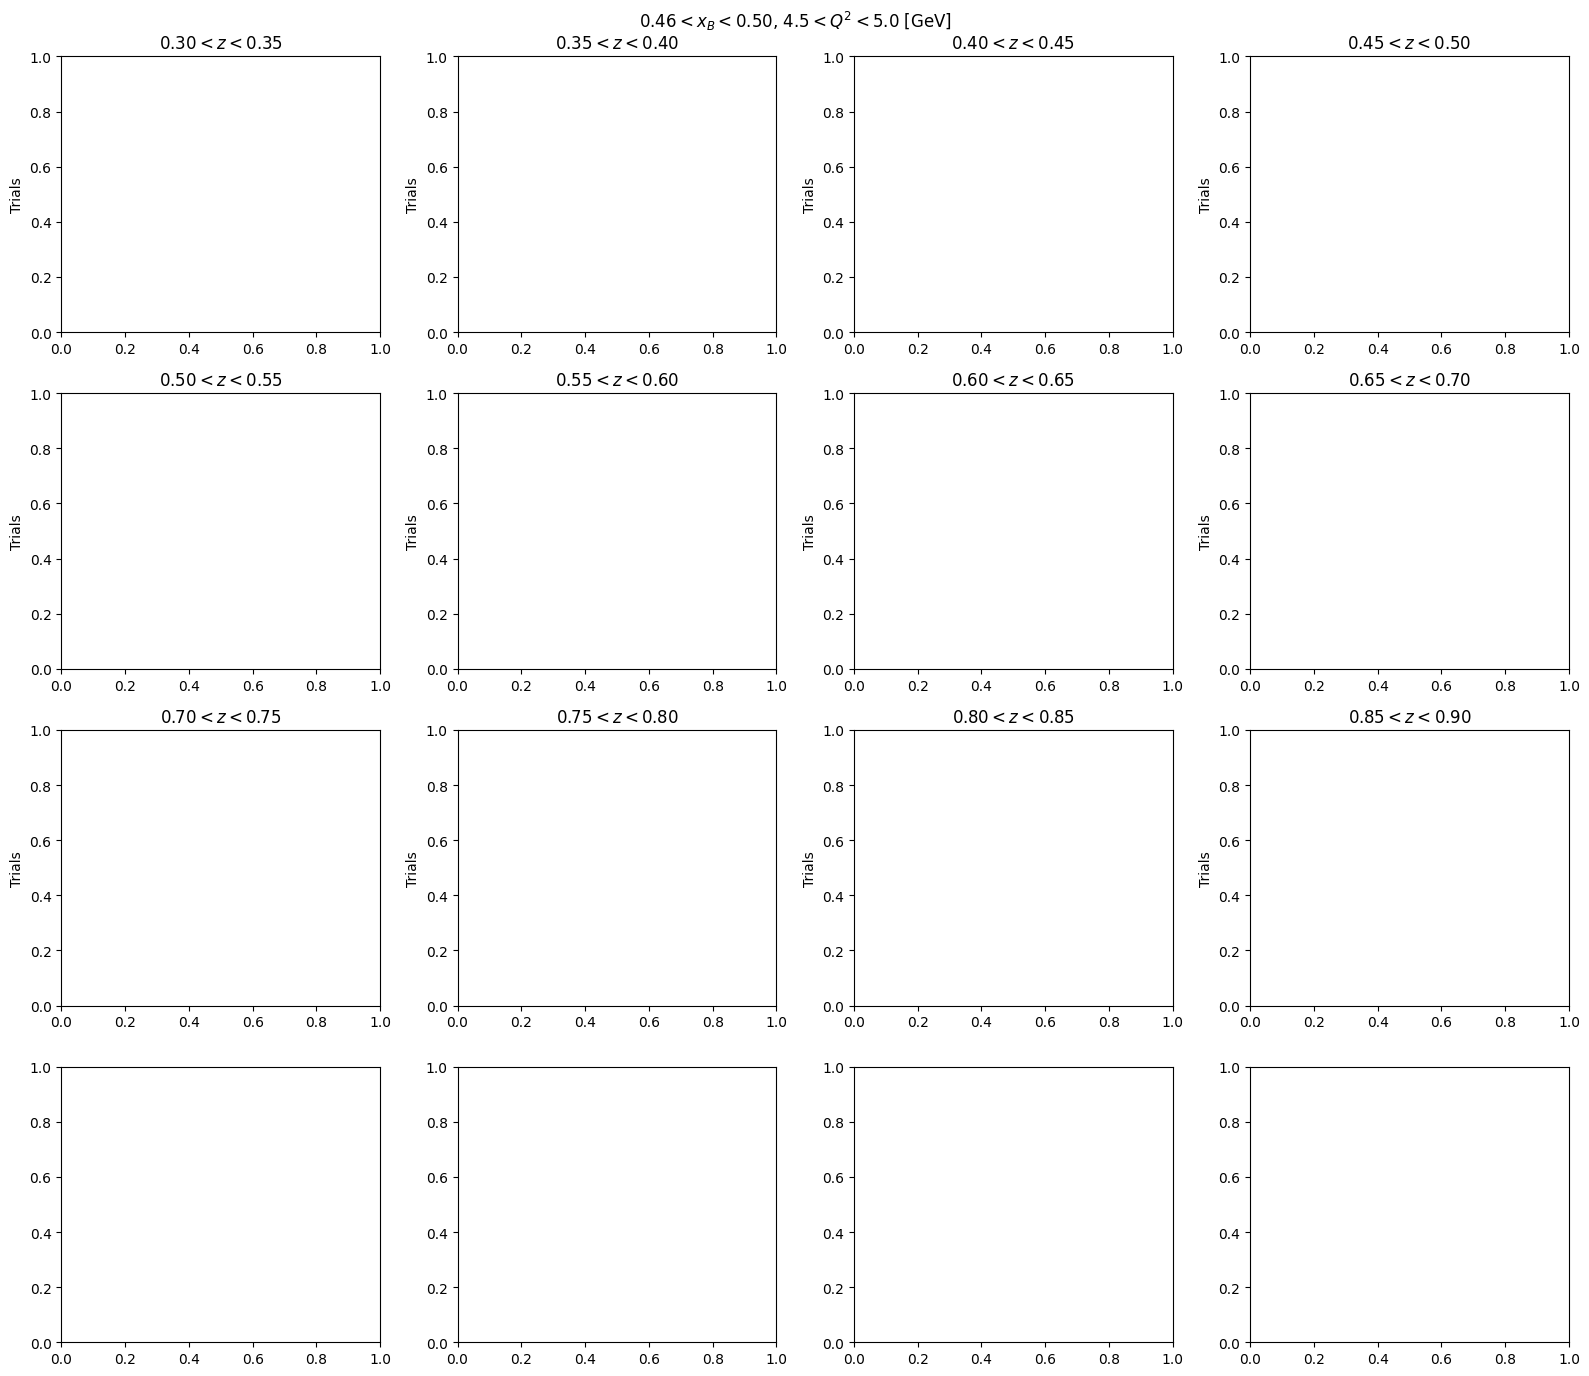

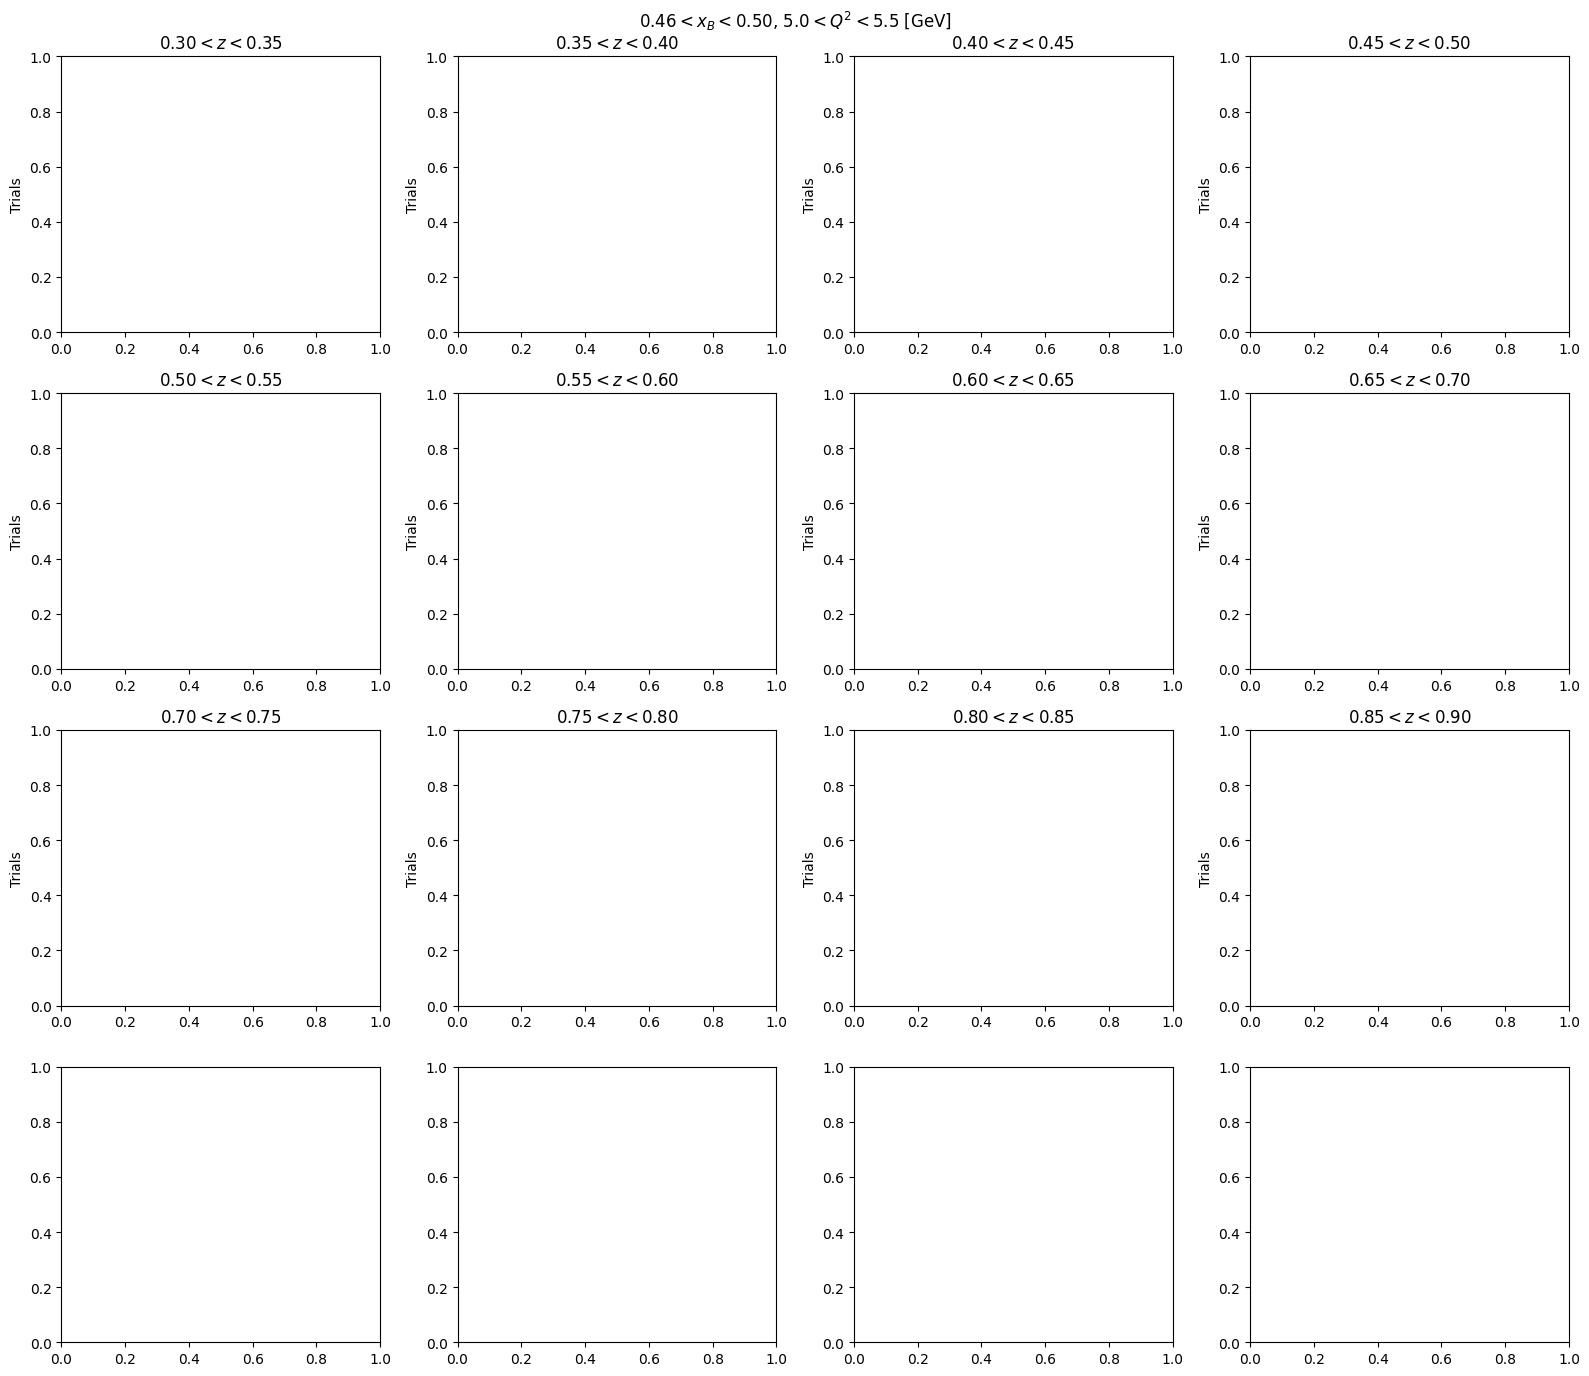

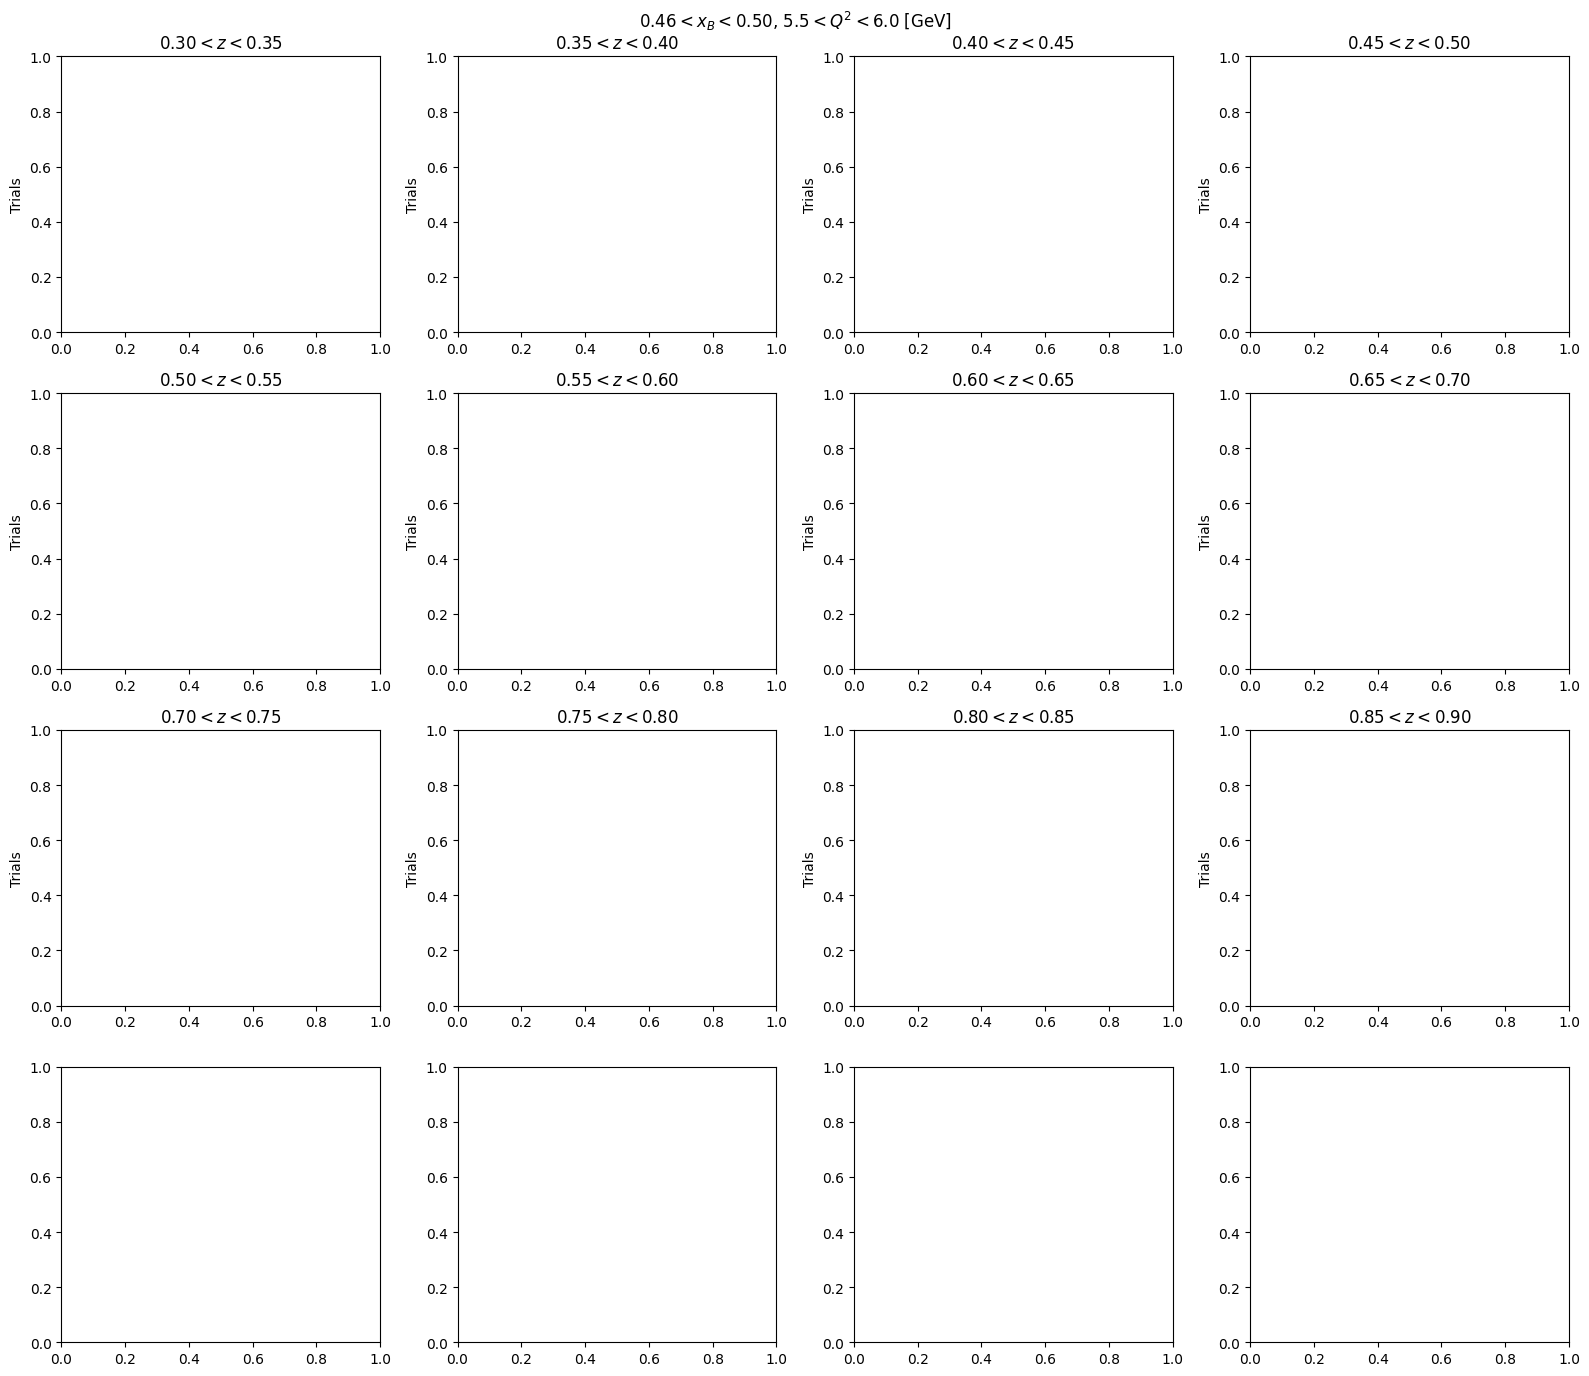

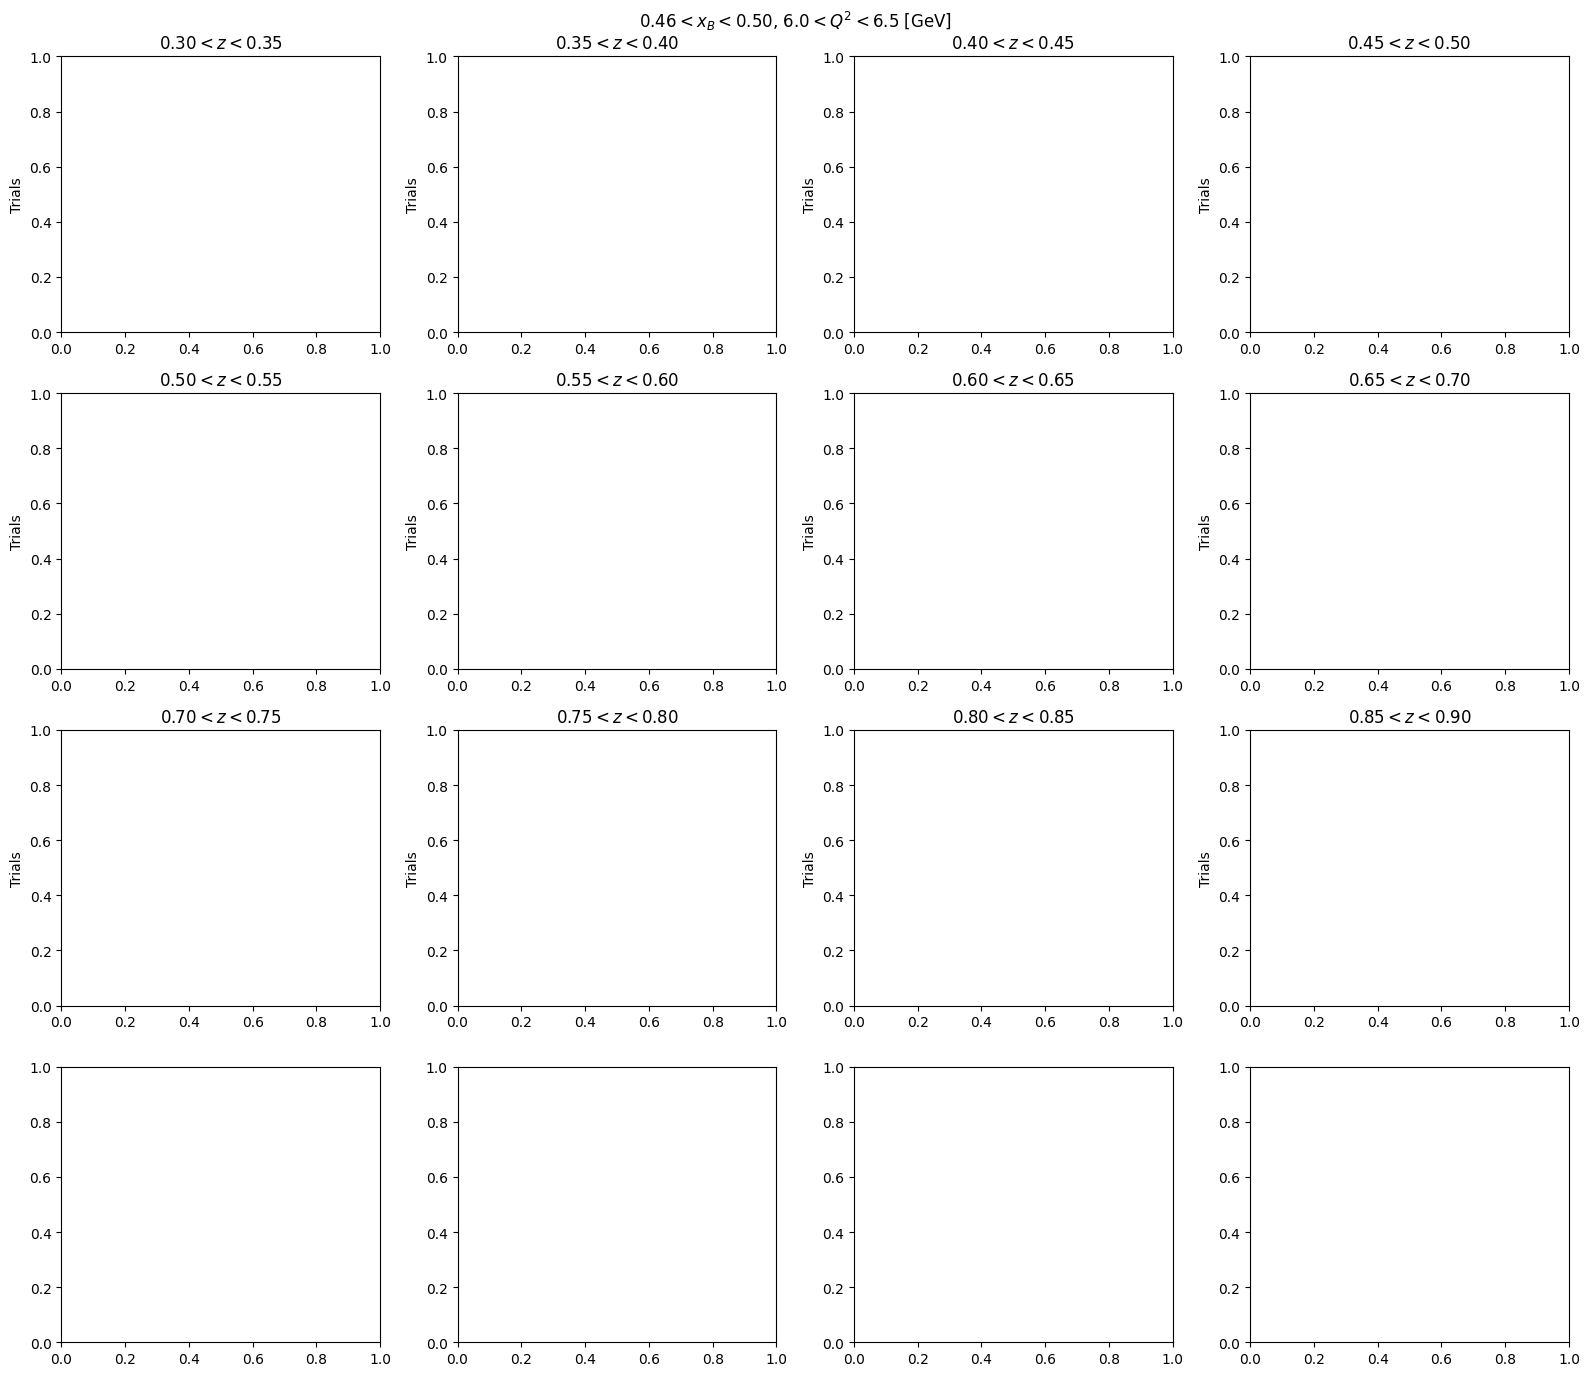

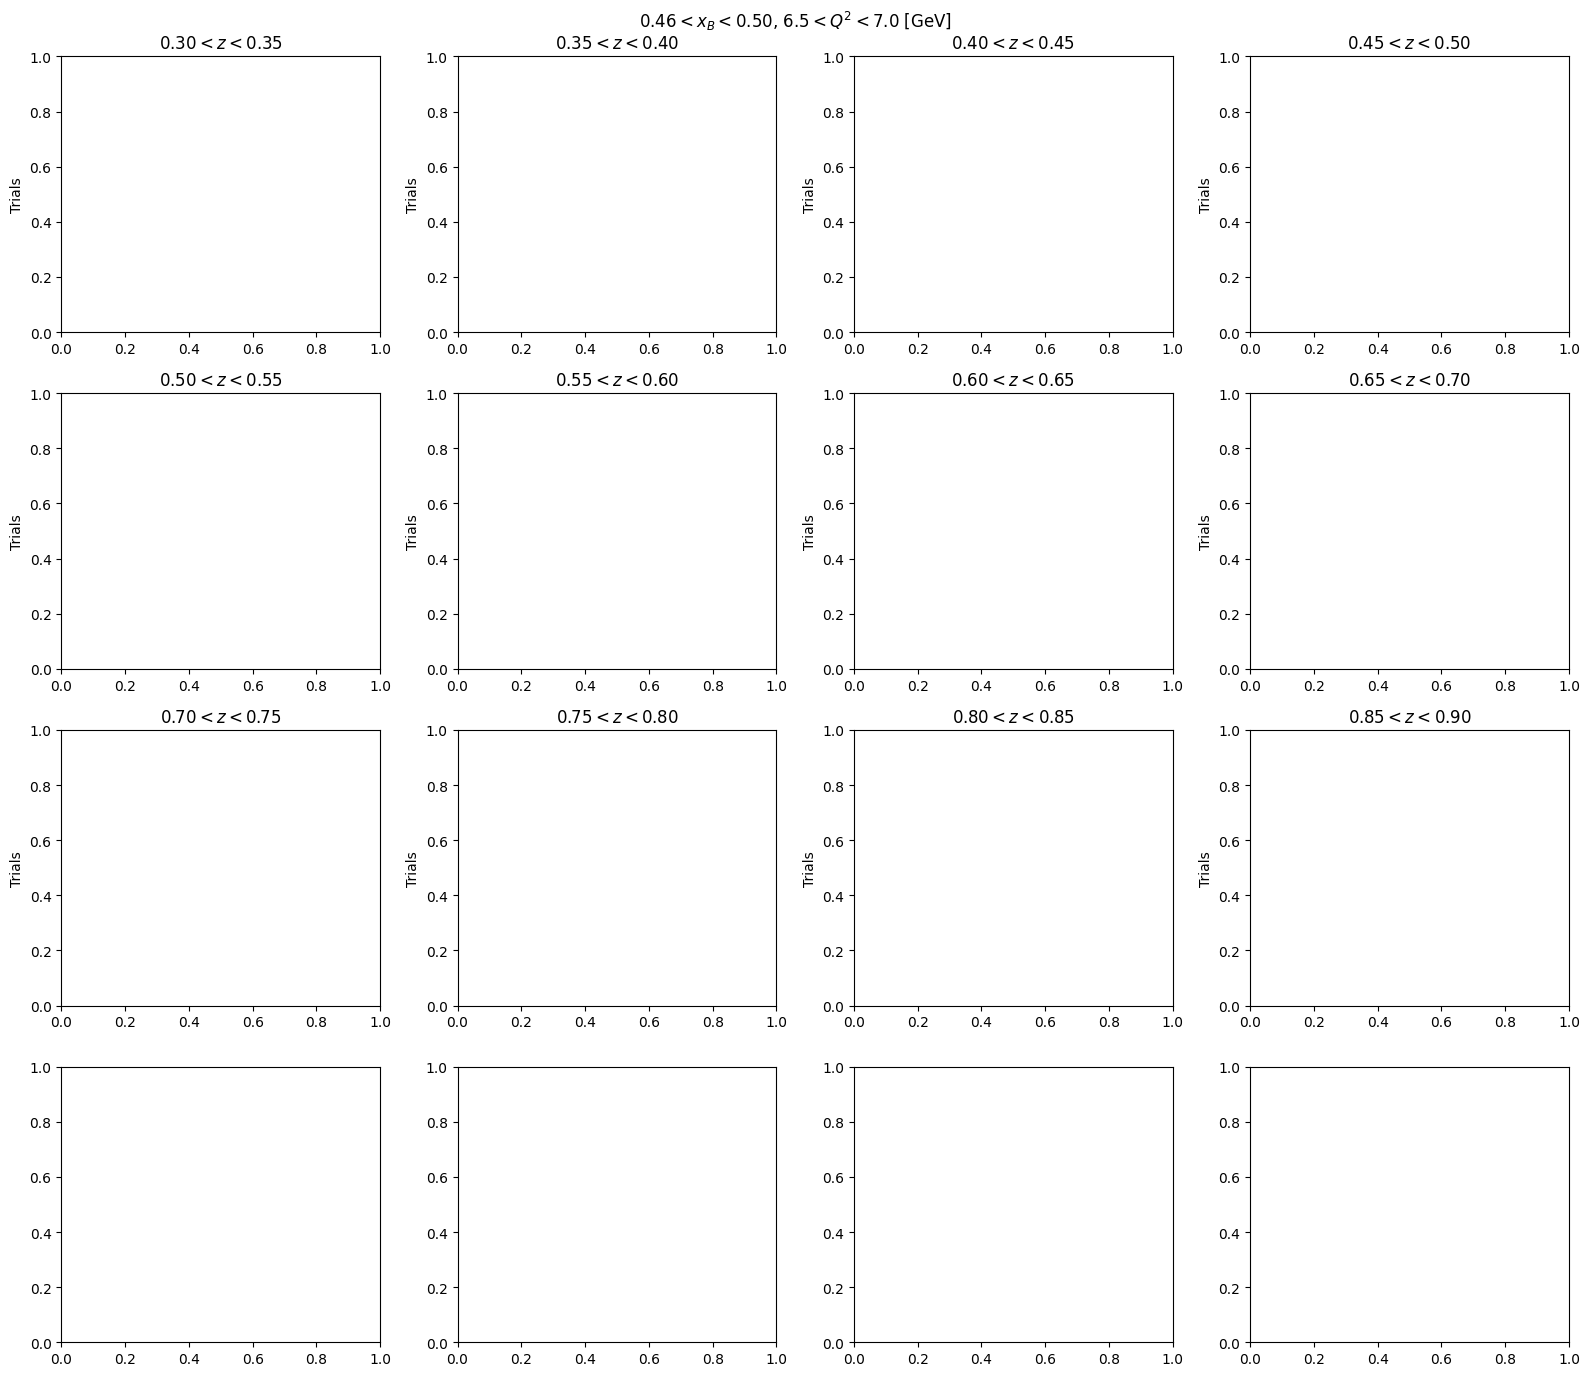

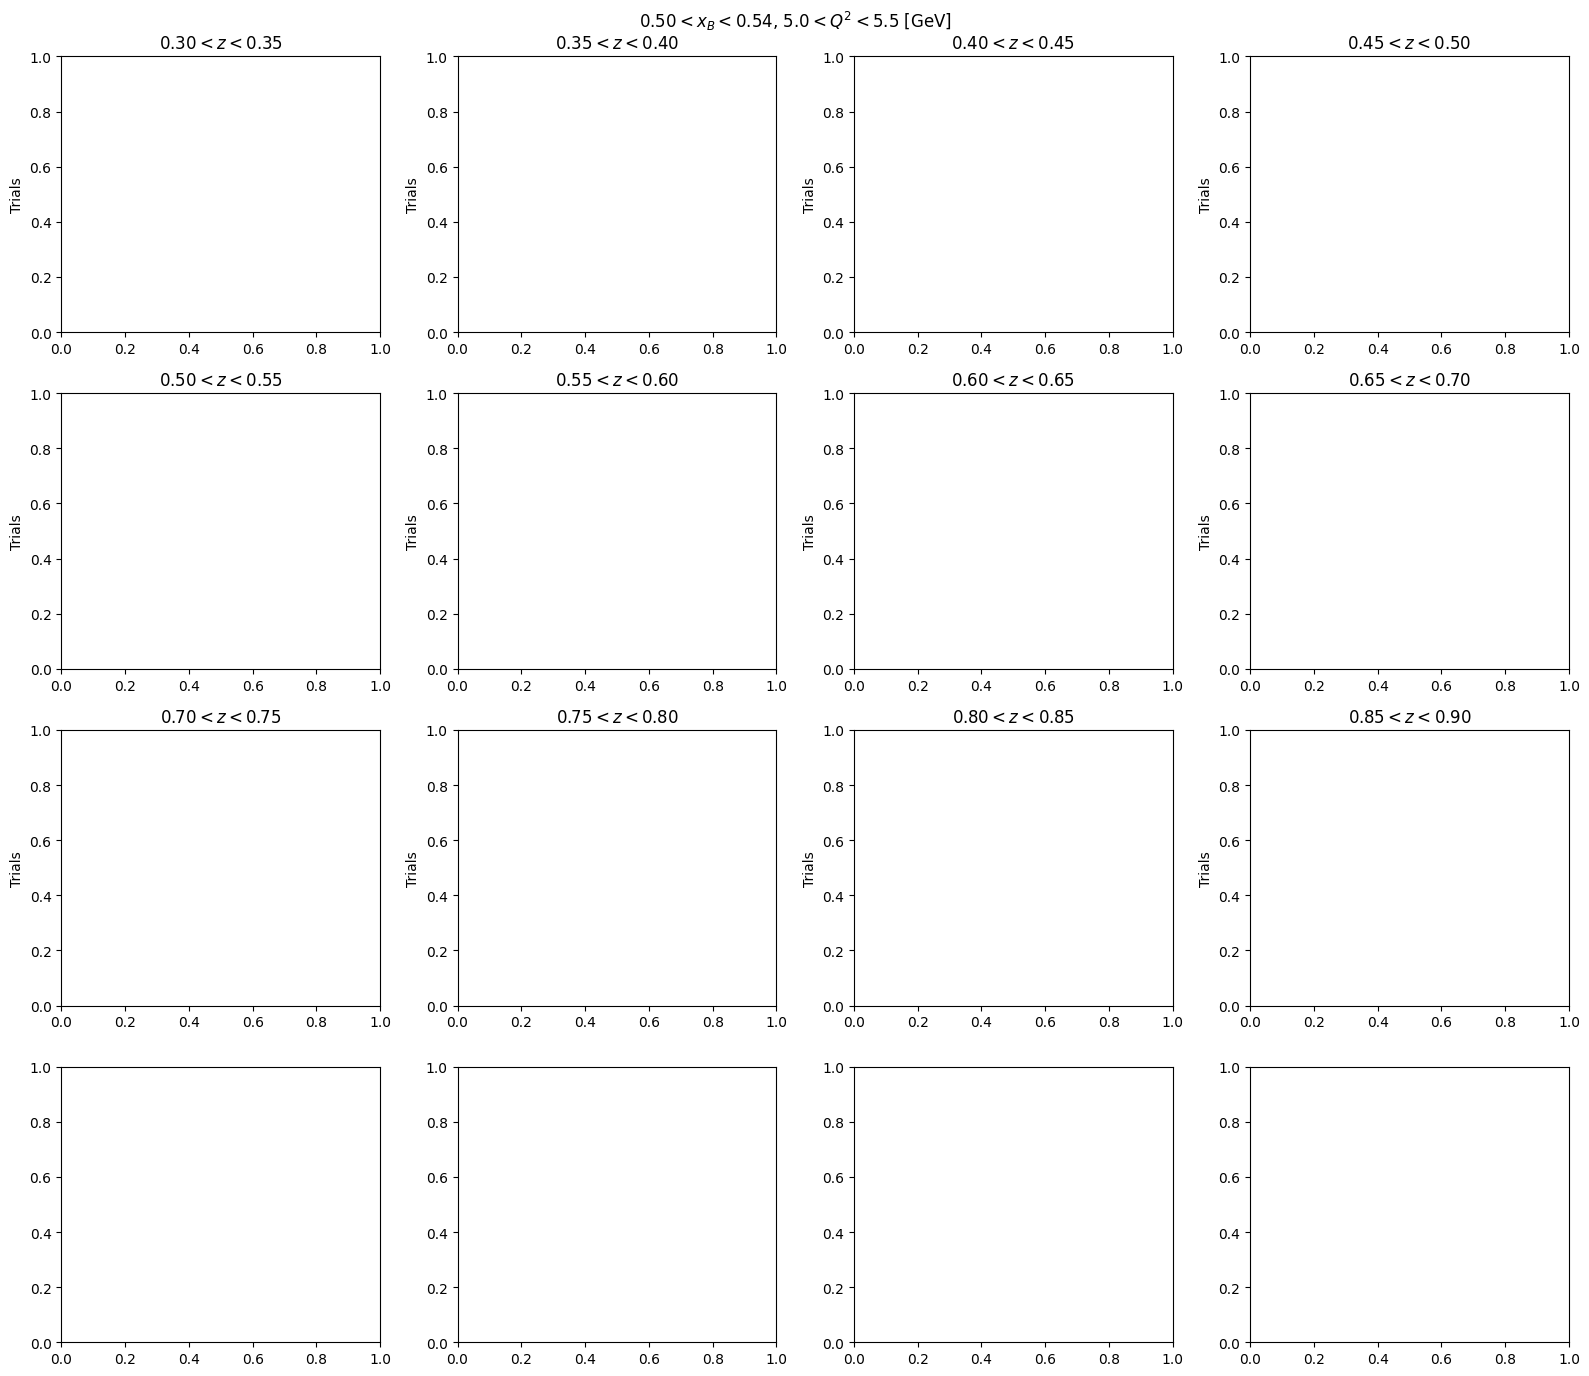

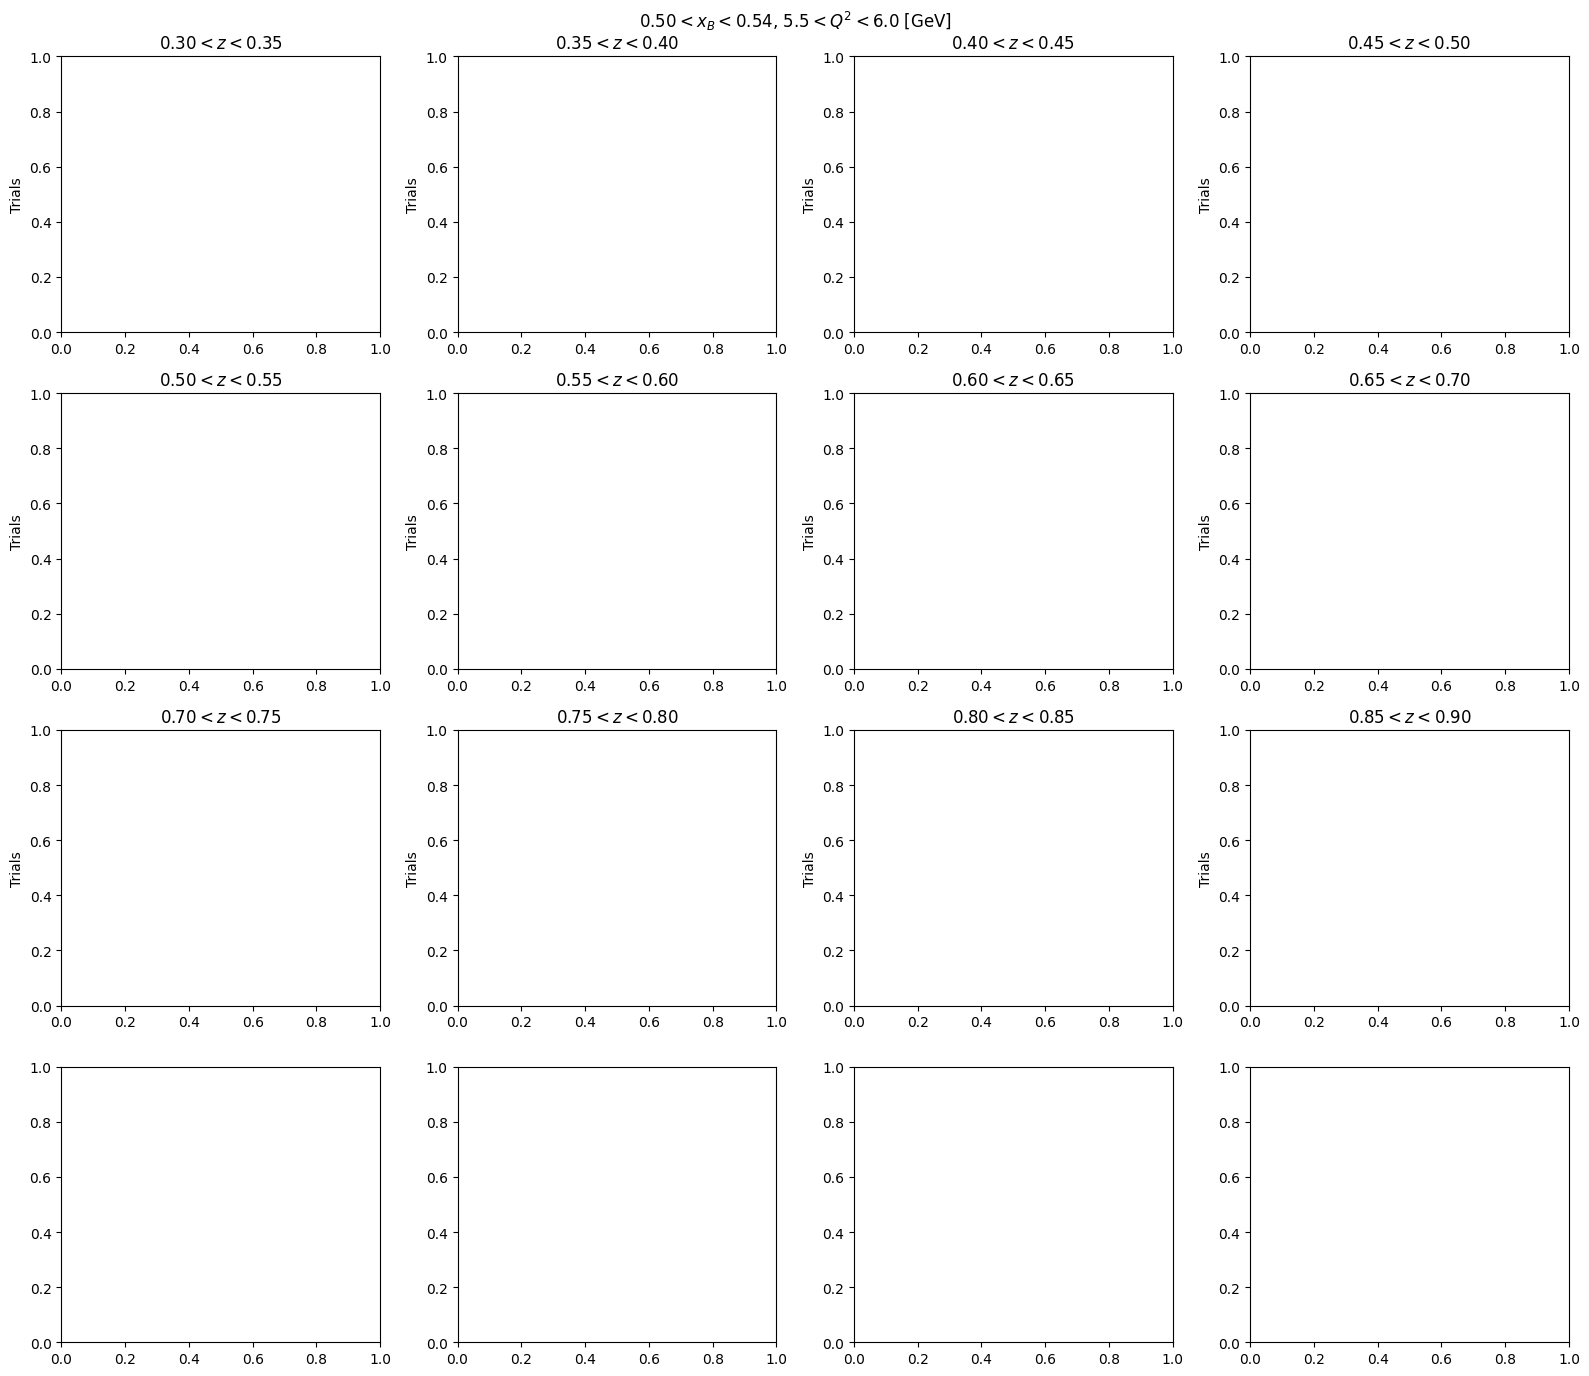

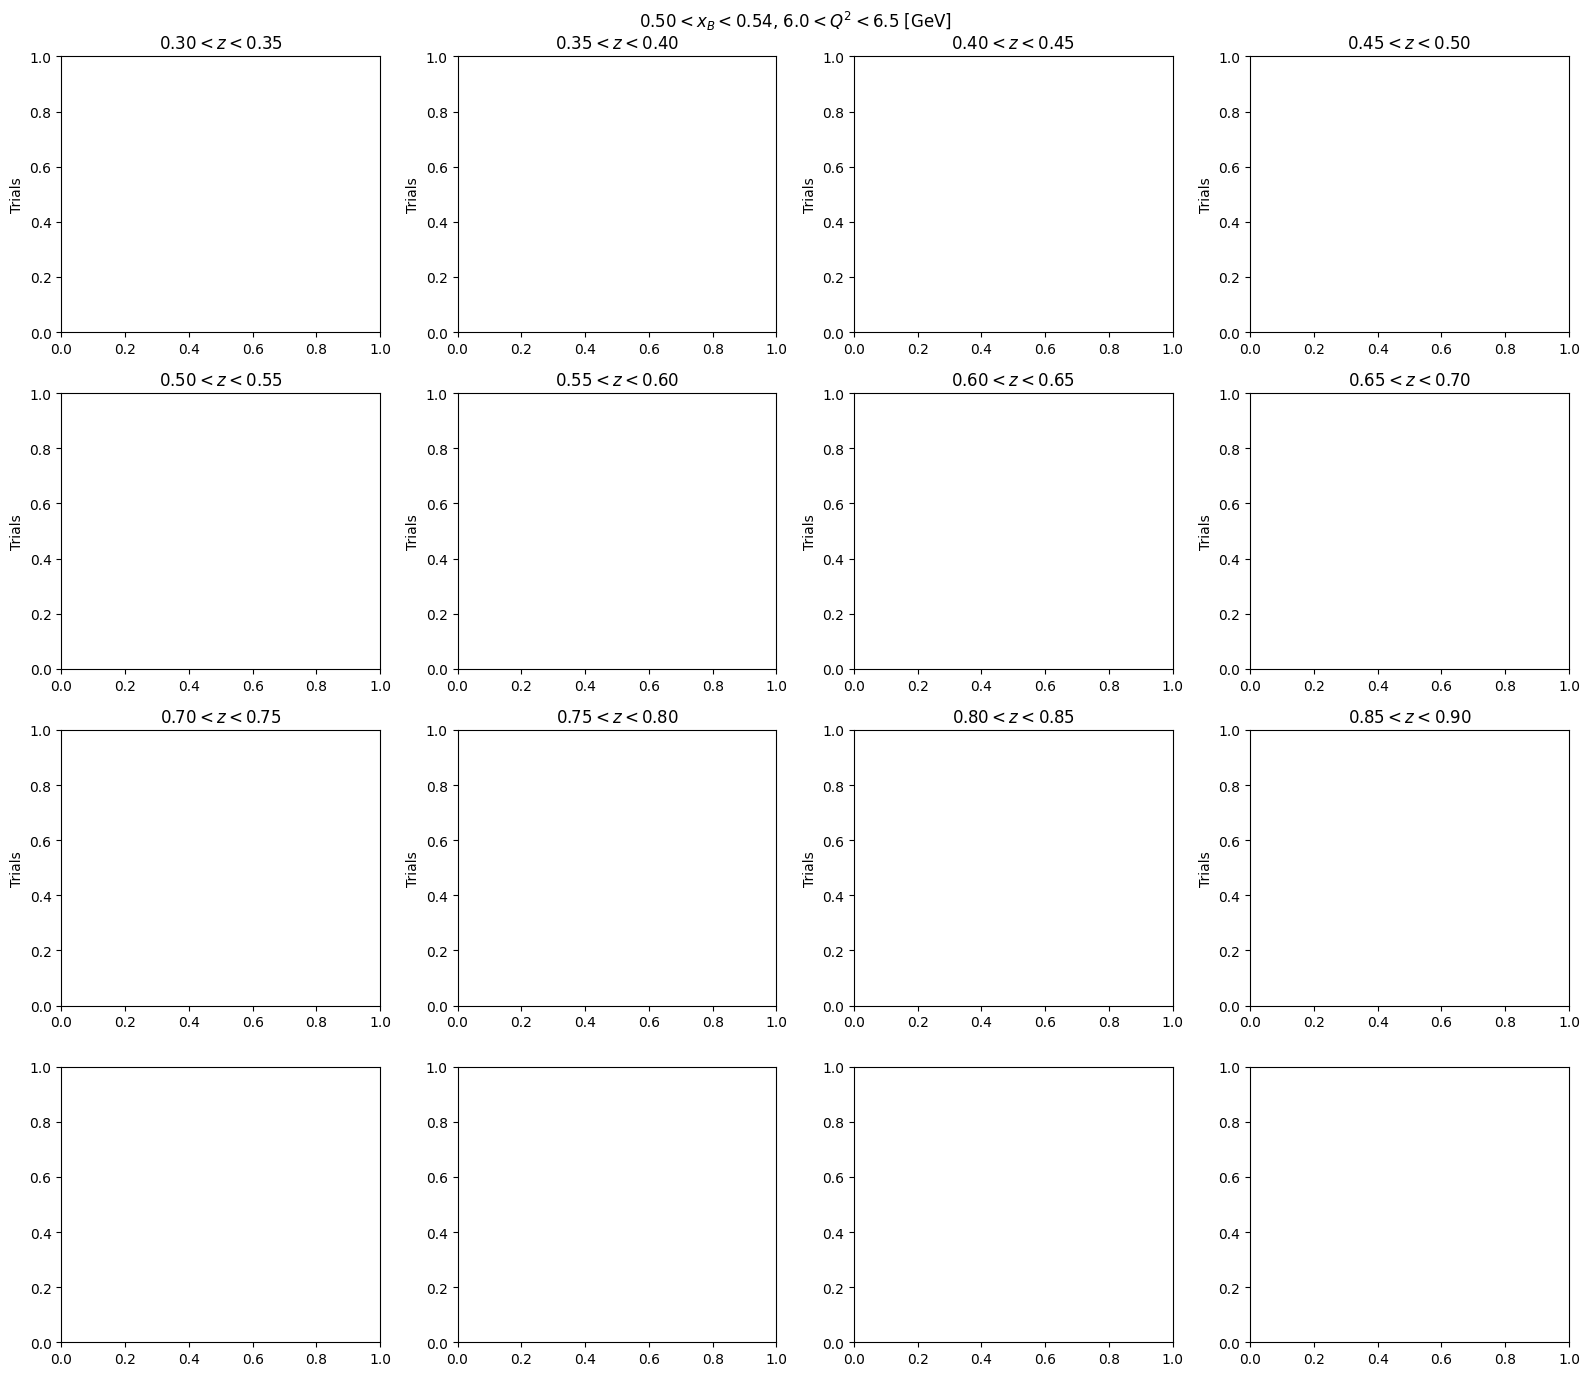

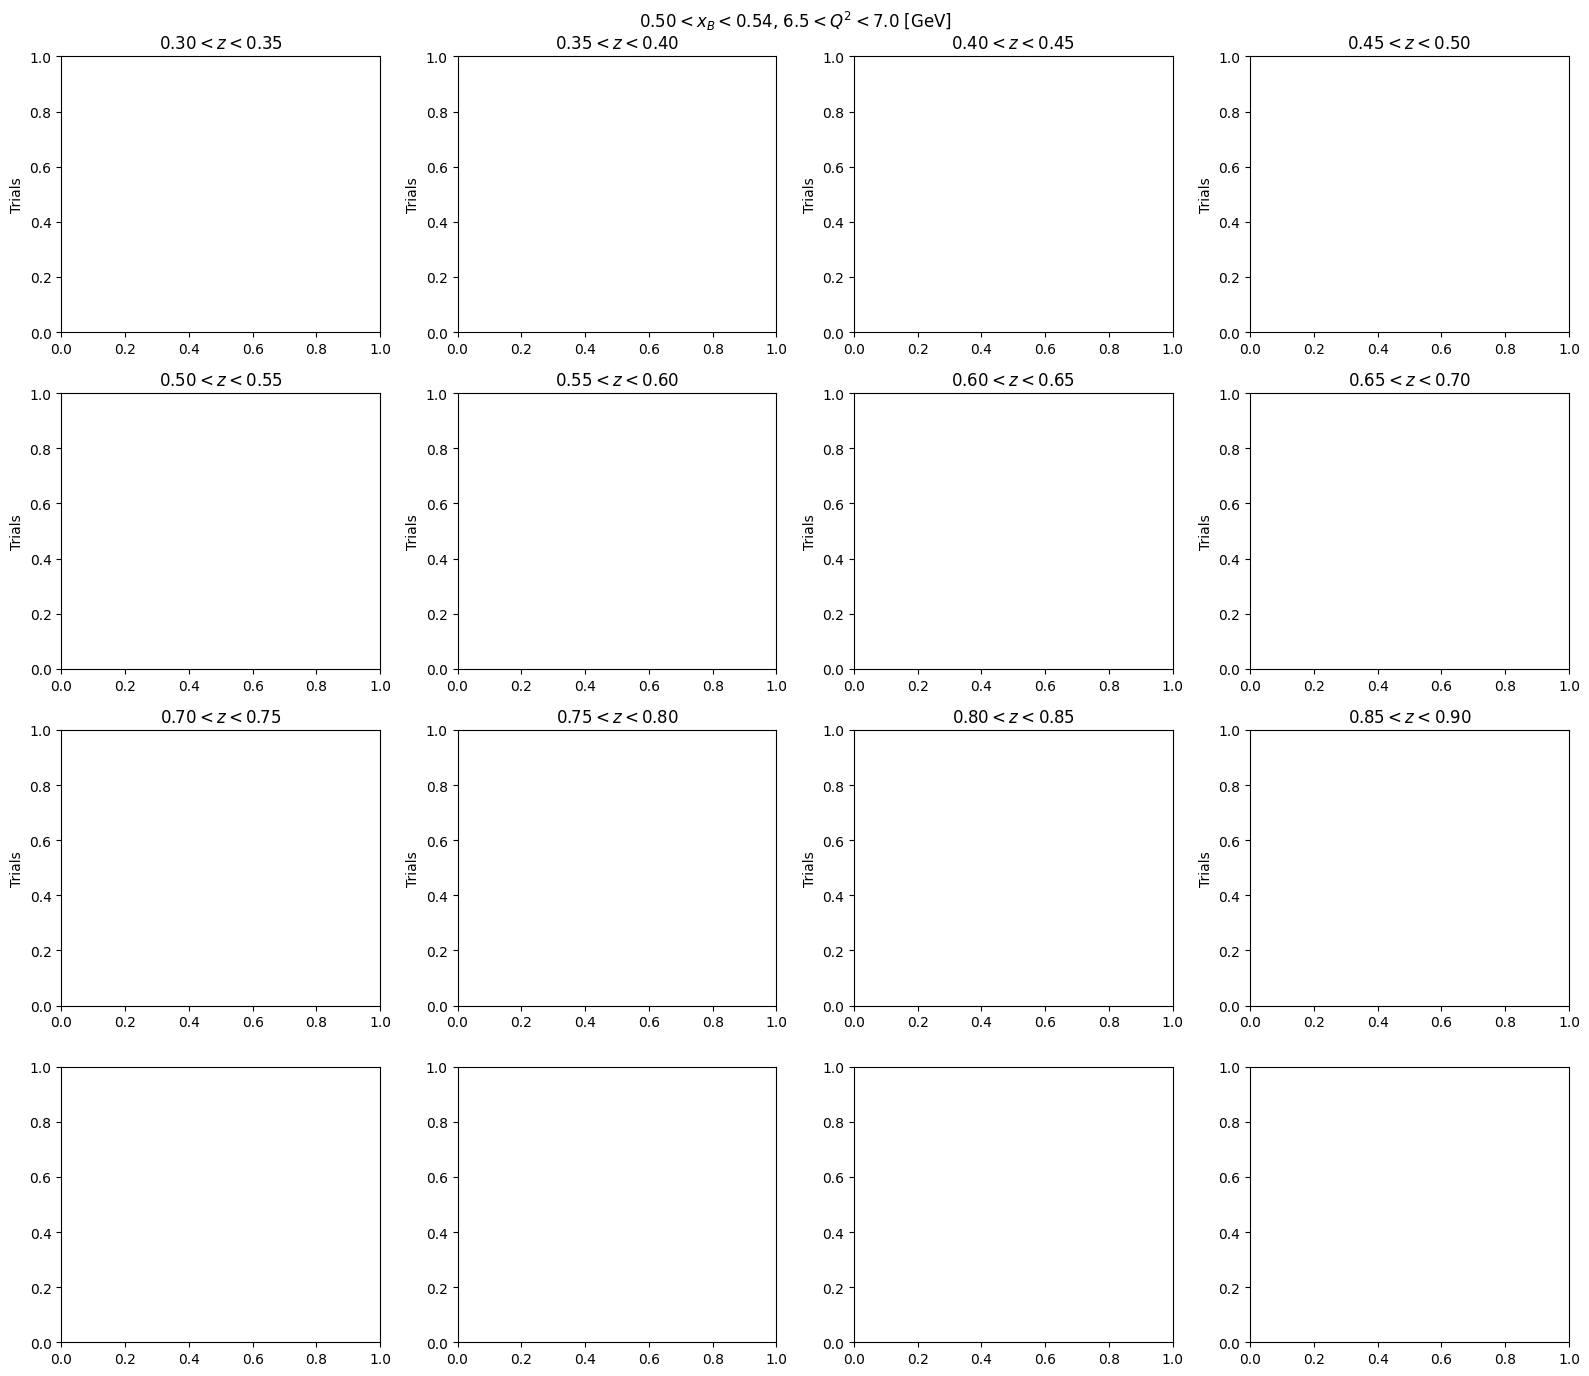

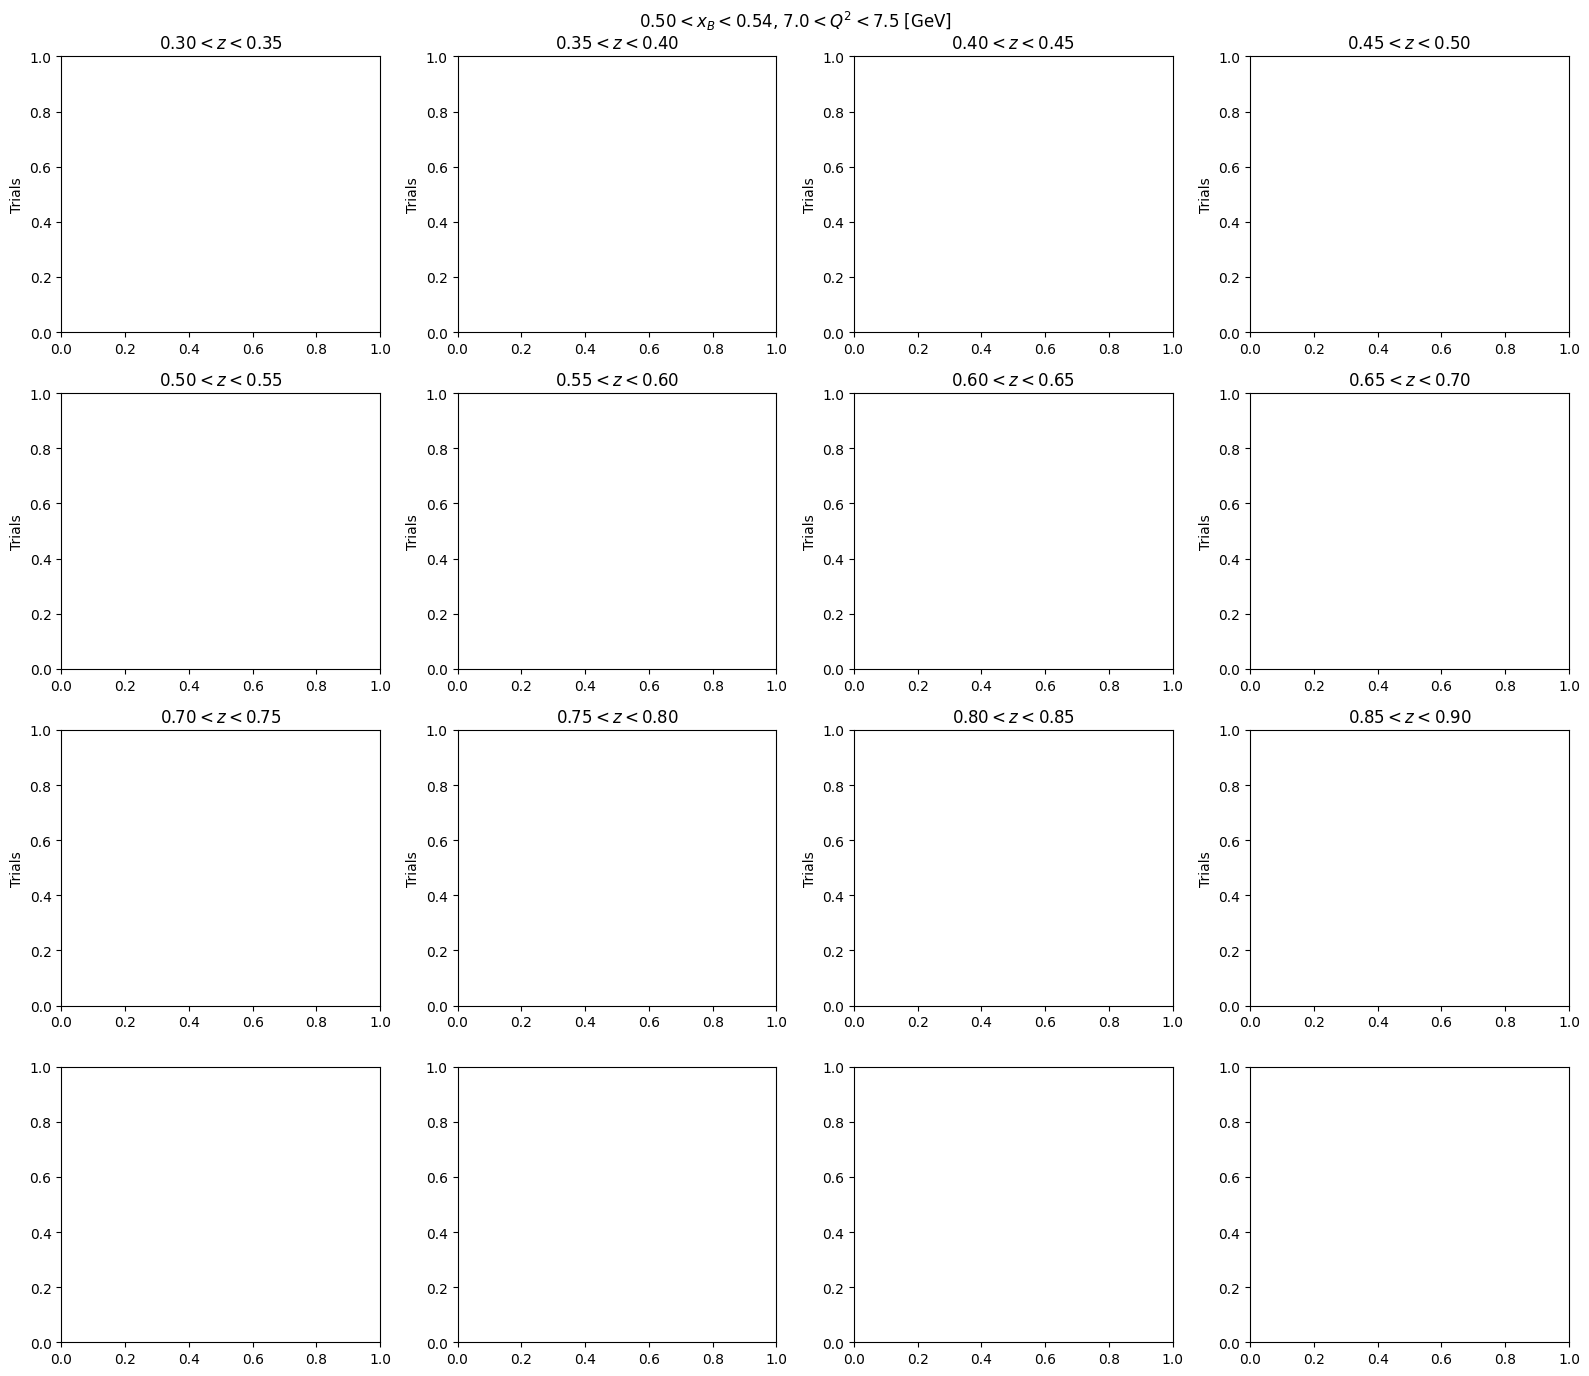

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.optimize import curve_fit

def lorentz(x, A, x0, gamma):
    return A * (gamma) / ((x - x0)**2 + gamma**2)

for x in range(1, 12):      # or range(1, 15)
    for q in range(1, 12):  # or range(1, 13)

        cond_pip = (data_pip[:, 0] == x) & (data_pip[:, 1] == q)
        cond_pim = (data_pim[:, 0] == x) & (data_pim[:, 1] == q)

        selected_pip = np.transpose(data_pip[cond_pip])
        selected_pim = np.transpose(data_pim[cond_pim])

        if selected_pip.size == 0 or selected_pim.size == 0:
            continue

        # quick nonzero check
        sum_pip = sum(np.sum(selected_pip[z, :]) for z in range(2, 14))
        sum_pim = sum(np.sum(selected_pim[z, :]) for z in range(2, 14))
        if sum_pip == 0 or sum_pim == 0:
            continue

        fig, axs = plt.subplots(4, 4, figsize=(16, 14))

        xmin = 0.1 + (x - 1) * 0.04
        xmax = 0.1 + x * 0.04
        qmin = 2 + (q - 1) * 0.5
        qmax = 2 + q * 0.5
        fig.suptitle(rf'${xmin:.2f} < x_B < {xmax:.2f}$, ${qmin:.1f} < Q^2 < {qmax:.1f}$ [GeV]')

        for bin in range(12):
            ax = axs[bin // 4, bin % 4]
            ax.set_title(r"${0:.2f} < z < {1:.2f}$".format(0.3 + 0.05*bin, 0.3 + 0.05*(bin+1)))
            ax.set_ylabel("Trials")

            # mask over trials (explicit axis)
            mask = (selected_pip[36, :] < 3.01)

            # ratio over trials for this z bin
            raw = selected_pip[bin + 2, :] / selected_pim[bin + 2, :]

            # optional: protect against blow-up at raw ~ 0.25
            den = 4 * raw - 1
            raw[np.abs(den) < 1e-12] = np.nan
            den = 4 * raw - 1

            selected = (4 - raw) / den

            # apply mask by rejecting
            selected[mask] = np.nan

            # reject out-of-range (don’t turn into zeros)
            selected[(selected > 5) | (selected <= 0)] = np.nan

            # histogram only finite values
            vals = selected[np.isfinite(selected)]
            counts, edges = np.histogram(vals, bins=40, range=(0, 5))
            bin_centres = 0.5 * (edges[:-1] + edges[1:])

            if counts.sum() < 100:
                continue

            if np.max(counts) < 300 and np.max(counts[1:]) > 20:
                mean = np.average(bin_centres, weights=counts)
                std  = np.sqrt(np.average((bin_centres - mean)**2, weights=counts))
                p0 = [np.max(counts), bin_centres[np.argmax(counts)], std]

                try:
                    coeff, cov = curve_fit(lorentz, bin_centres, counts, p0=p0, maxfev=20000)
                    x_ax = np.linspace(bin_centres[0], bin_centres[-1], 200)

                    ax.plot(x_ax, lorentz(x_ax, *coeff), color="r")
                    ax.text(
                        0.05, 0.95,
                        rf'$\frac{{HWHM}}{{Mean}} = {100*abs(coeff[2])/coeff[1]:.1f}\%$',
                        transform=ax.transAxes, va="top", ha="left"
                    )

                    ax.stairs(counts[1:], edges[1:], color="k")

                except Exception as e:
                    print("no fit:", e)

        plt.tight_layout()
        plt.show()

